# **FASE 01: ENTENDIMENTO DO NEGÓCIO**

### Risco de não alfabetização — análise e modelagem em um único fluxo

**Tech Challenge · Fase 3 · Pós Tech FIAP — AI Scientist**

Este notebook percorre o ciclo **CRISP-DM** inteiro sobre os microdados do *Indicador
Criança Alfabetizada* (INEP/MEC): entendimento do negócio, preparação e exploração dos
dados, modelagem com quatro algoritmos, avaliação e implantação do campeão.

| Fase | O que acontece aqui |
|---|---|
| **01 · Entendimento do negócio** | a pergunta, o alvo, a métrica e o custo do erro |
| **02 · Preparação dos dados** | coleta, limpeza, EDA por hipóteses, engenharia de atributos, correlações |
| **03 · Modelagem** | pré-processamento, quatro algoritmos, comparação, ajuste fino, limiar, teste anti-vazamento |
| **04 · Avaliação** | leitura de negócio das métricas, previsto x observado, variáveis mais importantes |
| **05 · Implantação** | o campeão vira `models/modelo_final_alfabetizacao.joblib` (com ficha `.json`) e é testado numa simulação |

### O problema

O **Compromisso Nacional Criança Alfabetizada** estabelece que toda criança deve estar
alfabetizada ao fim do 2º ano do ensino fundamental. O INEP mede isso com uma prova de
leitura e escrita: quem alcança **743 pontos** na escala Saeb é considerado alfabetizado.

Em 2024, **40,2% das crianças avaliadas não atingiram esse corte**. A política pública
chega tarde quando age sobre o resultado: no momento em que a prova acontece, o ano letivo
já passou. A pergunta que interessa ao gestor é anterior.

> **Pergunta de negócio.** Dado o que se sabe sobre uma criança *antes* da avaliação — o
> município onde estuda, a escola, a rede, o histórico daquele território — qual é a
> probabilidade de ela não ser alfabetizada?

### O alvo

`nao_alfabetizado` = 1 quando a criança **não** atinge 743 pontos.

A classe positiva é deliberadamente a classe ruim. Em política pública o custo de **não
identificar** uma criança em risco (falso negativo: ela não entra no programa de reforço)
é muito maior que o de acompanhar uma criança que iria bem de qualquer forma (falso
positivo: gasta-se uma vaga de reforço à toa). Métricas assimétricas exigem que a classe
de interesse seja a positiva.

### A métrica

**PR-AUC** (área sob a curva precisão-revocação), complementada por **recall** da classe
positiva. Acurácia seria enganosa aqui por dois motivos: a base é desbalanceada (40/60) e,
pior, ela trata falso positivo e falso negativo como se custassem o mesmo — exatamente a
premissa que este problema viola.

O piso de comparação é a **prevalência**: um classificador aleatório tem PR-AUC igual à
proporção da classe positiva, cerca de 0,40. Qualquer modelo precisa superar isso com folga
para justificar existir.

### O critério anti-vazamento

Uma restrição desenha todo o resto: **nenhuma variável medida no mesmo ano do alvo pode
entrar no modelo**. A proficiência define o alvo por construção; a taxa de alfabetização do
município em 2024 é um agregado do próprio alvo. O contexto territorial vem todo de
**2023** (`ANO_CONTEXTO`), enquanto o alvo vem de **2024** (`ANO_ALVO`). É essa defasagem
que torna a previsão utilizável: em fevereiro de 2025, todo o insumo do modelo já existe.

# **FASE 02: PREPARAÇÃO DOS DADOS**

## 1 - **COLETA DOS DADOS**

### <font color='#F37126'> 1.1. Biblioteca

Todas as bibliotecas do projeto ficam concentradas aqui, para que o notebook tenha um único
ponto de configuração. Em resumo:

| Biblioteca | Para que serve |
|---|---|
| `pandas` / `numpy` | ler, organizar e calcular sobre a tabela de dados |
| `matplotlib` / `seaborn` | desenhar os gráficos |
| `scipy` | testes estatísticos |
| `scikit-learn` | preparar os dados, treinar e avaliar os modelos de Machine Learning |
| `lightgbm` | algoritmo de árvores de decisão rápido e preciso |
| `shap` | explicar por que o modelo tomou cada decisão |
| `joblib` | salvar e carregar o modelo treinado |
| `src.config` | configurações do próprio projeto (caminhos, nome do alvo, colunas proibidas) |
| `src.preprocessing` · `src.evaluation` · `src.visualization` | funções do projeto: preparar as variáveis, escolher o limiar e desenhar/salvar os gráficos |

In [1]:
# Bibliotecas para silenciar mensagens técnicas que não são erros
import contextlib, io
# Conta os núcleos do computador uma única vez, em silêncio: no Windows, o processamento paralelo
# do scikit-learn imprimiria um aviso técnico (com cara de erro) na primeira vez que precisasse dessa contagem
from joblib.externals.loky import cpu_count
with contextlib.redirect_stderr(io.StringIO()):
    cpu_count(only_physical_cores=True)
# Biblioteca para interagir com o interpretador Python (usada para achar a pasta do projeto)
import sys
sys.path.insert(0, "..")
# Biblioteca para medir tempo de execução de um trecho de código
import time
# Biblioteca para ler e gravar arquivos JSON (métricas do modelo)
import json
# Biblioteca para liberar memória de tabelas que não serão mais usadas
import gc
# Fixar um parâmetro de uma função (usado para deixar a informação mútua reproduzível)
from functools import partial
# Biblioteca para ignorar avisos e alertas indesejados
import warnings
warnings.filterwarnings("ignore")

# Biblioteca para manipulação de dados em formato de tabela
import pandas            as pd
# Biblioteca para trabalhar com arrays e realizar operações matemáticas
import numpy             as np
# Biblioteca para visualização de gráficos estáticos
import matplotlib.pyplot as plt
# Biblioteca para gráficos estatísticos mais elaborados
import seaborn           as sns
# Biblioteca de estatística (testes de hipótese, correlações)
from scipy import stats
# Correlação de Pearson entre duas variáveis numéricas
from scipy.stats import pearsonr
# Sorteio de números inteiros para o Random Search
from scipy.stats import randint as sp_randint
# Biblioteca para salvar modelos treinados em disco
import joblib
# Banco de dados analítico para ler a base completa (parquet) de forma rápida
import duckdb

# Modelo de referência que apenas "chuta" (serve de piso de comparação)
from sklearn.dummy import DummyClassifier
# Algoritmo de Regressão Logística
from sklearn.linear_model import LogisticRegression
# Algoritmo de Random Forest (floresta de árvores de decisão)
from sklearn.ensemble import RandomForestClassifier
# Algoritmo LightGBM (árvores de decisão em sequência, rápido e preciso)
from lightgbm import LGBMClassifier
# Interface nativa do LightGBM (lgb.Dataset, lgb.train, early stopping)
import lightgbm as lgb
# Algoritmo XGBoost (árvores de decisão em sequência, cada uma corrigindo os erros da anterior)
import xgboost as xgb
# Encadeia preparação dos dados + modelo em um único objeto
from sklearn.pipeline import Pipeline
# Cria uma cópia "zerada" de um modelo, com os mesmos hiperparâmetros
from sklearn.base import clone
# Sorteio com reposição, usado no balanceamento por oversampling
from sklearn.utils import resample
# Separação treino/teste, validação cruzada e busca de hiperparâmetros
from sklearn.model_selection import (
    RandomizedSearchCV, StratifiedGroupKFold, StratifiedKFold, cross_val_score,
    train_test_split,
)
# Métricas para avaliar o desempenho dos modelos
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, f1_score, precision_recall_curve,
    precision_score, recall_score, roc_auc_score, roc_curve,
)
# Importância das variáveis e seleção de atributos
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import SelectKBest, mutual_info_classif
# Verifica se as probabilidades do modelo são confiáveis
from sklearn.calibration import calibration_curve
# Agrupamento (KMeans), padronização das variáveis e medida de qualidade dos grupos
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
# Biblioteca para explicar as previsões do modelo
import shap

# Configurações do próprio projeto: caminhos, nome do alvo e colunas proibidas
from src.config import (
    ALVO, AMOSTRA_VERSIONADA, BASE_ALUNOS, BASE_ALUNOS_AMOSTRA, CAT_ALTA, CAT_BAIXA, COLUNAS_LEAKAGE,
    COLUNAS_VETADAS_DIAGNOSTICO, FEATURES, MODELS_DIR, NUM_FEATURES, PROCESSED_DIR, REPORTS_DIR, SEED,
)

# Funções do projeto: separar X e y e montar o pré-processamento das variáveis
from src.preprocessing.build_features import constroi_preprocessador, matriz_xy
# Função do projeto: encontra o limiar de decisão que maximiza o F1
from src.evaluation.metricas import limiar_otimo_f1
# Funções de gráfico do projeto: barras com rótulo, nota sob o gráfico e salvar imagem
from src.visualization.plots import (
    AGUA, AZUL, DIVERGENTE, LARANJA, NEUTRO, TINTA_SEC, anota, barras_horizontais, limpa_eixos, salva,
)

# Exibir mais colunas nas tabelas e fixar a semente para resultados reproduzíveis
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
np.random.seed(SEED)

# Ao salvar imagens, recortar a figura inteira (rótulos e notas não ficam cortados)
plt.rcParams["savefig.bbox"] = "tight"

### <font color='#F37126'> 1.2. Salvar a base em CSV

**De onde vêm os dados**

Os dados vêm do **Indicador Criança Alfabetizada** (INEP/MEC): a prova de leitura e escrita aplicada às crianças do 2º ano. O caminho
até a tabela usada neste notebook tem quatro etapas:

| Etapa | O que acontece | Onde |
|---|---|---|
| **1. Camada Gold** | os microdados do INEP já limpos e organizados em quatro tabelas: alunos, municípios, estados e metas | `data/gold/` |
| **2. Base completa** | o script `src/preprocessing/build_base.py` junta, para cada criança avaliada em **2024**, o contexto do **município e do estado em 2023**, as **metas** do INEP, o **porte** da escola e do município e os dados do **IBGE** | `data/processed/base_analitica_alunos.parquet` (1,85 milhão de crianças) |
| **3. Amostra** | a base completa é grande demais para versionar no Git e pesada para um notebook didático; por isso é sorteada uma **amostra de ~50 mil crianças** | `data/processed/base_analitica_alunos_amostra.parquet` |
| **4. CSV** | a amostra é salva em **CSV** — um formato de tabela simples, que abre até no Excel — e é desse arquivo que toda a análise parte | `data/processed/base_alfabetizacao_amostra.csv` |

A célula abaixo **refaz o sorteio da etapa 3** a partir da base completa, com a mesma regra do `build_base.py`, e confere se o resultado é
idêntico à amostra que vem no projeto.

In [2]:
# Criando a amostra a partir da base completa (mesma regra de src/preprocessing/build_base.py)
if BASE_ALUNOS.exists():
    n_base = duckdb.sql(f"SELECT COUNT(*) FROM read_parquet('{BASE_ALUNOS.as_posix()}')").fetchone()[0]

    # Sorteio reprodutível: cada criança recebe um número fixo (hash do id_aluno + semente)
    # e entram na amostra as que caem abaixo do limite que corresponde a ~50 mil crianças
    limite = int(1_000_000 * min(1.0, AMOSTRA_VERSIONADA / n_base))
    amostra_recriada = duckdb.sql(f"""
        SELECT *
        FROM read_parquet('{BASE_ALUNOS.as_posix()}')
        WHERE hash(id_aluno || '{SEED}') % 1000000 < {limite}
    """).df()

    ids_versionados = duckdb.sql(
        f"SELECT id_aluno FROM read_parquet('{BASE_ALUNOS_AMOSTRA.as_posix()}')").df()["id_aluno"]
    identica = set(amostra_recriada["id_aluno"]) == set(ids_versionados)

    print(f"base completa ................... {n_base:,} crianças")
    print(f"limite do sorteio ............... {limite:,} em 1.000.000 ({100 * limite / 1_000_000:.2f}%)")
    print(f"amostra recriada ................ {len(amostra_recriada):,} crianças x {amostra_recriada.shape[1]} colunas")
    print(f"idêntica à amostra versionada ... {identica}")
    del amostra_recriada, ids_versionados
else:
    print("Base completa não encontrada (ela não vai para o Git e é gerada por `python -m src.preprocessing.build_base`).")
    print("Seguimos com a amostra versionada, que foi criada exatamente com a regra acima.")

base completa ................... 1,851,852 crianças
limite do sorteio ............... 26,999 em 1.000.000 (2.70%)
amostra recriada ................ 50,169 crianças x 32 colunas
idêntica à amostra versionada ... True


In [3]:
# Salvar a base em csv
CAMINHO_CSV = PROCESSED_DIR / "base_alfabetizacao_amostra.csv"

base = pd.read_parquet(BASE_ALUNOS_AMOSTRA)

# ";" e "," decimal para o arquivo abrir certinho no Excel em português
base.to_csv(CAMINHO_CSV, index=False, sep=";", decimal=",", encoding="utf-8-sig")

print(f"{len(base):,} linhas e {base.shape[1]} colunas salvas em {CAMINHO_CSV.name}")

50,169 linhas e 32 colunas salvas em base_alfabetizacao_amostra.csv


**Nota:**

- **A amostra foi recriada do zero e é idêntica à do projeto:** das **1.851.852** crianças da base completa, o sorteio seleciona **50.169**
  (cerca de 2,7%) — as mesmas que estão na amostra versionada.
- **Por que um sorteio "por hash" e não um sorteio comum?** Cada criança recebe um número fixo calculado a partir do seu código (`id_aluno`)
  e da semente do projeto (42). Assim, **toda vez que o sorteio é refeito, saem exatamente as mesmas crianças** — o que torna todos os
  resultados do notebook reproduzíveis por qualquer pessoa.
- **Por que uma amostra?** A base completa não cabe no Git e deixaria o notebook lento. Com 50 mil crianças, as distribuições e as taxas
  ficam praticamente iguais às da base completa (40,0% de não alfabetizados na amostra, 40,2% na base completa).
- **O CSV salvo tem 50.169 linhas e 32 colunas.** Ele usa `;` como separador e `,` como decimal para abrir corretamente no Excel em
  português, e é o **ponto de partida** de todas as seções seguintes.

## 2 - **LIMPEZA DOS DADOS**

### <font color='#F37126'> 1.1. Leitura dos dados

In [4]:
# Importar e visualizar a base de dados
df = pd.read_csv(
    CAMINHO_CSV, sep=";", decimal=",", encoding="utf-8-sig",
    # códigos são texto, não quantidades: não faz sentido somar id de escola
    dtype={"id_aluno": str, "id_escola": str, "id_municipio": str, "serie": str, "caderno": str},
)
df.head()

,ano,id_aluno,id_escola,id_municipio,nome_municipio,sigla_uf,regiao,rede,serie,caderno,peso_aluno,mun_ctx_taxa_alfabetizacao,mun_ctx_media_portugues,mun_ctx_nivel_alfabetizacao,mun_ctx_percentual_participacao,mun_meta_2024,mun_meta_2030,mun_gap_projetado,mun_esforco_anual_requerido,uf_ctx_taxa_alfabetizacao,uf_ctx_media_portugues,uf_ctx_ranking_nacional,uf_meta_2030,escola_n_alunos_avaliados,mun_n_alunos_avaliados,mun_n_escolas,proficiencia,nao_alfabetizado,ibge_populacao,ibge_pib_per_capita,ibge_densidade_demografica,ibge_log_populacao
0,2024,11000053,60000064,1100023,Ariquemes,RO,Norte,municipal,2,13,1.25,62.30,757.0999,3.0,89.275,65.22,80.0,2.92,2.529,64.6,759.44,5.0,80.0,68,1066,18,766.13,0,108573.0,40376.66,20.41,11.5952
1,2024,11000268,60000067,1100023,Ariquemes,RO,Norte,municipal,2,2,1.17,62.30,757.0999,3.0,89.275,65.22,80.0,2.92,2.529,64.6,759.44,5.0,80.0,70,1066,18,774.28,0,108573.0,40376.66,20.41,11.5952
2,2024,11000771,60000076,1100023,Ariquemes,RO,Norte,municipal,2,21,1.00,62.30,757.0999,3.0,89.275,65.22,80.0,2.92,2.529,64.6,759.44,5.0,80.0,70,1066,18,763.15,0,108573.0,40376.66,20.41,11.5952
3,2024,11001352,60000273,1100601,Cacaulândia,RO,Norte,municipal,2,11,1.00,54.63,738.6521,3.0,88.800,58.84,80.0,4.21,3.624,64.6,759.44,5.0,80.0,14,68,2,774.27,0,4345.0,55003.22,2.92,8.3770
4,2024,11002165,60000177,1100049,Cacoal,RO,Norte,municipal,2,4,1.07,62.51,755.5645,3.0,88.505,65.39,80.0,2.88,2.499,64.6,759.44,5.0,80.0,132,951,19,773.60,0,97637.0,39416.08,20.72,11.4890


**Dicionário de Variáveis:**

Cada **linha é uma criança** avaliada no fim do 2º ano em 2024. As colunas descrevem a criança,
a escola, o município e o estado onde ela estuda.

**Identificação e território**

- ano → ano da avaliação (sempre 2024)
- id_aluno → código único de cada criança
- id_escola → código da escola
- id_municipio → código do município no IBGE (7 dígitos)
- nome_municipio → nome do município
- sigla_uf → estado (SP, MG, BA...)
- regiao → região do país (Norte, Nordeste, Centro-Oeste, Sudeste, Sul)

**Sobre a prova**

- rede → quem administra a escola (municipal ou estadual)
- serie → ano escolar avaliado (sempre o 2º ano)
- caderno → versão do caderno de prova que a criança recebeu
- peso_aluno → peso estatístico da criança na amostra do INEP
- proficiencia → nota da criança na prova (escala Saeb). **É a própria resposta**: 743 pontos ou mais = alfabetizada

**Como o município estava em 2023 (ano anterior)**

- mun_ctx_taxa_alfabetizacao → % de crianças alfabetizadas no município em 2023
- mun_ctx_media_portugues → nota média de português do município em 2023
- mun_ctx_nivel_alfabetizacao → nível de alfabetização atribuído pelo INEP (0 a 5)
- mun_ctx_percentual_participacao → % de alunos que fizeram a prova
- mun_meta_2024 → meta de alfabetização do município para 2024
- mun_meta_2030 → meta para 2030 (80% para todos)
- mun_gap_projetado → quanto o município precisava subir: meta 2024 − taxa 2023
- mun_esforco_anual_requerido → quanto precisa subir por ano até 2030

**Como o estado estava em 2023**

- uf_ctx_taxa_alfabetizacao → % de alfabetizados no estado em 2023
- uf_ctx_media_portugues → nota média de português do estado em 2023
- uf_ctx_ranking_nacional → posição do estado no ranking nacional de 2023
- uf_meta_2030 → meta do estado para 2030 (80% para todos)

**Tamanho da rede**

- escola_n_alunos_avaliados → quantas crianças fizeram a prova na escola
- mun_n_alunos_avaliados → quantas crianças fizeram a prova no município
- mun_n_escolas → quantas escolas do município participaram

**Dados socioeconômicos do IBGE**

- ibge_populacao → número de habitantes do município
- ibge_pib_per_capita → riqueza média por habitante (R$)
- ibge_densidade_demografica → habitantes por km²
- ibge_log_populacao → população em escala logarítmica (diminui a distância entre cidades pequenas e metrópoles)

**Variável alvo**

- nao_alfabetizado → **o que queremos prever**: 1 = a criança **não** atingiu 743 pontos; 0 = atingiu

### <font color='#F37126'> 1.2. Colunas

In [5]:
# Visualizando cabeçalho do dataframe
print(df.columns.to_list())

['ano', 'id_aluno', 'id_escola', 'id_municipio', 'nome_municipio', 'sigla_uf', 'regiao', 'rede', 'serie', 'caderno', 'peso_aluno', 'mun_ctx_taxa_alfabetizacao', 'mun_ctx_media_portugues', 'mun_ctx_nivel_alfabetizacao', 'mun_ctx_percentual_participacao', 'mun_meta_2024', 'mun_meta_2030', 'mun_gap_projetado', 'mun_esforco_anual_requerido', 'uf_ctx_taxa_alfabetizacao', 'uf_ctx_media_portugues', 'uf_ctx_ranking_nacional', 'uf_meta_2030', 'escola_n_alunos_avaliados', 'mun_n_alunos_avaliados', 'mun_n_escolas', 'proficiencia', 'nao_alfabetizado', 'ibge_populacao', 'ibge_pib_per_capita', 'ibge_densidade_demografica', 'ibge_log_populacao']


### <font color='#F37126'> 1.3. Dimensões de dados

In [6]:
# Verificando informações sobre o dataframe: linhas e colunas
df.shape

(50169, 32)

In [7]:
# Verificando informações sobre o dataframe: tipo, valores nulos e valores únicos
def show_null(df):
    tabela = pd.concat([df.isnull().sum(),                     # quantidade de nulos
                        (df.isnull().mean() * 100).round(2),   # % de nulos
                        df.nunique(),                          # valores únicos
                        df.dtypes],                            # tipo da coluna
                       axis=1)
    tabela.columns = ["QTD", "% null", "Unique Values", "Type"]
    return tabela

show_null(df)

,QTD,% null,Unique Values,Type
ano,0,0.00,1,int64
id_aluno,0,0.00,50169,object
id_escola,0,0.00,25581,object
id_municipio,0,0.00,4741,object
nome_municipio,0,0.00,4524,object
sigla_uf,0,0.00,26,object
regiao,0,0.00,5,object
rede,0,0.00,2,object
serie,0,0.00,1,object
caderno,0,0.00,22,object


**Qualidade dos Dados:**

- O dataset tem **50.169 crianças e 32 colunas**, e o `id_aluno` tem 50.169 valores únicos: **não há criança repetida**
- **19 das 32 colunas estão 100% completas**; as 13 com valores ausentes são todas de contexto de 2023 (município e estado) e uma do IBGE
- A maior ausência é de apenas **4,75%** (`mun_meta_2024` e `mun_gap_projetado`): boa qualidade geral

**Características das Variáveis:**

- **4.741 municípios** e **25.581 escolas** diferentes: a amostra cobre praticamente o Brasil inteiro
- `proficiencia`: 24.416 valores únicos, é uma nota contínua
- `peso_aluno`: 378 valores, é um peso estatístico com poucos patamares
- **Colunas com um único valor** (`ano`, `serie`, `mun_meta_2030`, `uf_meta_2030`): são iguais para todo mundo e não ajudam a diferenciar ninguém
- Colunas de estado (`uf_ctx_*`) têm só 24 valores: um por estado que participou em 2023

**Distribuições Categóricas:**

- `rede`: 2 categorias (municipal e estadual)
- `regiao`: 5 regiões do país; `sigla_uf`: 26 unidades da federação
- `caderno`: 22 versões da prova
- `id_escola` e `id_municipio`: milhares de categorias, exigem tratamento especial na modelagem

In [8]:
# Verificando informações sobre o dataframe: quantidade de colunas por tipo
df.dtypes.value_counts()

float64    18
object      9
int64       5
Name: count, dtype: int64

**Distribuição dos Tipos de Dados:**

- **Texto (9)**: códigos e categorias — `id_aluno`, `id_escola`, `id_municipio`, `nome_municipio`, `sigla_uf`, `regiao`, `rede`, `serie`, `caderno`
- **Números inteiros (5)**: contagens e o alvo — `ano`, `escola_n_alunos_avaliados`, `mun_n_alunos_avaliados`, `mun_n_escolas`, `nao_alfabetizado`
- **Números decimais (18)**: taxas, notas, metas e dados do IBGE

**Insights para Análise:**

- As colunas de texto precisarão ser convertidas em números antes de entrar em um modelo
- As numéricas decimais podem ser resumidas com média, mediana e histogramas

### <font color='#F37126'> 1.4. Check dados nulos

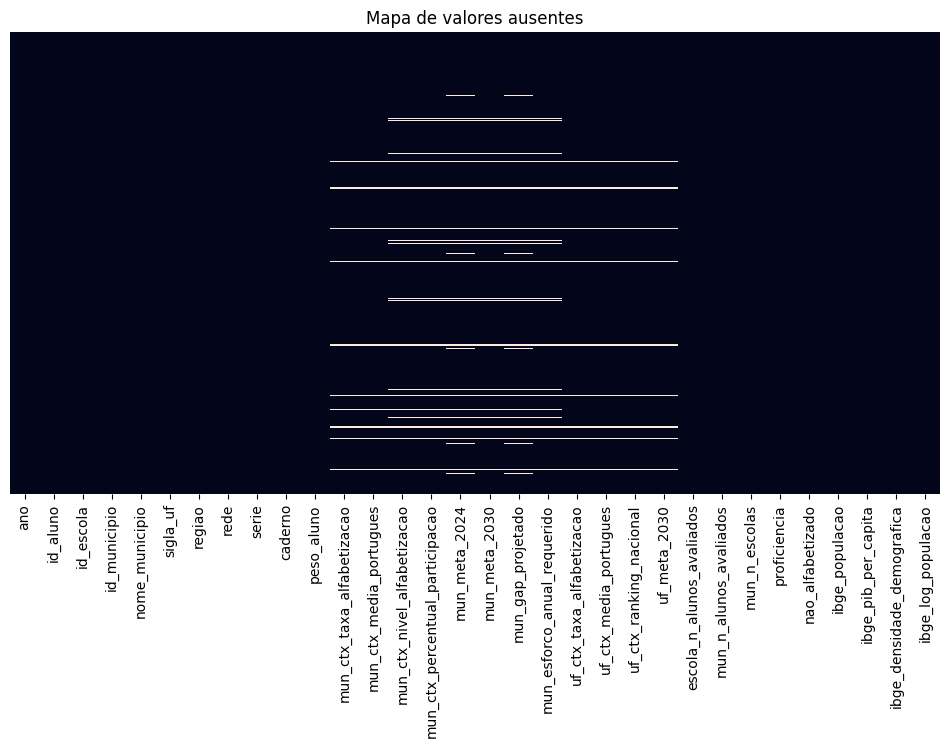

In [9]:
# Verificando os valores faltantes (cada traço claro é uma célula vazia)
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Mapa de valores ausentes")
plt.show()

                                 nulos   pct
mun_meta_2024                     2384  4.75
mun_gap_projetado                 2384  4.75
mun_ctx_percentual_participacao   1924  3.84
mun_meta_2030                     1924  3.84
mun_ctx_nivel_alfabetizacao       1924  3.84
mun_esforco_anual_requerido       1924  3.84
mun_ctx_taxa_alfabetizacao         961  1.92
mun_ctx_media_portugues            961  1.92
uf_ctx_taxa_alfabetizacao          912  1.82
uf_ctx_media_portugues             912  1.82
uf_ctx_ranking_nacional            912  1.82
uf_meta_2030                       912  1.82
ibge_densidade_demografica          15  0.03


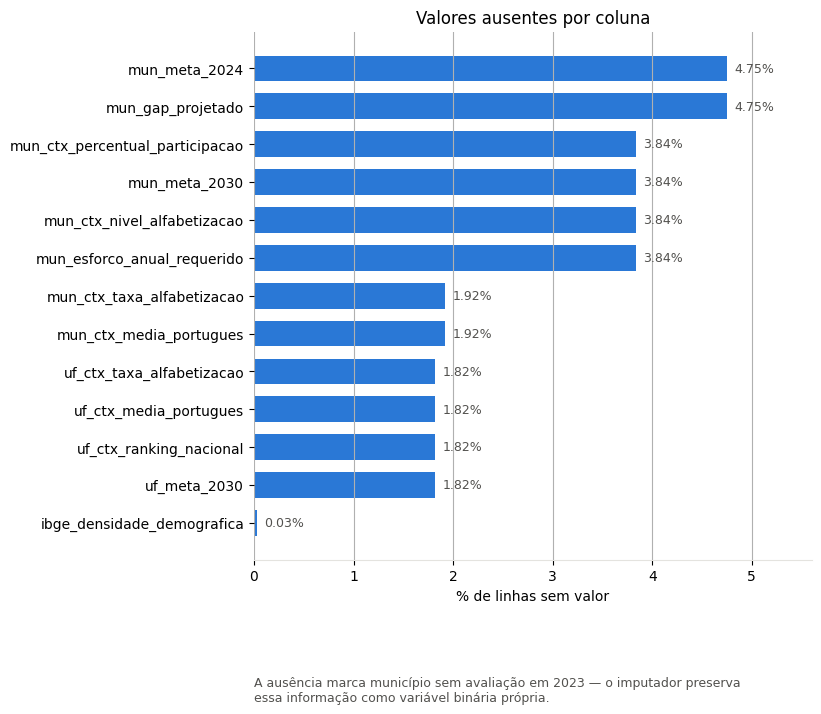

In [10]:
# Verificando os valores faltantes
nulos = pd.DataFrame({
    "nulos": df.isna().sum(),
    "pct": (100 * df.isna().mean()).round(2),
})
nulos = nulos[nulos["nulos"] > 0].sort_values("pct", ascending=False)

if len(nulos):
    print(nulos.to_string())
    fig, ax = plt.subplots(figsize=(7.2, 0.42 * len(nulos) + 1.4))
    barras_horizontais(ax, nulos.index.tolist(), nulos["pct"].tolist(), formato="{:.2f}%")
    ax.set_title("Valores ausentes por coluna")
    ax.set_xlabel("% de linhas sem valor")
    anota(ax, "A ausência marca município sem avaliação em 2023 — o imputador preserva\n"
              "essa informação como variável binária própria.")
    salva(fig, "projeto_nulos.png"); plt.show()
else:
    print("nenhuma coluna com valores ausentes")

In [11]:
# De quais estados são as crianças sem o contexto de 2023?
df[df["mun_ctx_taxa_alfabetizacao"].isnull()]["sigla_uf"].value_counts()

sigla_uf
DF    606
AC    306
SP     41
MG      7
PR      1
Name: count, dtype: int64

**Qualidade Geral dos Dados:**

- **19 das 32 colunas estão 100% completas**; nenhuma coluna passa de 5% de ausência
- As colunas de identificação, da prova e o alvo não têm nenhum valor vazio

**Problema Específico:**

- A ausência se concentra nas colunas de **contexto de 2023** (`mun_ctx_*`, `uf_ctx_*`, metas): 1,8% a 4,75% das linhas
- No gráfico de barras, `mun_meta_2024` e `mun_gap_projetado` lideram (**4,75%**), seguidas das demais colunas de 2023 (3,84%, 1,92% e 1,82%); `ibge_densidade_demografica` quase não aparece (0,03%)
- No mapa, as faixas claras aparecem **nas mesmas linhas** em várias colunas ao mesmo tempo: quando falta uma informação de 2023, faltam todas

**A ausência não é aleatória — ela é informação:**

- Quase todas as crianças sem contexto são do **Distrito Federal (606)** e do **Acre (306)**: esses dois estados **não participaram da avaliação de 2023**
- Não existe "taxa de 2023" para quem não fez a prova em 2023. O valor vazio conta a história de que aquela rede entrou no programa só em 2024
- `ibge_densidade_demografica` tem só 15 linhas vazias (0,03%), irrelevante

**Decisão:** não apagar essas linhas. Na modelagem os vazios serão preenchidos com a mediana, **mantendo uma marca** de que ali faltava informação.

### <font color='#F37126'> 1.5. Estatística descritiva

#### Separando os tipos de variáveis

In [12]:
# Colunas numéricas
num_attributes = df.select_dtypes(include="number")
# Colunas categóricas
cat_attributes = df.select_dtypes(exclude="number")

print(f"numéricas: {num_attributes.shape[1]}  |  categóricas: {cat_attributes.shape[1]}")

numéricas: 23  |  categóricas: 9


#### Colunas numéricas

In [13]:
# Visualizando a estatísticas descritivas
df.describe().round(2)

,ano,peso_aluno,mun_ctx_taxa_alfabetizacao,mun_ctx_media_portugues,mun_ctx_nivel_alfabetizacao,mun_ctx_percentual_participacao,mun_meta_2024,mun_meta_2030,mun_gap_projetado,mun_esforco_anual_requerido,uf_ctx_taxa_alfabetizacao,uf_ctx_media_portugues,uf_ctx_ranking_nacional,uf_meta_2030,escola_n_alunos_avaliados,mun_n_alunos_avaliados,mun_n_escolas,proficiencia,nao_alfabetizado,ibge_populacao,ibge_pib_per_capita,ibge_densidade_demografica,ibge_log_populacao
count,50169.0,50169.00,49208.00,49208.00,48245.0,48245.00,47785.00,48245.0,47785.00,48245.00,49257.00,49257.00,49257.00,49257.0,50169.00,50169.00,50169.00,50169.00,50169.00,50169.00,50169.00,50154.00,50169.00
mean,2024.0,1.14,56.59,745.58,2.2,87.69,59.11,80.0,2.33,3.33,56.44,745.41,11.49,80.0,68.72,8583.44,118.84,749.46,0.40,1109875.18,52260.23,1306.43,11.89
std,0.0,0.20,15.53,20.16,1.4,5.67,12.41,0.0,5.61,2.22,10.89,14.52,6.13,0.0,43.88,21528.55,260.96,47.12,0.49,2773784.41,47283.89,2429.41,2.02
min,2024.0,1.00,4.56,673.30,0.0,70.03,8.25,80.0,-61.27,-2.86,31.30,713.13,1.00,80.0,5.00,7.00,1.00,599.96,0.00,921.00,6841.00,0.13,6.83
25%,2024.0,1.03,46.67,733.91,1.0,84.24,49.77,80.0,1.47,2.01,51.91,737.30,7.00,80.0,37.00,312.00,8.00,720.98,0.00,30870.00,24722.74,29.99,10.34
50%,2024.0,1.09,55.98,743.17,2.0,87.72,59.17,80.0,3.82,3.40,52.20,741.60,13.00,80.0,59.00,1151.00,24.00,754.32,0.00,119128.00,42251.60,136.78,11.69
75%,2024.0,1.19,65.94,753.88,3.0,91.76,68.13,80.0,5.45,4.76,61.38,751.71,15.00,80.0,90.00,4279.00,75.00,780.54,1.00,502899.00,66892.31,1102.80,13.13
max,2024.0,18.31,100.00,868.46,5.0,100.00,80.00,80.0,56.75,10.78,84.46,795.68,24.00,80.0,368.00,94373.00,1110.00,900.89,1.00,11895578.00,679626.68,13024.56,16.29


**Variável Target (nao_alfabetizado):**

- Média de **0,40**: cerca de **4 em cada 10 crianças não estão alfabetizadas**
- Desbalanceamento **moderado** (40% x 60%), não extremo — veremos em detalhe na seção 1.7

**A prova (proficiencia):**

- Nota média de **749 pontos**, mediana de **754**: a criança "do meio" passa um pouco acima do corte de 743
- Vai de 600 a 901 pontos; 25% das crianças ficam abaixo de 721 pontos, bem longe da alfabetização

**Contexto do município em 2023:**

- `mun_ctx_taxa_alfabetizacao`: em média **56,6%** das crianças eram alfabetizadas, mas vai de **4,6% a 100%** — municípios muito diferentes entre si
- `mun_meta_2024`: meta média de **59,1%**, ou seja, esperava-se subir cerca de **2,3 pontos** em um ano (`mun_gap_projetado`)
- `mun_ctx_media_portugues`: média de **745,6 pontos** — a média nacional passa raspando pela régua de 743

**Contexto do estado em 2023:**

- `uf_ctx_taxa_alfabetizacao` vai de **31,3% a 84,5%**: o estado onde a criança mora já diz muito
- `mun_meta_2030` e `uf_meta_2030` são **sempre 80**: desvio padrão zero, não servem para diferenciar ninguém

**Tamanho da rede e IBGE:**

- `ibge_populacao`: mediana de **119 mil** habitantes, mas média de **1,1 milhão** — a média é puxada por metrópoles como São Paulo (11,9 milhões)
- `mun_n_alunos_avaliados`: mediana de 1.151 crianças, máximo de 94.373 — o mesmo efeito das cidades grandes
- `ibge_pib_per_capita`: de R\$ 6,8 mil a R\$ 680 mil por habitante — desigualdade enorme entre municípios

**Implicações para Modelagem:**

- Quando **média e mediana estão longe**, há valores muito altos puxando a média (caudas longas)
- Colunas constantes (`ano`, `serie`, metas 2030) podem ser descartadas
- `proficiencia` **não pode entrar no modelo**: ela é a própria resposta (ver seção de vazamento)

**O dataset é representativo para analisar o risco de não alfabetização no Brasil.**

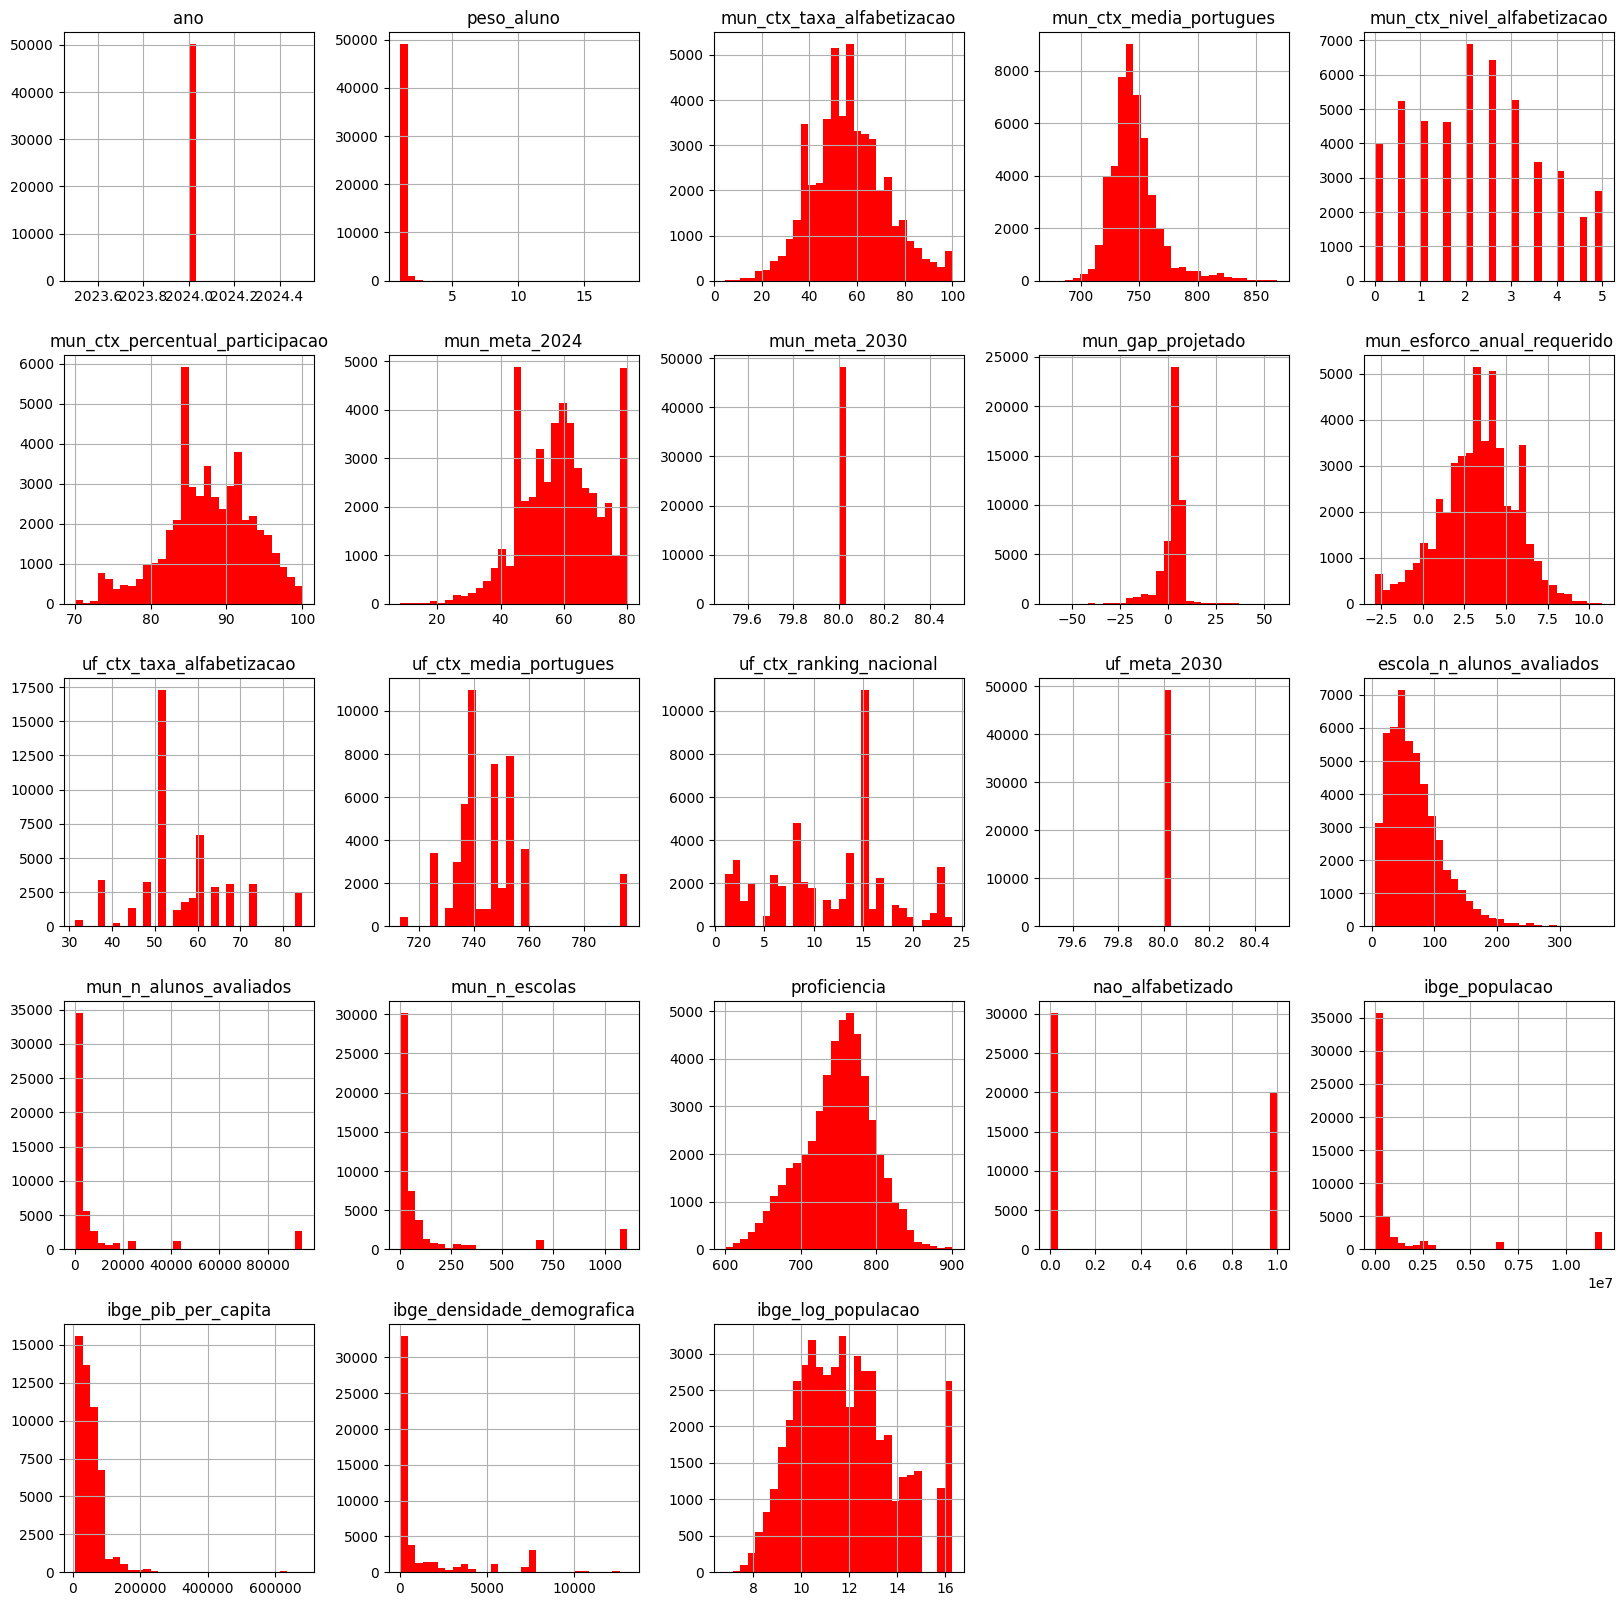

In [14]:
# Histograma para ver a distribuição dos dados
num_attributes.hist(bins=30, figsize=(20, 20), color="r");

**Distribuições das Variáveis:**

- `ano`, `mun_meta_2030`, `uf_meta_2030`: uma única barra — **valor constante**, não carregam informação

**Prova e alvo:**

- `proficiencia`: formato de **sino** centrado perto de 750 pontos — a maioria das crianças fica perto do corte de 743, o que torna a previsão difícil
- `nao_alfabetizado`: duas barras, a de 0 (alfabetizado) maior que a de 1 — confirma os 60/40

**Taxas e notas de 2023 (município e estado):**

- `mun_ctx_taxa_alfabetizacao` e `mun_ctx_media_portugues`: aproximadamente em forma de sino, **bem distribuídas**
- `uf_ctx_*`: barras separadas, porque existem só 24 estados com dados — cada barra é um estado

**Tamanho da rede e IBGE:**

- `ibge_populacao`, `ibge_densidade_demografica`, `mun_n_alunos_avaliados`, `mun_n_escolas`: quase tudo concentrado à esquerda com uma cauda longa à direita
- Isso é o retrato do Brasil: **milhares de municípios pequenos e poucas metrópoles**
- `ibge_log_populacao`: a mesma população em escala logarítmica fica **em forma de sino** — é por isso que ela existe

**Implicações:**

- Colunas constantes devem ser ignoradas
- Variáveis com cauda longa podem ser transformadas (log) ou usadas em modelos de árvore, que não se incomodam com isso
- `peso_aluno`: 89% dos valores ficam entre 1,0 e 1,3, com raros casos chegando a 18 — pouca variação, provavelmente pouca utilidade

#### Colunas Categóricas

In [15]:
# Verificando a quantidade de valores únicos das colunas
cat_attributes.apply(lambda x: x.unique().shape[0])

id_aluno          50169
id_escola         25581
id_municipio       4741
nome_municipio     4524
sigla_uf             26
regiao                5
rede                  2
serie                 1
caderno              22
dtype: int64

In [16]:
# Verificando os valores únicos das colunas (só as que têm poucas categorias)
for coluna in ["rede", "regiao", "serie", "sigla_uf", "caderno"]:
    print(f"{coluna}: {sorted(cat_attributes[coluna].unique())}\n")

rede: ['estadual', 'municipal']

regiao: ['Centro-Oeste', 'Nordeste', 'Norte', 'Sudeste', 'Sul']

serie: ['2']

sigla_uf: ['AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RS', 'SC', 'SE', 'SP', 'TO']

caderno: ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '3', '4', '43', '5', '6', '7', '8', '9']



**Observações:**

- `rede`: apenas **municipal** e **estadual** — 87% das crianças estudam em rede municipal
- `regiao`: as 5 regiões aparecem; o **Sudeste** concentra 41% das crianças e o **Nordeste** 25%
- `sigla_uf`: 26 unidades da federação representadas (incluindo o DF); **SP** sozinho tem 22% das crianças
- `serie`: só o **2º ano** — coluna constante
- `caderno`: 22 versões da prova, bem equilibradas (~5% cada)
- `id_aluno`, `id_escola`, `id_municipio`, `nome_municipio`: milhares de valores, são **códigos de identificação** e por isso não listamos

### <font color='#F37126'> 1.6. Verificando outliers

**Outlier** é um valor muito distante da maioria. Usamos a **regra do IQR**: calculamos a faixa
onde está a metade central dos dados (entre 25% e 75%) e consideramos outlier tudo que fica
mais de 1,5 vez essa faixa para baixo ou para cima.

In [17]:
# Verificando os outliers pela regra do IQR
def resumo_outliers(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    inf, sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    fora = ((serie < inf) | (serie > sup)).sum()
    return {"qtd_outliers": fora,
            "pct_outliers": round(100 * fora / serie.notna().sum(), 2),
            "limite_inf": round(inf, 2), "limite_sup": round(sup, 2),
            "minimo": round(serie.min(), 2), "maximo": round(serie.max(), 2)}

tabela_outliers = pd.DataFrame(
    {c: resumo_outliers(num_attributes[c].dropna()) for c in num_attributes.columns}
).T.sort_values("pct_outliers", ascending=False)
tabela_outliers

,qtd_outliers,pct_outliers,limite_inf,limite_sup,minimo,maximo
ibge_densidade_demografica,8563.0,17.07,-1579.22,2712.01,0.13,13024.56
ibge_populacao,7811.0,15.57,-677173.50,1210942.50,921.00,11895578.00
mun_n_escolas,6980.0,13.91,-92.50,175.50,1.00,1110.00
mun_n_alunos_avaliados,6853.0,13.66,-5638.50,10229.50,7.00,94373.00
uf_ctx_taxa_alfabetizacao,6297.0,12.78,37.70,75.59,31.30,84.46
mun_gap_projetado,5825.0,12.19,-4.50,11.42,-61.27,56.75
uf_ctx_media_portugues,2900.0,5.89,715.68,773.33,713.13,795.68
mun_ctx_media_portugues,2560.0,5.20,703.97,783.82,673.30,868.46
peso_aluno,2446.0,4.88,0.79,1.43,1.00,18.31
escola_n_alunos_avaliados,1557.0,3.10,-42.50,169.50,5.00,368.00


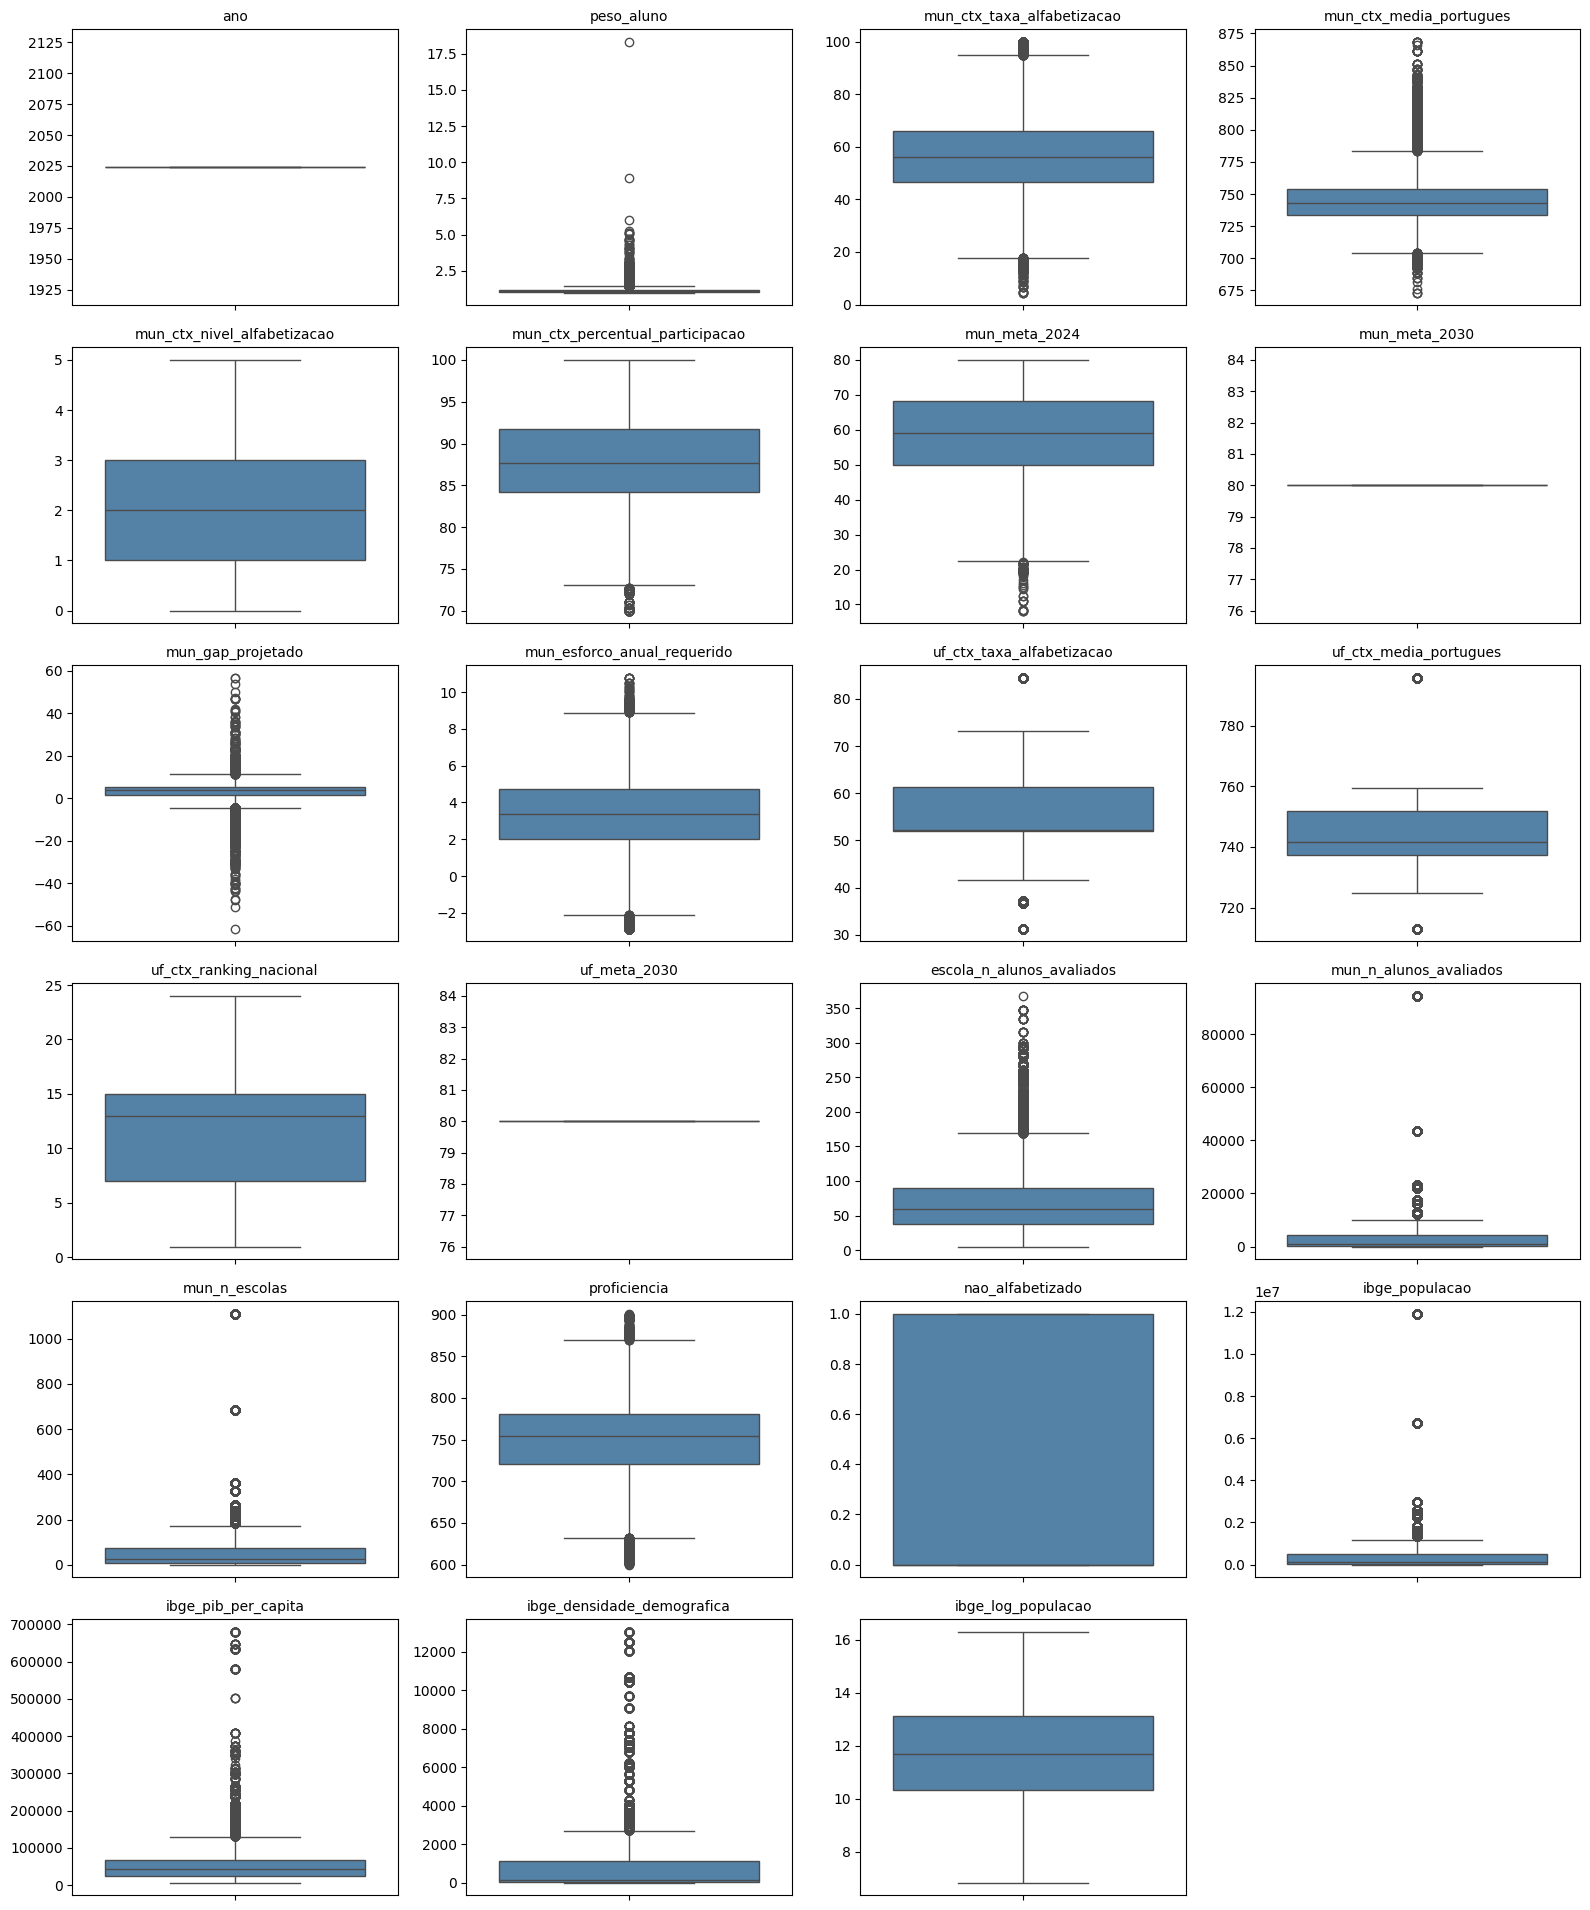

In [18]:
# Boxplot de cada variável numérica
colunas = num_attributes.columns
n_col = 4
n_lin = int(np.ceil(len(colunas) / n_col))

fig, axes = plt.subplots(n_lin, n_col, figsize=(16, 3.2 * n_lin))
for ax, coluna in zip(axes.ravel(), colunas):
    sns.boxplot(y=num_attributes[coluna], ax=ax, color="steelblue")
    ax.set_title(coluna, fontsize=10)
    ax.set_ylabel("")
for ax in axes.ravel()[len(colunas):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

In [19]:
# Quais municípios aparecem como outliers de população?
limite = tabela_outliers.loc["ibge_populacao", "limite_sup"]
(df[df["ibge_populacao"] > limite]
   .drop_duplicates("id_municipio")
   .nlargest(10, "ibge_populacao")[["nome_municipio", "sigla_uf", "ibge_populacao", "ibge_densidade_demografica"]])

,nome_municipio,sigla_uf,ibge_populacao,ibge_densidade_demografica
8559,São Paulo,SP,11895578.0,7387.69
3324,Rio de Janeiro,RJ,6729894.0,5265.81
16800,Brasília,DF,2982818.0,444.07
995,Fortaleza,CE,2574412.0,7786.52
2176,Salvador,BA,2568928.0,3859.35
2339,Belo Horizonte,MG,2416339.0,7167.02
174,Manaus,AM,2279686.0,158.06
8922,Curitiba,PR,1829225.0,4024.84
1650,Recife,PE,1587707.0,7037.61
16549,Goiânia,GO,1494599.0,1776.75


**Proporção de Outliers:**

- As colunas com mais outliers são as de **tamanho**: `ibge_densidade_demografica` (~17%), `ibge_populacao` (~16%), `mun_n_escolas` e `mun_n_alunos_avaliados` (~14%)
- As taxas e notas de 2023 do município têm poucos (2% a 5%)
- `proficiencia`, a nota da prova, tem só ~1%

**Características dos Outliers Identificados:**

- Padrões Observados:

    - Os outliers de população são as **capitais e grandes cidades** (São Paulo, Rio de Janeiro, Brasília, Salvador...)
    - `uf_ctx_taxa_alfabetizacao` (~13%) marca estados inteiros que fogem da média: o **Ceará**, muito acima (84,5%), e **Bahia, Rio Grande do Norte e Sergipe**, muito abaixo (31% a 37%)
    - `mun_gap_projetado` (~12%) mostra municípios que precisavam subir muito ou que já estavam acima da meta (16% têm gap negativo)

- Insights:

    - Esses valores **não são erros de digitação**: São Paulo tem mesmo 11,9 milhões de habitantes
    - A regra do IQR imagina dados "em forma de sino"; em população e PIB ela aponta **desigualdade real**, não sujeira

**Implicações para Análise:**

- Decisão Crítica:

    - **NÃO remover** os outliers — apagar as grandes cidades seria apagar justamente onde estuda a maior parte das crianças
    - Usar a versão em **log** da população (`ibge_log_populacao`), que tem 0% de outliers
    - Preferir **modelos de árvore**, que não são afetados por valores extremos

### <font color='#F37126'> 1.7. Verificando o balanceamento da variável alvo

In [20]:
# Quantidade e percentual de cada classe
aux1 = df[ALVO].value_counts()
aux2 = (df[ALVO].value_counts(normalize=True) * 100).apply(lambda x: f"{x:.2f}%")

result = pd.concat([aux1, aux2], axis=1)
result.index = result.index.map({0: "0 - alfabetizado", 1: "1 - não alfabetizado"})
result

,count,proportion
nao_alfabetizado,,
0 - alfabetizado,30121,60.04%
1 - não alfabetizado,20048,39.96%


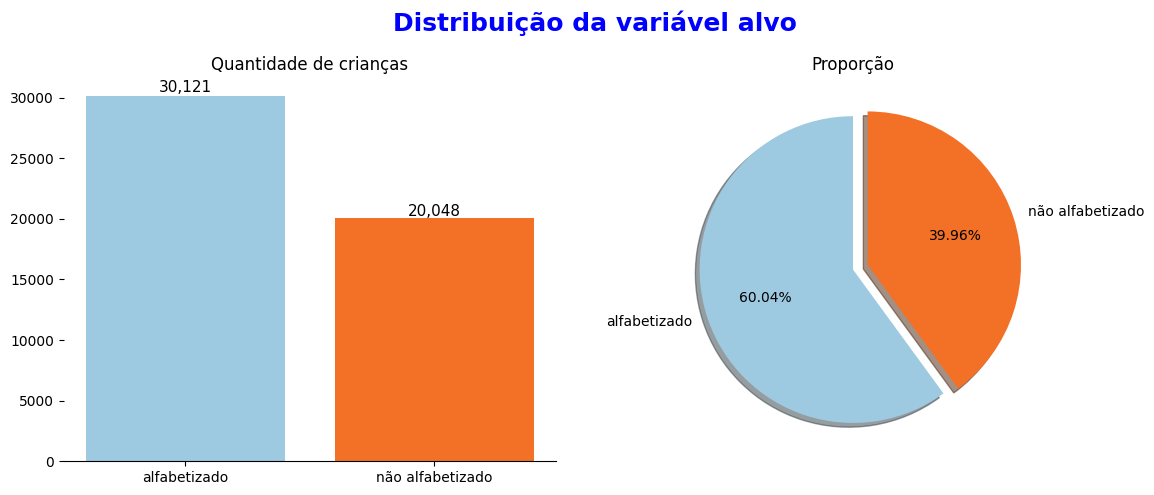

In [21]:
# Visualizando graficamente
contagem = df[ALVO].value_counts().sort_index()
rotulos = ["alfabetizado", "não alfabetizado"]
cores = ["#9ecae1", "#F37126"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Distribuição da variável alvo", fontsize=18, fontweight="bold", color="blue")

# Gráfico de barras
ax1.bar(rotulos, contagem.values, color=cores)
for i, v in enumerate(contagem.values):
    ax1.text(i, v * 1.01, f"{v:,}", ha="center", fontsize=11)
ax1.set_title("Quantidade de crianças")
ax1.spines[["top", "right", "left"]].set_visible(False)

# Gráfico de pizza
ax2.pie(contagem.values, labels=rotulos, colors=cores, autopct="%.2f%%",
        explode=[0, 0.1], shadow=True, startangle=90)
ax2.set_title("Proporção")

plt.tight_layout()
plt.show()

**Desbalanceamento Moderado da Variável Target:**

- **60,04%** das crianças estão alfabetizadas (classe 0) — 30.121 crianças
- **39,96%** não estão alfabetizadas (classe 1) — 20.048 crianças
- Proporção de **1,5 para 1** entre as classes

**Implicações para Modelagem:**

- Não é um desbalanceamento extremo:

    - A classe de interesse (não alfabetizado) tem **muitos exemplos** para o modelo aprender
    - Não precisamos criar dados artificiais (como SMOTE); basta **dar mais peso** à classe 1 nos algoritmos

- Cuidado com a acurácia:

    - Um modelo que dissesse "**todas as crianças estão alfabetizadas**" acertaria 60% e seria **inútil**
    - O pior erro aqui é **deixar de identificar** uma criança em risco (ela fica sem reforço)

- Métricas Adequadas:

    - **Recall**: de todas as crianças não alfabetizadas, quantas o modelo encontrou
    - **Precisão**: das crianças que o modelo apontou, quantas estavam de fato em risco
    - **PR-AUC**: resume precisão e recall; um modelo que "chuta" tira **0,40** — esse é o piso a ser batido
    - **Matriz de confusão** para enxergar acertos e erros de cada classe

### 🛡️ Remoção de variáveis com vazamento (*data leakage*)

**Vazamento** acontece quando o modelo recebe uma informação que **já contém a resposta**. Ele
tira nota alta no treino, mas não funciona no mundo real — é como fazer a prova com o gabarito na mão.

Dois grupos de colunas **nunca chegam ao modelo**:

**1. Vazamento por definição.** `proficiencia` *é* a resposta: a criança é alfabetizada quando
`proficiencia >= 743`. Junto dela saem as médias do município calculadas **no mesmo ano de 2024**
(`taxa_alfabetizacao`, `media_portugues`), que são resumos da própria resposta.

**2. Vazamento descoberto na análise.** Algumas colunas parecem ser de 2023, mas foram
calculadas **sem separar o ano** e acabam carregando informação de 2024. O teste usado: se a coluna
se parece **mais com o resultado de 2024 do que com o de 2023**, ela está "vendo o futuro" e é vetada.
Também saem as colunas **constantes** (metas de 2030 sempre iguais a 80).

Essas colunas continuam na tabela **de propósito**, para que qualquer pessoa possa conferir o
diagnóstico. Elas só são retiradas no momento de montar os dados do modelo.

In [22]:
# Listando as variáveis com data leakage
print("VETADAS POR DEFINIÇÃO (são a resposta ou resumos dela)")
for c in COLUNAS_LEAKAGE:
    marca = "presente na base" if c in df.columns else "não está na base"
    print(f"  · {c:<28} {marca}")

print("\nVETADAS PELO DIAGNÓSTICO DA ANÁLISE")
for c, motivo in COLUNAS_VETADAS_DIAGNOSTICO.items():
    print(f"  · {c}")
    print(f"      {motivo}")

print(f"\nsobram {len(FEATURES)} variáveis liberadas para o modelo")

VETADAS POR DEFINIÇÃO (são a resposta ou resumos dela)
  · proficiencia                 presente na base
  · alfabetizado                 não está na base
  · alfabetizado_flag            não está na base
  · media_portugues              não está na base
  · nivel_alfabetizacao          não está na base
  · taxa_alfabetizacao           não está na base
  · gap_meta                     não está na base
  · atingiu_meta                 não está na base
  · pct_alfabetizados            não está na base
  · proficiencia_media           não está na base

VETADAS PELO DIAGNÓSTICO DA ANÁLISE
  · mun_ctx_nivel_alfabetizacao
      corr com taxa_2024 (0,856) > corr com taxa_2023 (0,834): o nivel do INEP foi recalibrado com o resultado de 2024, entao antecipa o alvo
  · mun_ctx_percentual_participacao
      corr com taxa_2024 (0,363) > corr com taxa_2023 (0,248): a taxa de participacao registrada e a da coleta de 2024
  · mun_meta_2030
      constante em 80,0 para todos os municipios — variancia 

**Nota:**

- **Só `proficiencia` está na base** entre as vetadas por definição — as demais nem chegaram a ser carregadas
- **5 colunas vetadas pelo diagnóstico**: 2 "enxergam" 2024 (`mun_ctx_nivel_alfabetizacao`, `mun_ctx_percentual_participacao`),
  2 são constantes (`mun_meta_2030`, `uf_meta_2030`) e 1 é derivada de uma constante (`mun_esforco_anual_requerido`)
- Identificadores como `id_aluno`, `ano` e `nome_municipio` também não entram: não dizem nada sobre o risco
- O modelo trabalhará apenas com o que se sabe **antes da prova**: onde a criança estuda, a rede e como aquele território estava em 2023

## 3 - **ANÁLISE EXPLORATÓRIA DOS DADOS**

### <font color='#F37126'> 4.1. Criação das Hipóteses

A base não traz **nenhum atributo individual da criança** — não há renda familiar,
escolaridade dos pais, frequência, defasagem idade-série ou infraestrutura da escola. Os
microdados públicos do Indicador Criança Alfabetizada simplesmente não os publicam.

Isso define de saída o que o modelo pode e não pode fazer: ele prevê **exposição ao risco**
a partir do contexto — território, rede, escola, histórico local — e não a trajetória
individual. Cada hipótese abaixo testa um desses canais e decide se a variável merece
entrar no modelo.

**Hipóteses Individuais (colunas isoladas)**

| # | Hipótese | Variável testada |
|---|---|---|
| H1 | O território determina o risco | `regiao`, `sigla_uf` |
| H2 | O passado do município antecipa o presente | `mun_ctx_taxa_alfabetizacao` (2023) |
| H3 | A rede de ensino separa desempenhos | `rede` |
| H4 | A riqueza do município protege | `ibge_pib_per_capita` |
| H5 | Municípios abaixo da meta de 2024 têm mais risco | `mun_gap_projetado` |
| H6 | O risco aumenta com o tamanho do município | `ibge_populacao` |
| H7 | Escolas pequenas têm mais risco | `escola_n_alunos_avaliados` |

**Hipóteses Combinadas (entre colunas)**

| # | Hipótese | Variáveis testadas |
|---|---|---|
| H8 | Histórico ruim em 2023 **e** Norte/Nordeste têm risco muito maior | `mun_ctx_taxa_alfabetizacao` + `regiao` |
| H9 | Município pobre **e** histórico ruim em 2023 têm risco muito maior | `ibge_pib_per_capita` + `mun_ctx_taxa_alfabetizacao` |

### <font color='#F37126'> 4.2. Hipóteses Individuais (colunas isoladas)

#### H1 — Histórico territorial

**Hipótese.** A taxa de não alfabetização varia sistematicamente entre regiões e UFs, e a
diferença é grande o bastante para ser sinal, não ruído amostral.

**Teste.** Qui-quadrado de independência entre a categórica e o alvo, com o **V de Cramér**
como medida de força — apropriado para variáveis nominais, e comparável entre colunas com
número diferente de categorias.

In [23]:
# Teste de hipótese: associação entre território e não alfabetização
def cramers_v(x, y):
    tabela = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(tabela)[0]
    n = tabela.to_numpy().sum()
    r, k = tabela.shape
    # correção de viés de Bergsma para tabelas grandes
    phi2 = max(0, chi2 / n - (k - 1) * (r - 1) / (n - 1))
    r_c = r - (r - 1) ** 2 / (n - 1)
    k_c = k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2 / max(min(k_c - 1, r_c - 1), 1e-12))

for coluna in ["regiao", "sigla_uf"]:
    tabela = pd.crosstab(df[coluna], df[ALVO])
    chi2, p, gl, _ = stats.chi2_contingency(tabela)
    v = cramers_v(df[coluna], df[ALVO])
    print(f"{coluna:<10} chi2={chi2:>10,.0f}  gl={gl:<3} p={p:.3g}  V de Cramér={v:.4f}")

regiao     chi2=       250  gl=4   p=5.24e-53  V de Cramér=0.0701


sigla_uf   chi2=     2,643  gl=25  p=0  V de Cramér=0.2284


**Nota:**

- **O V de Cramér mede a força da ligação entre duas variáveis de categorias**, numa escala de 0
  a 1. Zero significa nenhuma relação; acima de 0,2 já é uma associação relevante em dados sociais.
- `sigla_uf` marca **0,2284** e `regiao` apenas **0,0701**. O estado carrega cerca de **três vezes
  mais informação** sobre o risco do que a região — juntar tudo em cinco regiões apaga o sinal.
- O valor-p muito pequeno só confirma que a associação não é acaso. Com 50 mil linhas, quase
  tudo é "significativo"; **o que importa é o tamanho do efeito**, não o p.

In [24]:
# Contagem e proporção de não alfabetizados em cada região
por_regiao = (df.groupby("regiao", observed=True)[ALVO]
                .agg(alunos="size", nao_alfabetizados="sum", taxa="mean")
                .assign(taxa=lambda d: (100 * d["taxa"]).round(2))
                .sort_values("taxa", ascending=False))
print(por_regiao.to_string())

media_nacional = 100 * df[ALVO].mean()
print(f"\nmédia nacional: {media_nacional:.2f}%")
print(f"amplitude entre a pior e a melhor região: "
      f"{por_regiao['taxa'].max() - por_regiao['taxa'].min():.1f} pontos percentuais")

              alunos  nao_alfabetizados   taxa
regiao                                        
Norte           5098               2417  47.41
Nordeste       12625               5401  42.78
Sul             7351               2890  39.31
Sudeste        20321               7663  37.71
Centro-Oeste    4774               1677  35.13

média nacional: 39.96%
amplitude entre a pior e a melhor região: 12.3 pontos percentuais


**Nota:**

- Do Norte (**47,4%**) ao Centro-Oeste (**35,1%**) são **12,3 pontos percentuais** de diferença.
- É bastante, mas é a menor das diferenças territoriais: entre estados ela chega a **51 pontos**.
- Na prática, **uma criança do Norte tem cerca de 1,35 vez mais chance de não se alfabetizar**
  do que uma do Centro-Oeste.

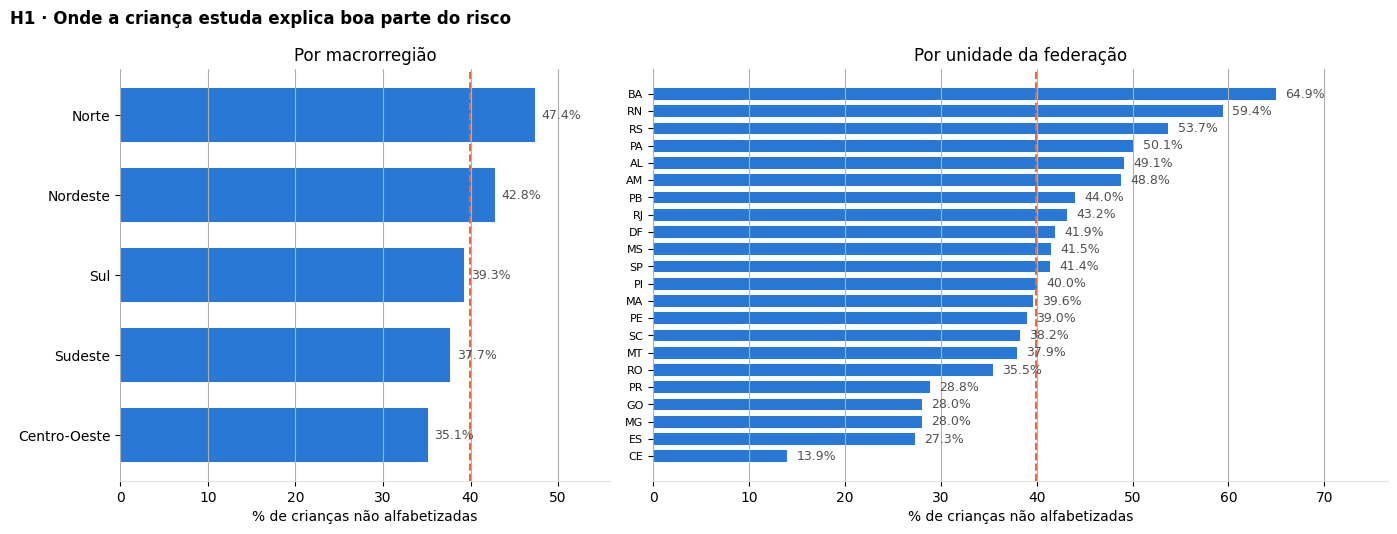

In [25]:
# Visualizando o ranking por UF
por_uf = (df.groupby("sigla_uf", observed=True)[ALVO]
            .agg(alunos="size", taxa="mean")
            .query("alunos >= 500")
            .assign(taxa=lambda d: 100 * d["taxa"])
            .sort_values("taxa", ascending=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.4),
                               gridspec_kw={"width_ratios": [1, 1.5]})

barras_horizontais(ax1, por_regiao.index.tolist(), por_regiao["taxa"].tolist(),
                   formato="{:.1f}%")
ax1.axvline(media_nacional, color=LARANJA, linewidth=1.4, linestyle="--")
ax1.set_title("Por macrorregião")
ax1.set_xlabel("% de crianças não alfabetizadas")

barras_horizontais(ax2, por_uf.index.tolist(), por_uf["taxa"].tolist(), formato="{:.1f}%")
ax2.axvline(media_nacional, color=LARANJA, linewidth=1.4, linestyle="--")
ax2.set_title("Por unidade da federação")
ax2.set_xlabel("% de crianças não alfabetizadas")
ax2.tick_params(axis="y", labelsize=8)

fig.suptitle("H1 · Onde a criança estuda explica boa parte do risco",
             x=0.005, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout()
salva(fig, "projeto_h1_territorio.png"); plt.show()

**H1 é confirmada.** O teste descarta que a diferença seja acaso, e o estado (`sigla_uf`) é a
variável de categoria com a ligação mais forte com o alvo.

A distância entre estados é enorme: no **Ceará só 13,9%** das crianças não estão alfabetizadas,
enquanto na **Bahia são 64,9%** — uma diferença de **51 pontos percentuais**. Crianças de
estados diferentes enfrentam problemas de tamanhos muito diferentes.

Isso tem uma consequência importante: um modelo que aprende o território **reproduz** a
desigualdade que mede. É uma informação legítima para priorizar recursos, mas não deve ser
usada para rotular crianças individualmente.

#### H2 — Persistência: o passado do município antecipa o presente

**Hipótese.** A taxa de alfabetização do município em **2023** prevê o desempenho dos alunos
em **2024**. Se for verdade, a defasagem temporal que sustenta o desenho anti-vazamento não
custa poder preditivo — ela é o próprio motor do modelo.

**Teste.** Correlação entre a taxa municipal de 2023 e a taxa observada em 2024, no grão de
município. E, no grão de aluno, a taxa de não alfabetização por decil da variável de 2023.

In [26]:
# Teste de hipótese: a taxa de 2023 do município prevê o resultado de 2024
municipio = (df.groupby("id_municipio", observed=True)
               .agg(taxa_2023=("mun_ctx_taxa_alfabetizacao", "first"),
                    alunos=(ALVO, "size"),
                    nao_alfab_2024=(ALVO, "mean"))
               .dropna(subset=["taxa_2023"])
               .query("alunos >= 30"))
municipio["taxa_2024"] = 100 * (1 - municipio["nao_alfab_2024"])

r_pearson, p_pearson = stats.pearsonr(municipio["taxa_2023"], municipio["taxa_2024"])
r_spearman, _ = stats.spearmanr(municipio["taxa_2023"], municipio["taxa_2024"])
print(f"municípios com pelo menos 30 alunos avaliados: {len(municipio):,}")
print(f"correlação de Pearson  taxa_2023 x taxa_2024: {r_pearson:.4f}  (p={p_pearson:.3g})")
print(f"correlação de Spearman ............................ {r_spearman:.4f}")
print(f"R² de uma reta simples: {r_pearson ** 2:.3f} — o passado explica "
      f"{100 * r_pearson ** 2:.0f}% da variação de 2024")

municípios com pelo menos 30 alunos avaliados: 292
correlação de Pearson  taxa_2023 x taxa_2024: 0.7216  (p=3.15e-48)
correlação de Spearman ............................ 0.7074
R² de uma reta simples: 0.521 — o passado explica 52% da variação de 2024


**Nota:**

- **Esta é a correlação que sustenta o projeto inteiro.** Se a taxa de 2023 não antecipasse a
  de 2024, não haveria como prever com um ano de antecedência.
- O valor de **0,72** (numa escala de −1 a 1) é alto para dados sociais: o desempenho de um
  município **muda devagar**, e é justamente essa inércia que dá tempo para agir.
- Só a taxa de 2023 já explica **52%** da variação de 2024 entre os municípios.
- O filtro de 30 crianças avaliadas (292 municípios) evita que cidades com poucas crianças na
  amostra, cuja taxa oscila por acaso, distorçam o resultado.

            alunos   taxa
decil_2023               
1             5544  58.82
2             4329  52.81
3             5001  48.67
4             4853  42.96
5             4878  41.86
6             4966  37.60
7             4875  36.62
8             4933  33.87
9             4911  28.32
10            4918  16.80

risco no decil pior x decil melhor: 3.50x


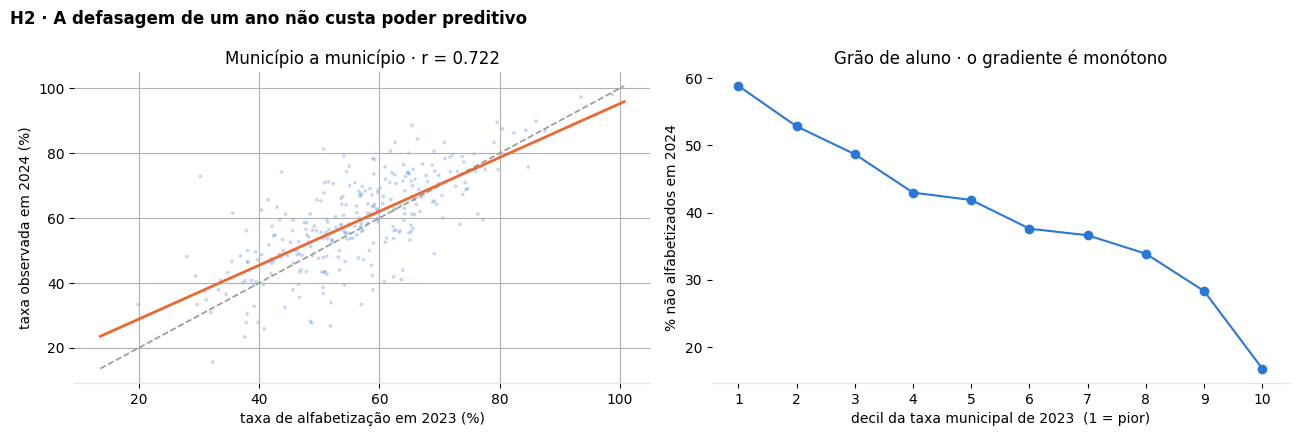

In [27]:
# Taxa de não alfabetização por decil da taxa municipal de 2023
com_ctx = df.dropna(subset=["mun_ctx_taxa_alfabetizacao"]).copy()
com_ctx["decil_2023"] = pd.qcut(com_ctx["mun_ctx_taxa_alfabetizacao"], 10,
                                labels=False, duplicates="drop") + 1
por_decil = (com_ctx.groupby("decil_2023")[ALVO].agg(alunos="size", taxa="mean")
                    .assign(taxa=lambda d: 100 * d["taxa"]))
print(por_decil.round(2).to_string())

razao = por_decil["taxa"].iloc[0] / por_decil["taxa"].iloc[-1]
print(f"\nrisco no decil pior x decil melhor: {razao:.2f}x")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))

amostra_mun = municipio.sample(min(2500, len(municipio)), random_state=SEED)
ax1.scatter(amostra_mun["taxa_2023"], amostra_mun["taxa_2024"], s=7, alpha=0.28,
            color=AZUL, edgecolors="none")
lim = [min(municipio["taxa_2023"].min(), municipio["taxa_2024"].min()) - 2,
       max(municipio["taxa_2023"].max(), municipio["taxa_2024"].max()) + 2]
ax1.plot(lim, lim, color=NEUTRO, linewidth=1.2, linestyle="--")
coef = np.polyfit(municipio["taxa_2023"], municipio["taxa_2024"], 1)
xs = np.linspace(lim[0], lim[1], 50)
ax1.plot(xs, np.polyval(coef, xs), color=LARANJA, linewidth=2)
ax1.set_xlabel("taxa de alfabetização em 2023 (%)")
ax1.set_ylabel("taxa observada em 2024 (%)")
ax1.set_title(f"Município a município · r = {r_pearson:.3f}")
limpa_eixos(ax1); ax1.grid(True)

ax2.plot(por_decil.index, por_decil["taxa"], marker="o", color=AZUL)
ax2.set_xticks(range(1, 11))
ax2.set_xlabel("decil da taxa municipal de 2023  (1 = pior)")
ax2.set_ylabel("% não alfabetizados em 2024")
ax2.set_title("Grão de aluno · o gradiente é monótono")
limpa_eixos(ax2)

fig.suptitle("H2 · A defasagem de um ano não custa poder preditivo",
             x=0.005, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout()
salva(fig, "projeto_h2_persistencia.png"); plt.show()

**H2 é confirmada, e é a hipótese mais importante do notebook.** A correlação entre 2023 e
2024 é de **0,72** e o gráfico da direita desce de forma contínua: nas crianças dos municípios
com pior histórico, **58,8%** não se alfabetizaram; nos de melhor histórico, só **16,8%** — o
risco cai **3,5 vezes**.

É esse resultado que permite todo o projeto. Se o passado não previsse o presente, a única
forma de acertar seria usar dados do próprio ano da prova — e aí o modelo estaria "colando",
não prevendo.

#### H3 — Rede de ensino

**Hipótese.** Redes municipais, estaduais e privadas apresentam taxas distintas, porque
atendem públicos e territórios distintos.

In [28]:
# Teste de hipótese: relação entre rede de ensino e não alfabetização
tabela_rede = pd.crosstab(df["rede"], df[ALVO])
chi2, p, gl, _ = stats.chi2_contingency(tabela_rede)
v_rede = cramers_v(df["rede"], df[ALVO])

por_rede = (df.groupby("rede", observed=True)[ALVO]
              .agg(alunos="size", taxa="mean")
              .assign(taxa=lambda d: (100 * d["taxa"]).round(2))
              .sort_values("taxa", ascending=False))
print(por_rede.to_string())
print(f"\nchi2={chi2:,.0f}  gl={gl}  p={p:.3g}  V de Cramér={v_rede:.4f}")

# Odds ratio entre a pior e a melhor rede
pior, melhor = por_rede.index[0], por_rede.index[-1]
p1, p2 = por_rede.loc[pior, "taxa"] / 100, por_rede.loc[melhor, "taxa"] / 100
odds = (p1 / (1 - p1)) / (p2 / (1 - p2))
print(f"razão de chances {pior} contra {melhor}: {odds:.2f}x")

           alunos   taxa
rede                    
municipal   43580  40.17
estadual     6589  38.55

chi2=6  gl=1  p=0.0125  V de Cramér=0.0102
razão de chances municipal contra estadual: 1.07x


**H3 é confirmada, mas o efeito é muito pequeno.** Na rede municipal **40,2%** das crianças não
estão alfabetizadas; na estadual, **38,6%** — só 1,6 ponto de diferença.

- O V de Cramér é de apenas **0,0102**, mais de 20 vezes menor que o do estado.
- A razão de chances é **1,07**: estudar na rede municipal aumenta a chance em apenas 7%.
- A amostra não tem escolas privadas.

A rede, sozinha, diz pouco. O que realmente separa os resultados é **onde** a escola está.

#### H4 — Comprometimento socioeconômico

**Hipótese.** Municípios mais ricos protegem contra a não alfabetização. O PIB per capita
do IBGE é o proxy disponível.

**Teste.** Correlação ponto-bisserial entre a variável contínua e o alvo binário, e a taxa
por quintil de riqueza.

In [29]:
# Teste de hipótese: relação entre riqueza do município e não alfabetização
socio = df.dropna(subset=["ibge_pib_per_capita"]).copy()
r_pb, p_pb = stats.pointbiserialr(socio[ALVO], socio["ibge_pib_per_capita"])
print(f"correlação ponto-bisserial PIB per capita x alvo: {r_pb:.4f}  (p={p_pb:.3g})")

socio["quintil_pib"] = pd.qcut(socio["ibge_pib_per_capita"], 5, labels=False,
                               duplicates="drop") + 1
por_quintil = (socio.groupby("quintil_pib")[ALVO]
                    .agg(alunos="size", taxa="mean")
                    .assign(taxa=lambda d: (100 * d["taxa"]).round(2)))
print("\n" + por_quintil.to_string())

# Teste de Mann-Whitney: o PIB difere entre os dois grupos do alvo?
u, p_u = stats.mannwhitneyu(
    socio.loc[socio[ALVO] == 1, "ibge_pib_per_capita"],
    socio.loc[socio[ALVO] == 0, "ibge_pib_per_capita"], alternative="two-sided")
print(f"\nMann-Whitney U={u:,.0f}  p={p_u:.3g}")

correlação ponto-bisserial PIB per capita x alvo: -0.0129  (p=0.00375)

             alunos   taxa
quintil_pib               
1             10076  41.43
2              9994  42.12
3             10038  38.48
4             10031  37.58
5             10030  40.20

Mann-Whitney U=293,906,607  p=4.38e-07


**Nota:**

- **A correlação direta é quase nula: −0,0129.** A riqueza do município, sozinha, praticamente
  não distingue quem se alfabetiza de quem não.
- A tabela por quintil mostra por quê: a taxa **não desce de forma ordenada** do mais pobre (1)
  para o mais rico (5). O quintil mais rico (**40,2%**) fica pior que o quarto (**37,6%**).
- O teste de Mann-Whitney diz que a diferença é "significativa", e aí está a lição:
  **com muitas linhas, uma diferença ínfima vira significativa**. Significância não é relevância.

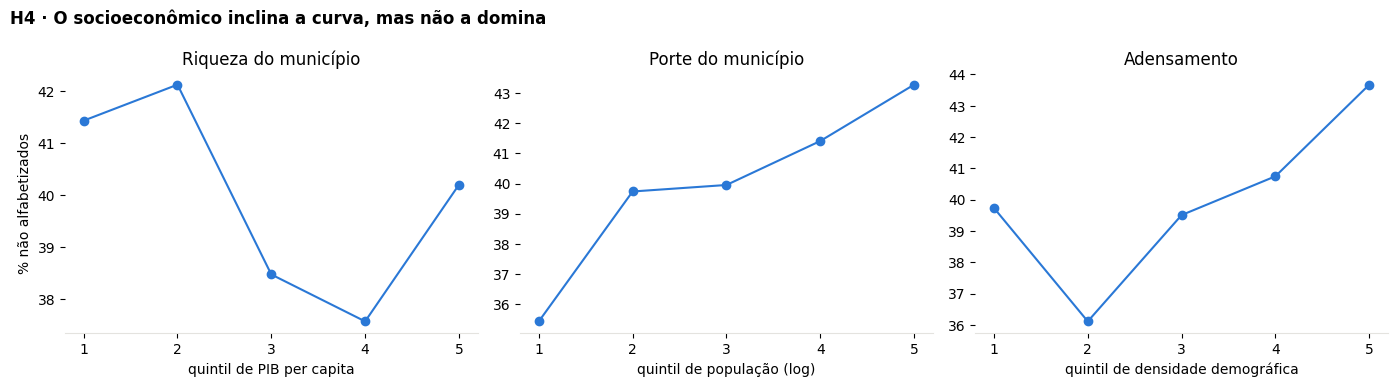

14278

In [30]:
# Visualizando os dois canais socioeconômicos
fig, axes = plt.subplots(1, 3, figsize=(14, 3.9))

axes[0].plot(por_quintil.index, por_quintil["taxa"], marker="o", color=AZUL)
axes[0].set_xticks(range(1, 6))
axes[0].set_xlabel("quintil de PIB per capita")
axes[0].set_ylabel("% não alfabetizados")
axes[0].set_title("Riqueza do município")
limpa_eixos(axes[0])

socio["quintil_pop"] = pd.qcut(socio["ibge_log_populacao"], 5, labels=False,
                               duplicates="drop") + 1
pop = socio.groupby("quintil_pop")[ALVO].mean().mul(100)
axes[1].plot(pop.index, pop.values, marker="o", color=AZUL)
axes[1].set_xticks(range(1, 6))
axes[1].set_xlabel("quintil de população (log)")
axes[1].set_title("Porte do município")
limpa_eixos(axes[1])

socio["quintil_dens"] = pd.qcut(socio["ibge_densidade_demografica"], 5, labels=False,
                                duplicates="drop") + 1
dens = socio.groupby("quintil_dens")[ALVO].mean().mul(100)
axes[2].plot(dens.index, dens.values, marker="o", color=AZUL)
axes[2].set_xticks(range(1, 6))
axes[2].set_xlabel("quintil de densidade demográfica")
axes[2].set_title("Adensamento")
limpa_eixos(axes[2])

fig.suptitle("H4 · O socioeconômico inclina a curva, mas não a domina",
             x=0.005, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout()
salva(fig, "projeto_h4_socioeconomico.png"); plt.show()

del socio
gc.collect()

**H4 não se confirma para a riqueza, mas o porte do município chama atenção.**

- **Riqueza (PIB per capita):** a curva sobe e desce sem padrão. Municípios ricos não protegem
  de forma clara — o PIB é uma média grosseira, que não enxerga a criança pobre dentro de uma
  cidade rica.
- **Porte (população):** aqui há um padrão claro e **contrário ao senso comum**: quanto maior o
  município, **maior** o risco — de **35,4%** nos menores para **43,3%** nos maiores.
- **Adensamento:** os municípios mais densos também têm a taxa mais alta (**43,7%**).

As variáveis do IBGE entram no modelo, mas espera-se que pesem pouco perto do território e do
histórico de 2023.

#### H5 — Meta de 2024

- Hipótese 5: Crianças de municípios que em 2023 estavam **abaixo da meta de 2024** têm maior risco de não se alfabetizar.

A meta é o percentual de alfabetizados que o INEP espera de cada município em 2024. Quando a taxa
de 2023 estava abaixo dela, o município precisava melhorar em um único ano.

In [31]:
print("=== TESTANDO HIPÓTESE 5: META DE 2024 x NÃO ALFABETIZAÇÃO ===\n")

# Só crianças de municípios que têm meta definida
h5 = df.dropna(subset=["mun_gap_projetado"]).copy()
h5["situacao_meta"] = np.where(h5["mun_gap_projetado"] > 0, "abaixo da meta", "já na meta")

# Análise estatística básica
print("=== ANÁLISE ESTATÍSTICA ===")

# Calcular proporções usando groupby
prop_h5 = h5.groupby("situacao_meta")[ALVO].mean() * 100

print(f"Taxa de não alfabetização em municípios JÁ NA META: {prop_h5['já na meta']:.1f}%")
print(f"Taxa de não alfabetização em municípios ABAIXO DA META: {prop_h5['abaixo da meta']:.1f}%")
print(f"Diferença: {prop_h5['abaixo da meta'] - prop_h5['já na meta']:.1f} pontos percentuais")

# Calcular odds (chances) usando groupby
def calcular_odds(grupo):
    nao_alfabetizados = (grupo == 1).sum()
    alfabetizados = (grupo == 0).sum()
    return nao_alfabetizados / alfabetizados if alfabetizados > 0 else 0

odds_h5 = h5.groupby("situacao_meta")[ALVO].apply(calcular_odds)
odds_ratio_h5 = odds_h5["abaixo da meta"] / odds_h5["já na meta"]

print(f"Odds Ratio (abaixo da meta vs já na meta): {odds_ratio_h5:.2f}")

# Contagem absoluta para contexto
contagem = h5.groupby(["situacao_meta", ALVO]).size().unstack(fill_value=0)
contagem.columns = ["alfabetizado (0)", "não alfabetizado (1)"]
print("\n=== CONTAGEM ABSOLUTA ===")
print(contagem)

# Interpretação do resultado
print("\n=== INTERPRETAÇÃO ===")
if odds_ratio_h5 > 1:
    if odds_ratio_h5 >= 3.0:
        forca_associacao = "FORTE"
    elif odds_ratio_h5 >= 1.5:
        forca_associacao = "MODERADA"
    else:
        forca_associacao = "FRACA"

    print("✓ A HIPÓTESE É CONFIRMADA: municípios abaixo da meta têm mais crianças não alfabetizadas")
    print(f"📊 Força da associação: {forca_associacao} (OR = {odds_ratio_h5:.2f})")

    # Verificar magnitude da diferença
    diferenca_percentual = ((prop_h5["abaixo da meta"] / prop_h5["já na meta"]) - 1) * 100
    print(f"📈 A taxa de não alfabetização é {diferenca_percentual:.1f}% maior nos municípios abaixo da meta")

    if odds_ratio_h5 >= 3.0:
        print("🎯 CONCLUSÃO: estar abaixo da meta está FORTEMENTE associado à não alfabetização")
    else:
        print("⚠️  CONCLUSÃO: estar abaixo da meta está associado à não alfabetização, mas não FORTEMENTE")

elif odds_ratio_h5 < 1:
    print("✗ A HIPÓTESE É REJEITADA: municípios abaixo da meta têm MENOS crianças não alfabetizadas")
    print(f"📊 OR = {odds_ratio_h5:.2f} (< 1 indica fator protetor)")

else:
    print("➖ RESULTADO NEUTRO: não há diferença entre os grupos")

# Classificação da força da associação (referência)
print("\n=== REFERÊNCIA DE INTERPRETAÇÃO ===")
print("OR = 1.0: Sem associação")
print("OR = 1.0 - 1.5: Associação fraca")
print("OR = 1.5 - 3.0: Associação moderada")
print("OR = 3.0 - 10.0: Associação forte")
print("OR > 10.0: Associação muito forte")
print("OR < 1.0: Fator protetor (menor risco)")

# Resumo da hipótese
print("\n=== RESUMO DA HIPÓTESE 5 ===")
print("Hipótese testada: 'Municípios abaixo da meta de 2024 têm mais crianças não alfabetizadas'")
if odds_ratio_h5 > 1:
    print("✅ STATUS: CONFIRMADA")
else:
    print("❌ STATUS: REJEITADA")
print(f"📊 Evidência: OR = {odds_ratio_h5:.2f}")

=== TESTANDO HIPÓTESE 5: META DE 2024 x NÃO ALFABETIZAÇÃO ===

=== ANÁLISE ESTATÍSTICA ===
Taxa de não alfabetização em municípios JÁ NA META: 25.4%
Taxa de não alfabetização em municípios ABAIXO DA META: 42.2%
Diferença: 16.8 pontos percentuais
Odds Ratio (abaixo da meta vs já na meta): 2.15

=== CONTAGEM ABSOLUTA ===
                alfabetizado (0)  não alfabetizado (1)
situacao_meta                                         
abaixo da meta             23222                 16956
já na meta                  5678                  1929

=== INTERPRETAÇÃO ===
✓ A HIPÓTESE É CONFIRMADA: municípios abaixo da meta têm mais crianças não alfabetizadas
📊 Força da associação: MODERADA (OR = 2.15)
📈 A taxa de não alfabetização é 66.4% maior nos municípios abaixo da meta
⚠️  CONCLUSÃO: estar abaixo da meta está associado à não alfabetização, mas não FORTEMENTE

=== REFERÊNCIA DE INTERPRETAÇÃO ===
OR = 1.0: Sem associação
OR = 1.0 - 1.5: Associação fraca
OR = 1.5 - 3.0: Associação moderada
OR = 3.

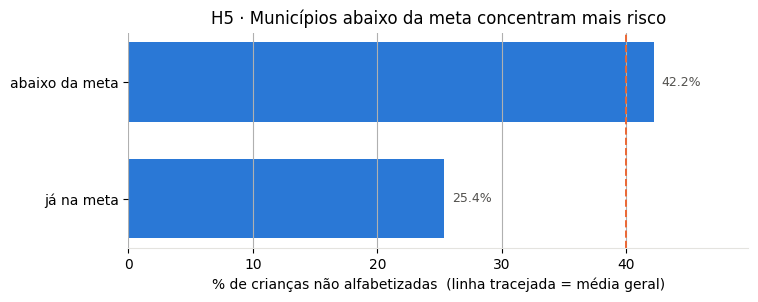

In [32]:
# Visualizando a taxa de não alfabetização por situação da meta
fig, ax = plt.subplots(figsize=(8, 2.8))
barras_horizontais(ax, prop_h5.index.tolist(), prop_h5.values.tolist(), formato="{:.1f}%")
ax.axvline(100 * df[ALVO].mean(), color=LARANJA, linewidth=1.4, linestyle="--")
ax.set_title("H5 · Municípios abaixo da meta concentram mais risco")
ax.set_xlabel("% de crianças não alfabetizadas  (linha tracejada = média geral)")
salva(fig, "projeto_h5_meta.png"); plt.show()

**Nota:**

- Nos municípios que **já estavam na meta**, **25,4%** das crianças não se alfabetizaram. Nos que
  estavam **abaixo da meta**, são **42,2%** — quase **17 pontos** a mais.
- O Odds Ratio é **2,15**: a chance de uma criança não se alfabetizar é **mais que o dobro** quando o
  município está abaixo da meta. É uma associação **moderada**.
- **84% das crianças** (40.178 de 47.785) estudam em municípios que precisavam melhorar.
- **H5 é confirmada.** Ela conversa com a H2: estar abaixo da meta é outra forma de dizer que o
  histórico do município era fraco.

#### H6 — Tamanho do município

- Hipótese 6: A chance de uma criança não se alfabetizar **aumenta com o tamanho do município**.

Na H4 o gráfico "Porte do município" sugeriu esse padrão. Aqui ele é testado por faixas de população.

In [33]:
# =============================================================================
# HIPÓTESE 6: A chance de não se alfabetizar aumenta com o tamanho do município
# =============================================================================

print("=== HIPÓTESE 6: RELAÇÃO POPULAÇÃO x NÃO ALFABETIZAÇÃO ===")

# Calcular correlação entre população e o alvo
correlacao, p_valor = pearsonr(df["ibge_populacao"], df[ALVO])
print(f"Correlação população x não alfabetização: {correlacao:.4f}")
print(f"P-valor: {p_valor:.6f}")

# Criar faixas de população para análise mais detalhada (sem alterar o df)
faixa_populacao = pd.cut(df["ibge_populacao"],
                         bins=[0, 20_000, 50_000, 100_000, 500_000, 1_000_000, np.inf],
                         labels=["<20 mil", "20-50 mil", "50-100 mil", "100-500 mil",
                                 "500 mil-1 milhão", "1 milhão+"])

# Calcular a taxa de não alfabetização por faixa de população
taxa_por_faixa = df.groupby(faixa_populacao, observed=False)[ALVO].agg(["count", "sum", "mean"]).round(3)
taxa_por_faixa["taxa_percentual"] = (taxa_por_faixa["mean"] * 100).round(1)
taxa_por_faixa.columns = ["Total_Criancas", "Nao_Alfabetizadas", "Taxa_Decimal", "Taxa_Percentual"]

print("\n=== TAXA DE NÃO ALFABETIZAÇÃO POR FAIXA DE POPULAÇÃO ===")
print(taxa_por_faixa)

# Verificar tendência crescente
taxas_percentuais = taxa_por_faixa["Taxa_Percentual"].values
tendencia_crescente = all(taxas_percentuais[i] <= taxas_percentuais[i + 1]
                          for i in range(len(taxas_percentuais) - 1))

print("\n=== INTERPRETAÇÃO HIPÓTESE 6 ===")
if correlacao > 0 and p_valor < 0.05:
    print(f"✓ CORRELAÇÃO SIGNIFICATIVA: r = {correlacao:.4f} (p < 0.05)")

    if correlacao >= 0.7:
        forca_correlacao = "FORTE"
    elif correlacao >= 0.5:
        forca_correlacao = "MODERADA"
    elif correlacao >= 0.3:
        forca_correlacao = "FRACA a MODERADA"
    else:
        forca_correlacao = "FRACA"

    print(f"📊 Força da correlação: {forca_correlacao}")

    if tendencia_crescente:
        print("📈 TENDÊNCIA: a taxa cresce consistentemente com o tamanho do município")
        print("✅ HIPÓTESE 6: CONFIRMADA - o risco aumenta com o tamanho do município")
    else:
        print("⚠️  TENDÊNCIA: correlação positiva, mas nem sempre crescente entre as faixas")
        print("⚡ HIPÓTESE 6: PARCIALMENTE CONFIRMADA")

else:
    print(f"✗ Correlação não significativa: r = {correlacao:.4f} (p = {p_valor:.6f})")
    print("❌ HIPÓTESE 6: REJEITADA")

=== HIPÓTESE 6: RELAÇÃO POPULAÇÃO x NÃO ALFABETIZAÇÃO ===
Correlação população x não alfabetização: 0.0195
P-valor: 0.000013

=== TAXA DE NÃO ALFABETIZAÇÃO POR FAIXA DE POPULAÇÃO ===
                  Total_Criancas  Nao_Alfabetizadas  Taxa_Decimal  Taxa_Percentual
ibge_populacao                                                                    
<20 mil                     8684               3062         0.353             35.3
20-50 mil                   8624               3369         0.391             39.1
50-100 mil                  6024               2360         0.392             39.2
100-500 mil                14125               5763         0.408             40.8
500 mil-1 milhão            4476               2043         0.456             45.6
1 milhão+                   8236               3451         0.419             41.9

=== INTERPRETAÇÃO HIPÓTESE 6 ===
✓ CORRELAÇÃO SIGNIFICATIVA: r = 0.0195 (p < 0.05)
📊 Força da correlação: FRACA
⚠️  TENDÊNCIA: correlação positiva, mas 

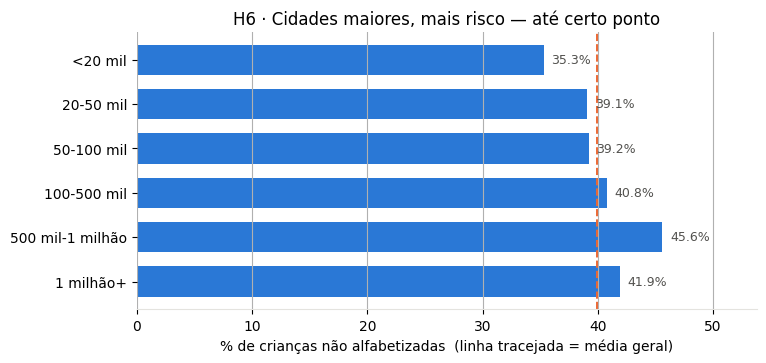

In [34]:
# Visualizando a taxa por faixa de população
fig, ax = plt.subplots(figsize=(8, 3.6))
barras_horizontais(ax, taxa_por_faixa.index.astype(str).tolist(),
                   taxa_por_faixa["Taxa_Percentual"].tolist(), formato="{:.1f}%")
ax.axvline(100 * df[ALVO].mean(), color=LARANJA, linewidth=1.4, linestyle="--")
ax.set_title("H6 · Cidades maiores, mais risco — até certo ponto")
ax.set_xlabel("% de crianças não alfabetizadas  (linha tracejada = média geral)")
salva(fig, "projeto_h6_populacao.png"); plt.show()

**Nota:**

- A correlação é **positiva, mas muito fraca (r = 0,0195)**. O valor-p pequeno só diz que ela não é
  acaso — com 50 mil linhas quase tudo é "significativo".
- Por faixas, o padrão aparece melhor: de **35,3%** nos municípios com menos de 20 mil habitantes
  para **45,6%** nos de 500 mil a 1 milhão — **10 pontos** de diferença.
- A subida **quebra no topo**: nas metrópoles com mais de 1 milhão a taxa cai para **41,9%**.
  Por isso a tendência não é sempre crescente.
- **H6 é parcialmente confirmada.** Ao contrário do senso comum, as **cidades pequenas se saem
  melhor**. A correlação fraca também mostra que uma reta simples não descreve bem essa relação —
  ela sobe e depois desce.

#### H7 — Tamanho da escola

- Hipótese 7: Crianças de **escolas pequenas** (menos de 30 alunos avaliados) têm maior risco de não se alfabetizar.

In [35]:
# Análise estatística básica
print("=== ANÁLISE ESTATÍSTICA HIPÓTESE 7 ===")

escola_pequena = np.where(df["escola_n_alunos_avaliados"] < 30, "escola pequena", "escola maior")

# Calcular proporções usando groupby
prop_h7 = df.groupby(escola_pequena)[ALVO].mean() * 100

print(f"Taxa de não alfabetização em ESCOLAS MAIORES (30+ avaliados): {prop_h7['escola maior']:.1f}%")
print(f"Taxa de não alfabetização em ESCOLAS PEQUENAS (<30 avaliados): {prop_h7['escola pequena']:.1f}%")
print(f"Diferença: {prop_h7['escola pequena'] - prop_h7['escola maior']:.1f} pontos percentuais")

# Calcular odds usando groupby (função calcular_odds definida na H5)
odds_h7 = df.groupby(escola_pequena)[ALVO].apply(calcular_odds)
odds_ratio_h7 = odds_h7["escola pequena"] / odds_h7["escola maior"]

print(f"Odds Ratio: {odds_ratio_h7:.2f}")

if odds_ratio_h7 > 1:
    print("✓ A hipótese é CONFIRMADA: crianças de escolas pequenas têm maior probabilidade de não se alfabetizar")
else:
    print("✗ A hipótese é REJEITADA: crianças de escolas pequenas NÃO têm maior probabilidade de não se alfabetizar")

=== ANÁLISE ESTATÍSTICA HIPÓTESE 7 ===
Taxa de não alfabetização em ESCOLAS MAIORES (30+ avaliados): 39.5%
Taxa de não alfabetização em ESCOLAS PEQUENAS (<30 avaliados): 42.1%
Diferença: 2.5 pontos percentuais
Odds Ratio: 1.11
✓ A hipótese é CONFIRMADA: crianças de escolas pequenas têm maior probabilidade de não se alfabetizar


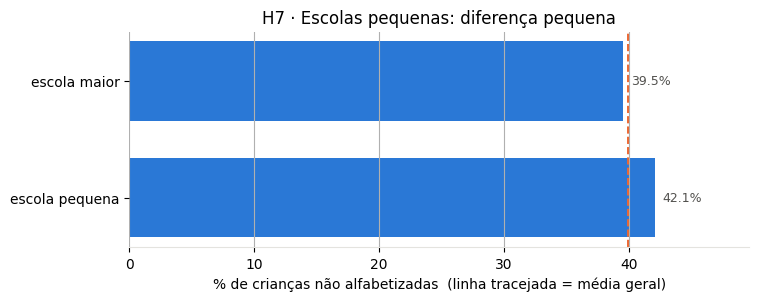

In [36]:
# Visualizando a taxa por tamanho da escola
fig, ax = plt.subplots(figsize=(8, 2.8))
barras_horizontais(ax, prop_h7.index.tolist(), prop_h7.values.tolist(), formato="{:.1f}%")
ax.axvline(100 * df[ALVO].mean(), color=LARANJA, linewidth=1.4, linestyle="--")
ax.set_title("H7 · Escolas pequenas: diferença pequena")
ax.set_xlabel("% de crianças não alfabetizadas  (linha tracejada = média geral)")
salva(fig, "projeto_h7_escola.png"); plt.show()

**Nota:**

O **Odds Ratio (OR)** é uma medida estatística muito importante para entender a força da associação entre duas variáveis.

O que é o Odds Ratio?
- O Odds Ratio compara as chances (odds) de um evento ocorrer em dois grupos diferentes.

Significado:
- Crianças de escolas pequenas têm **1,11 vez** a chance de não se alfabetizar das crianças de escolas maiores, ou seja, a chance é só **11% maior**.
- Na prática: **42,1%** contra **39,5%** — uma diferença de **2,5 pontos percentuais**.

Como calcular as "chances" (odds):
- Grupo ESCOLA MAIOR:
    - Odds = crianças não alfabetizadas / crianças alfabetizadas
- Grupo ESCOLA PEQUENA:
    - Odds = crianças não alfabetizadas / crianças alfabetizadas
- OR = odds da escola pequena / odds da escola maior

**Interpretação prática:**

| Valor do OR | Interpretação |
|-------------|---------------|
| OR = 1.0 | **Não há associação** (mesma chance nos dois grupos) |
| OR > 1.0 | **Fator de risco** (aumenta a chance do evento) |
| OR < 1.0 | **Fator protetor** (diminui a chance do evento) |

Classificação da força da associação:
- OR = 1.0 - 1.5: Associação fraca ← **Nosso caso (1,11)**
- OR = 1.5 - 3.0: Associação moderada
- OR = 3.0 - 10.0: Associação forte
- OR > 10.0: Associação muito forte

Importância prática:
- **H7 é confirmada, mas com associação fraca.** O tamanho da escola, sozinho, diz pouco sobre o risco.
- Cerca de **18% das crianças** (8.979) estudam em escolas pequenas, muitas delas em zonas rurais.

### <font color='#F37126'> 4.3. Hipóteses Combinadas (entre colunas)

Uma hipótese combinada verifica se **duas condições juntas** pioram o risco mais do que cada uma
sozinha. Para cada par, a análise:

1. monta uma tabela com as **4 combinações** possíveis (nenhuma, só A, só B, A e B);
2. compara o grupo **A e B** com todas as outras crianças usando o **Odds Ratio**;
3. mostra se cada condição **sozinha** já explica o risco ou se é a combinação que faz diferença.

In [37]:
# Função para testar uma hipótese combinada entre duas condições
def testa_combinada(dados, cond_a, cond_b, nome_a, nome_b):
    dados = dados.copy()
    dados["A"] = cond_a
    dados["B"] = cond_b

    # Tabela com as 4 combinações
    rotulos = {(False, False): "nenhuma das duas",
               (True, False): f"só {nome_a}",
               (False, True): f"só {nome_b}",
               (True, True): f"{nome_a} + {nome_b}"}
    tabela = dados.groupby(["A", "B"])[ALVO].agg(criancas="size", taxa="mean")
    tabela["taxa"] = (100 * tabela["taxa"]).round(1)
    tabela.index = [rotulos[i] for i in tabela.index]
    print("=== TAXA DE NÃO ALFABETIZAÇÃO NAS 4 COMBINAÇÕES ===")
    print(tabela)

    # Grupo com as duas condições contra todas as outras crianças
    combinacao = np.where(dados["A"] & dados["B"], "A e B", "restante")
    prop = dados.groupby(combinacao)[ALVO].mean() * 100
    odds = dados.groupby(combinacao)[ALVO].apply(calcular_odds)
    odds_ratio = odds["A e B"] / odds["restante"]

    print("\n=== ANÁLISE ESTATÍSTICA ===")
    print(f"Taxa com {nome_a} + {nome_b}: {prop['A e B']:.1f}%")
    print(f"Taxa no restante das crianças: {prop['restante']:.1f}%")
    print(f"Diferença: {prop['A e B'] - prop['restante']:.1f} pontos percentuais")
    print(f"Odds Ratio (A e B vs restante): {odds_ratio:.2f}")

    # Força da associação
    if odds_ratio >= 3.0:
        forca = "FORTE"
    elif odds_ratio >= 1.5:
        forca = "MODERADA"
    elif odds_ratio > 1.0:
        forca = "FRACA"
    else:
        forca = "NENHUMA / PROTETORA"

    print("\n=== INTERPRETAÇÃO ===")
    if odds_ratio > 1:
        print(f"✓ A HIPÓTESE É CONFIRMADA: {nome_a} + {nome_b} aumenta o risco")
    else:
        print(f"✗ A HIPÓTESE É REJEITADA: {nome_a} + {nome_b} não aumenta o risco")
    print(f"📊 Força da associação: {forca} (OR = {odds_ratio:.2f})")

    # Cada condição sozinha, comparada com "nenhuma das duas"
    base = tabela.loc["nenhuma das duas", "taxa"]
    print("\n=== EFEITO DE CADA CONDIÇÃO (em relação a 'nenhuma das duas') ===")
    for linha in tabela.index[1:]:
        print(f"{linha:<45} {tabela.loc[linha, 'taxa'] - base:+.1f} pontos")

    return tabela, odds_ratio


def grafico_combinada(tabela, titulo, arquivo):
    fig, ax = plt.subplots(figsize=(8, 3.2))
    barras_horizontais(ax, tabela.index.tolist(), tabela["taxa"].tolist(), formato="{:.1f}%")
    ax.axvline(100 * df[ALVO].mean(), color=LARANJA, linewidth=1.4, linestyle="--")
    ax.set_title(titulo)
    ax.set_xlabel("% de crianças não alfabetizadas  (linha tracejada = média geral)")
    salva(fig, arquivo); plt.show()

#### H8 — Histórico ruim em 2023 + Norte/Nordeste

- Hipótese 8: Crianças de municípios com **taxa de alfabetização abaixo de 50% em 2023** e localizados no **Norte ou Nordeste** têm risco significativamente maior de não se alfabetizar.

In [38]:
print("=== TESTANDO HIPÓTESE 8: HISTÓRICO RUIM + NORTE/NORDESTE ===\n")

h8 = df.dropna(subset=["mun_ctx_taxa_alfabetizacao"])
tabela_h8, odds_ratio_h8 = testa_combinada(
    h8,
    cond_a=h8["mun_ctx_taxa_alfabetizacao"] < 50,
    cond_b=h8["regiao"].isin(["Norte", "Nordeste"]),
    nome_a="histórico ruim",
    nome_b="Norte/Nordeste",
)

=== TESTANDO HIPÓTESE 8: HISTÓRICO RUIM + NORTE/NORDESTE ===

=== TAXA DE NÃO ALFABETIZAÇÃO NAS 4 COMBINAÇÕES ===
                                 criancas  taxa
nenhuma das duas                    24430  34.1
só Norte/Nordeste                    9045  32.5
só histórico ruim                    7361  49.3
histórico ruim + Norte/Nordeste      8372  56.8

=== ANÁLISE ESTATÍSTICA ===
Taxa com histórico ruim + Norte/Nordeste: 56.8%
Taxa no restante das crianças: 36.5%
Diferença: 20.3 pontos percentuais
Odds Ratio (A e B vs restante): 2.29

=== INTERPRETAÇÃO ===
✓ A HIPÓTESE É CONFIRMADA: histórico ruim + Norte/Nordeste aumenta o risco
📊 Força da associação: MODERADA (OR = 2.29)

=== EFEITO DE CADA CONDIÇÃO (em relação a 'nenhuma das duas') ===
só Norte/Nordeste                             -1.6 pontos
só histórico ruim                             +15.2 pontos
histórico ruim + Norte/Nordeste               +22.7 pontos


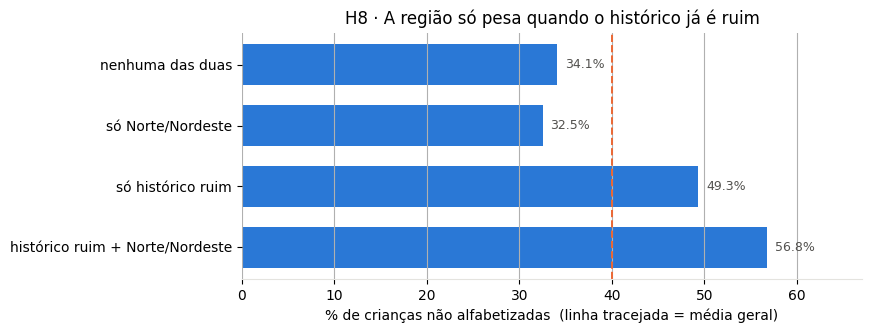

In [39]:
grafico_combinada(tabela_h8, "H8 · A região só pesa quando o histórico já é ruim", "projeto_h8_historico_regiao.png")

**Nota:**

- Crianças com as **duas condições** têm taxa de **56,8%**, contra **36,5%** no restante. O Odds Ratio
  é **2,29**: a chance de não se alfabetizar é **mais que o dobro** (associação **moderada**).
- **O achado mais interessante está na tabela das 4 combinações:**
    - **só Norte/Nordeste** (histórico bom): **32,5%** — até *menor* que "nenhuma das duas" (34,1%)
    - **só histórico ruim** (fora do Norte/Nordeste): **49,3%** — +15 pontos
    - **as duas juntas**: **56,8%** — +23 pontos
- Ou seja: **estar no Norte/Nordeste, sozinho, não aumenta o risco.** O que pesa é o histórico do
  município; a região **agrava** o problema quando esse histórico já é ruim.
- **H8 é confirmada.** Para política pública, isso diz que o alvo não é "a região inteira", e sim os
  municípios de histórico fraco dentro dela.

#### H9 — Município pobre + histórico ruim em 2023

- Hipótese 9: Crianças de municípios com **PIB per capita abaixo da mediana** (R$ 42,3 mil) e **taxa de alfabetização abaixo de 50% em 2023** têm risco significativamente maior de não se alfabetizar.

In [40]:
print("=== TESTANDO HIPÓTESE 9: MUNICÍPIO POBRE + HISTÓRICO RUIM ===\n")

h9 = df.dropna(subset=["mun_ctx_taxa_alfabetizacao"])
mediana_pib = df["ibge_pib_per_capita"].median()
print(f"Mediana do PIB per capita: R$ {mediana_pib:,.2f}\n")

tabela_h9, odds_ratio_h9 = testa_combinada(
    h9,
    cond_a=h9["ibge_pib_per_capita"] < mediana_pib,
    cond_b=h9["mun_ctx_taxa_alfabetizacao"] < 50,
    nome_a="município pobre",
    nome_b="histórico ruim",
)

=== TESTANDO HIPÓTESE 9: MUNICÍPIO POBRE + HISTÓRICO RUIM ===

Mediana do PIB per capita: R$ 42,251.60

=== TAXA DE NÃO ALFABETIZAÇÃO NAS 4 COMBINAÇÕES ===
                                  criancas  taxa
nenhuma das duas                     18815  35.1
só histórico ruim                     5624  49.9
só município pobre                   14660  31.8
município pobre + histórico ruim     10109  55.2

=== ANÁLISE ESTATÍSTICA ===
Taxa com município pobre + histórico ruim: 55.2%
Taxa no restante das crianças: 36.0%
Diferença: 19.2 pontos percentuais
Odds Ratio (A e B vs restante): 2.19

=== INTERPRETAÇÃO ===
✓ A HIPÓTESE É CONFIRMADA: município pobre + histórico ruim aumenta o risco
📊 Força da associação: MODERADA (OR = 2.19)

=== EFEITO DE CADA CONDIÇÃO (em relação a 'nenhuma das duas') ===
só histórico ruim                             +14.8 pontos
só município pobre                            -3.3 pontos
município pobre + histórico ruim              +20.1 pontos


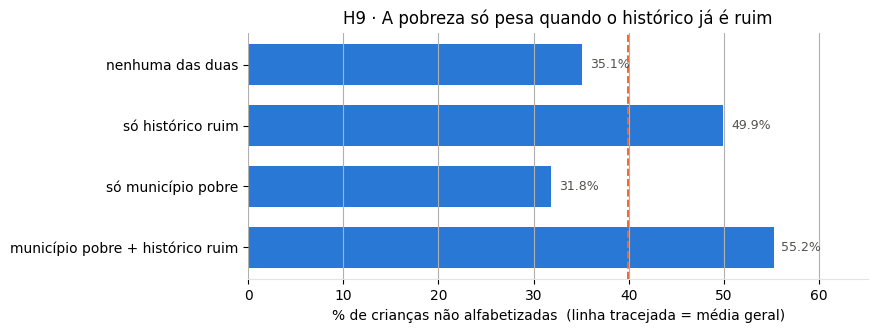

In [41]:
grafico_combinada(tabela_h9, "H9 · A pobreza só pesa quando o histórico já é ruim", "projeto_h9_pib_historico.png")

**Nota:**

- Crianças de municípios **pobres e com histórico ruim** têm taxa de **55,2%**, contra **36,0%** no
  restante. O Odds Ratio é **2,19** (associação **moderada**).
- Na tabela das 4 combinações o padrão da H8 se repete:
    - **só município pobre** (histórico bom): **31,8%** — *menor* que "nenhuma das duas" (35,1%)
    - **só histórico ruim** (município rico): **49,9%** — +15 pontos
    - **as duas juntas**: **55,2%** — +20 pontos
- A pobreza, **sozinha, não aumenta o risco** — isso explica por que o PIB não mostrou padrão na H4.
  Mas, **somada a um histórico ruim, ela piora o quadro** em mais 5 pontos.
- **H9 é confirmada.** Mais uma vez, o **histórico de 2023** é o fator central; riqueza e região
  funcionam como agravantes.

### Resumo das Hipóteses

| Hipótese | Descrição | Resultado |
|----------|-----------|-----------|
| **Hipótese 1** | O estado e a região onde a criança estuda influenciam o risco de não se alfabetizar | ✅ **CONFIRMADA** - O estado muda muito o risco: 13,9% no Ceará e 64,9% na Bahia |
| **Hipótese 2** | Municípios com taxa de alfabetização baixa em 2023 continuam com resultado ruim em 2024 | ✅ **CONFIRMADA** - O passado do município é o melhor sinal do presente |
| **Hipótese 3** | A rede de ensino (municipal ou estadual) muda o risco de não se alfabetizar | ⚠️ **CONFIRMADA, MAS FRACA** - Diferença de só 1,6 ponto entre as redes |
| **Hipótese 4** | Municípios mais ricos (maior PIB por habitante) têm menos crianças não alfabetizadas | ❌ **REJEITADA** - A riqueza do município, sozinha, não diminui o risco |
| **Hipótese 5** | Municípios que em 2023 estavam abaixo da meta de 2024 têm mais crianças não alfabetizadas | ✅ **CONFIRMADA** - 42,2% abaixo da meta contra 25,4% dos que já estavam na meta |
| **Hipótese 6** | A chance de não se alfabetizar aumenta com o tamanho do município | ⚡ **PARCIALMENTE CONFIRMADA** - O risco sobe até cidades de 1 milhão de habitantes e cai nas metrópoles |
| **Hipótese 7** | Crianças de escolas pequenas têm maior risco de não se alfabetizar | ⚠️ **CONFIRMADA, MAS FRACA** - 42,1% contra 39,5% nas escolas maiores |
| **Hipótese 8** | Municípios com histórico ruim em 2023 **e** no Norte/Nordeste têm risco muito maior | ✅ **CONFIRMADA** - 56,8% de não alfabetizados; a região sozinha não aumenta o risco |
| **Hipótese 9** | Municípios pobres **e** com histórico ruim em 2023 têm risco muito maior | ✅ **CONFIRMADA** - 55,2% de não alfabetizados; a pobreza sozinha não aumenta o risco |

✅ confirmada · ⚠️ confirmada, mas com efeito pequeno · ⚡ parcialmente confirmada · ❌ rejeitada

**Nota:**

- **Foram testadas nove hipóteses**: sete olhando uma informação por vez e duas combinando duas informações.
- **O que mais pesa:** o **estado** onde a criança estuda (H1) e, principalmente, o **resultado do município em 2023** (H2), reforçado pela meta de 2024 (H5).
- **O que pesa pouco:** a **rede de ensino** (H3), o **tamanho da escola** (H7) e o **tamanho do município** (H6).
- **O que não se confirmou:** a **riqueza do município, sozinha**, não diminui o risco (H4).
- **O que as hipóteses combinadas ensinam (H8 e H9):** região e pobreza não aumentam o risco sozinhas, mas **pioram o quadro quando o município já tinha resultado ruim em 2023**.
- Essas conclusões vão guiar **quais informações entram no modelo** na próxima etapa.

## 4 - **FEATURE ENGINEERING** — (**engenharia de atributos**)

**Feature engineering** é criar informações novas a partir das que já existem, para que o
modelo enxergue melhor os padrões. É como transformar "data de nascimento" em "idade": o dado
é o mesmo, mas fica mais útil.

A base já chega com as variáveis derivadas prontas, construídas por `src/preprocessing/build_base.py`.
Duas merecem explicação, porque não são óbvias pelo nome:

**1. `mun_gap_projetado` = `mun_meta_2024` − `mun_ctx_taxa_alfabetizacao`**

Quanto o município **precisava subir em um único ano** para bater a meta que o INEP fixou para
ele. Não é o mesmo que a taxa de 2023: dois municípios com a mesma taxa podem receber metas
diferentes. A distância até a meta mede a **pressão** sobre a rede, não o desempenho.

**2. `ibge_log_populacao` = `log1p(ibge_populacao)`**

A população dos municípios vai de **921 a 11,9 milhões** de habitantes. Nessa escala, São Paulo
"esmaga" todos os outros, e o modelo praticamente só consegue perguntar "é uma metrópole?".
O **logaritmo** encurta essa distância: ele passa a diferenciar a cidade de 5 mil da de 50 mil,
que é onde está a maior parte dos municípios.

A célula abaixo **recalcula as duas do zero** e confere se batem com as que vieram na base.

In [42]:
# Conferindo as duas variáveis derivadas
conferencia = df.dropna(subset=["mun_meta_2024", "mun_ctx_taxa_alfabetizacao"]).copy()
gap_recalculado = (conferencia["mun_meta_2024"]
                   - conferencia["mun_ctx_taxa_alfabetizacao"]).round(2)
divergencia = (gap_recalculado - conferencia["mun_gap_projetado"]).abs().max()
print(f"mun_gap_projetado — divergência máxima ao recalcular: {divergencia:.4f}")

log_recalculado = np.log1p(df["ibge_populacao"])
print(f"ibge_log_populacao — divergência máxima ao recalcular: "
      f"{(log_recalculado - df['ibge_log_populacao']).abs().max():.6f}")

print(f"\nmun_gap_projetado: mediana {df['mun_gap_projetado'].median():.2f} pontos, "
      f"amplitude de {df['mun_gap_projetado'].min():.1f} a "
      f"{df['mun_gap_projetado'].max():.1f}")
print(f"ibge_populacao ...... de {df['ibge_populacao'].min():,.0f} a "
      f"{df['ibge_populacao'].max():,.0f} habitantes")
print(f"ibge_log_populacao .. de {df['ibge_log_populacao'].min():.2f} a "
      f"{df['ibge_log_populacao'].max():.2f}")

del conferencia, gap_recalculado, log_recalculado
_ = gc.collect()  # libera memória sem imprimir nada

mun_gap_projetado — divergência máxima ao recalcular: 0.0000
ibge_log_populacao — divergência máxima ao recalcular: 0.000050

mun_gap_projetado: mediana 3.82 pontos, amplitude de -61.3 a 56.8
ibge_populacao ...... de 921 a 11,895,578 habitantes
ibge_log_populacao .. de 6.83 a 16.29


**Nota:**

- **As duas colunas foram recalculadas do zero e comparadas com as da base.** A diferença máxima é
  **0** para `mun_gap_projetado` e **0,00005** para `ibge_log_populacao` — só o arredondamento das casas decimais.
- **Por que conferir?** Se uma variável tivesse sido calculada com uma regra diferente na origem, o
  modelo aprenderia uma relação que não se repetiria quando fosse usado de verdade.
- `mun_gap_projetado` tem mediana de **3,82 pontos**: o município típico precisava subir cerca de 4
  pontos percentuais em um ano. A amplitude de **−61,3 a +56,8** mostra que há municípios já muito
  acima da meta (valores negativos) e outros muito longe dela.
- A população vai de **921 a 11,9 milhões**, mas no logaritmo fica entre **6,83 e 16,29** — uma escala
  muito mais fácil de comparar.

### Efeito do logaritmo na população

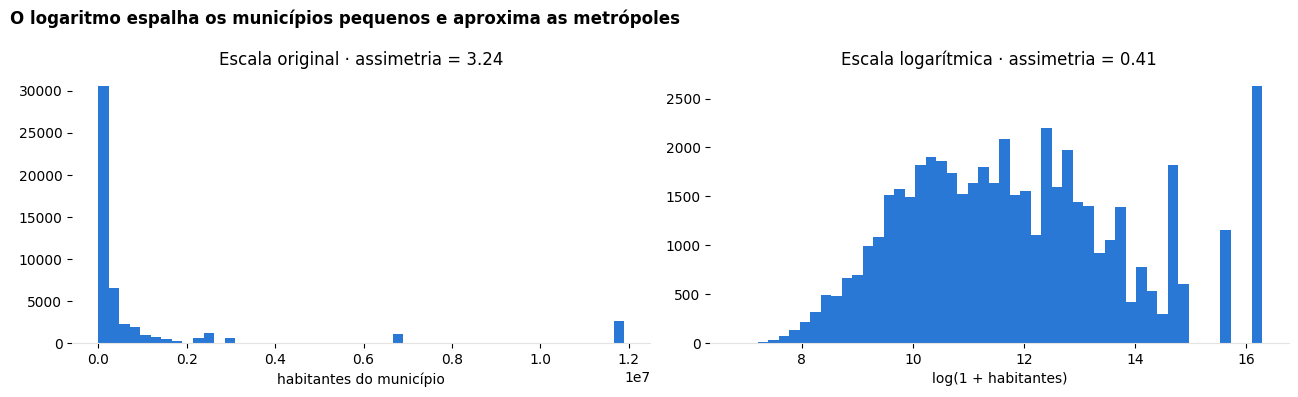

correlação com o alvo — população original: 0.0195
correlação com o alvo — população em log .: 0.0478


In [43]:
# Comparando a população antes e depois do logaritmo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.hist(df["ibge_populacao"], bins=50, color=AZUL, edgecolor="none")
ax1.set_title(f"Escala original · assimetria = {df['ibge_populacao'].skew():.2f}")
ax1.set_xlabel("habitantes do município")
limpa_eixos(ax1)

ax2.hist(df["ibge_log_populacao"], bins=50, color=AZUL, edgecolor="none")
ax2.set_title(f"Escala logarítmica · assimetria = {df['ibge_log_populacao'].skew():.2f}")
ax2.set_xlabel("log(1 + habitantes)")
limpa_eixos(ax2)

fig.suptitle("O logaritmo espalha os municípios pequenos e aproxima as metrópoles",
             x=0.005, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout()
salva(fig, "projeto_fe_log_populacao.png"); plt.show()

print(f"correlação com o alvo — população original: {df['ibge_populacao'].corr(df[ALVO]):.4f}")
print(f"correlação com o alvo — população em log .: {df['ibge_log_populacao'].corr(df[ALVO]):.4f}")

**Nota:**

- **À esquerda (escala original):** quase todos os municípios ficam espremidos numa única barra perto
  do zero, e poucas metrópoles se espalham à direita. A **assimetria é de 3,24** — muito distorcida.
- **À direita (logaritmo):** a mesma informação fica **muito mais espalhada e equilibrada**, com
  assimetria de **0,41**. Agora dá para ver a diferença entre cidades pequenas, médias e grandes.
- A correlação com o alvo **mais que dobra**: de **0,019** para **0,048**. Continua fraca (como vimos na
  H6), mas o logaritmo deixa o sinal mais visível para modelos que usam retas, como a Regressão Logística.
- Modelos de **árvore** (Random Forest, LightGBM) não se incomodam com a escala; por isso as duas
  versões ficam na base e cada algoritmo aproveita a que funciona melhor.

### Distribuição da distância até a meta

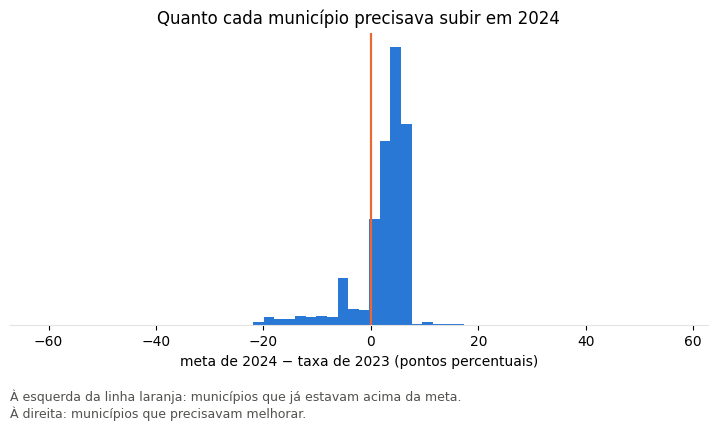

crianças em municípios já na meta (gap <= 0): 15.9%
correlação gap x alvo ............ 0.1742
correlação taxa 2023 x alvo ...... -0.2421
correlação gap x taxa 2023 ....... -0.6835


In [44]:
# Distribuição de mun_gap_projetado e sua relação com o alvo
gap = df["mun_gap_projetado"].dropna()

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hist(gap, bins=60, color=AZUL, edgecolor="none")
ax.axvline(0, color=LARANJA, linewidth=1.6)
ax.set_xlabel("meta de 2024 − taxa de 2023 (pontos percentuais)")
ax.set_yticks([])
ax.set_title("Quanto cada município precisava subir em 2024")
limpa_eixos(ax)
anota(ax, "À esquerda da linha laranja: municípios que já estavam acima da meta.\n"
          "À direita: municípios que precisavam melhorar.")
salva(fig, "projeto_fe_gap_meta.png"); plt.show()

print(f"crianças em municípios já na meta (gap <= 0): {100 * (gap <= 0).mean():.1f}%")
print(f"correlação gap x alvo ............ {df['mun_gap_projetado'].corr(df[ALVO]):.4f}")
print(f"correlação taxa 2023 x alvo ...... {df['mun_ctx_taxa_alfabetizacao'].corr(df[ALVO]):.4f}")
print(f"correlação gap x taxa 2023 ....... {df['mun_gap_projetado'].corr(df['mun_ctx_taxa_alfabetizacao']):.4f}")

**Nota:**

- A maior parte das barras fica **logo à direita da linha laranja**: a meta típica pedia uma melhora
  **pequena**, de poucos pontos. Só **15,9%** das crianças estudam em municípios que já estavam na meta.
- A correlação do gap com o alvo é **positiva (0,17)**: quanto mais longe da meta, maior a chance de a
  criança não se alfabetizar — o mesmo que a H5 mostrou.
- O gap tem correlação de **−0,68** com a taxa de 2023: municípios com taxa baixa costumam estar mais
  longe da meta. As duas informações **se parecem, mas não são iguais** — e a taxa de 2023 continua
  sendo a mais ligada ao alvo (**−0,24**).
- **Cuidado:** variáveis muito parecidas podem "dividir" a importância entre si no modelo. Isso não
  atrapalha a previsão, mas deve ser lembrado ao interpretar quais variáveis pesam mais.

**Resumo da Feature Engineering:**

| Variável derivada | Como é calculada | Por que ajuda |
|---|---|---|
| `mun_gap_projetado` | meta de 2024 − taxa de 2023 | mede a **pressão** para melhorar em um ano |
| `ibge_log_populacao` | logaritmo da população | torna comparáveis cidades pequenas e metrópoles |

- As duas foram **conferidas** e batem com a origem.
- Nenhuma usa o resultado da prova de 2024: não há **vazamento**.

## 5 - **EXPLORANDO AS CORRELAÇÕES**

A **correlação** mede se duas variáveis andam juntas, numa escala de **−1 a +1**:

- Próxima de **+1**: as duas sobem juntas (como altura e peso).
- Próxima de **−1**: quando uma sobe, a outra desce (como horas de estudo e número de erros na prova).
- Próxima de **0**: não há relação em linha reta — o que **não** significa que não exista relação nenhuma.

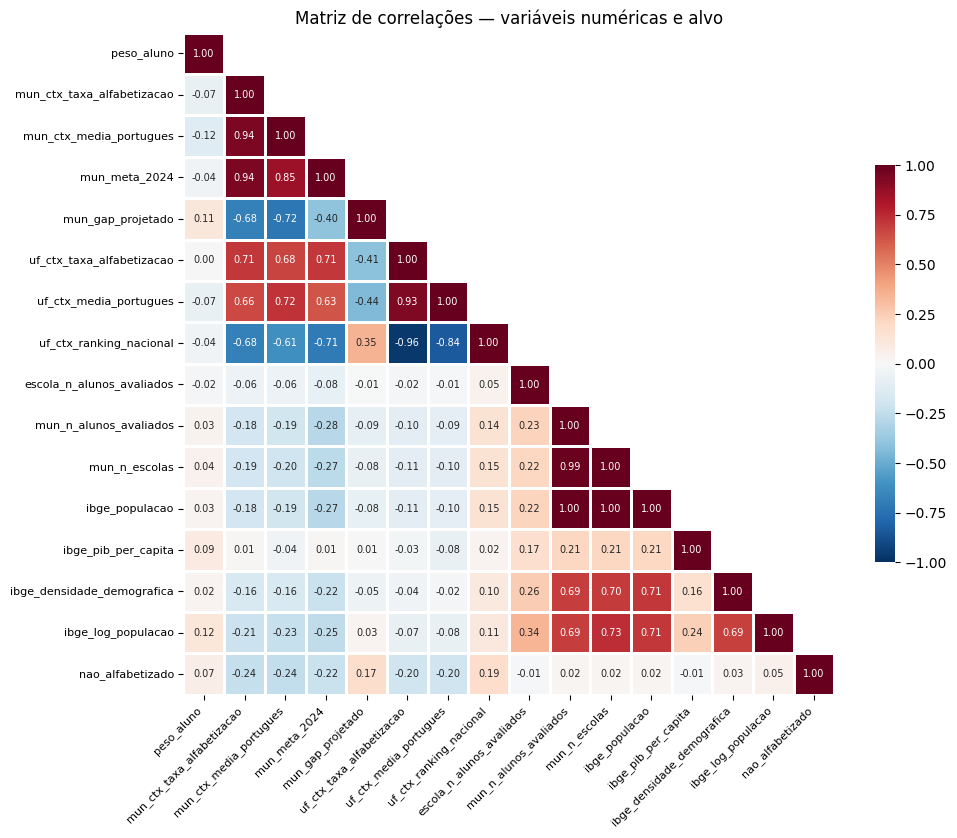

In [45]:
# Matriz de correlações entre todas as numéricas
numericas_modelo = [c for c in NUM_FEATURES if c in df.columns]
matriz = df[numericas_modelo + [ALVO]].corr(method="pearson")

fig, ax = plt.subplots(figsize=(10.5, 8.6))
mascara = np.triu(np.ones_like(matriz, dtype=bool), k=1)
sns.heatmap(matriz, mask=mascara, cmap=DIVERGENTE, center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"fontsize": 7}, ax=ax,
            linewidths=0.8, linecolor="white", cbar_kws={"shrink": 0.6})
ax.set_title("Matriz de correlações — variáveis numéricas e alvo")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
salva(fig, "projeto_correlacoes.png"); plt.show()

**Nota:**

- **Como ler o mapa:** cada quadrado cruza duas variáveis. **Vermelho** forte é correlação positiva
  (sobem juntas), **azul** forte é negativa (uma sobe, a outra desce) e o tom **claro** é ausência de relação.
- **Grupos que dizem quase a mesma coisa** (quadrados muito escuros fora da diagonal):
    - `ibge_populacao`, `mun_n_escolas` e `mun_n_alunos_avaliados`: **0,99** — cidade grande tem mais escolas e mais alunos
    - `mun_ctx_taxa_alfabetizacao`, `mun_ctx_media_portugues` e `mun_meta_2024`: **0,94** — a meta foi calculada a partir da taxa
    - `uf_ctx_taxa_alfabetizacao` e `uf_ctx_ranking_nacional`: **−0,96** — taxa maior, melhor posição no ranking
- **Isso é um problema?** Para os modelos de árvore (Random Forest, LightGBM), não: eles lidam bem com
  variáveis repetidas. O cuidado é só na hora de interpretar qual variável "pesa mais".
- A última linha (`nao_alfabetizado`) é a mais importante: ela mostra a relação de cada variável com o alvo,
  detalhada no próximo gráfico.

                            correlacao_com_alvo                    direcao
mun_ctx_media_portugues                 -0.2431  mais valor -> menos risco
mun_ctx_taxa_alfabetizacao              -0.2421  mais valor -> menos risco
mun_meta_2024                           -0.2223  mais valor -> menos risco
uf_ctx_media_portugues                  -0.1986  mais valor -> menos risco
uf_ctx_taxa_alfabetizacao               -0.1959  mais valor -> menos risco
uf_ctx_ranking_nacional                  0.1859   mais valor -> mais risco
mun_gap_projetado                        0.1742   mais valor -> mais risco
peso_aluno                               0.0655   mais valor -> mais risco
ibge_log_populacao                       0.0478   mais valor -> mais risco
ibge_densidade_demografica               0.0284   mais valor -> mais risco
mun_n_escolas                            0.0230   mais valor -> mais risco
ibge_populacao                           0.0195   mais valor -> mais risco
mun_n_alunos_avaliados   

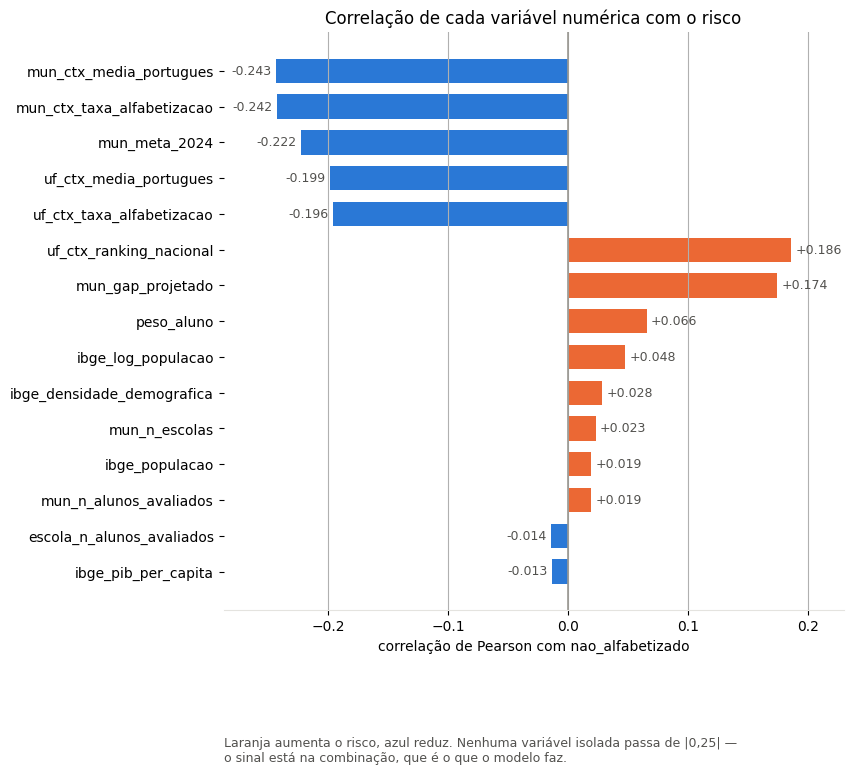

In [46]:
# Criando um rank das correlações com o alvo
rank = (matriz[ALVO].drop(ALVO).sort_values(key=np.abs, ascending=False)
        .to_frame("correlacao_com_alvo").round(4))
rank["direcao"] = np.where(rank["correlacao_com_alvo"] > 0,
                           "mais valor -> mais risco", "mais valor -> menos risco")
print(rank.to_string())

fig, ax = plt.subplots(figsize=(8, 0.42 * len(rank) + 1.2))
valores = rank["correlacao_com_alvo"].tolist()
barras_horizontais(ax, rank.index.tolist(), valores, formato="{:+.3f}",
                   destaque={i: LARANJA for i, v in zip(rank.index, valores) if v > 0})
ax.set_title("Correlação de cada variável numérica com o risco")
ax.set_xlabel("correlação de Pearson com nao_alfabetizado")
anota(ax, "Laranja aumenta o risco, azul reduz. Nenhuma variável isolada passa de |0,25| —\n"
          "o sinal está na combinação, que é o que o modelo faz.")
salva(fig, "projeto_rank_correlacoes.png"); plt.show()

**Nota:**

- **Nenhuma variável sozinha é forte.** A maior correlação com o alvo é **−0,243**
  (`mun_ctx_media_portugues`). Não existe uma "variável mágica": o risco depende da **soma de vários sinais
  fracos**, e é isso que um modelo de Machine Learning faz bem.
- **As 5 primeiras são negativas (azul):** quanto melhor o município ou o estado estava em 2023 (taxa, nota de
  português, meta), **menor** o risco em 2024. É a H2 aparecendo de novo.
- `uf_ctx_ranking_nacional` é **positiva (+0,186)** só por causa do jeito de contar: ranking **maior** significa
  posição **pior** (1º é o melhor estado).
- `mun_gap_projetado` (**+0,174**): quanto mais longe da meta, maior o risco — confirma a H5.
- **Tamanho e riqueza ficam perto de zero:** `ibge_populacao` (+0,020), `ibge_pib_per_capita` (−0,013) e
  `escola_n_alunos_avaliados` (−0,014). Confirma que H4, H6 e H7 têm efeito fraco.
- **Atenção:** esta tabela só mostra variáveis **numéricas**. Estado, município e escola são categorias e
  aparecem no próximo gráfico.

id_municipio    0.2759
id_escola       0.2629
sigla_uf        0.2284
regiao          0.0701
rede            0.0102
caderno         0.0000


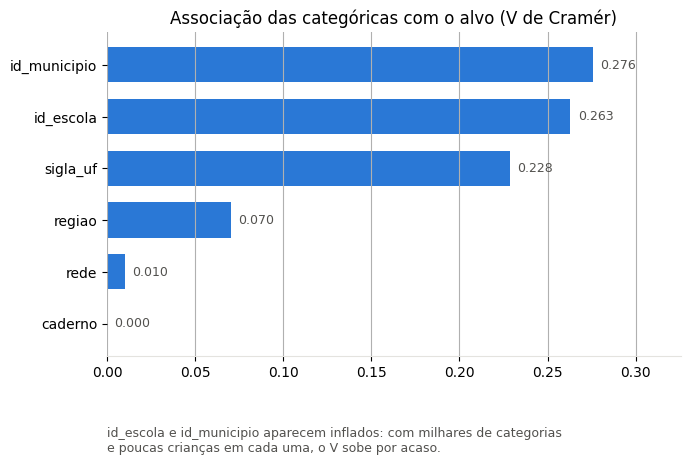

In [47]:
# Associação entre categóricas e o alvo — V de Cramér, apropriado para nominais
# 'serie' é constante nesta base (só o 2º ano é avaliado), então o V é indefinido:
# a coluna sai do gráfico em vez de virar uma barra vazia
categoricas_v = {}
for coluna in CAT_BAIXA + CAT_ALTA:
    if coluna in df.columns and df[coluna].nunique() > 1:
        categoricas_v[coluna] = cramers_v(df[coluna], df[ALVO])

serie_v = pd.Series(categoricas_v).sort_values(ascending=False)
print(serie_v.round(4).to_string())

fig, ax = plt.subplots(figsize=(7.4, 0.5 * len(serie_v) + 1.2))
barras_horizontais(ax, serie_v.index.tolist(), serie_v.tolist(), formato="{:.3f}")
ax.set_title("Associação das categóricas com o alvo (V de Cramér)")
anota(ax, "id_escola e id_municipio aparecem inflados: com milhares de categorias\n"
          "e poucas crianças em cada uma, o V sobe por acaso.")
salva(fig, "projeto_cramers_v.png"); plt.show()

**Nota:**

- O **V de Cramér** faz para as variáveis de **categoria** o que a correlação faz para as numéricas: vai de
  **0** (nenhuma relação) a **1** (relação total).
- **Os identificadores de lugar lideram:** `id_municipio` (**0,276**), `id_escola` (**0,263**) e `sigla_uf` (**0,228**).
  Saber *onde* a criança estuda é a informação mais ligada ao risco — o mesmo que a H1 mostrou.
- **Cuidado com `id_escola` e `id_municipio`:** na amostra há **25.581 escolas para 50 mil crianças** (cerca de 2
  por escola). Com tão poucas crianças em cada categoria, o V sobe **por acaso**. O valor real deles só vai
  aparecer na importância das variáveis do modelo.
- **No outro extremo:** `regiao` (**0,070**) e `rede` (**0,010**) quase não separam as crianças (H1 e H3).
- `caderno` marca **0,000**: o caderno de prova é **sorteado**, então não deveria ter relação nenhuma com o
  resultado — e não tem. É a confirmação de que o sorteio funcionou.
- `serie` não aparece porque só existe o 2º ano: uma coluna com um único valor não pode ser comparada.

### O vazamento sutil: colunas estáticas

Na seção de **data leakage** vimos que algumas colunas foram vetadas por "enxergarem o futuro". Aqui está
**como isso foi descoberto**.

Algumas colunas parecem ser de 2023, mas foram calculadas **sem separar o ano** — por isso podem carregar
informação de 2024, o ano da prova que queremos prever.

**O teste:** uma coluna honesta de 2023 deve se parecer **mais com o resultado de 2023** do que com o de 2024.
Em números: `corr(coluna, taxa_2024) <= corr(coluna, taxa_2023)`. Se ela se parecer mais com 2024, está
"vendo o futuro" e é vetada.

A **régua** é a própria taxa: quanto a taxa de 2023 se parece com a de 2024 (a correlação calculada na H2).

In [48]:
# Diagnóstico: a coluna estática correlaciona mais com 2024 ou com 2023?
estaticas = [c for c in COLUNAS_VETADAS_DIAGNOSTICO if c in df.columns]
painel = (df.groupby("id_municipio", observed=True)
            .agg(**{c: (c, "first") for c in estaticas},
                 taxa_2023=("mun_ctx_taxa_alfabetizacao", "first"),
                 alunos=(ALVO, "size"), nao_alfab=(ALVO, "mean"))
            .query("alunos >= 30").dropna(subset=["taxa_2023"]))
painel["taxa_2024"] = 100 * (1 - painel["nao_alfab"])

resultados = []
for coluna in estaticas:
    valores = painel[[coluna, "taxa_2023", "taxa_2024"]].dropna()
    if valores[coluna].nunique() <= 1:
        resultados.append({"coluna": coluna, "corr_2023": np.nan, "corr_2024": np.nan,
                           "veredito": "variância zero — constante em toda a base"})
        continue
    c23 = abs(valores[coluna].corr(valores["taxa_2023"]))
    c24 = abs(valores[coluna].corr(valores["taxa_2024"]))
    resultados.append({"coluna": coluna, "corr_2023": round(c23, 3), "corr_2024": round(c24, 3),
                       "veredito": "antecipa o alvo" if c24 > c23 else "mediada pelo passado"})

diagnostico = pd.DataFrame(resultados)
print(f"municípios com pelo menos 30 crianças na amostra: {len(painel)}")
print(f"régua de referência — corr(taxa_2023, taxa_2024) = "
      f"{abs(painel['taxa_2023'].corr(painel['taxa_2024'])):.3f}\n")
print(diagnostico.to_string(index=False))

municípios com pelo menos 30 crianças na amostra: 292
régua de referência — corr(taxa_2023, taxa_2024) = 0.722

                         coluna  corr_2023  corr_2024                                  veredito
    mun_ctx_nivel_alfabetizacao      0.860      0.836                      mediada pelo passado
mun_ctx_percentual_participacao      0.263      0.408                           antecipa o alvo
                  mun_meta_2030        NaN        NaN variância zero — constante em toda a base
                   uf_meta_2030        NaN        NaN variância zero — constante em toda a base
    mun_esforco_anual_requerido      1.000      0.722                      mediada pelo passado


**Nota:**

- **Esta é a parte mais delicada da análise.** Filtrar o ano de 2023 não basta quando a coluna foi calculada
  sem separar o ano.
- **A régua é 0,722**: é o quanto a taxa de 2023 se parece com a de 2024 nos 292 municípios com pelo menos 30
  crianças na amostra.
- **`mun_ctx_percentual_participacao` reprova com clareza:** se parece **0,408 com 2024** e só **0,263 com 2023**.
  O percentual de participação registrado é o da prova de 2024 — ele sabe algo do futuro. **Sai do modelo.**
- **`mun_meta_2030` e `uf_meta_2030`** não têm correlação porque valem **80 para todo mundo**. Também saem:
  uma coluna constante não ensina nada.
- **Duas ressalvas, ditas com transparência:**
    - `mun_ctx_nivel_alfabetizacao` **passa na amostra** (0,860 com 2023 e 0,836 com 2024), mas **reprova na base
      completa** de 1,85 milhão de crianças (0,834 com 2023 e **0,856 com 2024**). Com 50 mil crianças a medição
      é menos precisa, então o veto segue o resultado da base completa, registrado em `src/config.py`.
    - `mun_esforco_anual_requerido` passa no teste, mas é vetada por outro motivo: é calculada a partir da meta de
      2030, que é constante, e por isso só repete a informação da taxa de 2023 (correlação **1,000**).

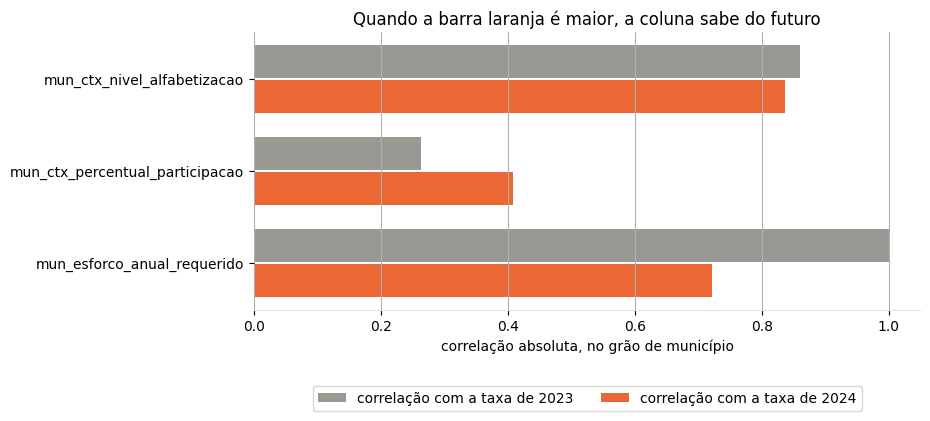

In [49]:
# Visualizando o diagnóstico
comparaveis = diagnostico.dropna(subset=["corr_2023", "corr_2024"])
fig, ax = plt.subplots(figsize=(8.6, 3.6))
y = np.arange(len(comparaveis))
ax.barh(y - 0.19, comparaveis["corr_2023"], height=0.36, color=NEUTRO,
        label="correlação com a taxa de 2023")
ax.barh(y + 0.19, comparaveis["corr_2024"], height=0.36, color=LARANJA,
        label="correlação com a taxa de 2024")
ax.set_yticks(y, comparaveis["coluna"])
ax.invert_yaxis()
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=2)
ax.set_xlabel("correlação absoluta, no grão de município")
ax.set_title("Quando a barra laranja é maior, a coluna sabe do futuro")
limpa_eixos(ax); ax.grid(axis="x")
salva(fig, "projeto_diagnostico_vazamento.png"); plt.show()

del painel, diagnostico, comparaveis
_ = gc.collect()  # libera memória sem imprimir nada

**Nota:**

- **Como ler:** cada coluna tem duas barras — **cinza** é a semelhança com 2023 e **laranja** com 2024.
- **Barra laranja maior que a cinza é o sinal de alarme:** a coluna sabe algo sobre 2024 que o passado não explica.
- Na amostra, esse padrão aparece claramente em `mun_ctx_percentual_participacao`. Nas outras duas a barra cinza é
  maior, mas elas são vetadas pelos motivos explicados na nota anterior.
- **Todas as decisões de veto estão registradas em `src/config.py` com a justificativa**, para que ninguém precise
  refazer essa investigação.

### O que a EDA já decide

1. **O lugar onde a criança estuda é o sinal mais forte.** Estado e município lideram as associações com o
   risco (H1 e V de Cramér).
2. **O passado prevê o presente.** A taxa de 2023 explica **52%** da variação de 2024 entre os municípios (H2) —
   dá para prever com um ano de antecedência, sem "colar" usando dados da própria prova.
3. **Região e pobreza agravam, mas não decidem sozinhas.** Elas só aumentam o risco quando o município já tinha
   histórico ruim (H8 e H9).
4. **Tamanho, riqueza, rede e escola pesam pouco.** Entram no modelo, mas não devem ser decisivos (H3, H4, H6 e H7).
5. **Cinco colunas saem por vazamento**, além da `proficiencia`, que é a própria resposta.
6. **Nenhuma variável sozinha é forte.** A maior correlação com o alvo não chega a **|0,25|**. O caminho é um
   modelo que **combine muitos sinais fracos** — exatamente o que algoritmos como o LightGBM fazem.

# **FASE 03: MODELAGEM DOS DADOS**

## 1 - **Leitura dos dados**

A modelagem usa **o mesmo CSV** da análise, relido do zero. Assim a etapa começa "limpa", sem nenhuma
coluna criada ou alterada durante a exploração.

A tabela é dividida em duas partes:

- **X (variáveis):** as informações que o modelo pode usar para prever — apenas as colunas liberadas
  em `src/config.py` (`FEATURES`).
- **y (alvo):** o que queremos prever — `nao_alfabetizado` (1 = não alfabetizada, 0 = alfabetizada).

In [50]:
# Leitura dos dados — o mesmo CSV salvo na coleta
df = pd.read_csv(
    CAMINHO_CSV, sep=";", decimal=",", encoding="utf-8-sig",
    dtype={"id_aluno": str, "id_escola": str, "id_municipio": str, "serie": str, "caderno": str},
)

# Separando as variáveis (X) do alvo (y), respeitando as colunas liberadas em src/config.py
X, y = matriz_xy(df)

print(f"base completa: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print(f"X (variáveis): {X.shape[0]:,} linhas x {X.shape[1]} colunas")
print(f"y (alvo) ....: {len(y):,} valores | {100 * y.mean():.2f}% de não alfabetizados")

fora = [c for c in df.columns if c not in X.columns]
print(f"\ncolunas que NÃO entram no modelo ({len(fora)}): {fora}")

base completa: 50,169 linhas x 32 colunas
X (variáveis): 50,169 linhas x 22 colunas
y (alvo) ....: 50,169 valores | 39.96% de não alfabetizados

colunas que NÃO entram no modelo (10): ['ano', 'id_aluno', 'nome_municipio', 'mun_ctx_nivel_alfabetizacao', 'mun_ctx_percentual_participacao', 'mun_meta_2030', 'mun_esforco_anual_requerido', 'uf_meta_2030', 'proficiencia', 'nao_alfabetizado']


**Nota:**

- **50.169 crianças** e **22 variáveis** entram no modelo. A proporção de não alfabetizados é **39,96%**.
- **10 colunas ficam de fora**, cada uma por um motivo:
    - `nao_alfabetizado`: é o **alvo**, a resposta que o modelo precisa descobrir
    - `proficiencia`: é a **nota da prova** — usá-la seria "colar" (vazamento)
    - `mun_ctx_nivel_alfabetizacao`, `mun_ctx_percentual_participacao`, `mun_esforco_anual_requerido`,
      `mun_meta_2030` e `uf_meta_2030`: **vetadas** na análise de vazamento ou por serem constantes
    - `ano`, `id_aluno` e `nome_municipio`: apenas **identificação**, não dizem nada sobre o risco
- Das 22 variáveis, **15 são numéricas**, **5 são categorias com poucos valores** (`rede`, `serie`, `caderno`,
  `regiao`, `sigla_uf`) e **2 são códigos com milhares de valores** (`id_municipio`, `id_escola`).

## 2 - **Valores nulos**

Os valores ausentes **não são preenchidos aqui**. Eles serão preenchidos **dentro do Pipeline**, depois que
os dados forem separados em treino, validação e teste.

**Por que esperar?** Imagine preencher os vazios com a mediana calculada sobre **todas** as crianças,
inclusive as do teste. O modelo estaria usando, sem perceber, uma informação que vem da "prova final".
O efeito é pequeno, mas **infla o resultado** de forma sistemática. Dentro do Pipeline, a mediana é calculada
**só com as crianças do treino**.

Além de preencher, o Pipeline cria uma **coluna de aviso** (`add_indicator=True`) dizendo "aqui faltava
dado". Como vimos na limpeza, a falta de informação de 2023 **é um sinal**: marca municípios que não
participaram da avaliação daquele ano.

In [51]:
# Verificando valores nulos na matriz de variáveis
nulos_X = pd.DataFrame({
    "nulos": X.isna().sum(),
    "pct": (100 * X.isna().mean()).round(2),
})
nulos_X = nulos_X[nulos_X["nulos"] > 0].sort_values("pct", ascending=False)
print(nulos_X.to_string() if len(nulos_X) else "nenhuma variável com valor ausente")
print(f"\nlinhas sem nenhum ausente: {(~X.isna().any(axis=1)).sum():,} de {len(X):,}")
print("\nO preenchimento pela mediana + coluna de aviso acontece dentro do Pipeline,")
print("calculado só com as linhas de treino.")

                            nulos   pct
mun_gap_projetado            2384  4.75
mun_meta_2024                2384  4.75
mun_ctx_media_portugues       961  1.92
mun_ctx_taxa_alfabetizacao    961  1.92
uf_ctx_taxa_alfabetizacao     912  1.82
uf_ctx_media_portugues        912  1.82
uf_ctx_ranking_nacional       912  1.82
ibge_densidade_demografica     15  0.03



linhas sem nenhum ausente: 47,770 de 50,169

O preenchimento pela mediana + coluna de aviso acontece dentro do Pipeline,
calculado só com as linhas de treino.


**Nota:**

- **47.770 das 50.169 crianças (95,2%) não têm nenhum valor ausente** nas variáveis do modelo.
- Das 22 variáveis, só **8 têm vazios**, todas de contexto:
    - `mun_meta_2024` e `mun_gap_projetado`: **4,75%** — municípios sem meta definida
    - `mun_ctx_taxa_alfabetizacao` e `mun_ctx_media_portugues`: **1,92%** — municípios sem avaliação em 2023
    - as três colunas do estado (`uf_ctx_*`): **1,82%** — Distrito Federal e Acre, fora do ciclo de 2023
    - `ibge_densidade_demografica`: **0,03%** — apenas 15 crianças
- As colunas **excluídas na etapa anterior** (como `mun_meta_2030`) não aparecem aqui, porque não entram no modelo.
- **O mais importante não é o número, é o momento:** preencher só depois de separar os dados evita que o
  teste "vaze" para o treino.

## 3 - **Transformação**

Um modelo de Machine Learning só entende **números**. Por isso cada tipo de variável recebe um tratamento
próprio, todos reunidos num único `ColumnTransformer`, montado por `src/preprocessing/build_features.py`:

| Tipo de variável | Exemplos | Tratamento | Em palavras simples |
|---|---|---|---|
| **Numéricas** (15) | taxa de 2023, população, PIB | mediana + coluna de aviso | preenche o vazio com o valor do meio e marca que faltava |
| **Categorias curtas** (5) | `rede`, `regiao`, `sigla_uf` | `OneHotEncoder` | cria uma coluna "sim/não" para cada valor: `regiao_Norte`, `regiao_Sul`... |
| **Códigos com milhares de valores** (2) | `id_municipio`, `id_escola` | `TargetEncoder` | troca cada código por **um único número**: o risco médio daquele lugar |

**Por que não usar one-hot em escola e município?** Seriam **dezenas de milhares de colunas** quase vazias.

**E o `TargetEncoder` não "cola" usando a resposta?** Ele usa um cuidado chamado **validação cruzada interna**:
o risco de cada escola é calculado **sem a própria criança** que está sendo codificada. Sem isso, uma escola
com duas crianças receberia exatamente a resposta delas.

A padronização da escala (`StandardScaler`) só é acrescentada para a **Regressão Logística**, que é sensível
a ela. Modelos de árvore não precisam.

In [52]:
# Inspecionando o pré-processador antes de acoplá-lo a qualquer modelo
prep_demo = constroi_preprocessador()
for nome, transformador, colunas in prep_demo.transformers:
    print(f"{nome:<12} -> {len(colunas):>2} coluna(s): {', '.join(colunas[:6])}"
          f"{' ...' if len(colunas) > 6 else ''}")
    for passo, obj in transformador.steps:
        print(f"{'':<15} {passo}: {type(obj).__name__}")

# Quantas colunas saem do outro lado (ajuste só para inspeção, não é o modelo)
prep_demo.fit(X, y)
nomes_saida = prep_demo.get_feature_names_out()
print(f"\ncolunas na saída do ColumnTransformer: {len(nomes_saida)}")
print(f"  numéricas + colunas de aviso .. {sum(n.startswith('num__') for n in nomes_saida)}")
print(f"  one-hot das categorias curtas . {sum(n.startswith('cat__') for n in nomes_saida)}")
print(f"  TargetEncoder ................. {sum(n.startswith('alta_card__') for n in nomes_saida)}")
print(f"\nexemplo: {', '.join(nomes_saida[:3])} ... {', '.join(nomes_saida[-3:])}")

del prep_demo, nomes_saida
_ = gc.collect()  # libera memória sem imprimir nada

num          -> 15 coluna(s): peso_aluno, mun_ctx_taxa_alfabetizacao, mun_ctx_media_portugues, mun_meta_2024, mun_gap_projetado, uf_ctx_taxa_alfabetizacao ...
                imputacao: SimpleImputer
cat          ->  5 coluna(s): rede, serie, caderno, regiao, sigla_uf
                imputacao: SimpleImputer
                onehot: OneHotEncoder
alta_card    ->  2 coluna(s): id_municipio, id_escola
                encoder: TargetEncoder



colunas na saída do ColumnTransformer: 81
  numéricas + colunas de aviso .. 23
  one-hot das categorias curtas . 56
  TargetEncoder ................. 2

exemplo: num__peso_aluno, num__mun_ctx_taxa_alfabetizacao, num__mun_ctx_media_portugues ... cat__sigla_uf_TO, alta_card__id_municipio, alta_card__id_escola


**Nota:**

- **Entram 22 variáveis e saem 81 colunas.** De onde vem a diferença:
    - **23 numéricas:** as 15 originais + **8 colunas de aviso** (uma para cada variável que tinha vazios)
    - **56 do one-hot:** `sigla_uf` vira 26 colunas, `caderno` 22, `regiao` 5, `rede` 2 e `serie` 1
    - **2 do TargetEncoder:** `id_municipio` e `id_escola` viram **um número cada**
- Se escola e município passassem pelo one-hot, seriam **mais de 30 mil colunas** (25.581 escolas + 4.741
  municípios). O TargetEncoder resolve isso com apenas 2.
- `serie` gera uma única coluna, sempre igual a 1, porque só existe o 2º ano — ela não vai ajudar o modelo.
- Esta célula é só uma **inspeção**: o pré-processador que vai para o modelo será ajustado **apenas com o
  treino**, dentro do Pipeline.

## 4 - **Pré-Processamento**

### Separação do conjunto de dados

Antes de treinar, os dados são divididos em **três partes**, como numa preparação para uma prova:

| Conjunto | Tamanho | Para que serve | Comparação |
|---|---|---|---|
| **Treino** | 60% | o modelo **aprende** os padrões | estudar a matéria |
| **Validação** | 20% | **comparar** algoritmos e ajustar configurações | fazer simulados |
| **Teste** | 20% | **avaliação final**, usada uma única vez no fim | a prova de verdade |

O `stratify` garante que as três partes tenham **a mesma proporção** de crianças não alfabetizadas.

In [53]:
# Separando os dados para treinamento, validação e teste da máquina preditiva
# (X e y já foram separados na leitura: X = variáveis liberadas, y = nao_alfabetizado)

# Primeira divisão: separar o conjunto de teste (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y,
                                                  test_size=0.2,
                                                  random_state=SEED,
                                                  stratify=y)

# Segunda divisão: do restante (80%), separar treino (75%) e validação (25%)
# Isso resulta em 60% treino, 20% validação, 20% teste
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp,
                                                  test_size=0.25,  # 25% de 80% = 20% do total
                                                  random_state=SEED,
                                                  stratify=y_temp)

print("Tamanho dos conjuntos:")
print(f"Treino: {len(X_train)} amostras ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validação: {len(X_val)} amostras ({len(X_val)/len(X)*100:.1f}%)")
print(f"Teste: {len(X_test)} amostras ({len(X_test)/len(X)*100:.1f}%)")

# Verificar a distribuição das classes
print("\nDistribuição de classes (0 = alfabetizado, 1 = não alfabetizado):")
print(f"Treino - Classe 0: {(y_train==0).sum()}, Classe 1: {(y_train==1).sum()} ({100*y_train.mean():.2f}% de classe 1)")
print(f"Validação - Classe 0: {(y_val==0).sum()}, Classe 1: {(y_val==1).sum()} ({100*y_val.mean():.2f}% de classe 1)")
print(f"Teste - Classe 0: {(y_test==0).sum()}, Classe 1: {(y_test==1).sum()} ({100*y_test.mean():.2f}% de classe 1)")

# Dicionário - Original
d_orig = {"X (variáveis)": X.shape,
          "y (alvo)": y.shape}

# Dicionário - Treino
d_tr = {"X (variáveis)": X_train.shape,
        "y (alvo)": y_train.shape}

# Dicionário - Validação
d_val = {"X (variáveis)": X_val.shape,
         "y (alvo)": y_val.shape}

# Dicionário - Teste
d_test = {"X (variáveis)": X_test.shape,
          "y (alvo)": y_test.shape}

# Gerando o DataFrame com o tamanho de cada conjunto
df_aux = pd.DataFrame({"Dados Original": pd.Series(d_orig),
                       "Dados Treino": pd.Series(d_tr),
                       "Dados Validação": pd.Series(d_val),
                       "Dados Teste": pd.Series(d_test)})

display(df_aux)

Tamanho dos conjuntos:
Treino: 30101 amostras (60.0%)
Validação: 10034 amostras (20.0%)
Teste: 10034 amostras (20.0%)

Distribuição de classes (0 = alfabetizado, 1 = não alfabetizado):
Treino - Classe 0: 18073, Classe 1: 12028 (39.96% de classe 1)
Validação - Classe 0: 6024, Classe 1: 4010 (39.96% de classe 1)
Teste - Classe 0: 6024, Classe 1: 4010 (39.96% de classe 1)


,Dados Original,Dados Treino,Dados Validação,Dados Teste
X (variáveis),"(50169, 22)","(30101, 22)","(10034, 22)","(10034, 22)"
y (alvo),"(50169,)","(30101,)","(10034,)","(10034,)"


**Nota:**

- **Como ler a tabela:** cada célula mostra **(linhas, colunas)**. A linha **X** são as variáveis (22 colunas)
  e a linha **y** é o alvo (uma coluna só, por isso aparece como `(n,)`).
- **As 50.169 crianças foram divididas assim:**
    - **Treino: 30.101 (60%)** — é com elas que o modelo vai aprender
    - **Validação: 10.034 (20%)** — para comparar os algoritmos e escolher o melhor
    - **Teste: 10.034 (20%)** — guardadas até o final, como uma prova que o modelo nunca viu
- **A proporção é idêntica nos três conjuntos: 39,96%** de crianças não alfabetizadas. É o efeito do
  `stratify` — sem ele, um dos conjuntos poderia ficar, por acaso, com mais crianças de um tipo.
- **Por que guardar o teste?** Se o teste fosse usado para escolher o modelo, o resultado final ficaria
  otimista demais, como um aluno que viu a prova antes. O teste só será aberto **uma vez**, no fim.
- O `random_state=SEED` (42) garante que a divisão seja **sempre a mesma** a cada execução.

### Balancear os dados

**Balancear** é deixar as duas classes do alvo com a **mesma quantidade** de exemplos no treino. Hoje, de cada
10 crianças do treino, 6 estão alfabetizadas e 4 não. Um modelo treinado assim tende a "puxar" para a classe maior.

A técnica usada aqui é o **oversampling** (sobreamostragem): **sorteamos com reposição** crianças da classe menor
(não alfabetizadas) até que ela tenha o mesmo tamanho da classe maior. Na prática, algumas crianças aparecem
**repetidas** no treino.

**Regra de ouro:** o balanceamento é feito **só no treino**. Validação e teste continuam com a proporção real
(40%), porque é assim que os dados chegam no mundo real.

In [54]:
# ===============================
# Balanceamento com Resample (Oversampling)
# ===============================
# Separar classes (posições das crianças dentro do treino)
posicoes = np.arange(len(X_train))
df_majority = X_train[y_train == 0]   # classe maior: alfabetizado (0)
df_minority = X_train[y_train == 1]   # classe menor: não alfabetizado (1)

# Sortear, com reposição, crianças da classe menor até igualar a classe maior
posicoes_minoria = resample(posicoes[y_train == 1],
                            replace=True,
                            n_samples=len(df_majority),
                            random_state=SEED)

# Juntar as duas classes e embaralhar a ordem das linhas
idx_balanceado = np.random.default_rng(SEED).permutation(
    np.concatenate([posicoes[y_train == 0], posicoes_minoria]))

X_train_balanced = X_train.iloc[idx_balanceado]
y_train_balanced = y_train[idx_balanceado]

print(f"treino original ..... {len(X_train):,} linhas")
print(f"treino balanceado ... {len(X_train_balanced):,} linhas")
print(f"crianças da classe 1 sorteadas ao menos uma vez: {len(np.unique(posicoes_minoria)):,} de {len(df_minority):,}")

treino original ..... 30,101 linhas
treino balanceado ... 36,146 linhas
crianças da classe 1 sorteadas ao menos uma vez: 9,360 de 12,028


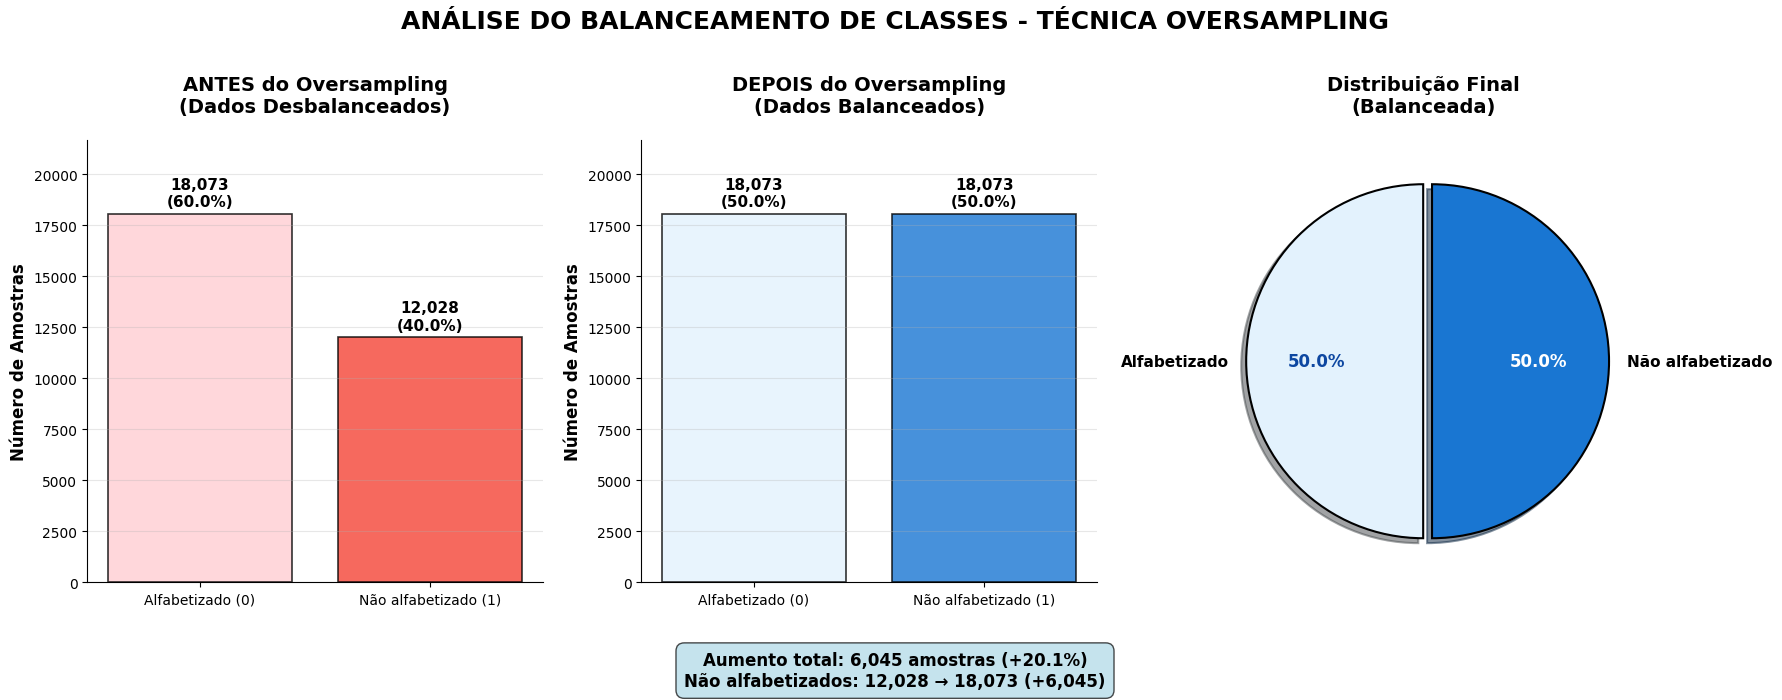

In [55]:
# Visualização da distribuição após Oversampling
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Configurações de cores
cores_depois = ["#E3F2FD", "#1976D2"]  # azul claro e azul escuro
rotulos = ["Alfabetizado (0)", "Não alfabetizado (1)"]

# ===============================
# SUBPLOT 1: Distribuição ANTES do Oversampling
# ===============================
ax1 = axes[0]
before_counts = pd.Series([len(df_majority), len(df_minority)], index=[0, 1])
bars1 = ax1.bar(rotulos, before_counts.values,
                color=["#FFCDD2", "#F44336"], edgecolor="black", linewidth=1.2, alpha=0.8)

# Adicionar valores nas barras
for bar, value in zip(bars1, before_counts.values):
    percentage = (value / before_counts.sum()) * 100
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 200,
             f"{value:,}\n({percentage:.1f}%)",
             ha="center", va="bottom", fontweight="bold", fontsize=11)

ax1.set_title("ANTES do Oversampling\n(Dados Desbalanceados)", fontsize=14, fontweight="bold", pad=20)
ax1.set_ylabel("Número de Amostras", fontsize=12, fontweight="bold")
ax1.grid(axis="y", alpha=0.3)
ax1.set_ylim(0, max(before_counts.values) * 1.2)
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)

# ===============================
# SUBPLOT 2: Distribuição DEPOIS do Oversampling
# ===============================
ax2 = axes[1]
after_counts = pd.Series(y_train_balanced).value_counts().sort_index()
bars2 = ax2.bar(rotulos, after_counts.values,
                color=cores_depois, edgecolor="black", linewidth=1.2, alpha=0.8)

for bar, value in zip(bars2, after_counts.values):
    percentage = (value / after_counts.sum()) * 100
    ax2.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 200,
             f"{value:,}\n({percentage:.1f}%)",
             ha="center", va="bottom", fontweight="bold", fontsize=11)

ax2.set_title("DEPOIS do Oversampling\n(Dados Balanceados)", fontsize=14, fontweight="bold", pad=20)
ax2.set_ylabel("Número de Amostras", fontsize=12, fontweight="bold")
ax2.grid(axis="y", alpha=0.3)
ax2.set_ylim(0, max(after_counts.values) * 1.2)
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)

# ===============================
# SUBPLOT 3: Gráfico de Pizza
# ===============================
ax3 = axes[2]
wedges, texts, autotexts = ax3.pie(after_counts.values,
                                   labels=["Alfabetizado", "Não alfabetizado"],
                                   autopct="%1.1f%%",
                                   colors=cores_depois,
                                   explode=[0, 0.05],
                                   shadow=True,
                                   startangle=90,
                                   wedgeprops={"edgecolor": "black", "linewidth": 1.5})
autotexts[0].set_color("#0D47A1")   # texto escuro sobre a fatia clara
autotexts[1].set_color("white")     # texto claro sobre a fatia escura
for autotext in autotexts:
    autotext.set_fontweight("bold")
    autotext.set_fontsize(12)
for text in texts:
    text.set_fontsize(11)
    text.set_fontweight("bold")
ax3.set_title("Distribuição Final\n(Balanceada)", fontsize=14, fontweight="bold", pad=20)

# ===============================
# TÍTULO GERAL E FINALIZAÇÃO
# ===============================
fig.suptitle("ANÁLISE DO BALANCEAMENTO DE CLASSES - TÉCNICA OVERSAMPLING",
             fontsize=18, fontweight="bold", y=1.02)

increase_samples = len(y_train_balanced) - (len(df_majority) + len(df_minority))
increase_percent = (increase_samples / (len(df_majority) + len(df_minority))) * 100
info_text = (f"Aumento total: {increase_samples:,} amostras (+{increase_percent:.1f}%)\n"
             f"Não alfabetizados: {before_counts[1]:,} → {after_counts[1]:,} (+{after_counts[1] - before_counts[1]:,})")
fig.text(0.5, -0.05, info_text, ha="center", va="top", fontsize=12, fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.7))

plt.tight_layout()
salva(fig, "projeto_balanceamento.png"); plt.show()

In [56]:
# ===============================
# TABELA RESUMO COMPLEMENTAR
# ===============================
print("\n" + "=" * 70)
print("RESUMO ESTATÍSTICO DO BALANCEAMENTO COM OVERSAMPLING".center(70))
print("=" * 70)

ratio_before = len(df_majority) / len(df_minority)
ratio_after = after_counts[0] / after_counts[1]
total_antes = len(df_majority) + len(df_minority)

summary_data = {
    "Métrica": [
        "Total de Amostras",
        "Classe 0 (Alfabetizado)",
        "Classe 1 (Não alfabetizado)",
        "Proporção Classe 1",
        "Razão (Classe 0 / Classe 1)",
    ],
    "Antes do Oversampling": [
        f"{total_antes:,}",
        f"{len(df_majority):,}",
        f"{len(df_minority):,}",
        f"{len(df_minority) / total_antes * 100:.2f}%",
        f"{ratio_before:.2f} : 1",
    ],
    "Depois do Oversampling": [
        f"{len(y_train_balanced):,}",
        f"{after_counts[0]:,}",
        f"{after_counts[1]:,}",
        f"{after_counts[1] / len(y_train_balanced) * 100:.2f}%",
        f"{ratio_after:.2f} : 1",
    ],
    "Variação": [
        f"+{len(y_train_balanced) - total_antes:,}",
        f"+{after_counts[0] - len(df_majority):,}",
        f"+{after_counts[1] - len(df_minority):,}",
        f"{after_counts[1] / len(y_train_balanced) * 100 - len(df_minority) / total_antes * 100:+.2f} p.p.",
        "Balanceado",
    ],
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print("=" * 70)

# Informações adicionais
print("\nINFORMAÇÕES ADICIONAIS:")
print(f"• Amostras replicadas: {after_counts[1] - len(df_minority):,}")
print(f"• Fator de multiplicação da classe minoritária: {after_counts[1] / len(df_minority):.2f}x")
print(f"• Balanceamento alcançado: {after_counts[1] / after_counts[0] * 100:.1f}% (100% = classes iguais)")
print(f"• Validação e teste NÃO foram alterados: {len(y_val):,} e {len(y_test):,} linhas, "
      f"{100 * y_val.mean():.2f}% e {100 * y_test.mean():.2f}% de classe 1")
print("=" * 70)


         RESUMO ESTATÍSTICO DO BALANCEAMENTO COM OVERSAMPLING         
                    Métrica Antes do Oversampling Depois do Oversampling    Variação
          Total de Amostras                30,101                 36,146      +6,045
    Classe 0 (Alfabetizado)                18,073                 18,073          +0
Classe 1 (Não alfabetizado)                12,028                 18,073      +6,045
         Proporção Classe 1                39.96%                 50.00% +10.04 p.p.
Razão (Classe 0 / Classe 1)              1.50 : 1               1.00 : 1  Balanceado

INFORMAÇÕES ADICIONAIS:
• Amostras replicadas: 6,045
• Fator de multiplicação da classe minoritária: 1.50x
• Balanceamento alcançado: 100.0% (100% = classes iguais)
• Validação e teste NÃO foram alterados: 10,034 e 10,034 linhas, 39.96% e 39.96% de classe 1


**Nota:**

- **Antes:** o treino tinha **18.073** crianças alfabetizadas e **12.028** não alfabetizadas (**39,96%**), uma razão de **1,50 para 1**.
- **Depois:** as duas classes ficaram com **18.073** crianças cada (**50%**). O treino passou de **30.101** para **36.146** linhas (**+6.045**, +20,1%).
- **Atenção — as linhas novas são cópias, não crianças novas.** Das 12.028 crianças não alfabetizadas, **9.360** foram
  sorteadas ao menos uma vez e **2.668** nunca foram sorteadas; algumas aparecem duas ou três vezes. O modelo pode
  "decorar" essas crianças repetidas, o que se chama **sobreajuste** (*overfitting*).
- **O desbalanceamento aqui é moderado (60/40).** Em problemas extremos, como fraude ou doença rara (1% contra 99%), o
  balanceamento faz muita diferença. Aqui o ganho tende a ser **pequeno** — por isso vale comparar, na próxima etapa, o
  modelo treinado com e sem balanceamento.
- **Validação e teste não foram tocados:** seguem com **10.034** linhas cada e **39,96%** de não alfabetizados. É contra
  essa proporção real que o modelo será avaliado.
- **Alternativa sem cópias:** a versão anterior do projeto, treinada com 600 mil crianças, usou `class_weight="balanced"`, que dá **peso maior** aos
  erros na classe menor em vez de duplicar linhas. As duas estratégias buscam o mesmo efeito.

### Seleção de Variáveis

Nem toda variável ajuda o modelo da mesma forma. Esta etapa **mede a relevância** de cada uma usando dois métodos
diferentes, que olham o problema por ângulos distintos:

| Método | Como funciona | Em palavras simples |
|---|---|---|
| **Random Forest** | treina várias árvores de decisão e mede o quanto cada variável ajuda a separar as classes | "quais perguntas o modelo mais usou para decidir" |
| **Informação Mútua** | mede o quanto conhecer a variável reduz a incerteza sobre o alvo | "quanto essa variável, sozinha, conta sobre o risco" |

**Um cuidado técnico:** os dois métodos só aceitam números sem vazios. Por isso usamos a **matriz transformada**
(as 81 colunas da etapa 3). O pré-processador é ajustado no **treino original, sem as cópias** — se fosse ajustado nos
dados duplicados, uma criança copiada poderia "ensinar" ao TargetEncoder a própria resposta. Depois disso, as mesmas
posições do balanceamento são aplicadas à matriz transformada.

In [57]:
# Transformando o treino em números (ajuste no treino original, sem cópias)
prep_sel = constroi_preprocessador()
X_train_t = prep_sel.fit_transform(X_train, y_train)
nomes_t = prep_sel.get_feature_names_out()

# Aplicando as mesmas posições do balanceamento à matriz transformada
X_train_balanced_t = pd.DataFrame(X_train_t[idx_balanceado], columns=nomes_t)

print(f"treino transformado ............. {X_train_t.shape}")
print(f"treino transformado balanceado .. {X_train_balanced_t.shape}")

treino transformado ............. (30101, 81)
treino transformado balanceado .. (36146, 81)


num__escola_n_alunos_avaliados     0.1207
num__peso_aluno                    0.0992
alta_card__id_municipio            0.0869
alta_card__id_escola               0.0671
num__mun_ctx_media_portugues       0.0481
num__mun_ctx_taxa_alfabetizacao    0.0432
num__mun_gap_projetado             0.0383
num__mun_meta_2024                 0.0349
num__ibge_pib_per_capita           0.0325
num__ibge_densidade_demografica    0.0320
num__ibge_log_populacao            0.0300
num__mun_n_alunos_avaliados        0.0300
num__ibge_populacao                0.0299
num__mun_n_escolas                 0.0251
num__uf_ctx_media_portugues        0.0159
num__uf_ctx_ranking_nacional       0.0145
num__uf_ctx_taxa_alfabetizacao     0.0131
cat__caderno_1                     0.0103
cat__caderno_3                     0.0100
cat__caderno_7                     0.0100


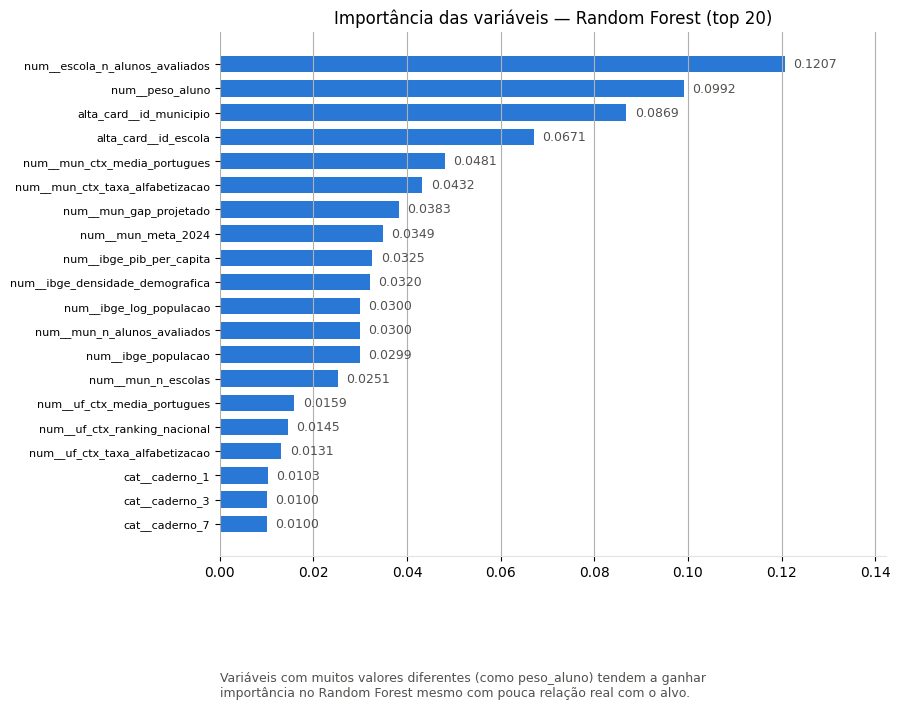

In [58]:
# Construtor do Modelo
clf = RandomForestClassifier(random_state=SEED, n_jobs=-1)

# Ajustando o modelo aos dados
clf = clf.fit(X_train_balanced_t, y_train_balanced)

# Random Forest - classificação das melhores variáveis
importances = pd.Series(clf.feature_importances_, index=nomes_t)
importances = importances.sort_values(ascending=False)
print(importances.head(20).round(4).to_string())

# Visualização das 20 variáveis mais importantes
topo_rf = importances.head(20)
fig, ax = plt.subplots(figsize=(8.6, 6.8))
barras_horizontais(ax, topo_rf.index.tolist(), topo_rf.values.tolist(), formato="{:.4f}")
ax.set_title("Importância das variáveis — Random Forest (top 20)")
ax.tick_params(axis="y", labelsize=8)
anota(ax, "Variáveis com muitos valores diferentes (como peso_aluno) tendem a ganhar\n"
          "importância no Random Forest mesmo com pouca relação real com o alvo.")
salva(fig, "projeto_importancia_rf.png"); plt.show()

**Nota:**

- **O resultado do Random Forest precisa ser lido com cuidado.** As duas primeiras posições são `escola_n_alunos_avaliados`
  (**0,121**) e `peso_aluno` (**0,099**) — justamente variáveis que tinham correlação **quase zero** com o alvo (−0,014 e +0,066).
- **Por que isso acontece?** A importância do Random Forest **favorece variáveis com muitos valores diferentes**: elas oferecem
  mais "pontos de corte" para as árvores, mesmo que a separação seja por acaso. Além disso, com as **cópias do oversampling**,
  a combinação escola + peso funciona quase como uma "identidade" da criança, e as árvores podem **decorar** quem se repete.
- **As variáveis que a análise exploratória apontou aparecem logo depois:** `id_municipio` (**0,087**), `id_escola` (**0,067**),
  `mun_ctx_media_portugues` (**0,048**) e `mun_ctx_taxa_alfabetizacao` (**0,043**) — o **lugar** e o **histórico de 2023**.
- As colunas do estado, uma a uma (`sigla_uf_BA`, `sigla_uf_CE`...), somam só **0,023**: a informação do território já chega
  pelo município, pela escola e pelas taxas de 2023.
- As 8 colunas de aviso de valor ausente somam **0,003** — quase nada.

In [59]:
def Selecao_Features(X_train, y_train, k):
    """
    Função para seleção de features usando Mutual Information para classificação
    """
    # random_state fixo para que o resultado seja o mesmo a cada execução
    Selecao = SelectKBest(score_func=partial(mutual_info_classif, random_state=SEED), k=k)

    # Fitar o aprendizado
    Selecao.fit(X_train, y_train)

    # Criar um dicionário com as informações das colunas e scores
    dict_scores = {"feature": X_train.columns, "score": Selecao.scores_}

    # Transformar o dicionário em um DataFrame e ordenar as colunas por score
    df_scores = pd.DataFrame(dict_scores).sort_values(by="score", ascending=False)

    return df_scores, Selecao

# Aplicar a função Selecao_Features
t0 = time.time()
df_scores, selector = Selecao_Features(X_train_balanced_t, y_train_balanced, k=5)
print(f"informação mútua calculada em {time.time() - t0:.0f}s\n")

print("🎯 RANKING DE FEATURES POR MUTUAL INFORMATION (top 20 de 81):")
print("=" * 50)

# Criar DataFrame comparativo
comparison_df = pd.DataFrame({
    "Feature": df_scores["feature"],
    "Mutual_Info": df_scores["score"],
}).reset_index(drop=True)
print(comparison_df.head(20).round(4))
print(f"\ncolunas com informação mútua igual a zero: {(df_scores['score'] == 0).sum()} de {len(df_scores)}")

# SELEÇÃO DAS MELHORES FEATURES
print("\n🏆 TOP 5 FEATURES SELECIONADAS:")
print("=" * 50)
top_5_features = df_scores.head(5)["feature"].tolist()
for i, feature in enumerate(top_5_features, 1):
    score = df_scores[df_scores["feature"] == feature]["score"].iloc[0]
    print(f"{i}. {feature}: {score:.6f}")

# Obter as features selecionadas pelo SelectKBest
X_train_selected = selector.transform(X_train_balanced_t)
print(f"\n📊 Shape original: {X_train_balanced_t.shape}")
print(f"📊 Shape após seleção: {X_train_selected.shape}")
print(f"📊 Features selecionadas: {top_5_features}")

informação mútua calculada em 56s

🎯 RANKING DE FEATURES POR MUTUAL INFORMATION (top 20 de 81):
                            Feature  Mutual_Info
0      num__mun_ctx_media_portugues       0.0891
1               num__ibge_populacao       0.0857
2          num__ibge_pib_per_capita       0.0830
3           num__ibge_log_populacao       0.0793
4   num__ibge_densidade_demografica       0.0783
5   num__mun_ctx_taxa_alfabetizacao       0.0764
6                num__mun_meta_2024       0.0683
7            num__mun_gap_projetado       0.0590
8           alta_card__id_municipio       0.0372
9       num__mun_n_alunos_avaliados       0.0371
10     num__uf_ctx_ranking_nacional       0.0334
11   num__uf_ctx_taxa_alfabetizacao       0.0296
12      num__uf_ctx_media_portugues       0.0259
13                 cat__sigla_uf_CE       0.0129
14                 cat__sigla_uf_BA       0.0105
15             alta_card__id_escola       0.0098
16              cat__regiao_Sudeste       0.0088
17                  nu

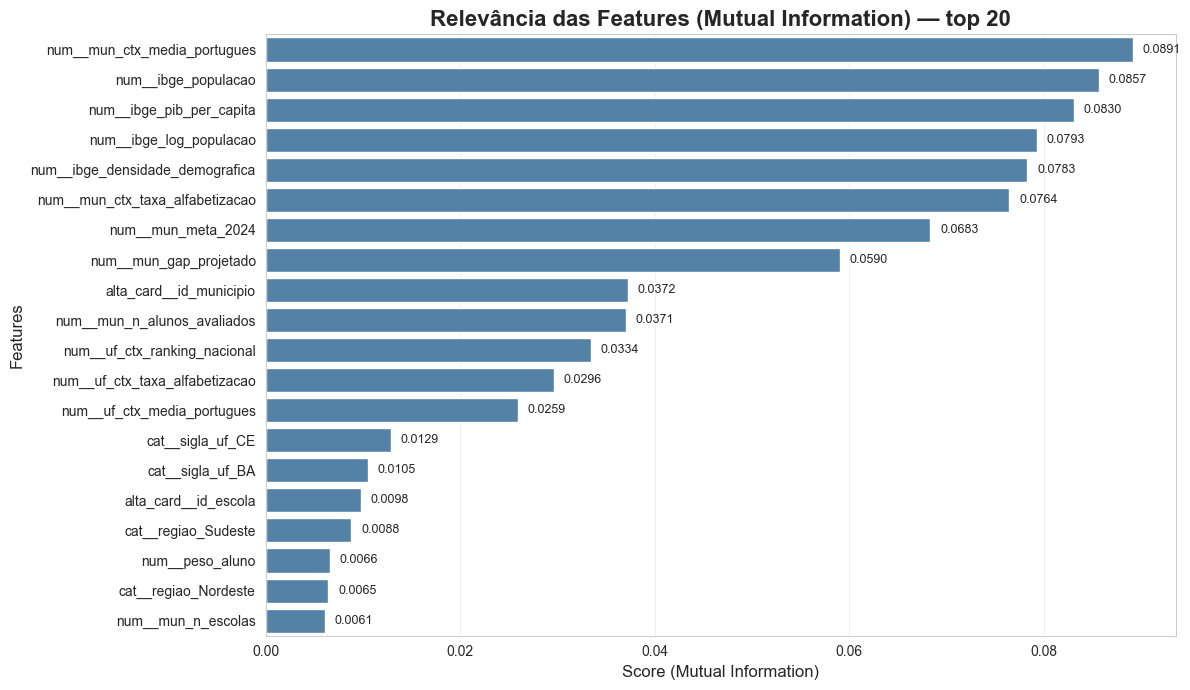

In [60]:
# Plotar o gráfico de barras horizontais (20 primeiras das 81 colunas)
topo_mi = df_scores.head(20)

with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(12, 7))
    sns.barplot(data=topo_mi, x="score", y="feature", orient="h", color="steelblue", ax=ax)

    # Customização do gráfico
    ax.set_title("Relevância das Features (Mutual Information) — top 20", fontsize=16, fontweight="bold")
    ax.set_xlabel("Score (Mutual Information)", fontsize=12)
    ax.set_ylabel("Features", fontsize=12)
    ax.tick_params(axis="both", labelsize=10)

    # Adicionar valores nos finais das barras
    for i, v in enumerate(topo_mi["score"]):
        ax.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9)

    # Grid mais sutil
    ax.grid(axis="x", alpha=0.3)
    fig.tight_layout()
    salva(fig, "projeto_info_mutua.png"); plt.show()

**Nota:**

- **TOP 5 pela informação mútua:** `mun_ctx_media_portugues` (**0,089**), `ibge_populacao` (**0,086**), `ibge_pib_per_capita`
  (**0,083**), `ibge_log_populacao` (**0,079**) e `ibge_densidade_demografica` (**0,078**).
- **Por que as variáveis do IBGE aparecem tão bem, se a correlação delas com o alvo era quase zero?** Porque cada município
  tem um valor **único** de população, PIB e densidade. Na prática, essas colunas funcionam como um **"código do município
  disfarçado"** — e o município, como vimos, é um dos sinais mais fortes. A informação mútua captura isso; a correlação em
  linha reta, não.
- Logo abaixo vêm as variáveis do **histórico de 2023** (`mun_ctx_taxa_alfabetizacao` 0,076, `mun_meta_2024` 0,068,
  `mun_gap_projetado` 0,059) e o **estado** (`sigla_uf_CE` e `sigla_uf_BA`, os dois extremos da H1).
- **29 das 81 colunas têm informação mútua zero:** **12 cadernos de prova**, **10 estados** (um a um), **5 colunas de aviso** de
  valor ausente, `rede_estadual` e `regiao_Sul`. Sozinhas, elas não dizem nada sobre o risco. Curiosamente, alguns cadernos
  aparecem no top 20 do Random Forest (0,010) — mais um sinal do viés daquele método por variáveis que permitem "decorar".
- O `SelectKBest` com **k=5** reduziu a matriz de **81 para 5 colunas** (`X_train_selected`).

**Comparando os dois métodos:**

| | Random Forest | Informação Mútua |
|---|---|---|
| **1º lugar** | `escola_n_alunos_avaliados` | `mun_ctx_media_portugues` |
| **Município / escola** | `id_municipio` 3º, `id_escola` 4º | `id_municipio` 9º, `id_escola` 16º |
| **Histórico de 2023** | 5º a 8º | 1º, 6º a 8º |
| **IBGE** | 9º a 13º | 2º a 5º |
| **Principal viés** | favorece variáveis com muitos valores e as cópias do oversampling | favorece variáveis que identificam o município |

**O que os dois concordam:** o **lugar onde a criança estuda** (município, escola, IBGE como "código" do município) e o
**histórico de 2023** carregam a maior parte da informação. É a mesma conclusão da análise exploratória.

**O que fazer com o resultado?** Esta seleção é um **diagnóstico**. Nenhum método isolado é perfeito, e cortar variáveis
só com base nele poderia descartar sinais úteis (o `id_escola`, por exemplo, ficou fora do TOP 5 da informação mútua).
O `X_train_selected` (5 colunas) fica disponível para **comparar**, na etapa de treinamento, o modelo com todas as
variáveis contra o modelo só com as 5 melhores.

## 5 - **Treinamento dos Algoritmos de Machine Learning**

**Treinar** um algoritmo é mostrar a ele milhares de exemplos (as crianças do treino, com a resposta) para que ele
aprenda os padrões. Depois, pedimos que ele **preveja** crianças que nunca viu — as da **validação** — e comparamos
as previsões com a resposta verdadeira (o **gabarito**).

**Como vamos medir o desempenho** (a classe de interesse é **1 = não alfabetizado**):

| Métrica | Pergunta que ela responde |
|---|---|
| **Acurácia** | De todas as crianças, quantas o modelo acertou? |
| **Precisão** | Das crianças que o modelo apontou como "em risco", quantas realmente não se alfabetizaram? |
| **Recall** | De todas as crianças que não se alfabetizaram, quantas o modelo conseguiu encontrar? |
| **F1-Score** | Um equilíbrio entre precisão e recall |
| **AUC-ROC** | O modelo sabe ordenar quem tem mais risco? (0,5 = sorteio, 1,0 = perfeito) |
| **PR-AUC** | Como a anterior, mas focada na classe de risco (sorteio = 0,40, a proporção de não alfabetizados) |

**Réguas de comparação:** um "modelo" que dissesse **sempre "alfabetizado"** acertaria **60%** das crianças, mas não
encontraria nenhuma em risco. E um sorteio teria **AUC de 0,50** e **PR-AUC de 0,40**. Todo resultado precisa superar isso.

### <font color='#F37126'> XGBoost

O **XGBoost** constrói **centenas de árvores de decisão em sequência**. Cada nova árvore olha para os erros das anteriores
e tenta corrigi-los — como um grupo de professores em que cada um revisa a correção do colega anterior.

- **Treino:** com os dados **balanceados** (36.146 linhas, 50% de cada classe), já transformados em números.
- **Validação:** com os dados **reais** (10.034 crianças, 40% de não alfabetizados), transformados pelo **mesmo**
  pré-processador ajustado no treino.

In [61]:
# Transformando a validação com o pré-processador ajustado no treino (sem reajustar)
X_val_t = pd.DataFrame(prep_sel.transform(X_val), columns=nomes_t)

# Criar a variável do algoritmo
model_xgb = xgb.XGBClassifier(
    random_state=SEED,     # Para reprodutibilidade
    eval_metric="logloss"  # Para evitar warnings
)

# Treinamento com dados BALANCEADOS (matriz transformada)
t0 = time.time()
model_xgb.fit(X_train_balanced_t, y_train_balanced)
print(f"XGBoost treinado em {time.time() - t0:.1f}s")

# Avaliar a performance no conjunto de VALIDAÇÃO (dados NÃO balanceados)
yhat_xgb_val = model_xgb.predict(X_val_t)

XGBoost treinado em 3.8s


In [62]:
# ===========================
# PREDIÇÕES E AVALIAÇÃO
# ===========================

# Obter probabilidades de predição
yhat_xgb_val_proba = model_xgb.predict_proba(X_val_t)[:, 1]

# Comparando gabarito e probabilidades
gabarito_proba = pd.DataFrame({
    "Gabarito": y_val,
    "Probabilidades": yhat_xgb_val_proba
})

print("\n" + "=" * 50)
print("AMOSTRA DAS PROBABILIDADES PREDITAS")
print("=" * 50)
display(gabarito_proba.head(10))

# Convertendo probabilidades em predições binárias (0 ou 1)
threshold = 0.5
yhat_xgb_val = (yhat_xgb_val_proba >= threshold).astype(int)

# Comparando gabarito e predições finais
gabarito_final = pd.DataFrame({
    "Gabarito": y_val,
    "Probabilidades": yhat_xgb_val_proba,
    "Previsoes_da_Máquina": yhat_xgb_val
})

print(f"\nAMOSTRA DAS PREDIÇÕES FINAIS (Threshold = {threshold})")
print("=" * 60)
display(gabarito_final.head(10))

print("=" * 60)
print("RESULTADOS DO TREINAMENTO XGBoost")
print("=" * 60)
print(f"✓ Modelo treinado com: {len(X_train_balanced_t):,} amostras balanceadas")
print(f"✓ Validação realizada com: {len(X_val_t):,} amostras (distribuição real)")
print(f"✓ Predições de validação geradas: {len(yhat_xgb_val):,}")

# Calcular métricas no conjunto de validação
accuracy_val = accuracy_score(y_val, yhat_xgb_val)
precision_val = precision_score(y_val, yhat_xgb_val)
recall_val = recall_score(y_val, yhat_xgb_val)
f1_val = f1_score(y_val, yhat_xgb_val)
auc_val = roc_auc_score(y_val, yhat_xgb_val_proba)
pr_auc_val = average_precision_score(y_val, yhat_xgb_val_proba)

print("\n" + "=" * 40)
print("MÉTRICAS DE VALIDAÇÃO")
print("=" * 40)
print(f"Acurácia:    {accuracy_val:.4f} ({accuracy_val*100:.2f}%)")
print(f"Precisão:    {precision_val:.4f} ({precision_val*100:.2f}%)")
print(f"Recall:      {recall_val:.4f} ({recall_val*100:.2f}%)")
print(f"F1-Score:    {f1_val:.4f} ({f1_val*100:.2f}%)")
print(f"AUC-ROC:     {auc_val:.4f} ({auc_val*100:.2f}%)")
print(f"PR-AUC:      {pr_auc_val:.4f} ({pr_auc_val*100:.2f}%)  <- sorteio = {y_val.mean():.4f}")

# Comparação com o próprio treino, para detectar sobreajuste
auc_treino = roc_auc_score(y_train, model_xgb.predict_proba(pd.DataFrame(X_train_t, columns=nomes_t))[:, 1])
print(f"\nAUC-ROC no treino (sem cópias): {auc_treino:.4f}  |  na validação: {auc_val:.4f}")


AMOSTRA DAS PROBABILIDADES PREDITAS


,Gabarito,Probabilidades
0,1,0.559969
1,1,0.772783
2,1,0.340089
3,0,0.112129
4,1,0.568561
5,0,0.553893
6,0,0.196626
7,0,0.711091
8,1,0.495021
9,1,0.599829



AMOSTRA DAS PREDIÇÕES FINAIS (Threshold = 0.5)


,Gabarito,Probabilidades,Previsoes_da_Máquina
0,1,0.559969,1
1,1,0.772783,1
2,1,0.340089,0
3,0,0.112129,0
4,1,0.568561,1
5,0,0.553893,1
6,0,0.196626,0
7,0,0.711091,1
8,1,0.495021,0
9,1,0.599829,1


RESULTADOS DO TREINAMENTO XGBoost
✓ Modelo treinado com: 36,146 amostras balanceadas
✓ Validação realizada com: 10,034 amostras (distribuição real)
✓ Predições de validação geradas: 10,034

MÉTRICAS DE VALIDAÇÃO
Acurácia:    0.6038 (60.38%)
Precisão:    0.5043 (50.43%)
Recall:      0.5152 (51.52%)
F1-Score:    0.5097 (50.97%)
AUC-ROC:     0.6344 (63.44%)
PR-AUC:      0.5158 (51.58%)  <- sorteio = 0.3996



AUC-ROC no treino (sem cópias): 0.8483  |  na validação: 0.6344


**Nota:**

**1. Como ler as tabelas de amostra**

- **Gabarito** é a resposta verdadeira; **Probabilidades** é a "nota de risco" que o modelo deu a cada criança (de 0 a 1).
- Com o **threshold de 0,5**, toda criança com probabilidade **igual ou acima de 0,5** é prevista como "não alfabetizada" (1).
- Na amostra, a 3ª criança tinha risco de **0,34** e foi prevista como alfabetizada, mas **não** se alfabetizou (um erro);
  a 6ª tinha risco de **0,55**, foi apontada como em risco, mas **se alfabetizou** (outro erro).

**2. As métricas mostram um modelo modesto — e isso precisa ser dito com clareza**

- **Acurácia de 60,38%:** praticamente **igual aos 60%** que acertaríamos dizendo "alfabetizado" para todo mundo. Sozinha,
  ela não mostra ganho nenhum — por isso não é a métrica principal.
- **Precisão de 50,43%:** de cada 100 crianças que o modelo aponta como "em risco", cerca de **50** realmente não se alfabetizaram.
- **Recall de 51,52%:** o modelo encontra cerca de **metade** das crianças que não se alfabetizaram; a outra metade passa despercebida.
- **F1-Score de 50,97%:** confirma o equilíbrio fraco entre precisão e recall.
- **AUC-ROC de 0,634:** o modelo **ordena o risco melhor que um sorteio (0,50)**, mas está longe do ideal.
- **PR-AUC de 0,516:** acima do piso de **0,40** — há **sinal real**, mas fraco.

**3. Sinal de sobreajuste (*overfitting*)**

- No **treino**, o AUC é **0,848**; na **validação**, cai para **0,634**. O modelo aprendeu detalhes das crianças do treino
  (inclusive as **cópias** do oversampling) que não se repetem em crianças novas.

**Por que o resultado é mais fraco que o do projeto original?**

- Esta análise usa uma **amostra de 50 mil crianças** (30 mil no treino), e não as 600 mil crianças usadas em versões anteriores do projeto. Com cerca de
  **uma criança por escola** no treino, o código da escola quase não traz informação.
- O XGBoost está com a **configuração padrão**, sem ajuste fino. Os próximos algoritmos e o ajuste de hiperparâmetros
  vão mostrar se é possível melhorar.
- Como vimos na EDA, **nenhuma variável isolada é forte** e a base não tem dados individuais da criança (renda, frequência...).

In [63]:
# ===========================
# RELATÓRIO DE CLASSIFICAÇÃO COMPLETO
# ===========================
print("\n" + "=" * 60)
print("RELATÓRIO DE CLASSIFICAÇÃO DETALHADO")
print("=" * 60)
print("Classification metrics: \n", classification_report(y_val, yhat_xgb_val,
      target_names=["Alfabetizado (0)", "Não alfabetizado (1)"], digits=4))


RELATÓRIO DE CLASSIFICAÇÃO DETALHADO
Classification metrics: 
                       precision    recall  f1-score   support

    Alfabetizado (0)     0.6726    0.6628    0.6677      6024
Não alfabetizado (1)     0.5043    0.5152    0.5097      4010

            accuracy                         0.6038     10034
           macro avg     0.5884    0.5890    0.5887     10034
        weighted avg     0.6053    0.6038    0.6045     10034



**Nota:**

**Classe 0 (Alfabetizado) — 6.024 crianças:**

- **Precisão: 67,26%** → quando o modelo diz "alfabetizado", acerta cerca de 2 em cada 3 vezes
- **Recall: 66,28%** → reconhece corretamente 66% das crianças que se alfabetizaram
- **F1-Score: 66,77%** → desempenho razoável nesta classe
- Representa **60%** da validação (6.024 de 10.034)

**Classe 1 (Não alfabetizado) — 4.010 crianças:**

- **Precisão: 50,43%** → quando diz "em risco", acerta metade das vezes
- **Recall: 51,52%** → encontra pouco mais da metade das crianças em risco
- **F1-Score: 50,97%** → desempenho fraco na classe que mais importa
- Representa **40%** da validação (4.010 de 10.034)

**Observações Importantes:**

- **A validação NÃO está balanceada** (60/40): ela mantém a proporção real, porque é assim que o modelo será usado.
  O balanceamento 50/50 existiu **só no treino**.
- O modelo vai **melhor na classe 0** do que na classe 1 — justamente o contrário do que queremos, já que o objetivo é
  **encontrar as crianças em risco**.
- **macro avg (0,59)** é a média simples das duas classes; **weighted avg (0,60)** pondera pelo tamanho de cada classe.
  Os dois próximos de 0,60 confirmam o desempenho modesto.


MATRIZ DE CONFUSÃO
Confusion Matrix: 
 [[3993 2031]
 [1944 2066]]


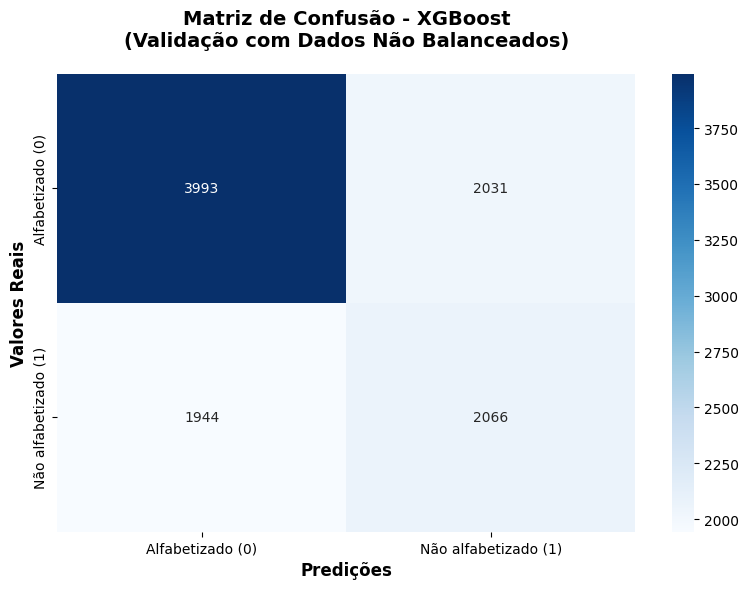


DETALHES DA MATRIZ DE CONFUSÃO:
• Verdadeiros Negativos (TN): 3,993 - Alfabetizados corretamente identificados
• Falsos Positivos (FP): 2,031 - Alfabetizados classificados como Não alfabetizados
• Falsos Negativos (FN): 1,944 - Não alfabetizados classificados como Alfabetizados
• Verdadeiros Positivos (TP): 2,066 - Não alfabetizados corretamente identificados

Total: 10,034 crianças da validação


In [64]:
# ===========================
# MATRIZ DE CONFUSÃO
# ===========================
print("\n" + "=" * 40)
print("MATRIZ DE CONFUSÃO")
print("=" * 40)
cm = confusion_matrix(y_val, yhat_xgb_val)
print("Confusion Matrix: \n", cm)

rotulos_cm = ["Alfabetizado (0)", "Não alfabetizado (1)"]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=rotulos_cm, yticklabels=rotulos_cm)
ax.set_title("Matriz de Confusão - XGBoost\n(Validação com Dados Não Balanceados)",
             fontsize=14, fontweight="bold", pad=20)
ax.set_ylabel("Valores Reais", fontsize=12, fontweight="bold")
ax.set_xlabel("Predições", fontsize=12, fontweight="bold")
fig.tight_layout()
salva(fig, "projeto_matriz_confusao_xgb.png"); plt.show()

# Interpretação da matriz de confusão
tn, fp, fn, tp = cm.ravel()
print("\nDETALHES DA MATRIZ DE CONFUSÃO:")
print(f"• Verdadeiros Negativos (TN): {tn:,} - Alfabetizados corretamente identificados")
print(f"• Falsos Positivos (FP): {fp:,} - Alfabetizados classificados como Não alfabetizados")
print(f"• Falsos Negativos (FN): {fn:,} - Não alfabetizados classificados como Alfabetizados")
print(f"• Verdadeiros Positivos (TP): {tp:,} - Não alfabetizados corretamente identificados")
print(f"\nTotal: {cm.sum():,} crianças da validação")

**Nota:**

**Como ler a matriz:** as **linhas** são a realidade e as **colunas** são o que o modelo previu. A diagonal (de cima à
esquerda até embaixo à direita) são os **acertos**.

| | Previu **Alfabetizado** | Previu **Não alfabetizado** |
|---|---|---|
| **Era Alfabetizado** | ✅ **3.993** acertos (TN) | ⚠️ **2.031** alarmes falsos (FP) |
| **Era Não alfabetizado** | ❌ **1.944** crianças em risco não encontradas (FN) | ✅ **2.066** crianças em risco encontradas (TP) |

- **Acertos: 6.059 de 10.034** (3.993 + 2.066) — os 60,4% de acurácia.
- **O erro mais grave são os 1.944 Falsos Negativos:** crianças que **não se alfabetizaram**, mas que o modelo
  considerou fora de risco. Na prática, elas **ficariam sem reforço escolar**.
- **Os 2.031 Falsos Positivos** são crianças que se alfabetizaram, mas foram apontadas como em risco. O custo é menor:
  receberiam um acompanhamento de que não precisavam.
- O modelo apontou **4.097 crianças** como em risco; delas, **2.066** estavam realmente em risco (a precisão de 50%).

**Conclusão do XGBoost:** o modelo tem **sinal real** (AUC 0,634 e PR-AUC 0,516, acima do sorteio), mas **ainda erra muito**.
É o **ponto de partida**: os próximos algoritmos, o ajuste de hiperparâmetros e a escolha de um **threshold** menor que 0,5
(para encontrar mais crianças em risco, aceitando mais alarmes falsos) serão comparados contra este resultado.

### <font color='#F37126'> Random Forest

O **Random Forest** (floresta aleatória) cria **centenas de árvores de decisão independentes**, cada uma treinada com um
sorteio diferente de crianças e de variáveis. No final, **cada árvore vota** e a maioria decide.

- **Analogia:** é como pedir a opinião de 100 professores que viram turmas um pouco diferentes e fazer uma votação.
- **Diferença para o XGBoost:** no XGBoost as árvores trabalham **em sequência**, uma corrigindo a outra; no Random Forest
  elas trabalham **em paralelo**, sem conversar, e o resultado é a média dos votos.

Treino e validação são os mesmos do XGBoost: **36.146 linhas balanceadas** (transformadas) para aprender e
**10.034 crianças reais** para avaliar.

In [65]:
# Criar a variável do algoritmo
model_rf = RandomForestClassifier(
    random_state=SEED,  # Para reprodutibilidade
    n_estimators=100,   # Número de árvores
    n_jobs=-1           # Usar todos os núcleos do computador (não muda o resultado)
)

# Treinamento com dados BALANCEADOS (matriz transformada)
t0 = time.time()
model_rf.fit(X_train_balanced_t, y_train_balanced)

print("=" * 60)
print("CONFIGURAÇÃO DO RANDOM FOREST")
print("=" * 60)
print(f"✓ Dados de treino: {len(X_train_balanced_t):,} amostras balanceadas")
print(f"✓ Dados de validação: {len(X_val_t):,} amostras (distribuição real)")
print(f"✓ Número de árvores: {model_rf.n_estimators}")
print(f"✓ Random state: {model_rf.random_state}")
print(f"✓ Tempo de treino: {time.time() - t0:.1f}s")

CONFIGURAÇÃO DO RANDOM FOREST
✓ Dados de treino: 36,146 amostras balanceadas
✓ Dados de validação: 10,034 amostras (distribuição real)
✓ Número de árvores: 100
✓ Random state: 42
✓ Tempo de treino: 10.6s


In [66]:
# ===========================
# PREDIÇÕES E AVALIAÇÃO
# ===========================

# Obter probabilidades de predição
yhat_rf_proba = model_rf.predict_proba(X_val_t)[:, 1]

# Comparando gabarito e probabilidades
gabarito_proba = pd.DataFrame({
    "Gabarito": y_val,
    "Probabilidades": yhat_rf_proba
})

print("\n" + "=" * 50)
print("AMOSTRA DAS PROBABILIDADES PREDITAS")
print("=" * 50)
display(gabarito_proba.head(10))

# Convertendo probabilidades em predições binárias (0 ou 1)
threshold = 0.5
yhat_rf = (yhat_rf_proba >= threshold).astype(int)

# Comparando gabarito e predições finais
gabarito_final = pd.DataFrame({
    "Gabarito": y_val,
    "Probabilidades": yhat_rf_proba,
    "Previsoes_da_Máquina": yhat_rf
})

print(f"\nAMOSTRA DAS PREDIÇÕES FINAIS (Threshold = {threshold})")
print("=" * 60)
display(gabarito_final.head(10))

print("=" * 60)
print("RESULTADOS DO TREINAMENTO RANDOM FOREST")
print("=" * 60)
print(f"✓ Modelo treinado com: {len(X_train_balanced_t):,} amostras balanceadas")
print(f"✓ Validação realizada com: {len(X_val_t):,} amostras (distribuição real)")
print(f"✓ Predições de validação geradas: {len(yhat_rf):,}")

# ===========================
# MÉTRICAS DE AVALIAÇÃO
# ===========================

# Calcular todas as métricas
accuracy_rf = accuracy_score(y_val, yhat_rf)
precision_rf = precision_score(y_val, yhat_rf, zero_division=0)
recall_rf = recall_score(y_val, yhat_rf, zero_division=0)
f1_rf = f1_score(y_val, yhat_rf, zero_division=0)
auc_rf = roc_auc_score(y_val, yhat_rf_proba)
pr_auc_rf = average_precision_score(y_val, yhat_rf_proba)

print("\n" + "=" * 60)
print("RESULTADOS DO RANDOM FOREST")
print("=" * 60)
print(f"Threshold usado:  {threshold}")
print(f"Acurácia:        {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")
print(f"Precisão:        {precision_rf:.4f} ({precision_rf*100:.2f}%)")
print(f"Recall:          {recall_rf:.4f} ({recall_rf*100:.2f}%)")
print(f"F1-Score:        {f1_rf:.4f} ({f1_rf*100:.2f}%)")
print(f"AUC-ROC:         {auc_rf:.4f} ({auc_rf*100:.2f}%)")
print(f"PR-AUC:          {pr_auc_rf:.4f} ({pr_auc_rf*100:.2f}%)  <- sorteio = {y_val.mean():.4f}")

# Comparação com o próprio treino, para detectar sobreajuste
auc_treino_rf = roc_auc_score(y_train, model_rf.predict_proba(pd.DataFrame(X_train_t, columns=nomes_t))[:, 1])
acc_treino_bal_rf = accuracy_score(y_train_balanced, model_rf.predict(X_train_balanced_t))
print(f"\nAUC-ROC no treino (sem cópias): {auc_treino_rf:.4f}  |  na validação: {auc_rf:.4f}")
print(f"Acurácia no treino balanceado: {acc_treino_bal_rf*100:.2f}%  |  na validação: {accuracy_rf*100:.2f}%")


AMOSTRA DAS PROBABILIDADES PREDITAS


,Gabarito,Probabilidades
0,1,0.36
1,1,0.76
2,1,0.10
3,0,0.25
4,1,0.49
5,0,0.31
6,0,0.61
7,0,0.70
8,1,0.55
9,1,0.32



AMOSTRA DAS PREDIÇÕES FINAIS (Threshold = 0.5)


,Gabarito,Probabilidades,Previsoes_da_Máquina
0,1,0.36,0
1,1,0.76,1
2,1,0.10,0
3,0,0.25,0
4,1,0.49,0
5,0,0.31,0
6,0,0.61,1
7,0,0.70,1
8,1,0.55,1
9,1,0.32,0


RESULTADOS DO TREINAMENTO RANDOM FOREST
✓ Modelo treinado com: 36,146 amostras balanceadas
✓ Validação realizada com: 10,034 amostras (distribuição real)
✓ Predições de validação geradas: 10,034

RESULTADOS DO RANDOM FOREST
Threshold usado:  0.5
Acurácia:        0.6118 (61.18%)
Precisão:        0.5193 (51.93%)
Recall:          0.3850 (38.50%)
F1-Score:        0.4422 (44.22%)
AUC-ROC:         0.6243 (62.43%)
PR-AUC:          0.5023 (50.23%)  <- sorteio = 0.3996



AUC-ROC no treino (sem cópias): 0.9880  |  na validação: 0.6243
Acurácia no treino balanceado: 99.92%  |  na validação: 61.18%


**Nota:**

**1. Como ler as tabelas de amostra**

- Na amostra, a 3ª criança recebeu risco de apenas **0,10** e foi prevista como alfabetizada, mas **não** se alfabetizou.
- A 7ª criança recebeu risco de **0,61** e foi apontada como em risco, mas **se alfabetizou** (alarme falso).

**2. Métricas — comparadas com o XGBoost**

| Métrica | XGBoost | Random Forest | Quem foi melhor |
|---|---|---|---|
| Acurácia | 60,38% | **61,18%** | Random Forest (+0,8 p.p.) |
| Precisão | 50,43% | **51,93%** | Random Forest (+1,5 p.p.) |
| Recall | **51,52%** | 38,50% | **XGBoost (+13,0 p.p.)** |
| F1-Score | **50,97%** | 44,22% | XGBoost |
| AUC-ROC | **0,634** | 0,624 | XGBoost |
| PR-AUC | **0,516** | 0,502 | XGBoost |

- **A acurácia maior engana.** O Random Forest acerta um pouco mais no geral porque aponta **menos** crianças como em risco
  — e a maioria das crianças está alfabetizada. Mas o **recall cai para 38,50%**: ele encontra só **4 em cada 10** crianças
  que não se alfabetizaram, contra 5 em cada 10 do XGBoost.
- **AUC-ROC (0,624) e PR-AUC (0,502)** continuam acima do sorteio (0,50 e 0,40), mas um pouco **abaixo do XGBoost**.

**3. Sobreajuste forte (*overfitting*)**

- No **treino balanceado**, o Random Forest acerta **99,92%** das crianças; no treino sem cópias, o AUC é **0,988**.
  Na **validação**, o AUC cai para **0,624**.
- Isso quer dizer que o modelo **decorou** o treino — inclusive as crianças repetidas pelo oversampling — em vez de aprender
  padrões que valem para crianças novas. É um comportamento típico do Random Forest com a configuração padrão, em que as
  árvores crescem sem limite de profundidade.

In [67]:
# ===========================
# RELATÓRIO DE CLASSIFICAÇÃO COMPLETO
# ===========================
print("\n" + "=" * 60)
print("RELATÓRIO DE CLASSIFICAÇÃO DETALHADO")
print("=" * 60)
print("Classification metrics: \n", classification_report(y_val, yhat_rf, zero_division=0,
      target_names=["Alfabetizado (0)", "Não alfabetizado (1)"], digits=4))


RELATÓRIO DE CLASSIFICAÇÃO DETALHADO
Classification metrics: 
                       precision    recall  f1-score   support

    Alfabetizado (0)     0.6508    0.7628    0.7023      6024
Não alfabetizado (1)     0.5193    0.3850    0.4422      4010

            accuracy                         0.6118     10034
           macro avg     0.5850    0.5739    0.5723     10034
        weighted avg     0.5982    0.6118    0.5984     10034



**Nota:**

**Classe 0 (Alfabetizado) — 6.024 crianças:**

- **Precisão: 65,08%** → quando o modelo diz "alfabetizado", acerta cerca de 2 em cada 3 vezes
- **Recall: 76,28%** → reconhece 76% das crianças que se alfabetizaram (o XGBoost reconhecia 66%)
- **F1-Score: 70,23%** → o melhor desempenho entre as duas classes

**Classe 1 (Não alfabetizado) — 4.010 crianças:**

- **Precisão: 51,93%** → quando diz "em risco", acerta pouco mais da metade das vezes
- **Recall: 38,50%** → encontra menos de 4 em cada 10 crianças em risco
- **F1-Score: 44,22%** → desempenho fraco, **pior que o do XGBoost (50,97%)**

**Observações Importantes:**

- O Random Forest **"prefere" a classe 0**: ele é mais conservador e só aponta risco quando tem mais certeza. Isso melhora os
  números da classe alfabetizada, mas **deixa passar mais crianças em risco** — o contrário do objetivo do projeto.
- Mesmo com o treino balanceado (50/50), o modelo decorou os exemplos e, diante de crianças novas, tende a responder
  "alfabetizado", que é a resposta mais comum.
- **macro avg (0,57)** e **weighted avg (0,60)** mostram um desempenho geral parecido com o do XGBoost, mas **mal distribuído**
  entre as classes.


MATRIZ DE CONFUSÃO
Confusion Matrix: 
 [[4595 1429]
 [2466 1544]]


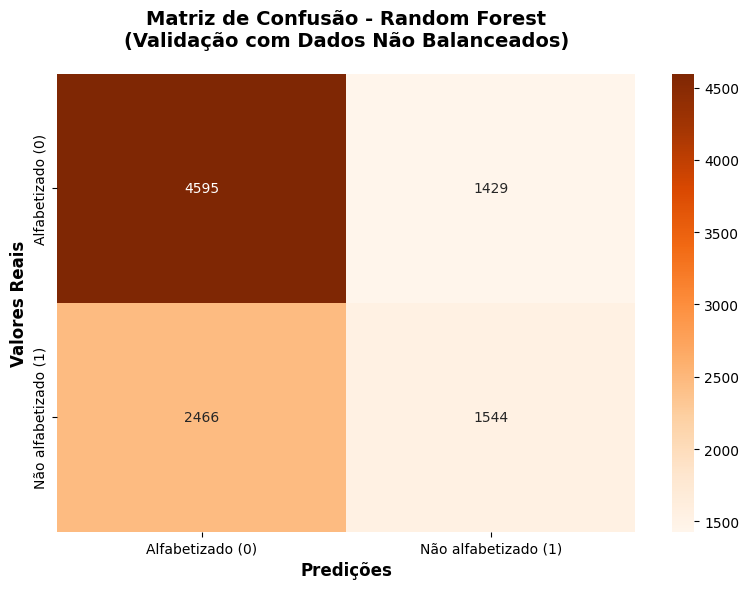


DETALHES DA MATRIZ DE CONFUSÃO:
• Verdadeiros Negativos (TN): 4,595 - Alfabetizados corretamente identificados
• Falsos Positivos (FP): 1,429 - Alfabetizados classificados como Não alfabetizados
• Falsos Negativos (FN): 2,466 - Não alfabetizados classificados como Alfabetizados
• Verdadeiros Positivos (TP): 1,544 - Não alfabetizados corretamente identificados

Total: 10,034 crianças da validação


In [68]:
# ===========================
# MATRIZ DE CONFUSÃO
# ===========================
print("\n" + "=" * 40)
print("MATRIZ DE CONFUSÃO")
print("=" * 40)
cm_rf = confusion_matrix(y_val, yhat_rf)
print("Confusion Matrix: \n", cm_rf)

# Visualização da matriz de confusão
rotulos_cm = ["Alfabetizado (0)", "Não alfabetizado (1)"]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Oranges", ax=ax,
            xticklabels=rotulos_cm, yticklabels=rotulos_cm)
ax.set_title("Matriz de Confusão - Random Forest\n(Validação com Dados Não Balanceados)",
             fontsize=14, fontweight="bold", pad=20)
ax.set_ylabel("Valores Reais", fontsize=12, fontweight="bold")
ax.set_xlabel("Predições", fontsize=12, fontweight="bold")
fig.tight_layout()
salva(fig, "projeto_matriz_confusao_rf.png"); plt.show()

# Interpretação detalhada da matriz
tn, fp, fn, tp = cm_rf.ravel()
print("\nDETALHES DA MATRIZ DE CONFUSÃO:")
print(f"• Verdadeiros Negativos (TN): {tn:,} - Alfabetizados corretamente identificados")
print(f"• Falsos Positivos (FP): {fp:,} - Alfabetizados classificados como Não alfabetizados")
print(f"• Falsos Negativos (FN): {fn:,} - Não alfabetizados classificados como Alfabetizados")
print(f"• Verdadeiros Positivos (TP): {tp:,} - Não alfabetizados corretamente identificados")
print(f"\nTotal: {cm_rf.sum():,} crianças da validação")

**Nota:**

| | Previu **Alfabetizado** | Previu **Não alfabetizado** |
|---|---|---|
| **Era Alfabetizado** | ✅ **4.595** acertos (TN) | ⚠️ **1.429** alarmes falsos (FP) |
| **Era Não alfabetizado** | ❌ **2.466** crianças em risco não encontradas (FN) | ✅ **1.544** crianças em risco encontradas (TP) |

- **Acertos: 6.139 de 10.034** (4.595 + 1.544) — os 61,18% de acurácia.
- **2.466 Falsos Negativos:** crianças que **não se alfabetizaram** e que o modelo considerou fora de risco. É o erro mais
  grave, porque elas **ficariam sem reforço escolar**.
- **1.429 Falsos Positivos:** crianças que se alfabetizaram, mas foram apontadas como em risco.
- O modelo apontou só **2.973 crianças** como em risco (o XGBoost apontou 4.097).

**Comparação direta com o XGBoost:**

| Resultado na validação | XGBoost | Random Forest | Diferença |
|---|---|---|---|
| Crianças em risco **encontradas** (TP) | **2.066** | 1.544 | −522 |
| Crianças em risco **não encontradas** (FN) | **1.944** | 2.466 | **+522** |
| Alarmes falsos (FP) | 2.031 | **1.429** | −602 |
| Acertos totais | 6.059 | **6.139** | +80 |

**Conclusão do Random Forest:** ele **acerta 80 crianças a mais no total**, mas às custas de **deixar 522 crianças em risco
sem identificação**. Como o objetivo do projeto é **encontrar as crianças que precisam de reforço**, o **XGBoost continua
sendo o melhor modelo até aqui** — ele também tem AUC-ROC e PR-AUC maiores. O Random Forest ainda pode melhorar com
ajuste de hiperparâmetros (limitar a profundidade das árvores para reduzir o sobreajuste) ou com um threshold menor que 0,5.

### <font color='#F37126'> Light Gradient Boost Machine ( LGBM )

O **LightGBM** é da mesma família do XGBoost: constrói **árvores em sequência**, cada uma corrigindo os erros das
anteriores. A diferença está no **jeito de crescer as árvores** — ele sempre abre o galho que mais reduz o erro, o que o
torna **mais rápido** e, em geral, muito bom em dados de tabela.

- **Analogia:** se o XGBoost é uma equipe de professores revisando a correção em sequência, o LightGBM é a mesma equipe,
  mas cada professor começa pelas **questões em que a turma mais errou**.
- Aqui usamos a **interface nativa** do LightGBM (`lgb.train`), que permite **acompanhar o desempenho na validação a cada
  rodada** e parar o treino quando ele deixa de melhorar (*early stopping*).

In [69]:
# Criar dataset com dados BALANCEADOS (matrizes transformadas)
train_data = lgb.Dataset(X_train_balanced_t, label=y_train_balanced)
val_data = lgb.Dataset(X_val_t, label=y_val, reference=train_data)

# Configuração de parâmetros para LightGBM
param = {
    "num_leaves": 1000,           # número de folhas em uma árvore; padrão = 31
    "objective": "binary",        # classificação binária
    "max_depth": 7,               # profundidade máxima da árvore
    "learning_rate": 0.01,        # taxa de aprendizado
    "max_bin": 200,               # número máximo de bins
    "boosting_type": "gbdt",      # tipo de boosting
    "feature_fraction": 0.9,      # fração de features para cada iteração
    "bagging_fraction": 0.8,      # fração de dados para cada iteração
    "bagging_freq": 5,            # frequência de bagging
    "verbose": -1,                # silenciar outputs desnecessários
    "random_state": SEED          # para reprodutibilidade
}

param["metric"] = ["auc", "binary_logloss"]

# Número de rodadas de treinamento
num_round = 50

print("=" * 60)
print("CONFIGURAÇÃO DO LIGHTGBM")
print("=" * 60)
print(f"✓ Dados de treino: {len(X_train_balanced_t):,} amostras balanceadas")
print(f"✓ Dados de validação: {len(X_val_t):,} amostras (distribuição real)")
print(f"✓ Número de rounds: {num_round}")
print(f"✓ Learning rate: {param['learning_rate']}")
print()

# Treinamento do modelo
t0 = time.time()
lgbm = lgb.train(
    param,
    train_data,
    num_round,
    valid_sets=[val_data],                                       # conjunto de validação para monitoramento
    callbacks=[lgb.early_stopping(10), lgb.log_evaluation(10)]   # early stopping e logs
)
print(f"\nLightGBM treinado em {time.time() - t0:.1f}s | melhor rodada: {lgbm.best_iteration} de {num_round}")

CONFIGURAÇÃO DO LIGHTGBM
✓ Dados de treino: 36,146 amostras balanceadas
✓ Dados de validação: 10,034 amostras (distribuição real)
✓ Número de rounds: 50
✓ Learning rate: 0.01



Training until validation scores don't improve for 10 rounds


[10]	valid_0's auc: 0.650197	valid_0's binary_logloss: 0.685125


[20]	valid_0's auc: 0.653129	valid_0's binary_logloss: 0.678754


[30]	valid_0's auc: 0.653881	valid_0's binary_logloss: 0.673483


[40]	valid_0's auc: 0.65506	valid_0's binary_logloss: 0.669006


[50]	valid_0's auc: 0.655938	valid_0's binary_logloss: 0.665405
Did not meet early stopping. Best iteration is:
[49]	valid_0's auc: 0.656102	valid_0's binary_logloss: 0.665691

LightGBM treinado em 3.2s | melhor rodada: 49 de 50


**Nota:**

**O que significam os parâmetros (em palavras simples):**

| Parâmetro | Valor | O que faz |
|---|---|---|
| `num_leaves` | 1000 | quantas "respostas finais" cada árvore pode ter |
| `max_depth` | 7 | quantas perguntas seguidas cada árvore pode fazer |
| `learning_rate` | 0,01 | o tamanho do "passo" de cada árvore na correção — pequeno = aprende devagar e com cuidado |
| `feature_fraction` | 0,9 | cada árvore olha 90% das variáveis, sorteadas |
| `bagging_fraction` / `bagging_freq` | 0,8 / 5 | a cada 5 rodadas, sorteia 80% das crianças para treinar |
| `max_bin` | 200 | em quantas faixas cada variável numérica é dividida |

- **Atenção:** `num_leaves=1000` não é alcançado. Com `max_depth=7`, cada árvore tem **no máximo 2⁷ = 128 folhas**.

**Como ler o log do treino:**

- A cada 10 rodadas o LightGBM mostra o **AUC** (quanto maior, melhor) e o **logloss** (quanto menor, melhor) **na validação**.
- O AUC subiu de **0,650** (rodada 10) para **0,656** (rodada 50), e o logloss caiu de **0,685** para **0,665**: o modelo
  **ainda estava melhorando** quando o treino acabou.
- O *early stopping* **não chegou a parar o treino** ("Did not meet early stopping"): ele só interrompe se o resultado ficar
  10 rodadas sem melhorar. A melhor rodada foi a **49**.
- **Sobre usar a validação para parar o treino:** a validação passa a ajudar a escolher o modelo, que é justamente o papel
  dela. O **teste continua intocado**, guardado para a avaliação final.
- **Sinal importante:** com passo pequeno (0,01) e **só 50 rodadas**, o modelo ficou "tímido" — veremos a seguir que as
  probabilidades ficam todas perto de 0,5. Mais rodadas provavelmente melhorariam o resultado.

In [70]:
# ===========================
# PREDIÇÕES E AVALIAÇÃO
# ===========================

# Obter probabilidades de predição
yhat_lgbm_proba = lgbm.predict(X_val_t, num_iteration=lgbm.best_iteration)

# Comparando gabarito e probabilidades
gabarito_proba = pd.DataFrame({
    "Gabarito": y_val,
    "Probabilidades": yhat_lgbm_proba
})

print("\n" + "=" * 50)
print("AMOSTRA DAS PROBABILIDADES PREDITAS")
print("=" * 50)
display(gabarito_proba.head(10))

# Convertendo probabilidades em predições binárias (0 ou 1)
threshold = 0.5
yhat_lgbm = (yhat_lgbm_proba >= threshold).astype(int)

# Comparando gabarito e predições finais
gabarito_final = pd.DataFrame({
    "Gabarito": y_val,
    "Probabilidades": yhat_lgbm_proba,
    "Previsoes_da_Máquina": yhat_lgbm
})

print(f"\nAMOSTRA DAS PREDIÇÕES FINAIS (Threshold = {threshold})")
print("=" * 60)
display(gabarito_final.head(10))

# Faixa das probabilidades: mostra se o modelo está "confiante" ou "tímido"
print(f"\nProbabilidades na validação: mínimo {yhat_lgbm_proba.min():.4f} | "
      f"mediana {np.median(yhat_lgbm_proba):.4f} | máximo {yhat_lgbm_proba.max():.4f}")

# Verificar se há predições positivas antes de calcular métricas
if (yhat_lgbm == 1).sum() == 0:
    print("\n" + "🚨" + "=" * 60)
    print("PROBLEMA DETECTADO: NENHUMA PREDIÇÃO POSITIVA!")
    print("=" * 60)
    print("O modelo não está prevendo nenhuma criança como não alfabetizada.")
    print("Isso pode indicar:")
    print("1. Problema no pré-processamento dos dados")
    print("2. Parâmetros inadequados do modelo")
    print("3. Dados de entrada com problemas")
    print("4. Necessidade de ajuste do threshold")

    # Tentar threshold mais baixo
    new_threshold = np.percentile(yhat_lgbm_proba, 95)
    yhat_lgbm_adjusted = (yhat_lgbm_proba >= new_threshold).astype(int)

    print(f"\nTentando threshold mais baixo: {new_threshold:.6f}")
    print("Predições com novo threshold:")
    print(f"• Classe 0: {(yhat_lgbm_adjusted == 0).sum()}")
    print(f"• Classe 1: {(yhat_lgbm_adjusted == 1).sum()}")

    if (yhat_lgbm_adjusted == 1).sum() > 0:
        yhat_lgbm = yhat_lgbm_adjusted
        threshold = new_threshold
        print(f"✅ Usando threshold ajustado: {threshold:.6f}")
    else:
        print("❌ Mesmo com threshold baixo, sem predições positivas")
else:
    print(f"✓ Verificação OK: {(yhat_lgbm == 1).sum():,} crianças previstas como não alfabetizadas")

# Calcular métricas com tratamento de warnings
try:
    accuracy_lgbm = accuracy_score(y_val, yhat_lgbm)
    precision_lgbm = precision_score(y_val, yhat_lgbm, zero_division=0)
    recall_lgbm = recall_score(y_val, yhat_lgbm, zero_division=0)
    f1_lgbm = f1_score(y_val, yhat_lgbm, zero_division=0)
    auc_lgbm = roc_auc_score(y_val, yhat_lgbm_proba)
    pr_auc_lgbm = average_precision_score(y_val, yhat_lgbm_proba)

    print("\n" + "=" * 60)
    print("RESULTADOS DO LIGHTGBM")
    print("=" * 60)
    print(f"Threshold usado:  {threshold:.6f}")
    print(f"Acurácia:        {accuracy_lgbm:.4f} ({accuracy_lgbm*100:.2f}%)")
    print(f"Precisão:        {precision_lgbm:.4f} ({precision_lgbm*100:.2f}%)")
    print(f"Recall:          {recall_lgbm:.4f} ({recall_lgbm*100:.2f}%)")
    print(f"F1-Score:        {f1_lgbm:.4f} ({f1_lgbm*100:.2f}%)")
    print(f"AUC-ROC:         {auc_lgbm:.4f} ({auc_lgbm*100:.2f}%)")
    print(f"PR-AUC:          {pr_auc_lgbm:.4f} ({pr_auc_lgbm*100:.2f}%)  <- sorteio = {y_val.mean():.4f}")

    if precision_lgbm == 0 or recall_lgbm == 0:
        print("\n⚠️  ATENÇÃO: Precisão ou Recall = 0 indica problema no modelo!")

except Exception as e:
    print(f"\n❌ Erro ao calcular métricas: {e}")
    accuracy_lgbm = precision_lgbm = recall_lgbm = f1_lgbm = auc_lgbm = pr_auc_lgbm = 0

# Comparação com o próprio treino, para detectar sobreajuste
auc_treino_lgbm = roc_auc_score(
    y_train, lgbm.predict(pd.DataFrame(X_train_t, columns=nomes_t), num_iteration=lgbm.best_iteration))
print(f"\nAUC-ROC no treino (sem cópias): {auc_treino_lgbm:.4f}  |  na validação: {auc_lgbm:.4f}")


AMOSTRA DAS PROBABILIDADES PREDITAS


,Gabarito,Probabilidades
0,1,0.549238
1,1,0.602717
2,1,0.452240
3,0,0.448364
4,1,0.521103
5,0,0.531263
6,0,0.451492
7,0,0.574982
8,1,0.515176
9,1,0.505551



AMOSTRA DAS PREDIÇÕES FINAIS (Threshold = 0.5)


,Gabarito,Probabilidades,Previsoes_da_Máquina
0,1,0.549238,1
1,1,0.602717,1
2,1,0.452240,0
3,0,0.448364,0
4,1,0.521103,1
5,0,0.531263,1
6,0,0.451492,0
7,0,0.574982,1
8,1,0.515176,1
9,1,0.505551,1



Probabilidades na validação: mínimo 0.3069 | mediana 0.4934 | máximo 0.6396
✓ Verificação OK: 4,638 crianças previstas como não alfabetizadas

RESULTADOS DO LIGHTGBM
Threshold usado:  0.500000
Acurácia:        0.6129 (61.29%)
Precisão:        0.5136 (51.36%)
Recall:          0.5940 (59.40%)
F1-Score:        0.5509 (55.09%)
AUC-ROC:         0.6561 (65.61%)
PR-AUC:          0.5353 (53.53%)  <- sorteio = 0.3996



AUC-ROC no treino (sem cópias): 0.7088  |  na validação: 0.6561

**Nota:**

**1. Como ler as tabelas de amostra**

- As probabilidades ficam **todas perto de 0,5**: na validação inteira vão de **0,31 a 0,64**. O modelo é "tímido" — nunca
  tem muita certeza — por causa do passo pequeno (0,01) e das poucas rodadas.
- Na amostra, a 3ª criança recebeu **0,45** e foi prevista como alfabetizada, mas **não** se alfabetizou; a 6ª recebeu
  **0,53**, foi apontada como em risco, mas **se alfabetizou**.
- A verificação de "nenhuma predição positiva" **não foi acionada**: o modelo apontou **4.638 crianças** como em risco.

**2. Métricas — comparadas com os modelos anteriores**

| Métrica | XGBoost | Random Forest | **LightGBM** |
|---|---|---|---|
| Acurácia | 60,38% | 61,18% | **61,29%** |
| Precisão | 50,43% | **51,93%** | 51,36% |
| Recall | 51,52% | 38,50% | **59,40%** |
| F1-Score | 50,97% | 44,22% | **55,09%** |
| AUC-ROC | 0,634 | 0,624 | **0,656** |
| PR-AUC | 0,516 | 0,502 | **0,535** |

- **O LightGBM é o melhor em 5 das 6 métricas.** Só perde em precisão para o Random Forest, por menos de 0,6 ponto.
- **Recall de 59,40%:** encontra **6 em cada 10** crianças em risco — 8 pontos a mais que o XGBoost e 21 a mais que o Random Forest.
- **AUC-ROC de 0,656 e PR-AUC de 0,535:** as maiores até aqui, bem acima do sorteio (0,50 e 0,40).

**3. Quase sem sobreajuste**

- AUC de **0,709 no treino** contra **0,656 na validação**: uma diferença pequena. O XGBoost (0,848 → 0,634) e o Random Forest
  (0,988 → 0,624) decoraram muito mais o treino.
- O passo pequeno e as árvores limitadas (profundidade 7) funcionaram como um **freio**: o modelo aprendeu padrões mais gerais.

In [71]:
# ===========================
# RELATÓRIO DE CLASSIFICAÇÃO COMPLETO
# ===========================
print("\n" + "=" * 60)
print("RELATÓRIO DE CLASSIFICAÇÃO DETALHADO")
print("=" * 60)
print("Classification metrics: \n", classification_report(y_val, yhat_lgbm, zero_division=0,
      target_names=["Alfabetizado (0)", "Não alfabetizado (1)"], digits=4))


RELATÓRIO DE CLASSIFICAÇÃO DETALHADO
Classification metrics: 
                       precision    recall  f1-score   support

    Alfabetizado (0)     0.6983    0.6255    0.6599      6024
Não alfabetizado (1)     0.5136    0.5940    0.5509      4010

            accuracy                         0.6129     10034
           macro avg     0.6059    0.6098    0.6054     10034
        weighted avg     0.6245    0.6129    0.6163     10034



**Nota:**

**Classe 0 (Alfabetizado) — 6.024 crianças:**

- **Precisão: 69,83%** → quando o modelo diz "alfabetizado", acerta 7 em cada 10 vezes (a maior entre os três modelos)
- **Recall: 62,55%** → reconhece 63% das crianças que se alfabetizaram
- **F1-Score: 65,99%**

**Classe 1 (Não alfabetizado) — 4.010 crianças:**

- **Precisão: 51,36%** → quando diz "em risco", acerta pouco mais da metade das vezes
- **Recall: 59,40%** → encontra quase 6 em cada 10 crianças em risco (o melhor dos três modelos)
- **F1-Score: 55,09%** → o melhor equilíbrio na classe que mais importa

**Observações Importantes:**

- É o **modelo mais equilibrado entre as duas classes**: o desempenho na classe 1 ficou mais perto do da classe 0.
- O LightGBM **aceita mais alarmes falsos** para **encontrar mais crianças em risco** — a troca certa para este problema.
- **macro avg (0,61)** e **weighted avg (0,62)** são os maiores entre os três modelos.


MATRIZ DE CONFUSÃO
Confusion Matrix: 
 [[3768 2256]
 [1628 2382]]


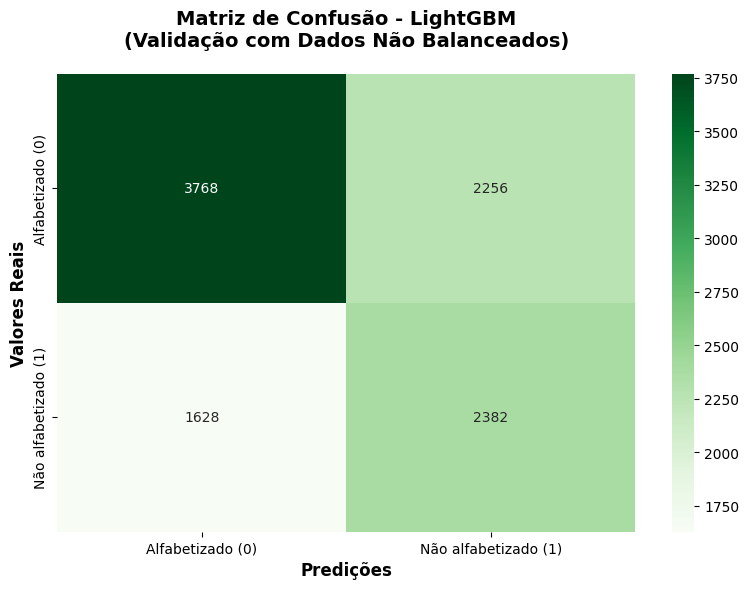


DETALHES DA MATRIZ DE CONFUSÃO:
• Verdadeiros Negativos (TN): 3,768 - Alfabetizados corretamente identificados
• Falsos Positivos (FP): 2,256 - Alfabetizados classificados como Não alfabetizados
• Falsos Negativos (FN): 1,628 - Não alfabetizados classificados como Alfabetizados
• Verdadeiros Positivos (TP): 2,382 - Não alfabetizados corretamente identificados

Total: 10,034 crianças da validação


In [72]:
# ===========================
# MATRIZ DE CONFUSÃO
# ===========================
print("\n" + "=" * 40)
print("MATRIZ DE CONFUSÃO")
print("=" * 40)
cm_lgbm = confusion_matrix(y_val, yhat_lgbm)
print("Confusion Matrix: \n", cm_lgbm)

# Visualização da matriz de confusão
rotulos_cm = ["Alfabetizado (0)", "Não alfabetizado (1)"]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_lgbm, annot=True, fmt="d", cmap="Greens", ax=ax,
            xticklabels=rotulos_cm, yticklabels=rotulos_cm)
ax.set_title("Matriz de Confusão - LightGBM\n(Validação com Dados Não Balanceados)",
             fontsize=14, fontweight="bold", pad=20)
ax.set_ylabel("Valores Reais", fontsize=12, fontweight="bold")
ax.set_xlabel("Predições", fontsize=12, fontweight="bold")
fig.tight_layout()
salva(fig, "projeto_matriz_confusao_lgbm.png"); plt.show()

# Interpretação detalhada da matriz
tn, fp, fn, tp = cm_lgbm.ravel()
print("\nDETALHES DA MATRIZ DE CONFUSÃO:")
print(f"• Verdadeiros Negativos (TN): {tn:,} - Alfabetizados corretamente identificados")
print(f"• Falsos Positivos (FP): {fp:,} - Alfabetizados classificados como Não alfabetizados")
print(f"• Falsos Negativos (FN): {fn:,} - Não alfabetizados classificados como Alfabetizados")
print(f"• Verdadeiros Positivos (TP): {tp:,} - Não alfabetizados corretamente identificados")
print(f"\nTotal: {cm_lgbm.sum():,} crianças da validação")

**Nota:**

| | Previu **Alfabetizado** | Previu **Não alfabetizado** |
|---|---|---|
| **Era Alfabetizado** | ✅ **3.768** acertos (TN) | ⚠️ **2.256** alarmes falsos (FP) |
| **Era Não alfabetizado** | ❌ **1.628** crianças em risco não encontradas (FN) | ✅ **2.382** crianças em risco encontradas (TP) |

- **Acertos: 6.150 de 10.034** (3.768 + 2.382) — os 61,29% de acurácia, o maior número de acertos entre os três modelos.
- **1.628 Falsos Negativos:** ainda são muitas crianças em risco sem identificação, mas é o **menor número até aqui**.
- **2.256 Falsos Positivos:** o custo da estratégia — mais crianças que se alfabetizaram recebem um alerta desnecessário.

**Comparação entre os três modelos:**

| Resultado na validação | XGBoost | Random Forest | **LightGBM** |
|---|---|---|---|
| Crianças em risco **encontradas** (TP) | 2.066 | 1.544 | **2.382** |
| Crianças em risco **não encontradas** (FN) | 1.944 | 2.466 | **1.628** |
| Alarmes falsos (FP) | 2.031 | **1.429** | 2.256 |
| Acertos totais | 6.059 | 6.139 | **6.150** |
| AUC-ROC / PR-AUC | 0,634 / 0,516 | 0,624 / 0,502 | **0,656 / 0,535** |

**Conclusão do LightGBM:** é o **melhor modelo até aqui**. Encontra **316 crianças em risco a mais que o XGBoost** e
**838 a mais que o Random Forest**, com o maior número de acertos totais e quase sem sobreajuste. O preço são **225 alarmes
falsos a mais** que o XGBoost — uma troca aceitável quando o objetivo é **não deixar crianças sem reforço**.

Como o AUC **ainda subia na rodada 50**, há espaço para melhorar com **mais rodadas** e **ajuste de hiperparâmetros**.

### <font color='#F37126'> Regressão Logística

A **Regressão Logística** é o modelo mais simples dos quatro. Ela funciona como uma **fórmula de pontos**: cada variável
**soma ou subtrai** um pouco de risco, e a soma final vira uma probabilidade entre 0 e 1.

- **Analogia:** é como uma ficha de avaliação em que cada item vale pontos — "município com nota baixa em 2023: +pontos",
  "estado com bom histórico: −pontos". No fim, soma-se tudo.
- **Vantagem:** é fácil de **explicar** — dá para ver quanto cada variável pesa.
- **Limitação:** ela só enxerga relações "em linha reta" e não combina variáveis sozinha, como fazem as árvores.

**Um cuidado extra:** como os pontos de cada variável dependem da **escala** (população em milhões × taxa em %), as variáveis
numéricas são **padronizadas** antes (`escalar=True`), para ficarem comparáveis. O pré-processador é ajustado no
**treino original, sem cópias**, e depois as mesmas posições do balanceamento são aplicadas.

In [73]:
# Pré-processador com padronização (a Regressão Logística é sensível à escala)
prep_lr = constroi_preprocessador(escalar=True)
X_train_lr = prep_lr.fit_transform(X_train, y_train)           # ajuste no treino original, sem cópias
nomes_lr = prep_lr.get_feature_names_out()
X_train_balanced_lr = pd.DataFrame(X_train_lr[idx_balanceado], columns=nomes_lr)
X_val_lr = pd.DataFrame(prep_lr.transform(X_val), columns=nomes_lr)

# Criar a variável do algoritmo
model_lr = LogisticRegression(
    max_iter=1000,        # número máximo de iterações para o ajuste convergir
    random_state=SEED     # Para reprodutibilidade
)

# Treinamento com dados BALANCEADOS
t0 = time.time()
model_lr.fit(X_train_balanced_lr, y_train_balanced)

print("=" * 60)
print("CONFIGURAÇÃO DA REGRESSÃO LOGÍSTICA")
print("=" * 60)
print(f"✓ Dados de treino: {len(X_train_balanced_lr):,} amostras balanceadas (padronizadas)")
print(f"✓ Dados de validação: {len(X_val_lr):,} amostras (distribuição real)")
print(f"✓ Iterações até convergir: {model_lr.n_iter_[0]} (máximo {model_lr.max_iter})")
print(f"✓ Tempo de treino: {time.time() - t0:.1f}s")

CONFIGURAÇÃO DA REGRESSÃO LOGÍSTICA
✓ Dados de treino: 36,146 amostras balanceadas (padronizadas)
✓ Dados de validação: 10,034 amostras (distribuição real)
✓ Iterações até convergir: 63 (máximo 1000)
✓ Tempo de treino: 0.9s


In [74]:
# ===========================
# PREDIÇÕES E AVALIAÇÃO
# ===========================

# Obter probabilidades de predição
yhat_lr_proba = model_lr.predict_proba(X_val_lr)[:, 1]

# Comparando gabarito e probabilidades
gabarito_proba = pd.DataFrame({
    "Gabarito": y_val,
    "Probabilidades": yhat_lr_proba
})

print("\n" + "=" * 50)
print("AMOSTRA DAS PROBABILIDADES PREDITAS")
print("=" * 50)
display(gabarito_proba.head(10))

# Convertendo probabilidades em predições binárias (0 ou 1)
threshold = 0.5
yhat_lr = (yhat_lr_proba >= threshold).astype(int)

# Comparando gabarito e predições finais
gabarito_final = pd.DataFrame({
    "Gabarito": y_val,
    "Probabilidades": yhat_lr_proba,
    "Previsoes_da_Máquina": yhat_lr
})

print(f"\nAMOSTRA DAS PREDIÇÕES FINAIS (Threshold = {threshold})")
print("=" * 60)
display(gabarito_final.head(10))

print("=" * 60)
print("RESULTADOS DO TREINAMENTO REGRESSÃO LOGÍSTICA")
print("=" * 60)
print(f"✓ Modelo treinado com: {len(X_train_balanced_lr):,} amostras balanceadas")
print(f"✓ Validação realizada com: {len(X_val_lr):,} amostras (distribuição real)")
print(f"✓ Predições de validação geradas: {len(yhat_lr):,}")

# ===========================
# MÉTRICAS DE AVALIAÇÃO
# ===========================
accuracy_lr = accuracy_score(y_val, yhat_lr)
precision_lr = precision_score(y_val, yhat_lr, zero_division=0)
recall_lr = recall_score(y_val, yhat_lr, zero_division=0)
f1_lr = f1_score(y_val, yhat_lr, zero_division=0)
auc_lr = roc_auc_score(y_val, yhat_lr_proba)
pr_auc_lr = average_precision_score(y_val, yhat_lr_proba)

print("\n" + "=" * 60)
print("RESULTADOS DA REGRESSÃO LOGÍSTICA")
print("=" * 60)
print(f"Threshold usado:  {threshold}")
print(f"Acurácia:        {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")
print(f"Precisão:        {precision_lr:.4f} ({precision_lr*100:.2f}%)")
print(f"Recall:          {recall_lr:.4f} ({recall_lr*100:.2f}%)")
print(f"F1-Score:        {f1_lr:.4f} ({f1_lr*100:.2f}%)")
print(f"AUC-ROC:         {auc_lr:.4f} ({auc_lr*100:.2f}%)")
print(f"PR-AUC:          {pr_auc_lr:.4f} ({pr_auc_lr*100:.2f}%)  <- sorteio = {y_val.mean():.4f}")

# Comparação com o próprio treino, para detectar sobreajuste
auc_treino_lr = roc_auc_score(y_train, model_lr.predict_proba(pd.DataFrame(X_train_lr, columns=nomes_lr))[:, 1])
print(f"\nAUC-ROC no treino (sem cópias): {auc_treino_lr:.4f}  |  na validação: {auc_lr:.4f}")
print(f"Probabilidades na validação: mínimo {yhat_lr_proba.min():.4f} | "
      f"mediana {np.median(yhat_lr_proba):.4f} | máximo {yhat_lr_proba.max():.4f}")


AMOSTRA DAS PROBABILIDADES PREDITAS


,Gabarito,Probabilidades
0,1,0.599525
1,1,0.743376
2,1,0.411945
3,0,0.345286
4,1,0.564196
5,0,0.601265
6,0,0.328172
7,0,0.710060
8,1,0.518670
9,1,0.503974



AMOSTRA DAS PREDIÇÕES FINAIS (Threshold = 0.5)


,Gabarito,Probabilidades,Previsoes_da_Máquina
0,1,0.599525,1
1,1,0.743376,1
2,1,0.411945,0
3,0,0.345286,0
4,1,0.564196,1
5,0,0.601265,1
6,0,0.328172,0
7,0,0.710060,1
8,1,0.518670,1
9,1,0.503974,1


RESULTADOS DO TREINAMENTO REGRESSÃO LOGÍSTICA
✓ Modelo treinado com: 36,146 amostras balanceadas
✓ Validação realizada com: 10,034 amostras (distribuição real)
✓ Predições de validação geradas: 10,034

RESULTADOS DA REGRESSÃO LOGÍSTICA
Threshold usado:  0.5
Acurácia:        0.6102 (61.02%)
Precisão:        0.5104 (51.04%)
Recall:          0.6075 (60.75%)
F1-Score:        0.5547 (55.47%)
AUC-ROC:         0.6598 (65.98%)
PR-AUC:          0.5467 (54.67%)  <- sorteio = 0.3996

AUC-ROC no treino (sem cópias): 0.6669  |  na validação: 0.6598
Probabilidades na validação: mínimo 0.0394 | mediana 0.4905 | máximo 0.9794


**Nota:**

**1. Como ler as tabelas de amostra**

- Diferente do LightGBM, as probabilidades se espalham por **toda a escala** (de **0,04 a 0,98**): a Regressão Logística
  "se compromete" mais com cada resposta.
- Na amostra, a 3ª criança recebeu **0,41** e foi prevista como alfabetizada, mas **não** se alfabetizou; a 6ª recebeu
  **0,60**, foi apontada como em risco, mas **se alfabetizou**.

**2. Métricas — a surpresa da comparação**

| Métrica | XGBoost | Random Forest | LightGBM | **Regressão Logística** |
|---|---|---|---|---|
| Acurácia | 60,38% | 61,18% | **61,29%** | 61,02% |
| Precisão | 50,43% | **51,93%** | 51,36% | 51,04% |
| Recall | 51,52% | 38,50% | 59,40% | **60,75%** |
| F1-Score | 50,97% | 44,22% | 55,09% | **55,47%** |
| AUC-ROC | 0,634 | 0,624 | 0,656 | **0,660** |
| PR-AUC | 0,516 | 0,502 | 0,535 | **0,547** |

- **O modelo mais simples ficou em 1º lugar em 4 das 6 métricas**, justamente as mais importantes para o projeto:
  **recall, F1, AUC-ROC e PR-AUC**.
- **Recall de 60,75%:** encontra **6 em cada 10** crianças em risco — o maior de todos.
- Perde por pouco em acurácia (−0,27 ponto para o LightGBM) e em precisão (−0,89 para o Random Forest).

**3. Nenhum sobreajuste**

- AUC de **0,667 no treino** e **0,660 na validação** — praticamente iguais. Por ser uma "fórmula de pontos", a Regressão
  Logística **não consegue decorar** crianças individuais, nem as cópias do oversampling.

**Por que o modelo simples venceu?** Com apenas **30 mil crianças** no treino e sinais fracos e espalhados (como vimos na EDA),
os modelos de árvore têm pouco material para descobrir combinações e acabam **aprendendo ruído**. A fórmula simples captura
o essencial — território e histórico de 2023 — sem se perder em detalhes.

In [75]:
# ===========================
# RELATÓRIO DE CLASSIFICAÇÃO COMPLETO
# ===========================
print("\n" + "=" * 60)
print("RELATÓRIO DE CLASSIFICAÇÃO DETALHADO")
print("=" * 60)
print("Classification metrics: \n", classification_report(y_val, yhat_lr, zero_division=0,
      target_names=["Alfabetizado (0)", "Não alfabetizado (1)"], digits=4))


RELATÓRIO DE CLASSIFICAÇÃO DETALHADO
Classification metrics: 
                       precision    recall  f1-score   support

    Alfabetizado (0)     0.7008    0.6121    0.6534      6024
Não alfabetizado (1)     0.5104    0.6075    0.5547      4010

            accuracy                         0.6102     10034
           macro avg     0.6056    0.6098    0.6041     10034
        weighted avg     0.6247    0.6102    0.6140     10034



**Nota:**

**Classe 0 (Alfabetizado) — 6.024 crianças:**

- **Precisão: 70,08%** → quando o modelo diz "alfabetizado", acerta 7 em cada 10 vezes (a maior entre os quatro modelos)
- **Recall: 61,21%** → reconhece 61% das crianças que se alfabetizaram
- **F1-Score: 65,34%**

**Classe 1 (Não alfabetizado) — 4.010 crianças:**

- **Precisão: 51,04%** → quando diz "em risco", acerta cerca de metade das vezes
- **Recall: 60,75%** → encontra 6 em cada 10 crianças em risco (o maior entre os quatro)
- **F1-Score: 55,47%** → o melhor equilíbrio na classe que mais importa

**Observações Importantes:**

- O comportamento é muito parecido com o do LightGBM: os dois **aceitam mais alarmes falsos para encontrar mais crianças em risco**.
- **macro avg (0,60)** e **weighted avg (0,61)** ficam no mesmo nível do LightGBM.
- Quando o modelo diz "alfabetizado", a confiança é de **70%**; quando diz "em risco", é de **51%**. Isso é esperado:
  como 60% das crianças se alfabetizam, é mais fácil acertar essa resposta.


MATRIZ DE CONFUSÃO
Confusion Matrix: 
 [[3687 2337]
 [1574 2436]]


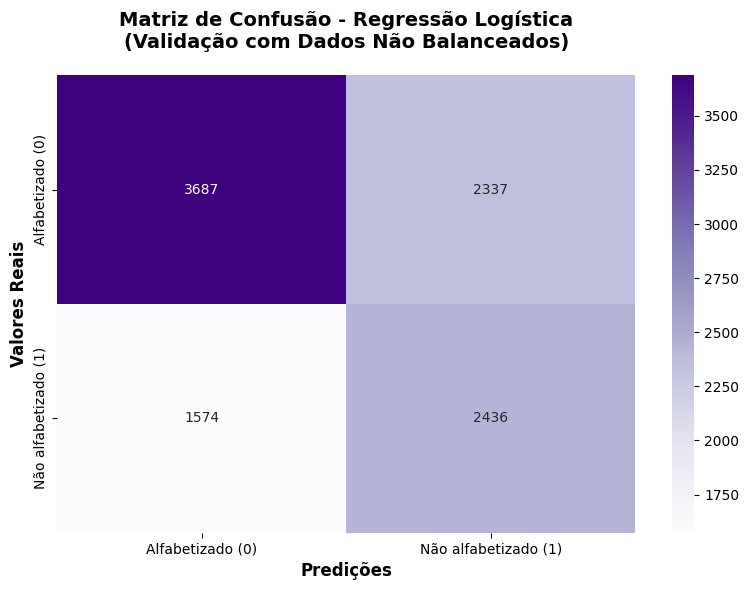


DETALHES DA MATRIZ DE CONFUSÃO:
• Verdadeiros Negativos (TN): 3,687 - Alfabetizados corretamente identificados
• Falsos Positivos (FP): 2,337 - Alfabetizados classificados como Não alfabetizados
• Falsos Negativos (FN): 1,574 - Não alfabetizados classificados como Alfabetizados
• Verdadeiros Positivos (TP): 2,436 - Não alfabetizados corretamente identificados

Total: 10,034 crianças da validação


In [76]:
# ===========================
# MATRIZ DE CONFUSÃO
# ===========================
print("\n" + "=" * 40)
print("MATRIZ DE CONFUSÃO")
print("=" * 40)
cm_lr = confusion_matrix(y_val, yhat_lr)
print("Confusion Matrix: \n", cm_lr)

# Visualização da matriz de confusão
rotulos_cm = ["Alfabetizado (0)", "Não alfabetizado (1)"]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Purples", ax=ax,
            xticklabels=rotulos_cm, yticklabels=rotulos_cm)
ax.set_title("Matriz de Confusão - Regressão Logística\n(Validação com Dados Não Balanceados)",
             fontsize=14, fontweight="bold", pad=20)
ax.set_ylabel("Valores Reais", fontsize=12, fontweight="bold")
ax.set_xlabel("Predições", fontsize=12, fontweight="bold")
fig.tight_layout()
salva(fig, "projeto_matriz_confusao_lr.png"); plt.show()

# Interpretação detalhada da matriz
tn, fp, fn, tp = cm_lr.ravel()
print("\nDETALHES DA MATRIZ DE CONFUSÃO:")
print(f"• Verdadeiros Negativos (TN): {tn:,} - Alfabetizados corretamente identificados")
print(f"• Falsos Positivos (FP): {fp:,} - Alfabetizados classificados como Não alfabetizados")
print(f"• Falsos Negativos (FN): {fn:,} - Não alfabetizados classificados como Alfabetizados")
print(f"• Verdadeiros Positivos (TP): {tp:,} - Não alfabetizados corretamente identificados")
print(f"\nTotal: {cm_lr.sum():,} crianças da validação")

**Nota:**

| | Previu **Alfabetizado** | Previu **Não alfabetizado** |
|---|---|---|
| **Era Alfabetizado** | ✅ **3.687** acertos (TN) | ⚠️ **2.337** alarmes falsos (FP) |
| **Era Não alfabetizado** | ❌ **1.574** crianças em risco não encontradas (FN) | ✅ **2.436** crianças em risco encontradas (TP) |

- **Acertos: 6.123 de 10.034** (3.687 + 2.436) — os 61,02% de acurácia.
- **1.574 Falsos Negativos:** o **menor número entre os quatro modelos** — 54 crianças em risco a menos sem identificação
  que o LightGBM.
- **2.337 Falsos Positivos:** o maior número de alarmes falsos, 81 a mais que o LightGBM. É o preço de encontrar mais crianças em risco.
- O modelo apontou **4.773 crianças** como em risco.

In [77]:
# O que a "fórmula de pontos" aprendeu: as variáveis que mais somam e mais subtraem risco
coeficientes = pd.Series(model_lr.coef_[0], index=nomes_lr).sort_values()
print("VARIÁVEIS QUE MAIS DIMINUEM O RISCO (coeficiente negativo):")
print(coeficientes.head(8).round(3).to_string())
print("\nVARIÁVEIS QUE MAIS AUMENTAM O RISCO (coeficiente positivo):")
print(coeficientes.tail(8).iloc[::-1].round(3).to_string())

VARIÁVEIS QUE MAIS DIMINUEM O RISCO (coeficiente negativo):
num__mun_ctx_media_portugues   -0.390
num__mun_n_escolas             -0.281
cat__sigla_uf_MS               -0.251
cat__sigla_uf_SE               -0.236
cat__sigla_uf_AC               -0.218
cat__sigla_uf_SC               -0.215
cat__sigla_uf_PR               -0.179
cat__sigla_uf_TO               -0.179

VARIÁVEIS QUE MAIS AUMENTAM O RISCO (coeficiente positivo):
cat__sigla_uf_RS               0.540
alta_card__id_escola           0.382
cat__sigla_uf_BA               0.361
alta_card__id_municipio        0.340
cat__sigla_uf_RO               0.302
num__mun_n_alunos_avaliados    0.223
cat__sigla_uf_DF               0.216
cat__regiao_Sul                0.145


**Nota:**

Como as variáveis foram padronizadas, os **coeficientes** mostram quanto cada uma "soma" (positivo) ou "subtrai" (negativo)
de risco, na mesma régua.

- **O que mais diminui o risco:** `mun_ctx_media_portugues` (**−0,39**) — quanto maior a nota de português do município em
  2023, menor o risco em 2024. É a **H2** aparecendo na fórmula.
- **O que mais aumenta o risco:** estar no **Rio Grande do Sul** (`sigla_uf_RS`, **+0,54**), a **escola** (`id_escola`, **+0,38**),
  estar na **Bahia** (**+0,36**) e o **município** (`id_municipio`, **+0,34**).
- **O caso do Rio Grande do Sul:** como registrado no dicionário de dados, a taxa do RS **caiu cerca de 20 pontos em 2024**. O
  histórico de 2023 (bom) não antecipava isso, e a fórmula "compensa" com um peso alto para o estado.
- **Cuidado ao interpretar:** variáveis parecidas **dividem o peso entre si**. Por exemplo, `sigla_uf_SE` aparece com sinal
  negativo, embora Sergipe tivesse taxa baixa em 2023 — parte desse efeito já está nas colunas de taxa e nota. Os coeficientes
  mostram o efeito de cada variável **com as outras fixas**, não o efeito isolado.

## 6 - **Comparação do desempenho dos modelos**

Agora os **quatro modelos** são colocados lado a lado, com as mesmas métricas, na mesma **validação** (10.034 crianças).
Além das métricas já vistas, entram duas novas:

| Métrica | Pergunta que ela responde |
|---|---|
| **Especificidade** | De todas as crianças que **se alfabetizaram**, quantas o modelo reconheceu como fora de risco? |
| **Valor Preditivo Negativo (VPN)** | Quando o modelo diz "**alfabetizado**", quantas vezes ele acerta? |

In [78]:
# ===========================
# CÁLCULO DAS MÉTRICAS PARA TODOS OS MODELOS
# ===========================

def calcular_metricas_completas(y_true, y_pred, y_proba, modelo_nome):
    """Calcula todas as métricas de avaliação para um modelo"""

    # Verificar se há predições positivas
    if (y_pred == 1).sum() == 0:
        print(f"⚠️  ATENÇÃO: {modelo_nome} não fez predições positivas!")

    # Calcular métricas básicas
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # Métricas avançadas
    auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)   # métrica principal do projeto

    # Matriz de confusão
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Métricas derivadas
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Negative Predictive Value

    return {
        "Acurácia": accuracy,
        "Precisão": precision,
        "Recall (Sensibilidade)": recall,
        "F1-Score": f1,
        "AUC-ROC": auc,
        "PR-AUC": pr_auc,
        "Especificidade": specificity,
        "Valor Preditivo Negativo": npv,
        "Verdadeiros Positivos": tp,
        "Verdadeiros Negativos": tn,
        "Falsos Positivos": fp,
        "Falsos Negativos": fn
    }

# Calcular métricas para cada modelo
print("Calculando métricas para todos os modelos...")

# XGBoost
metricas_xgb = calcular_metricas_completas(y_val, yhat_xgb_val, yhat_xgb_val_proba, "XGBoost")

# LightGBM
metricas_lgbm = calcular_metricas_completas(y_val, yhat_lgbm, yhat_lgbm_proba, "LightGBM")

# Random Forest
metricas_rf = calcular_metricas_completas(y_val, yhat_rf, yhat_rf_proba, "Random Forest")

# Regressão Logística
metricas_lr = calcular_metricas_completas(y_val, yhat_lr, yhat_lr_proba, "Regressão Logística")

# ===========================
# TABELA COMPARATIVA PRINCIPAL
# ===========================

metricas_principais = ["Acurácia", "Precisão", "Recall (Sensibilidade)", "F1-Score", "AUC-ROC",
                       "PR-AUC", "Especificidade", "Valor Preditivo Negativo"]

metricas_numericas = {
    "XGBoost": metricas_xgb,
    "LightGBM": metricas_lgbm,
    "Random Forest": metricas_rf,
    "Regressão Logística": metricas_lr
}

df_comparacao = pd.DataFrame({
    modelo: [f"{m[metrica]:.4f} ({m[metrica]*100:.2f}%)" for metrica in metricas_principais]
    for modelo, m in metricas_numericas.items()
}, index=metricas_principais)

print("\n" + "=" * 80)
print("📊 TABELA COMPARATIVA DE MÉTRICAS")
print("=" * 80)
display(df_comparacao)

# ===========================
# RANKING DOS MODELOS
# ===========================

rankings = {}
for metrica in metricas_principais:
    scores = {modelo: metricas_numericas[modelo][metrica] for modelo in metricas_numericas.keys()}
    ranking = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    rankings[metrica] = ranking

print("\n" + "=" * 80)
print("🏆 RANKING DOS MODELOS POR MÉTRICA")
print("=" * 80)

medalhas = {1: "🥇", 2: "🥈", 3: "🥉", 4: "4️⃣"}
for metrica, ranking in rankings.items():
    print(f"\n{metrica}:")
    for i, (modelo, score) in enumerate(ranking, 1):
        print(f"  {medalhas[i]} {i}º lugar: {modelo} - {score:.4f} ({score*100:.2f}%)")

Calculando métricas para todos os modelos...



📊 TABELA COMPARATIVA DE MÉTRICAS


,XGBoost,LightGBM,Random Forest,Regressão Logística
Acurácia,0.6038 (60.38%),0.6129 (61.29%),0.6118 (61.18%),0.6102 (61.02%)
Precisão,0.5043 (50.43%),0.5136 (51.36%),0.5193 (51.93%),0.5104 (51.04%)
Recall (Sensibilidade),0.5152 (51.52%),0.5940 (59.40%),0.3850 (38.50%),0.6075 (60.75%)
F1-Score,0.5097 (50.97%),0.5509 (55.09%),0.4422 (44.22%),0.5547 (55.47%)
AUC-ROC,0.6344 (63.44%),0.6561 (65.61%),0.6243 (62.43%),0.6598 (65.98%)
PR-AUC,0.5158 (51.58%),0.5353 (53.53%),0.5023 (50.23%),0.5467 (54.67%)
Especificidade,0.6628 (66.28%),0.6255 (62.55%),0.7628 (76.28%),0.6121 (61.21%)
Valor Preditivo Negativo,0.6726 (67.26%),0.6983 (69.83%),0.6508 (65.08%),0.7008 (70.08%)



🏆 RANKING DOS MODELOS POR MÉTRICA

Acurácia:
  🥇 1º lugar: LightGBM - 0.6129 (61.29%)
  🥈 2º lugar: Random Forest - 0.6118 (61.18%)
  🥉 3º lugar: Regressão Logística - 0.6102 (61.02%)
  4️⃣ 4º lugar: XGBoost - 0.6038 (60.38%)

Precisão:
  🥇 1º lugar: Random Forest - 0.5193 (51.93%)
  🥈 2º lugar: LightGBM - 0.5136 (51.36%)
  🥉 3º lugar: Regressão Logística - 0.5104 (51.04%)
  4️⃣ 4º lugar: XGBoost - 0.5043 (50.43%)

Recall (Sensibilidade):
  🥇 1º lugar: Regressão Logística - 0.6075 (60.75%)
  🥈 2º lugar: LightGBM - 0.5940 (59.40%)
  🥉 3º lugar: XGBoost - 0.5152 (51.52%)
  4️⃣ 4º lugar: Random Forest - 0.3850 (38.50%)

F1-Score:
  🥇 1º lugar: Regressão Logística - 0.5547 (55.47%)
  🥈 2º lugar: LightGBM - 0.5509 (55.09%)
  🥉 3º lugar: XGBoost - 0.5097 (50.97%)
  4️⃣ 4º lugar: Random Forest - 0.4422 (44.22%)

AUC-ROC:
  🥇 1º lugar: Regressão Logística - 0.6598 (65.98%)
  🥈 2º lugar: LightGBM - 0.6561 (65.61%)
  🥉 3º lugar: XGBoost - 0.6344 (63.44%)
  4️⃣ 4º lugar: Random Forest - 0.6243 (

**Nota:**

**Quem vence cada métrica:**

| Métrica | 🥇 1º lugar | 🥈 2º lugar | Último lugar |
|---|---|---|---|
| Acurácia | LightGBM (61,29%) | Random Forest (61,18%) | XGBoost (60,38%) |
| Precisão | Random Forest (51,93%) | LightGBM (51,36%) | XGBoost (50,43%) |
| **Recall** | **Regressão Logística (60,75%)** | LightGBM (59,40%) | Random Forest (38,50%) |
| **F1-Score** | **Regressão Logística (55,47%)** | LightGBM (55,09%) | Random Forest (44,22%) |
| **AUC-ROC** | **Regressão Logística (0,660)** | LightGBM (0,656) | Random Forest (0,624) |
| **PR-AUC** | **Regressão Logística (0,547)** | LightGBM (0,535) | Random Forest (0,502) |
| Especificidade | Random Forest (76,28%) | XGBoost (66,28%) | Regressão Logística (61,21%) |
| VPN | Regressão Logística (70,08%) | LightGBM (69,83%) | Random Forest (65,08%) |

- **A Regressão Logística vence 5 das 8 métricas**, incluindo as quatro mais importantes para o projeto (recall, F1, AUC-ROC
  e PR-AUC). O **LightGBM** fica em 2º lugar em quase todas, **muito perto**.
- **O Random Forest é o "especialista em alfabetizados":** tem a maior especificidade (reconhece 76% de quem se alfabetizou) e a
  maior precisão, mas é o **pior em encontrar crianças em risco** (recall de 38,50%).
- **Especificidade e recall andam em sentidos opostos:** quem aponta mais crianças como "em risco" encontra mais delas (recall)
  mas erra mais entre as alfabetizadas (especificidade). É uma **escolha**, e para este projeto o recall pesa mais.
- **VPN de 70%** na Regressão Logística: quando ela diz que a criança está fora de risco, acerta 7 em cada 10 vezes.

In [79]:
# ===========================
# MATRIZ DE CONFUSÃO COMPARATIVA
# ===========================

print("=" * 80)
print("📋 MATRIZES DE CONFUSÃO DETALHADAS")
print("=" * 80)

modelos_info = [
    ("XGBoost", yhat_xgb_val, metricas_xgb),
    ("LightGBM", yhat_lgbm, metricas_lgbm),
    ("Random Forest", yhat_rf, metricas_rf),
    ("Regressão Logística", yhat_lr, metricas_lr)
]

for modelo_nome, y_pred, metricas in modelos_info:
    print(f"\n{modelo_nome.upper()}:")
    print("-" * 40)
    cm = confusion_matrix(y_val, y_pred)
    print(f"Matriz de Confusão:\n{cm}")
    print(f"TP: {metricas['Verdadeiros Positivos']}, TN: {metricas['Verdadeiros Negativos']}")
    print(f"FP: {metricas['Falsos Positivos']}, FN: {metricas['Falsos Negativos']}")

📋 MATRIZES DE CONFUSÃO DETALHADAS

XGBOOST:
----------------------------------------
Matriz de Confusão:
[[3993 2031]
 [1944 2066]]
TP: 2066, TN: 3993
FP: 2031, FN: 1944

LIGHTGBM:
----------------------------------------
Matriz de Confusão:
[[3768 2256]
 [1628 2382]]
TP: 2382, TN: 3768
FP: 2256, FN: 1628

RANDOM FOREST:
----------------------------------------
Matriz de Confusão:
[[4595 1429]
 [2466 1544]]
TP: 1544, TN: 4595
FP: 1429, FN: 2466

REGRESSÃO LOGÍSTICA:
----------------------------------------
Matriz de Confusão:
[[3687 2337]
 [1574 2436]]
TP: 2436, TN: 3687
FP: 2337, FN: 1574


**Nota:**

| Resultado na validação | XGBoost | Random Forest | LightGBM | Regressão Logística |
|---|---|---|---|---|
| Crianças em risco **encontradas** (TP) | 2.066 | 1.544 | 2.382 | **2.436** |
| Crianças em risco **não encontradas** (FN) | 1.944 | 2.466 | 1.628 | **1.574** |
| Alarmes falsos (FP) | 2.031 | **1.429** | 2.256 | 2.337 |
| Alfabetizadas reconhecidas (TN) | 3.993 | **4.595** | 3.768 | 3.687 |

- **Das 4.010 crianças que não se alfabetizaram**, a Regressão Logística encontrou **2.436** e o Random Forest apenas **1.544** —
  uma diferença de **892 crianças** que receberiam ou não o reforço escolar.
- Entre os dois melhores, a diferença é pequena: a Regressão Logística encontra **54 crianças em risco a mais** que o
  LightGBM, ao custo de **81 alarmes falsos a mais**.

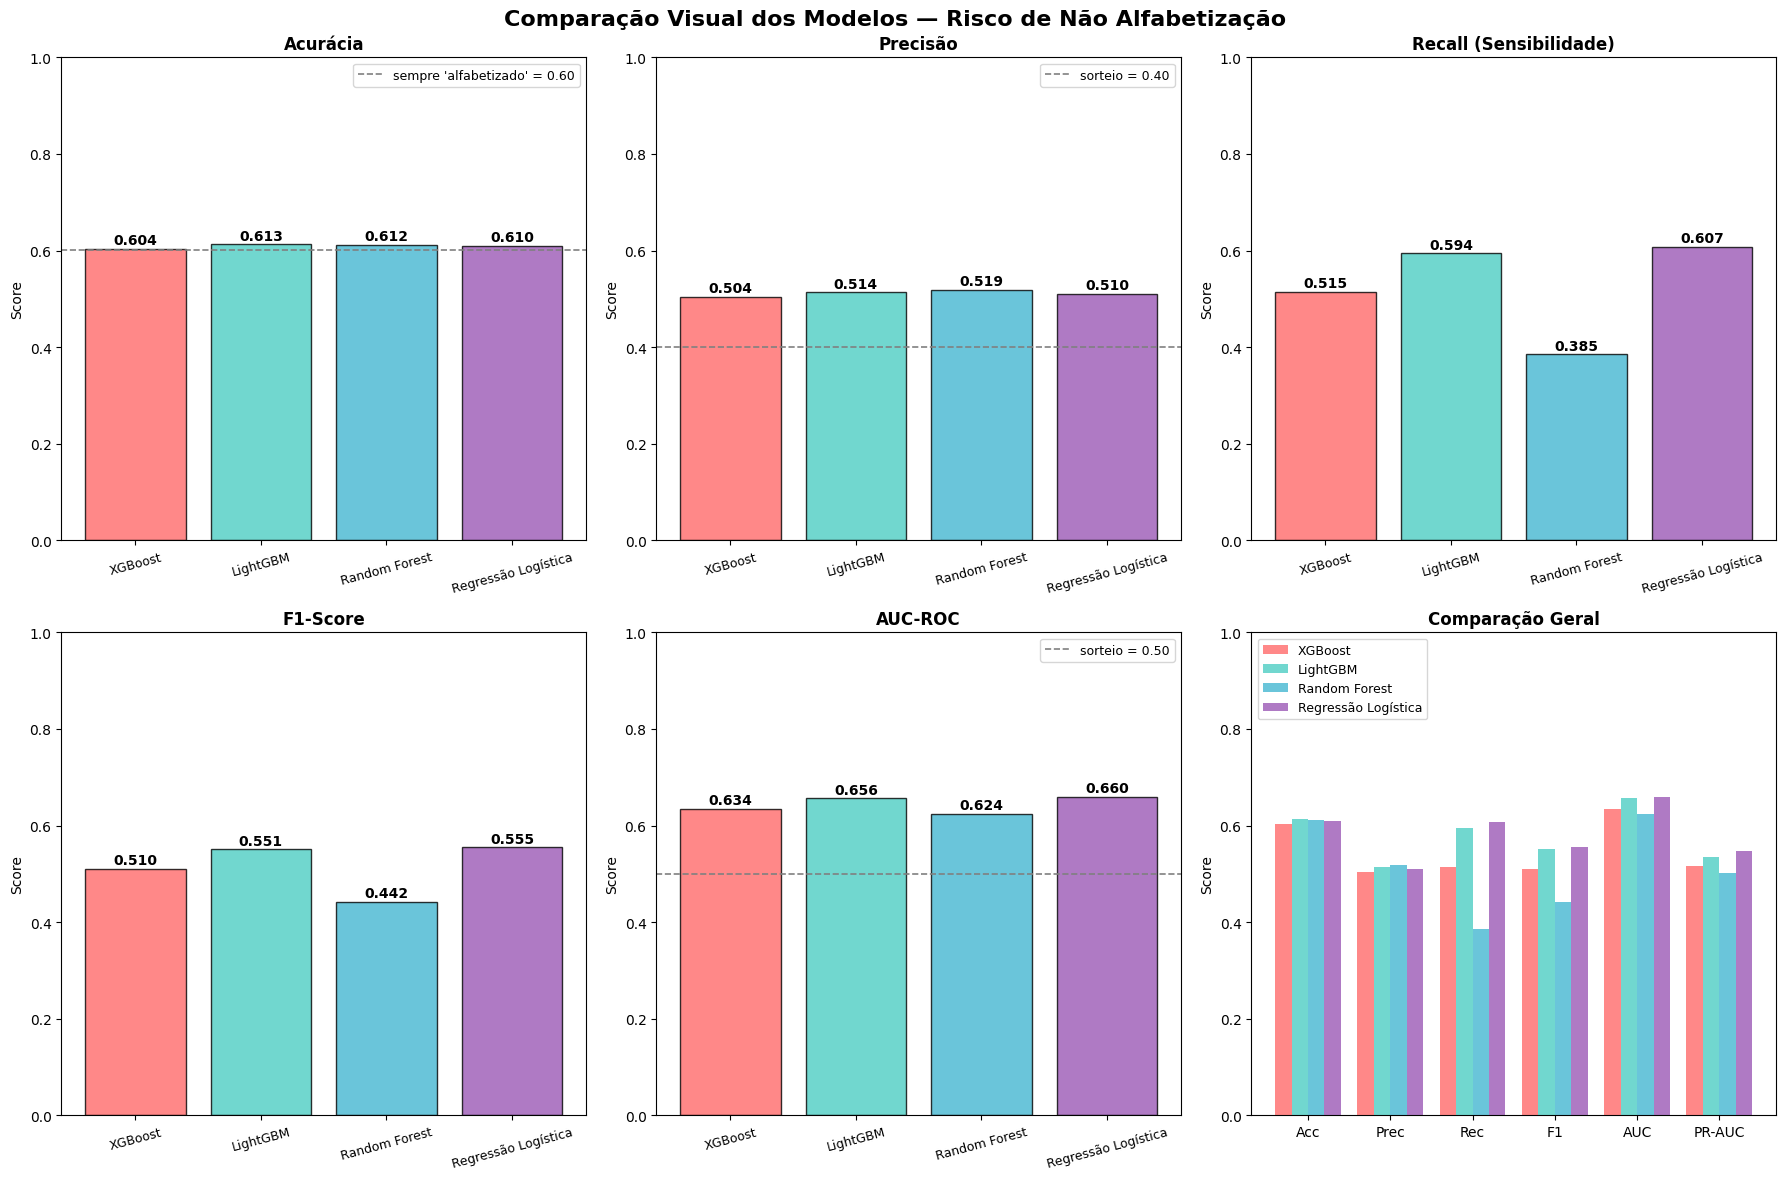

In [80]:
# ===========================
# VISUALIZAÇÃO COMPARATIVA
# ===========================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Comparação Visual dos Modelos — Risco de Não Alfabetização", fontsize=16, fontweight="bold")

modelos = list(metricas_numericas.keys())
cores = ["#FF6B6B", "#4ECDC4", "#45B7D1", "#9B59B6"]

# Um gráfico de barras por métrica, com a linha de referência de um "modelo que chuta"
graficos = [
    ("Acurácia", "Acurácia", 1 - y_val.mean(), "sempre 'alfabetizado'"),
    ("Precisão", "Precisão", y_val.mean(), "sorteio"),
    ("Recall (Sensibilidade)", "Recall (Sensibilidade)", None, None),
    ("F1-Score", "F1-Score", None, None),
    ("AUC-ROC", "AUC-ROC", 0.5, "sorteio"),
]

for ax, (metrica, titulo, referencia, rotulo_ref) in zip(axes.ravel(), graficos):
    valores = [metricas_numericas[modelo][metrica] for modelo in modelos]
    ax.bar(modelos, valores, color=cores, alpha=0.8, edgecolor="black")
    ax.set_title(titulo, fontweight="bold")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", labelsize=9, rotation=15)
    for i, v in enumerate(valores):
        ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontweight="bold")
    if referencia is not None:
        ax.axhline(referencia, color="gray", linestyle="--", linewidth=1.2,
                   label=f"{rotulo_ref} = {referencia:.2f}")
        ax.legend(loc="upper right", fontsize=9)

# Gráfico 6: Comparação Geral (barras agrupadas)
ax6 = axes[1, 2]
siglas = ["Acc", "Prec", "Rec", "F1", "AUC", "PR-AUC"]
chaves = ["Acurácia", "Precisão", "Recall (Sensibilidade)", "F1-Score", "AUC-ROC", "PR-AUC"]
x = np.arange(len(siglas))
width = 0.2
for i, modelo in enumerate(modelos):
    valores = [metricas_numericas[modelo][c] for c in chaves]
    ax6.bar(x + (i - 1.5) * width, valores, width, label=modelo, color=cores[i], alpha=0.8)
ax6.set_title("Comparação Geral", fontweight="bold")
ax6.set_ylabel("Score")
ax6.set_xticks(x)
ax6.set_xticklabels(siglas)
ax6.legend(fontsize=9, loc="upper left")
ax6.set_ylim(0, 1)

plt.tight_layout()
salva(fig, "projeto_comparacao_modelos.png"); plt.show()

**Nota:**

- **Como ler:** cada painel mostra uma métrica, com uma barra por modelo. A **linha tracejada** é a régua de um "modelo que
  chuta": acertar 60% dizendo sempre "alfabetizado", precisão de 40% sorteando e AUC de 0,50 num sorteio.
- **Acurácia:** as quatro barras ficam **praticamente na linha dos 60%**. É a prova visual de que a acurácia **não serve** para
  escolher o modelo neste problema.
- **Precisão e AUC-ROC:** todos ficam **acima da linha do sorteio**, mas com folga modesta — há sinal real, porém fraco.
- **Recall:** é onde os modelos mais se diferenciam. O Random Forest (**0,385**) fica bem abaixo; Regressão Logística
  (**0,607**) e LightGBM (**0,594**) lideram.
- **Comparação Geral:** a Regressão Logística (roxo) e o LightGBM (verde-água) têm barras **quase iguais** em todas as métricas —
  a disputa pelo melhor modelo é apertada.

In [81]:
# ===========================
# ANÁLISE FINAL E RECOMENDAÇÕES
# ===========================

print("=" * 80)
print("🎯 ANÁLISE FINAL E RECOMENDAÇÕES")
print("=" * 80)

# Melhor modelo em cada métrica-chave
melhor_f1 = rankings["F1-Score"][0]
melhor_auc = rankings["AUC-ROC"][0]
melhor_recall = rankings["Recall (Sensibilidade)"][0]
melhor_pr_auc = rankings["PR-AUC"][0]

print("\n📈 DESTAQUES:")
print(f"• Melhor F1-Score: {melhor_f1[0]} ({melhor_f1[1]:.4f})")
print(f"• Melhor AUC-ROC: {melhor_auc[0]} ({melhor_auc[1]:.4f})")
print(f"• Melhor Recall: {melhor_recall[0]} ({melhor_recall[1]:.4f})")
print(f"• Melhor PR-AUC: {melhor_pr_auc[0]} ({melhor_pr_auc[1]:.4f})")

# Calcular score geral (média das métricas principais)
scores_gerais = {}
for modelo in modelos:
    metricas_modelo = metricas_numericas[modelo]
    scores_gerais[modelo] = np.mean([
        metricas_modelo["F1-Score"],
        metricas_modelo["AUC-ROC"],
        metricas_modelo["Recall (Sensibilidade)"],
        metricas_modelo["Precisão"]
    ])

print("\n📊 SCORE GERAL (média de F1, AUC-ROC, Recall e Precisão):")
for modelo, score in sorted(scores_gerais.items(), key=lambda x: x[1], reverse=True):
    print(f"• {modelo:<20} {score:.4f}")

melhor_geral = max(scores_gerais.items(), key=lambda x: x[1])

print("\n🏆 MODELO RECOMENDADO:")
print(f"• {melhor_geral[0]} (Score Geral: {melhor_geral[1]:.4f})")

print("\n💡 CONSIDERAÇÕES IMPORTANTES:")
print("• Para identificar crianças em risco, o Recall é crucial (evitar deixar crianças sem reforço)")
print("• F1-Score equilibra Precisão e Recall")
print("• AUC-ROC e PR-AUC medem a capacidade de ordenar quem tem mais risco")
print("• Resultados na VALIDAÇÃO — o conjunto de TESTE continua guardado para a avaliação final")

# Salvar resultados
caminho_comparacao = REPORTS_DIR / "comparacao_modelos.csv"
df_comparacao.to_csv(caminho_comparacao, index=True)
print(f"\n💾 Resultados salvos em: reports/{caminho_comparacao.name}")
print("=" * 80)

🎯 ANÁLISE FINAL E RECOMENDAÇÕES

📈 DESTAQUES:
• Melhor F1-Score: Regressão Logística (0.5547)
• Melhor AUC-ROC: Regressão Logística (0.6598)
• Melhor Recall: Regressão Logística (0.6075)
• Melhor PR-AUC: Regressão Logística (0.5467)

📊 SCORE GERAL (média de F1, AUC-ROC, Recall e Precisão):
• Regressão Logística  0.5831
• LightGBM             0.5786
• XGBoost              0.5409
• Random Forest        0.4927

🏆 MODELO RECOMENDADO:
• Regressão Logística (Score Geral: 0.5831)

💡 CONSIDERAÇÕES IMPORTANTES:
• Para identificar crianças em risco, o Recall é crucial (evitar deixar crianças sem reforço)
• F1-Score equilibra Precisão e Recall
• AUC-ROC e PR-AUC medem a capacidade de ordenar quem tem mais risco
• Resultados na VALIDAÇÃO — o conjunto de TESTE continua guardado para a avaliação final

💾 Resultados salvos em: reports/comparacao_modelos.csv


**Nota:**

**O score geral** é a média de quatro métricas (F1, AUC-ROC, Recall e Precisão):

| Posição | Modelo | Score Geral |
|---|---|---|
| 🥇 | **Regressão Logística** | **0,5831** |
| 🥈 | LightGBM | 0,5786 |
| 🥉 | XGBoost | 0,5409 |
| 4º | Random Forest | 0,4927 |

**Recomendação: Regressão Logística** — com três razões:

1. **É a melhor nas métricas que importam:** encontra mais crianças em risco (recall de **60,75%**) e ordena melhor o risco
   (AUC-ROC **0,660** e PR-AUC **0,547**).
2. **Não sofre de sobreajuste:** o desempenho no treino e na validação é praticamente o mesmo, então é o resultado mais
   **confiável** para crianças novas.
3. **É explicável:** um gestor consegue entender por que uma criança foi apontada — "o município teve nota baixa em 2023",
   "o estado teve queda" — o que é importante numa decisão de política pública.

**Ressalvas honestas:**

- **A diferença para o LightGBM é pequena** (0,005 no score geral, 0,004 no AUC-ROC). Com outra divisão dos dados, a ordem
  poderia se inverter. O LightGBM também tem **espaço para melhorar** — o AUC ainda subia quando o treino parou na rodada 50.
- **Todos os modelos são modestos:** o melhor AUC-ROC é **0,660**. A base não tem informações individuais da criança (renda,
  frequência escolar...) e usamos uma amostra de 50 mil crianças.
- **Estes resultados são da validação.** O conjunto de **teste** (10.034 crianças que nenhum modelo viu) continua guardado para a
  avaliação final, depois do **ajuste fino dos hiperparâmetros** e da escolha do **threshold**.
- A tabela comparativa foi salva em `reports/comparacao_modelos.csv`.

## 7 - **AJUSTE FINO DE HIPERPARÂMETROS**

**Hiperparâmetros** são as "configurações" de um algoritmo, escolhidas **antes** do treino: quantas árvores, quão profundas,
quão rápido aprender. Até aqui usamos valores padrão ou do exemplo. O **ajuste fino** procura a combinação que funciona melhor
**para os nossos dados**.

- **Analogia:** é como regular um fogão — temperatura, tempo e posição da grade. A receita (os dados) é a mesma, mas a
  regulagem certa muda o resultado.
- **Random Search (busca aleatória):** em vez de testar todas as combinações possíveis (seriam milhões), **sorteamos 50**
  e ficamos com a melhor.
- **Validação cruzada (5 dobras):** cada combinação é avaliada **5 vezes**. O treino é dividido em 5 partes; o modelo treina
  com 4 e é testado na 5ª, trocando a parte de teste a cada rodada. A nota final é a média — mais confiável que um único teste.

**O modelo escolhido para o ajuste é o LightGBM**, 2º colocado na comparação e o que ainda mostrava espaço para melhorar.

**Três cuidados para o resultado ser honesto:**

1. **Sem cópias na validação cruzada.** Se usássemos o treino balanceado, a mesma criança copiada poderia cair ao mesmo tempo
   na parte de treino e na parte de teste de uma dobra — o modelo "reconheceria" a cópia e a nota sairia inflada. Por isso a
   busca usa o **treino original** (30.101 crianças) e trata o desbalanceamento com o parâmetro `scale_pos_weight`, que dá
   **peso maior** às crianças não alfabetizadas sem duplicar ninguém.
2. **Pré-processamento dentro de cada dobra.** O modelo da busca é um **Pipeline** (pré-processador + LightGBM): a mediana, o
   one-hot e o TargetEncoder são recalculados **só com a parte de treino** de cada dobra.
3. **Métrica da busca: PR-AUC.** Ela não depende do threshold de 0,5 e é a métrica principal do projeto. O F1 (usado no
   exemplo) é mostrado ao lado.

### <font color='#F37126'> 7.1. Random Search

🎯 AJUSTE FINO DE HIPERPARÂMETROS PARA PREDIÇÃO DE RISCO DE NÃO ALFABETIZAÇÃO
📊 ANÁLISE DA DISTRIBUIÇÃO DE CLASSES:
• Amostras negativas (Alfabetizado): 18,073
• Amostras positivas (Não alfabetizado): 12,028
• Scale pos weight ideal: 1.50

🔧 CONFIGURAÇÃO DO RANDOM SEARCH:
• Parâmetros a otimizar: 10
• Scale pos weight testado: [np.float64(0.75), np.float64(1.13), np.float64(1.5), np.float64(1.88), np.float64(2.25)]
• Cross-validation: 5-fold estratificado
• Métrica de otimização: PR-AUC (F1 acompanhado)
• Número de iterações: 50
• Processamento paralelo: Ativado

🚀 INICIANDO TREINAMENTO...
• Dados de treino: 30,101 amostras (originais, sem oversampling)
• Tempo estimado: 10-15 minutos
Fitting 5 folds for each of 50 candidates, totalling 250 fits


✅ TREINAMENTO CONCLUÍDO!

📈 RESULTADOS DO RANDOM SEARCH:
• Melhor PR-AUC (CV): 0.5524 (±0.0133)
• F1-Score (CV) dessa combinação: 0.5655
• Faixa de PR-AUC entre as 50 combinações: 0.5108 a 0.5524
• Faixa de F1-Score entre as 50 combinações: 0.2574 a 0.5978
• Tempo total de treinamento: 12.01 minutos
• Número de modelos testados: 50

🏆 MELHORES HIPERPARÂMETROS:
----------------------------------------
• colsample_bytree: 0.6
• learning_rate: 0.01
• max_depth: 3
• min_child_samples: 36
• n_estimators: 545
• num_leaves: 91
• reg_alpha: 0
• reg_lambda: 0.5
• scale_pos_weight: 1.5026
• subsample: 0.7

🏅 TOP 5 MELHORES COMBINAÇÕES:

1º lugar - PR-AUC: 0.5524 (±0.0133) | F1: 0.5655
  • colsample_bytree: 0.6
  • learning_rate: 0.01
  • max_depth: 3
  • min_child_samples: 36
  • n_estimators: 545
  • num_leaves: 91
  • reg_alpha: 0.0
  • reg_lambda: 0.5
  • scale_pos_weight: 1.5026
  • subsample: 0.7

2º lugar - PR-AUC: 0.5519 (±0.0126) | F1: 0.5912
  • colsample_bytree: 0.6
  • learning_rate: 

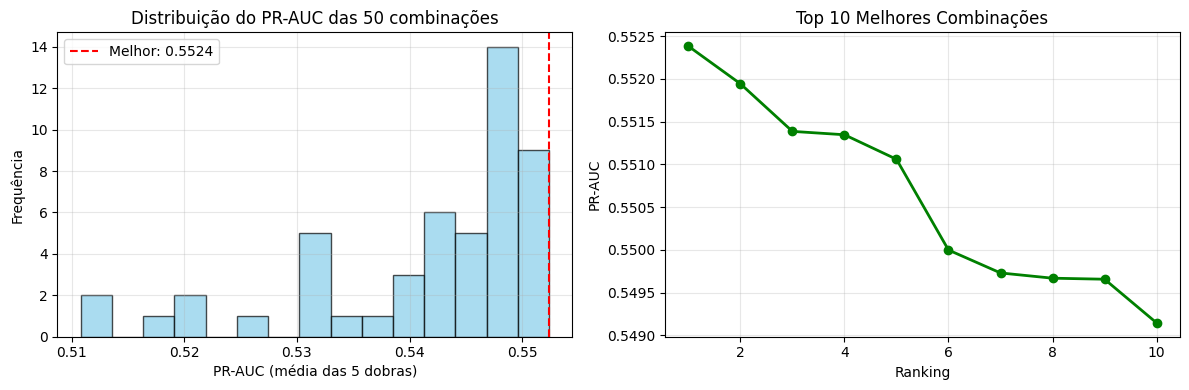


🎉 OTIMIZAÇÃO DE HIPERPARÂMETROS CONCLUÍDA!


In [82]:
# ===========================
# AJUSTE FINO DE HIPERPARÂMETROS - LIGHTGBM
# ===========================

print("🎯 AJUSTE FINO DE HIPERPARÂMETROS PARA PREDIÇÃO DE RISCO DE NÃO ALFABETIZAÇÃO")
print("=" * 80)

# ===========================
# CONFIGURAÇÃO DOS HIPERPARÂMETROS
# ===========================

# scale_pos_weight ideal calculado na distribuição ORIGINAL do treino (sem oversampling)
neg_samples = (y_train == 0).sum()
pos_samples = (y_train == 1).sum()
scale_pos_weight_ideal = neg_samples / pos_samples

print("📊 ANÁLISE DA DISTRIBUIÇÃO DE CLASSES:")
print(f"• Amostras negativas (Alfabetizado): {neg_samples:,}")
print(f"• Amostras positivas (Não alfabetizado): {pos_samples:,}")
print(f"• Scale pos weight ideal: {scale_pos_weight_ideal:.2f}")

# Espaço de busca do LightGBM (o prefixo "modelo__" aponta para a etapa do Pipeline)
param_dist = {
    "modelo__num_leaves": sp_randint(15, 128),              # Número máximo de folhas por árvore
    "modelo__max_depth": sp_randint(3, 9),                  # Controla complexidade
    "modelo__learning_rate": [0.01, 0.03, 0.05, 0.1],       # Taxa de aprendizado
    "modelo__n_estimators": sp_randint(100, 600),           # Número de árvores
    "modelo__min_child_samples": sp_randint(10, 100),       # Mínimo de crianças em cada folha
    "modelo__subsample": [0.7, 0.8, 0.9, 1.0],              # Amostragem de linhas
    "modelo__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],  # Amostragem de colunas
    "modelo__reg_alpha": [0, 0.1, 0.5, 1, 2],               # L1 regularization
    "modelo__reg_lambda": [0, 0.1, 0.5, 1, 2],              # L2 regularization
    "modelo__scale_pos_weight": [                            # Peso da classe "não alfabetizado"
        scale_pos_weight_ideal * 0.5,
        scale_pos_weight_ideal * 0.75,
        scale_pos_weight_ideal,
        scale_pos_weight_ideal * 1.25,
        scale_pos_weight_ideal * 1.5
    ]
}

print("\n🔧 CONFIGURAÇÃO DO RANDOM SEARCH:")
print(f"• Parâmetros a otimizar: {len(param_dist)}")
print(f"• Scale pos weight testado: {[round(v, 2) for v in param_dist['modelo__scale_pos_weight']]}")

# ===========================
# CONFIGURAÇÃO DO MODELO E RANDOM SEARCH
# ===========================

# Pipeline: pré-processamento + LightGBM (o pré-processador é reajustado em cada dobra)
lgbm_pipeline = Pipeline([
    ("prep", constroi_preprocessador()),
    ("modelo", LGBMClassifier(
        random_state=SEED,
        subsample_freq=1,   # ativa a amostragem de linhas (subsample) a cada árvore
        verbose=-1,         # Reduzir outputs desnecessários
        n_jobs=1            # o paralelismo fica com o Random Search
    ))
])

random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm_pipeline,
    param_distributions=param_dist,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),  # 5-fold CV
    scoring={"pr_auc": "average_precision", "f1": "f1"},             # PR-AUC (principal) e F1
    refit="pr_auc",                # o melhor modelo é escolhido pelo PR-AUC
    n_iter=50,                     # 50 combinações sorteadas
    n_jobs=-1,                     # Usar todos os cores
    random_state=SEED,             # Para reprodutibilidade
    verbose=1                      # Mostrar progresso
)

print("• Cross-validation: 5-fold estratificado")
print("• Métrica de otimização: PR-AUC (F1 acompanhado)")
print("• Número de iterações: 50")
print("• Processamento paralelo: Ativado")

# ===========================
# TREINAMENTO COM O TREINO ORIGINAL (SEM CÓPIAS)
# ===========================

print("\n🚀 INICIANDO TREINAMENTO...")
print(f"• Dados de treino: {len(X_train):,} amostras (originais, sem oversampling)")
print("• Tempo estimado: 10-15 minutos")

inicio = time.time()
random_search_lgbm.fit(X_train, y_train)
fim = time.time()
tempo_minutos = round((fim - inicio) / 60, 2)

print("✅ TREINAMENTO CONCLUÍDO!")

# ===========================
# ANÁLISE DOS RESULTADOS
# ===========================

resultados_cv = pd.DataFrame(random_search_lgbm.cv_results_)
melhor_idx = random_search_lgbm.best_index_

print("\n📈 RESULTADOS DO RANDOM SEARCH:")
print("=" * 60)
print(f"• Melhor PR-AUC (CV): {random_search_lgbm.best_score_:.4f} (±{resultados_cv.loc[melhor_idx, 'std_test_pr_auc']:.4f})")
print(f"• F1-Score (CV) dessa combinação: {resultados_cv.loc[melhor_idx, 'mean_test_f1']:.4f}")
print(f"• Faixa de PR-AUC entre as 50 combinações: {resultados_cv['mean_test_pr_auc'].min():.4f} a {resultados_cv['mean_test_pr_auc'].max():.4f}")
print(f"• Faixa de F1-Score entre as 50 combinações: {resultados_cv['mean_test_f1'].min():.4f} a {resultados_cv['mean_test_f1'].max():.4f}")
print(f"• Tempo total de treinamento: {tempo_minutos} minutos")
print(f"• Número de modelos testados: {resultados_cv.shape[0]}")

print("\n🏆 MELHORES HIPERPARÂMETROS:")
print("-" * 40)
for param, valor in random_search_lgbm.best_params_.items():
    valor = round(valor, 4) if isinstance(valor, float) else valor
    print(f"• {param.replace('modelo__', '')}: {valor}")

# ===========================
# ANÁLISE DOS TOP 5 MODELOS
# ===========================

print("\n🏅 TOP 5 MELHORES COMBINAÇÕES:")
print("=" * 50)
top_5 = resultados_cv.sort_values("mean_test_pr_auc", ascending=False).head(5)
for i, (_, linha) in enumerate(top_5.iterrows(), 1):
    print(f"\n{i}º lugar - PR-AUC: {linha['mean_test_pr_auc']:.4f} (±{linha['std_test_pr_auc']:.4f}) | F1: {linha['mean_test_f1']:.4f}")
    for coluna in resultados_cv.columns:
        if coluna.startswith("param_"):
            valor = linha[coluna]
            valor = round(valor, 4) if isinstance(valor, float) else valor
            print(f"  • {coluna.replace('param_modelo__', '')}: {valor}")

# ===========================
# SALVAR RESULTADOS
# ===========================

melhor_modelo_lgbm = random_search_lgbm.best_estimator_   # já reajustado no treino inteiro (refit)

resultado_otimizacao = {
    "Melhor_PR_AUC_CV": f"{random_search_lgbm.best_score_:.4f}",
    "F1_Score_CV": f"{resultados_cv.loc[melhor_idx, 'mean_test_f1']:.4f}",
    "Melhores_Hiperparametros": {k.replace("modelo__", ""): v for k, v in random_search_lgbm.best_params_.items()},
    "Numero_Modelos_Testados": resultados_cv.shape[0],
    "Tempo_Treinamento_Minutos": tempo_minutos,
}

print("\n📌 Resultados detalhados disponíveis na variável 'resultado_otimizacao'")
print("   O modelo final é salvo na FASE 05 (Implantação).")

# ===========================
# VISUALIZAÇÃO DOS RESULTADOS
# ===========================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Subplot 1: Distribuição dos PR-AUC
ax1.hist(resultados_cv["mean_test_pr_auc"], bins=15, alpha=0.7, color="skyblue", edgecolor="black")
ax1.axvline(random_search_lgbm.best_score_, color="red", linestyle="--",
            label=f"Melhor: {random_search_lgbm.best_score_:.4f}")
ax1.set_xlabel("PR-AUC (média das 5 dobras)")
ax1.set_ylabel("Frequência")
ax1.set_title("Distribuição do PR-AUC das 50 combinações")
ax1.legend()
ax1.grid(alpha=0.3)

# Subplot 2: Top 10 melhores combinações
top_10_scores = resultados_cv["mean_test_pr_auc"].nlargest(10)
ax2.plot(range(1, 11), top_10_scores, "o-", color="green", linewidth=2, markersize=6)
ax2.set_xlabel("Ranking")
ax2.set_ylabel("PR-AUC")
ax2.set_title("Top 10 Melhores Combinações")
ax2.grid(alpha=0.3)

fig.tight_layout()
salva(fig, "projeto_random_search_lgbm.png"); plt.show()

print("\n" + "=" * 80)
print("🎉 OTIMIZAÇÃO DE HIPERPARÂMETROS CONCLUÍDA!")
print("=" * 80)

In [83]:
# Resultado da otimização
resultado_otimizacao

{'Melhor_PR_AUC_CV': '0.5524',
 'F1_Score_CV': '0.5655',
 'Melhores_Hiperparametros': {'colsample_bytree': 0.6,
  'learning_rate': 0.01,
  'max_depth': 3,
  'min_child_samples': 36,
  'n_estimators': 545,
  'num_leaves': 91,
  'reg_alpha': 0,
  'reg_lambda': 0.5,
  'scale_pos_weight': np.float64(1.5025773195876289),
  'subsample': 0.7},
 'Numero_Modelos_Testados': 50,
 'Tempo_Treinamento_Minutos': 12.01}

**Nota:**

**O que a busca encontrou:**

- As 50 combinações foram testadas em **5 dobras** cada (250 treinos). A melhor chegou a **PR-AUC de 0,552** na validação
  cruzada, com variação de **±0,013** entre as dobras.
- **A escolha dos hiperparâmetros importa, mas tem limite:** o PR-AUC variou de **0,511** (pior combinação) a **0,552** (melhor).
  Já o **F1 variou muito mais** (de **0,26** a **0,60**), porque ele depende de quantas crianças o modelo aponta como em risco no
  threshold de 0,5 — algo controlado sobretudo pelo `scale_pos_weight`.
- **Os 5 primeiros colocados ficaram praticamente empatados** (diferença menor que 0,002 de PR-AUC, bem abaixo da variação de ±0,013
  entre as dobras). Ou seja: existem **várias** regulagens boas, e o 1º lugar não é muito superior aos seguintes.

**Os hiperparâmetros vencedores, em palavras simples:**

| Hiperparâmetro | Valor | O que significa |
|---|---|---|
| `max_depth` | **3** | árvores **rasas**: no máximo 3 perguntas seguidas (por isso `num_leaves=91` não chega a ser usado — o limite real é 2³ = 8 folhas) |
| `learning_rate` | **0,01** | aprende **devagar**, com passos pequenos |
| `n_estimators` | **545** | muitas árvores, para compensar o passo pequeno |
| `colsample_bytree` / `subsample` | **0,6** / **0,7** | cada árvore vê 60% das variáveis e 70% das crianças — mais diversidade, menos decoreba |
| `min_child_samples` | **36** | cada "resposta final" precisa de pelo menos 36 crianças |
| `reg_lambda` | **0,5** | uma leve penalidade para evitar exageros |
| `scale_pos_weight` | **1,50** | exatamente a proporção ideal: cada criança não alfabetizada vale 1,5 vez |

- **A mensagem dos hiperparâmetros:** o melhor modelo é **simples e cauteloso** — árvores rasas, passos pequenos e muita
  aleatoriedade. Faz sentido com o que já vimos: os sinais são fracos, e modelos complexos (como o Random Forest) **decoravam** o treino.
- O melhor modelo fica guardado no notebook (`melhor_modelo_lgbm`); o modelo final é salvo na **Fase 05 (Implantação)**.

### <font color='#F37126'> 7.2. LightGBM ajustado

O melhor modelo da busca já foi **retreinado com todo o treino** (30.101 crianças). Agora ele é avaliado na **validação** — as mesmas
10.034 crianças usadas para comparar os quatro modelos — para saber se o ajuste realmente melhorou o resultado.

**Diferença para o exemplo:** o exemplo treina com treino + validação e avalia na própria validação. Isso infla as métricas, porque o
modelo **já viu** aquelas crianças. Aqui o treino com treino + validação fica para o **modelo final (7.3)**, avaliado no **teste**.

In [84]:
# Avaliar o melhor modelo no conjunto de VALIDAÇÃO (o Pipeline recebe o X cru)
yhat_lgbm_ajustado_proba = melhor_modelo_lgbm.predict_proba(X_val)[:, 1]
yhat_lgbm_ajustado = (yhat_lgbm_ajustado_proba >= 0.5).astype(int)

# Métricas completas (mesma função da seção 6)
metricas_lgbm_ajustado = calcular_metricas_completas(y_val, yhat_lgbm_ajustado, yhat_lgbm_ajustado_proba, "LightGBM ajustado")

print("📊 PERFORMANCE NO CONJUNTO DE VALIDAÇÃO:")
print("=" * 50)
for metrica in ["Acurácia", "Precisão", "Recall (Sensibilidade)", "F1-Score", "AUC-ROC", "PR-AUC"]:
    valor = metricas_lgbm_ajustado[metrica]
    print(f"• {metrica:<24} {valor:.4f} ({valor*100:.2f}%)")

auc_treino_ajustado = roc_auc_score(y_train, melhor_modelo_lgbm.predict_proba(X_train)[:, 1])
print(f"\nAUC-ROC no treino: {auc_treino_ajustado:.4f}  |  na validação: {metricas_lgbm_ajustado['AUC-ROC']:.4f}")

# Resultado em porcentagem
print("\nClassification metrics: \n", classification_report(y_val, yhat_lgbm_ajustado,
      target_names=["Alfabetizado (0)", "Não alfabetizado (1)"], digits=4))
# Matriz de confusão
print("Confusion Matrix: \n", confusion_matrix(y_val, yhat_lgbm_ajustado))
# Acurácia
print("\nAcurácia:", accuracy_score(y_val, yhat_lgbm_ajustado))

# ===========================
# COMPARAÇÃO: ORIGINAL x AJUSTADO x REGRESSÃO LOGÍSTICA
# ===========================
comparacao_ajuste = pd.DataFrame({
    "LightGBM original": metricas_lgbm,
    "LightGBM ajustado": metricas_lgbm_ajustado,
    "Regressão Logística": metricas_lr,
}).loc[["Acurácia", "Precisão", "Recall (Sensibilidade)", "F1-Score", "AUC-ROC", "PR-AUC",
        "Verdadeiros Positivos", "Falsos Negativos", "Falsos Positivos"]]

score_geral_ajustado = np.mean([metricas_lgbm_ajustado[m] for m in ["F1-Score", "AUC-ROC", "Recall (Sensibilidade)", "Precisão"]])
print("\n📈 COMPARAÇÃO NA VALIDAÇÃO")
print("=" * 60)
display(comparacao_ajuste.astype(float).round(4))
print(f"Score geral (média de F1, AUC-ROC, Recall e Precisão): "
      f"LightGBM original {scores_gerais['LightGBM']:.4f} | LightGBM ajustado {score_geral_ajustado:.4f} | "
      f"Regressão Logística {scores_gerais['Regressão Logística']:.4f}")

📊 PERFORMANCE NO CONJUNTO DE VALIDAÇÃO:
• Acurácia                 0.6156 (61.56%)
• Precisão                 0.5157 (51.57%)
• Recall (Sensibilidade)   0.6252 (62.52%)
• F1-Score                 0.5652 (56.52%)
• AUC-ROC                  0.6623 (66.23%)
• PR-AUC                   0.5454 (54.54%)



AUC-ROC no treino: 0.7700  |  na validação: 0.6623

Classification metrics: 
                       precision    recall  f1-score   support

    Alfabetizado (0)     0.7095    0.6092    0.6555      6024
Não alfabetizado (1)     0.5157    0.6252    0.5652      4010

            accuracy                         0.6156     10034
           macro avg     0.6126    0.6172    0.6104     10034
        weighted avg     0.6320    0.6156    0.6194     10034

Confusion Matrix: 
 [[3670 2354]
 [1503 2507]]

Acurácia: 0.615606936416185

📈 COMPARAÇÃO NA VALIDAÇÃO


,LightGBM original,LightGBM ajustado,Regressão Logística
Acurácia,0.6129,0.6156,0.6102
Precisão,0.5136,0.5157,0.5104
Recall (Sensibilidade),0.5940,0.6252,0.6075
F1-Score,0.5509,0.5652,0.5547
AUC-ROC,0.6561,0.6623,0.6598
PR-AUC,0.5353,0.5454,0.5467
Verdadeiros Positivos,2382.0000,2507.0000,2436.0000
Falsos Negativos,1628.0000,1503.0000,1574.0000
Falsos Positivos,2256.0000,2354.0000,2337.0000


Score geral (média de F1, AUC-ROC, Recall e Precisão): LightGBM original 0.5786 | LightGBM ajustado 0.5921 | Regressão Logística 0.5831


**Nota:**

**O ajuste funcionou — o LightGBM melhorou em todas as métricas:**

| Métrica | LightGBM original | **LightGBM ajustado** | Regressão Logística |
|---|---|---|---|
| Acurácia | 61,29% | **61,56%** | 61,02% |
| Precisão | 51,36% | **51,57%** | 51,04% |
| Recall | 59,40% | **62,52%** | 60,75% |
| F1-Score | 55,09% | **56,52%** | 55,47% |
| AUC-ROC | 0,656 | **0,662** | 0,660 |
| PR-AUC | 0,535 | 0,545 | **0,547** |
| Crianças em risco encontradas | 2.382 | **2.507** | 2.436 |
| Crianças em risco **não** encontradas | 1.628 | **1.503** | 1.574 |
| Score geral | 0,579 | **0,592** | 0,583 |

- **Em relação ao LightGBM original:** o recall subiu **3,1 pontos** — o modelo encontra **125 crianças em risco a mais** (2.507 contra
  2.382) — e o PR-AUC subiu de 0,535 para 0,545.
- **Em relação à Regressão Logística:** o LightGBM ajustado **passa à frente em 5 das 6 métricas** e no score geral (**0,592** contra
  0,583). Encontra **71 crianças em risco a mais**. Só fica **levemente atrás no PR-AUC** (0,545 contra 0,547) — uma diferença
  pequena demais para ser considerada relevante.
- **O modelo ajustado passa a ser o melhor modelo do projeto** e segue para a avaliação final.

**Sobre o AUC no treino (0,770) ser maior que na validação (0,662):** parte dessa diferença é esperada — ao prever o próprio
treino, os códigos de escola e município "lembram" o resultado daquelas crianças. O que importa é que a **validação cruzada (0,552)**
e a **validação (0,545)** deram PR-AUC praticamente iguais: o resultado da busca **se confirmou** em crianças novas.

### <font color='#F37126'> 7.3. Modelo final

Chegou a hora da **prova final**. O modelo final:

1. Usa os **melhores hiperparâmetros** encontrados no Random Search;
2. É treinado com **treino + validação** (40.135 crianças, **sem cópias**) — agora que o modelo já foi escolhido, a validação pode
   ser usada para aprender mais;
3. É avaliado **uma única vez** no **teste**: as **10.034 crianças que nenhum modelo viu** em nenhuma etapa.

Modelo final treinado com 40,135 crianças (treino + validação)



📊 PERFORMANCE NO CONJUNTO DE TESTE:
• Acurácia                 0.6154 (61.54%)
• Precisão                 0.5156 (51.56%)
• Recall (Sensibilidade)   0.6229 (62.29%)
• F1-Score                 0.5642 (56.42%)
• AUC-ROC                  0.6666 (66.66%)
• PR-AUC                   0.5515 (55.15%)

Classification metrics: 
                       precision    recall  f1-score   support

    Alfabetizado (0)     0.7086    0.6104    0.6558      6024
Não alfabetizado (1)     0.5156    0.6229    0.5642      4010

            accuracy                         0.6154     10034
           macro avg     0.6121    0.6167    0.6100     10034
        weighted avg     0.6315    0.6154    0.6192     10034

📈 VALIDAÇÃO (7.2) x TESTE (7.3)


,Validação,Teste
Acurácia,0.6156,0.6154
Precisão,0.5157,0.5156
Recall (Sensibilidade),0.6252,0.6229
F1-Score,0.5652,0.5642
AUC-ROC,0.6623,0.6666
PR-AUC,0.5454,0.5515


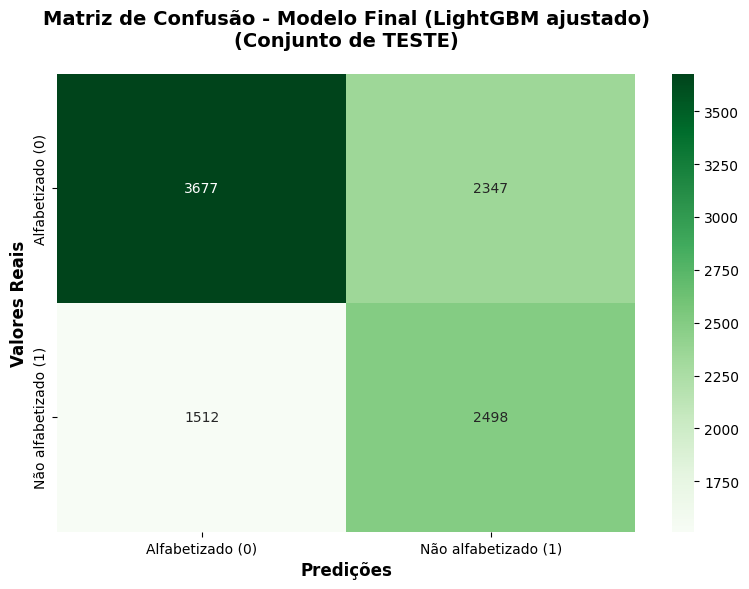

DETALHES DA MATRIZ DE CONFUSÃO (TESTE):
• Verdadeiros Negativos (TN): 3,677 - Alfabetizados corretamente identificados
• Falsos Positivos (FP): 2,347 - Alfabetizados classificados como Não alfabetizados
• Falsos Negativos (FN): 1,512 - Não alfabetizados classificados como Alfabetizados
• Verdadeiros Positivos (TP): 2,498 - Não alfabetizados corretamente identificados

Total: 10,034 crianças do teste | apontadas como em risco: 4,845


In [85]:
# Classificação sobre os dados de teste
# Cópia "zerada" do melhor Pipeline, com os mesmos hiperparâmetros
model = clone(melhor_modelo_lgbm)

# Modelo treinado sobre treino + validação (dados originais, sem oversampling)
X_train_val = pd.concat([X_train, X_val])
y_train_val = np.concatenate([y_train, y_val])
model.fit(X_train_val, y_train_val)
print(f"Modelo final treinado com {len(X_train_val):,} crianças (treino + validação)")

# Avaliar a performance no TESTE
yhat_proba = model.predict_proba(X_test)[:, 1]
yhat = (yhat_proba >= 0.5).astype(int)

metricas_final = calcular_metricas_completas(y_test, yhat, yhat_proba, "Modelo final")

print("\n📊 PERFORMANCE NO CONJUNTO DE TESTE:")
print("=" * 50)
for metrica in ["Acurácia", "Precisão", "Recall (Sensibilidade)", "F1-Score", "AUC-ROC", "PR-AUC"]:
    valor = metricas_final[metrica]
    print(f"• {metrica:<24} {valor:.4f} ({valor*100:.2f}%)")

# Resultado em porcentagem
print("\nClassification metrics: \n", classification_report(y_test, yhat,
      target_names=["Alfabetizado (0)", "Não alfabetizado (1)"], digits=4))

# Validação x Teste
print("📈 VALIDAÇÃO (7.2) x TESTE (7.3)")
display(pd.DataFrame({"Validação": metricas_lgbm_ajustado, "Teste": metricas_final})
          .loc[["Acurácia", "Precisão", "Recall (Sensibilidade)", "F1-Score", "AUC-ROC", "PR-AUC"]].astype(float).round(4))

# Matriz de confusão
cm_final = confusion_matrix(y_test, yhat)
rotulos_cm = ["Alfabetizado (0)", "Não alfabetizado (1)"]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Greens", ax=ax,
            xticklabels=rotulos_cm, yticklabels=rotulos_cm)
ax.set_title("Matriz de Confusão - Modelo Final (LightGBM ajustado)\n(Conjunto de TESTE)",
             fontsize=14, fontweight="bold", pad=20)
ax.set_ylabel("Valores Reais", fontsize=12, fontweight="bold")
ax.set_xlabel("Predições", fontsize=12, fontweight="bold")
fig.tight_layout()
salva(fig, "projeto_matriz_confusao_final.png"); plt.show()

tn, fp, fn, tp = cm_final.ravel()
print("DETALHES DA MATRIZ DE CONFUSÃO (TESTE):")
print(f"• Verdadeiros Negativos (TN): {tn:,} - Alfabetizados corretamente identificados")
print(f"• Falsos Positivos (FP): {fp:,} - Alfabetizados classificados como Não alfabetizados")
print(f"• Falsos Negativos (FN): {fn:,} - Não alfabetizados classificados como Alfabetizados")
print(f"• Verdadeiros Positivos (TP): {tp:,} - Não alfabetizados corretamente identificados")
print(f"\nTotal: {cm_final.sum():,} crianças do teste | apontadas como em risco: {yhat.sum():,}")


**Nota:**

**Resultado final nas 10.034 crianças que nenhum modelo viu:**

| Métrica | Validação (7.2) | **Teste (7.3)** |
|---|---|---|
| Acurácia | 61,56% | **61,54%** |
| Precisão | 51,57% | **51,56%** |
| Recall | 62,52% | **62,29%** |
| F1-Score | 56,52% | **56,42%** |
| AUC-ROC | 0,662 | **0,667** |
| PR-AUC | 0,545 | **0,551** |

- **Não houve queda do validação para o teste** — as métricas ficaram praticamente iguais, e o AUC-ROC e o PR-AUC até subiram um
  pouco. Isso mostra que o modelo **generaliza**: o desempenho medido durante o desenvolvimento **se repete em crianças novas**.
  Não houve "sorte" na escolha do modelo.

**A matriz de confusão do teste, em palavras simples:**

| | Previu **Alfabetizado** | Previu **Não alfabetizado** |
|---|---|---|
| **Era Alfabetizado** | ✅ **3.677** acertos | ⚠️ **2.347** alarmes falsos |
| **Era Não alfabetizado** | ❌ **1.512** crianças em risco não encontradas | ✅ **2.498** crianças em risco encontradas |

- **De cada 10 crianças que não se alfabetizaram, o modelo encontra cerca de 6** (recall de 62,29%): **2.498 de 4.010**.
- **De cada 2 crianças apontadas como em risco, 1 realmente está** (precisão de 51,56%): o modelo apontou **4.845** crianças.
- **O que isso significa para o gestor:** se o reforço escolar fosse oferecido às 4.845 crianças apontadas, ele alcançaria
  **2.498 crianças que de fato precisam**. Se as mesmas 4.845 vagas fossem **sorteadas**, alcançariam cerca de **1.936**
  (40% de acerto, a proporção de não alfabetizados). O modelo leva o reforço a **cerca de 560 crianças em risco a mais**,
  com o mesmo número de vagas.

**Limites, ditos com clareza:**

- O modelo é **útil para priorizar**, mas **erra bastante**: 1.512 crianças em risco ficaram de fora e 2.347 alertas foram desnecessários.
- O teto vem dos **dados**: a base não traz informações individuais da criança (renda, frequência, escolaridade dos pais) e esta
  análise usa uma **amostra de 50 mil** crianças.
- O próximo passo natural é **escolher o threshold** (hoje 0,5) de acordo com o custo de cada erro — por exemplo, aceitar mais alarmes
  falsos para encontrar ainda mais crianças em risco.
- O modelo final é salvo em `models/modelo_final_alfabetizacao.joblib` na **Fase 05 (Implantação)**.

## 8 - **Otimização de limiar e calibração**

O modelo não responde "sim" ou "não": ele dá a cada criança uma **probabilidade** de não se alfabetizar, de 0 a 1. Para virar uma
decisão, é preciso um **limiar** (*threshold*): toda criança com probabilidade **igual ou acima** do limiar é apontada como "em risco".
Até aqui usamos **0,5**.

- **Analogia:** o limiar é como a **nota de corte** de um processo seletivo. Nota de corte baixa aprova mais gente (inclusive quem não
  precisava); nota de corte alta aprova menos gente (e deixa de fora quem merecia).
- **A troca é inevitável:**
    - **limiar menor** → o modelo aponta **mais** crianças → encontra **mais crianças em risco**, mas gera **mais alarmes falsos**;
    - **limiar maior** → aponta **menos** crianças → **menos alarmes falsos**, mas **deixa mais crianças em risco de fora**.

**Cuidado de método:** o limiar é escolhido na **validação**, com o LightGBM ajustado treinado só no treino (seção 7.2). O **teste** só
recebe o limiar escolhido **no final**, como conferência — escolher o limiar olhando o teste seria ajustar a régua depois de ver a prova.

### <font color='#F37126'> 8.1. Convertendo probabilidades em 0 ou 1

In [86]:
# Probabilidades do LightGBM ajustado na VALIDAÇÃO (seção 7.2)
yhat_limiar = yhat_lgbm_ajustado_proba.copy()

# Converting probabilities into 0 or 1
for i in range(0, len(yhat_limiar)):
    if yhat_limiar[i] >= .5:  # setting threshold to .5
        yhat_limiar[i] = 1
    else:
        yhat_limiar[i] = 0

yhat_limiar = yhat_limiar.astype(int)
print(f"Limiar 0,5: {yhat_limiar.sum():,} de {len(yhat_limiar):,} crianças apontadas como em risco "
      f"({100 * yhat_limiar.mean():.1f}%)")

Limiar 0,5: 4,861 de 10,034 crianças apontadas como em risco (48.4%)


In [87]:
# O mesmo laço, repetido para outros limiares
resultados_limiar = []
for limiar in [0.3, 0.4, 0.5, 0.6, 0.7]:
    previsao = yhat_lgbm_ajustado_proba.copy()
    for i in range(0, len(previsao)):
        if previsao[i] >= limiar:
            previsao[i] = 1
        else:
            previsao[i] = 0
    previsao = previsao.astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, previsao).ravel()
    resultados_limiar.append({
        "Limiar": limiar,
        "Crianças apontadas": previsao.sum(),
        "Em risco encontradas (TP)": tp,
        "Em risco NÃO encontradas (FN)": fn,
        "Alarmes falsos (FP)": fp,
        "Recall": round(tp / (tp + fn), 4),
        "Precisão": round(tp / (tp + fp), 4),
    })

tabela_limiares = pd.DataFrame(resultados_limiar)
print(f"Validação: {len(y_val):,} crianças, das quais {int(y_val.sum()):,} não se alfabetizaram")
display(tabela_limiares)

Validação: 10,034 crianças, das quais 4,010 não se alfabetizaram

,Limiar,Crianças apontadas,Em risco encontradas (TP),Em risco NÃO encontradas (FN),Alarmes falsos (FP),Recall,Precisão
0,0.3,9086,3879,131,5207,0.9673,0.4269
1,0.4,7433,3415,595,4018,0.8516,0.4594
2,0.5,4861,2507,1503,2354,0.6252,0.5157
3,0.6,2321,1339,2671,982,0.3339,0.5769
4,0.7,773,503,3507,270,0.1254,0.6507


**Nota:**

- **O laço `for` faz a conversão de forma bem direta:** percorre as crianças uma a uma e troca a probabilidade por **1** (em risco) se ela
  for maior ou igual ao limiar, ou por **0** caso contrário. Com o limiar de **0,5**, o modelo aponta **4.861 crianças** (48,4% da validação).

**O que acontece quando mudamos o limiar** (validação, 4.010 crianças em risco):

| Limiar | Crianças apontadas | Em risco encontradas | Recall | Precisão |
|---|---|---|---|---|
| 0,3 | 9.086 | 3.879 | **96,7%** | 42,7% |
| 0,4 | 7.433 | 3.415 | 85,2% | 45,9% |
| **0,5** | **4.861** | **2.507** | **62,5%** | **51,6%** |
| 0,6 | 2.321 | 1.339 | 33,4% | 57,7% |
| 0,7 | 773 | 503 | 12,5% | **65,1%** |

- **Descendo o limiar**, o recall dispara: com **0,3** o modelo encontra **97%** das crianças em risco — mas aponta **9.086 das 10.034 crianças**
  (91% de toda a validação). Na prática, é quase "oferecer reforço para todo mundo".
- **Subindo o limiar**, a precisão melhora (65% com **0,7**), mas o modelo aponta só **773 crianças** e encontra apenas **1 em cada 8** crianças em risco.
- **Não existe limiar "certo" do ponto de vista estatístico**: cada linha da tabela é uma escolha possível, e a melhor depende de
  **quantas vagas de reforço existem** e de **quanto custa deixar uma criança de fora**.

### <font color='#F37126'> 8.2. Escolhendo o limiar

In [88]:
# Limiar que maximiza o F1 — reaproveita a função de src/evaluation/metricas.py
limiar_f1, f1_maximo = limiar_otimo_f1(y_val, yhat_lgbm_ajustado_proba)
print(f"limiar de F1 máximo: {limiar_f1:.4f}  ->  F1 = {f1_maximo:.4f}")
print(f"contra o corte 0,5:  F1 = {f1_score(y_val, (yhat_lgbm_ajustado_proba >= 0.5).astype(int)):.4f}")

# Curva de custo esperado: deixar uma criança em risco de fora (FN) custa 5 vezes mais que um alarme falso (FP)
C_FN, C_FP = 5.0, 1.0
limiares = np.linspace(0.05, 0.95, 181)
custos, recalls, precisoes = [], [], []
for t in limiares:
    pred_t = (yhat_lgbm_ajustado_proba >= t).astype(int)
    fn = int(((pred_t == 0) & (y_val == 1)).sum())
    fp = int(((pred_t == 1) & (y_val == 0)).sum())
    custos.append(C_FN * fn + C_FP * fp)
    recalls.append(recall_score(y_val, pred_t))
    # precisão só quando o modelo aponta pelo menos 50 crianças (com poucas, o número oscila por acaso)
    precisoes.append(precision_score(y_val, pred_t, zero_division=0) if pred_t.sum() >= 50 else np.nan)

custos = np.array(custos)
limiar_custo = float(limiares[int(np.argmin(custos))])
custo_05 = custos[int(np.argmin(np.abs(limiares - 0.5)))]
print(f"\nmatriz de custo  C_FN={C_FN:.0f}  C_FP={C_FP:.0f}")
print(f"limiar de custo mínimo: {limiar_custo:.3f}  (custo {custos.min():,.0f} contra {custo_05:,.0f} no limiar 0,5)")

# Resumo dos três limiares na validação
resumo_limiares = []
for nome, t in [("0,5 padrão", 0.5), ("F1 máximo", limiar_f1), ("custo mínimo", limiar_custo)]:
    pred_t = (yhat_lgbm_ajustado_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred_t).ravel()
    resumo_limiares.append({"Critério": nome, "Limiar": round(t, 3), "Crianças apontadas": pred_t.sum(),
                            "% das crianças": round(100 * pred_t.mean(), 1), "Em risco encontradas": tp,
                            "Recall": round(tp / (tp + fn), 4), "Precisão": round(tp / (tp + fp), 4),
                            "F1": round(f1_score(y_val, pred_t), 4)})
display(pd.DataFrame(resumo_limiares))

limiar de F1 máximo: 0.3726  ->  F1 = 0.5992
contra o corte 0,5:  F1 = 0.5652



matriz de custo  C_FN=5  C_FP=1
limiar de custo mínimo: 0.290  (custo 5,805 contra 9,869 no limiar 0,5)


,Critério,Limiar,Crianças apontadas,% das crianças,Em risco encontradas,Recall,Precisão,F1
0,"0,5 padrão",0.500,4861,48.4,2507,0.6252,0.5157,0.5652
1,F1 máximo,0.373,8049,80.2,3613,0.9010,0.4489,0.5992
2,custo mínimo,0.290,9191,91.6,3906,0.9741,0.4250,0.5918


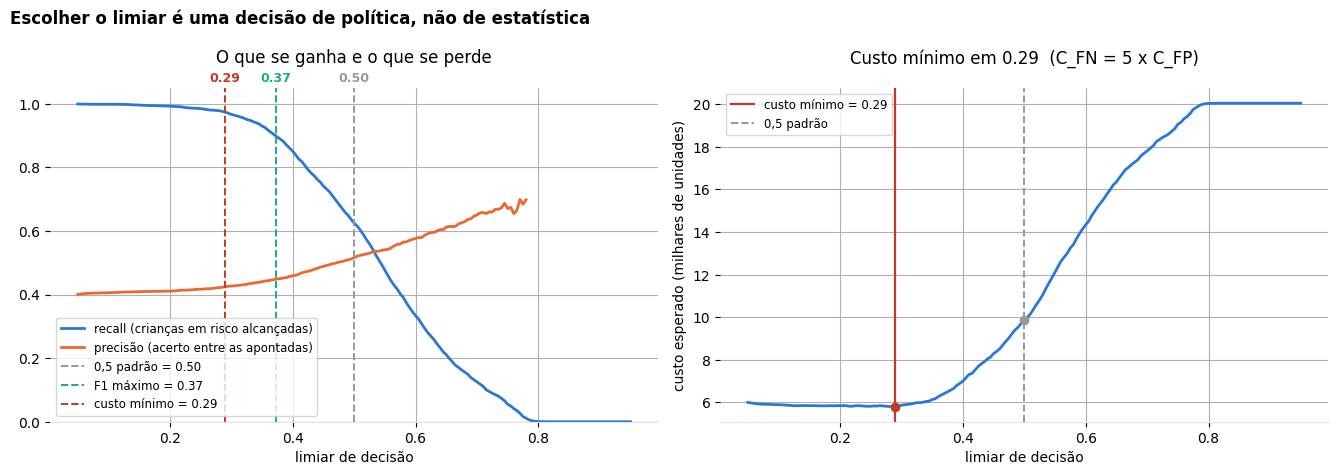

In [89]:
# Visualizando o efeito do limiar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.4, 4.8))

ax1.plot(limiares, recalls, color=AZUL, linewidth=2, label="recall (crianças em risco alcançadas)")
ax1.plot(limiares, precisoes, color=LARANJA, linewidth=2, label="precisão (acerto entre as apontadas)")
for t, cor, rotulo in [(0.5, NEUTRO, "0,5 padrão"),
                       (limiar_f1, AGUA, "F1 máximo"),
                       (limiar_custo, "#C0392B", "custo mínimo")]:
    ax1.axvline(t, color=cor, linestyle="--", linewidth=1.4, label=f"{rotulo} = {t:.2f}")
    ax1.annotate(f"{t:.2f}", xy=(t, 1.02), xycoords=("data", "axes fraction"),
                 ha="center", fontsize=9, color=cor, fontweight="bold")
ax1.set_xlabel("limiar de decisão")
ax1.set_ylim(0, 1.05)
ax1.set_title("O que se ganha e o que se perde", pad=18)
ax1.legend(loc="lower left", fontsize=8.5)
limpa_eixos(ax1); ax1.grid(True)

ax2.plot(limiares, custos / 1000, color=AZUL, linewidth=2)
ax2.axvline(limiar_custo, color="#C0392B", linewidth=1.6, label=f"custo mínimo = {limiar_custo:.2f}")
ax2.axvline(0.5, color=NEUTRO, linestyle="--", linewidth=1.4, label="0,5 padrão")
ax2.scatter([limiar_custo], [custos.min() / 1000], color="#C0392B", zorder=3)
ax2.scatter([0.5], [custo_05 / 1000], color=NEUTRO, zorder=3)
ax2.set_xlabel("limiar de decisão")
ax2.set_ylabel("custo esperado (milhares de unidades)")
ax2.set_title(f"Custo mínimo em {limiar_custo:.2f}  (C_FN = {C_FN:.0f} x C_FP)", pad=18)
ax2.legend(loc="upper left", fontsize=8.5)
limpa_eixos(ax2); ax2.grid(True)

fig.suptitle("Escolher o limiar é uma decisão de política, não de estatística",
             x=0.005, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout()
salva(fig, "projeto_limiar.png"); plt.show()

**Nota:**

**Como ler o gráfico da esquerda:**

- A **linha azul (recall)** mostra quantas crianças em risco o modelo encontra; a **linha laranja (precisão)** mostra quantas das crianças
  apontadas estão realmente em risco.
- Da **esquerda para a direita** (limiar subindo), o recall **cai** e a precisão **sobe**: é a troca descrita na introdução.
- A precisão chega a cerca de **0,70** nos limiares mais altos e, nos limiares baixos, fica perto de **0,40** — a proporção de não
  alfabetizados. Ou seja: apontando quase todo mundo, o modelo acerta tanto quanto um sorteio.
- No extremo direito a **linha laranja termina**: o modelo passa a apontar **menos de 50 crianças**, e a precisão calculada sobre tão
  poucas crianças oscila por acaso, por isso não é mostrada.

**As três linhas verticais são três critérios de escolha:**

| Critério | Limiar | Crianças apontadas | Recall | Precisão | O que significa |
|---|---|---|---|---|---|
| **0,5 padrão** | 0,50 | 4.861 (48%) | 62,5% | 51,6% | equilíbrio: aponta metade e encontra 6 em cada 10 em risco |
| **F1 máximo** | 0,37 | 8.049 (80%) | 90,1% | 44,9% | o melhor equilíbrio matemático entre precisão e recall |
| **Custo mínimo** | 0,29 | 9.191 (92%) | 97,4% | 42,5% | quando deixar uma criança de fora custa **5 vezes** mais que um alarme falso |

**Como ler o gráfico da direita:** o **custo** soma 5 pontos para cada criança em risco deixada de fora e 1 ponto para cada alarme falso.
Ele cai à medida que o limiar desce e atinge o mínimo em **0,29** (custo de **5.805**, contra **9.869** no limiar 0,5).

**O ponto central:** os dois limiares "otimizados" (0,37 e 0,29) encontram quase todas as crianças em risco **porque apontam quase todas as
crianças**. Isso acontece porque o modelo tem **sinal fraco** (AUC de 0,66): ele não consegue separar bem os dois grupos, então, para
encontrar mais crianças em risco, precisa convocar muita gente. A escolha depende da **capacidade do programa**:

- **Reforço para poucas crianças** (vagas limitadas) → limiar **0,5** ou maior, priorizando quem tem mais risco.
- **Reforço amplo** (a rede consegue atender a maioria) → limiar **0,37**, que encontra 9 em cada 10 crianças em risco.

Seguimos com o **limiar de F1 máximo (0,37)** para a conferência no teste, por ser o critério estatístico mais usado — lembrando que é uma
**decisão de política**, a ser tomada pelo gestor.

### <font color='#F37126'> 8.3. Aplicando o limiar escolhido no teste

TESTE: 10,034 crianças, das quais 4,010 não se alfabetizaram
Crianças apontadas: limiar 0,5 = 4,845 | limiar 0.37 = 8,142


,"Limiar 0,5",Limiar 0.37
Acurácia,0.6154,0.5184
Precisão,0.5156,0.4495
Recall (Sensibilidade),0.6229,0.9127
F1-Score,0.5642,0.6024
Verdadeiros Positivos,2498.0000,3660.0000
Falsos Negativos,1512.0000,350.0000
Falsos Positivos,2347.0000,4482.0000
Verdadeiros Negativos,3677.0000,1542.0000


Limiar 0,5: 4,845 vagas -> modelo alcança 2,498 crianças em risco; um sorteio alcançaria ~1,936 (+562 com o modelo)
Limiar 0.37: 8,142 vagas -> modelo alcança 3,660 crianças em risco; um sorteio alcançaria ~3,254 (+406 com o modelo)


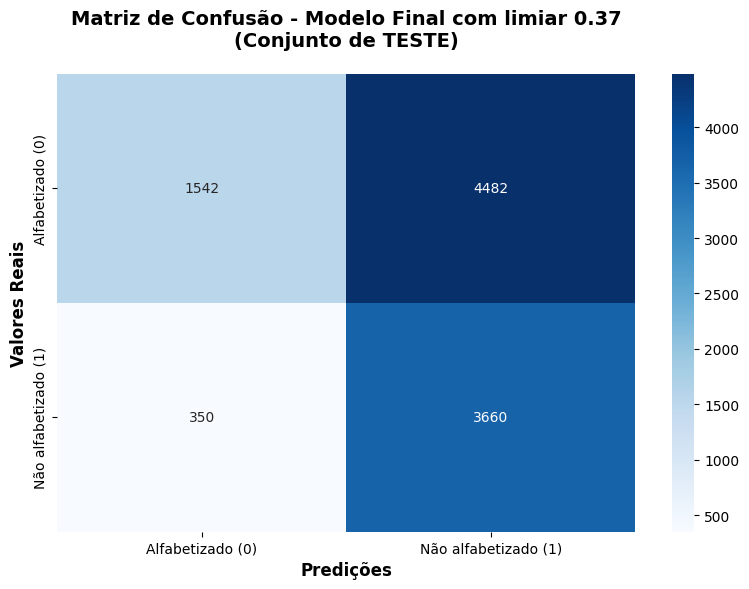

In [90]:
# Probabilidades do MODELO FINAL no TESTE (seção 7.3)
yhat_teste_limiar = yhat_proba.copy()

# Converting probabilities into 0 or 1 com o limiar escolhido na validação
for i in range(0, len(yhat_teste_limiar)):
    if yhat_teste_limiar[i] >= limiar_f1:  # limiar de F1 máximo
        yhat_teste_limiar[i] = 1
    else:
        yhat_teste_limiar[i] = 0

yhat_teste_limiar = yhat_teste_limiar.astype(int)

# Comparação: limiar 0,5 (seção 7.3) x limiar escolhido
metricas_teste_limiar = calcular_metricas_completas(y_test, yhat_teste_limiar, yhat_proba, "Limiar F1 máximo")
comparacao_limiar = pd.DataFrame({
    "Limiar 0,5": metricas_final,
    f"Limiar {limiar_f1:.2f}": metricas_teste_limiar,
}).loc[["Acurácia", "Precisão", "Recall (Sensibilidade)", "F1-Score",
        "Verdadeiros Positivos", "Falsos Negativos", "Falsos Positivos", "Verdadeiros Negativos"]]

print(f"TESTE: {len(y_test):,} crianças, das quais {int(y_test.sum()):,} não se alfabetizaram")
print(f"Crianças apontadas: limiar 0,5 = {yhat.sum():,} | limiar {limiar_f1:.2f} = {yhat_teste_limiar.sum():,}")
display(comparacao_limiar.astype(float).round(4))

# Quantas crianças em risco um sorteio alcançaria com o mesmo número de vagas
for nome, pred in [("0,5", yhat), (f"{limiar_f1:.2f}", yhat_teste_limiar)]:
    vagas = pred.sum()
    sorteio = vagas * y_test.mean()
    encontradas = int(((pred == 1) & (y_test == 1)).sum())
    print(f"Limiar {nome}: {vagas:,} vagas -> modelo alcança {encontradas:,} crianças em risco; "
          f"um sorteio alcançaria ~{sorteio:,.0f} (+{encontradas - sorteio:,.0f} com o modelo)")

# Matriz de confusão com o limiar escolhido
cm_limiar = confusion_matrix(y_test, yhat_teste_limiar)
rotulos_cm = ["Alfabetizado (0)", "Não alfabetizado (1)"]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_limiar, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=rotulos_cm, yticklabels=rotulos_cm)
ax.set_title(f"Matriz de Confusão - Modelo Final com limiar {limiar_f1:.2f}\n(Conjunto de TESTE)",
             fontsize=14, fontweight="bold", pad=20)
ax.set_ylabel("Valores Reais", fontsize=12, fontweight="bold")
ax.set_xlabel("Predições", fontsize=12, fontweight="bold")
fig.tight_layout()
salva(fig, "projeto_matriz_confusao_limiar.png"); plt.show()

**Nota:**

**O limiar de 0,37 (escolhido na validação) aplicado às 10.034 crianças do teste:**

| Resultado no teste | Limiar 0,5 | **Limiar 0,37** | Diferença |
|---|---|---|---|
| Crianças apontadas | 4.845 | **8.142** | +3.297 |
| Em risco **encontradas** | 2.498 | **3.660** | **+1.162** |
| Em risco **não encontradas** | 1.512 | **350** | **−1.162** |
| Alarmes falsos | 2.347 | 4.482 | +2.135 |
| Recall | 62,29% | **91,27%** | +29,0 p.p. |
| Precisão | 51,56% | 44,95% | −6,6 p.p. |
| F1-Score | 56,42% | **60,24%** | +3,8 p.p. |

- **O resultado do teste confirma o da validação** (recall de 90,1% → 91,3%; F1 de 59,9% → 60,2%): o limiar escolhido **funciona em crianças novas**.
- **Ganho:** com o limiar 0,37, **1.162 crianças em risco a mais** passam a ser encontradas — de cada 10 crianças em risco, **9** são alcançadas.
- **Custo:** o programa passaria a atender **8.142 crianças** (81% do total) e **2.135 alarmes falsos a mais**.

**E comparado com um sorteio?**

- Limiar **0,5**: 4.845 vagas → o modelo alcança **2.498** crianças em risco; um sorteio alcançaria **~1.936** (**+562** com o modelo).
- Limiar **0,37**: 8.142 vagas → o modelo alcança **3.660**; um sorteio alcançaria **~3.254** (**+406** com o modelo).
- O **ganho do modelo sobre o sorteio é maior quando as vagas são poucas**: é justamente ao **priorizar** que o modelo mais ajuda.

**Recomendação para o gestor:**

- Se o programa de reforço tem **vagas limitadas** (atende cerca de metade das crianças), use o limiar **0,5**: o modelo leva o reforço a
  **562 crianças em risco a mais** do que um sorteio.
- Se a rede consegue oferecer reforço **a quase todas as crianças**, use o limiar **0,37**: apenas **350** crianças em risco (9%) ficariam de fora.

### <font color='#F37126'> 8.4. Calibração (versão simples)

,criancas,probabilidade_media,taxa_real,diferenca
faixa,,,,
"(0.0, 0.2]",333,0.106,0.075,0.031
"(0.2, 0.3]",584,0.261,0.168,0.093
"(0.3, 0.4]",1545,0.357,0.254,0.103
"(0.4, 0.5]",2727,0.452,0.366,0.086
"(0.5, 0.6]",2543,0.546,0.457,0.089
"(0.6, 0.7]",1576,0.644,0.542,0.102
"(0.7, 1.0]",726,0.742,0.663,0.079


Média geral: o modelo prevê 0.490 | taxa real de não alfabetizados 0.400


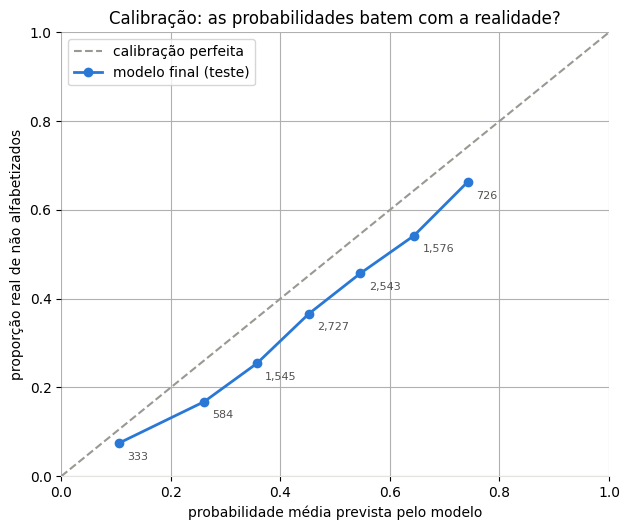

In [91]:
# As probabilidades do modelo "batem" com a realidade?
# Agrupamos as crianças do teste por faixa de probabilidade e comparamos:
#   - a probabilidade média que o modelo deu ao grupo
#   - a proporção real de crianças não alfabetizadas no grupo
faixas = pd.cut(yhat_proba, bins=[0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 1.0])
calibracao = (pd.DataFrame({"faixa": faixas, "prevista": yhat_proba, "real": y_test})
                .groupby("faixa", observed=True)
                .agg(criancas=("real", "size"), probabilidade_media=("prevista", "mean"), taxa_real=("real", "mean"))
                .round(3))
calibracao["diferenca"] = (calibracao["probabilidade_media"] - calibracao["taxa_real"]).round(3)
display(calibracao)
print(f"Média geral: o modelo prevê {yhat_proba.mean():.3f} | taxa real de não alfabetizados {y_test.mean():.3f}")

# Gráfico: pontos sobre a diagonal = probabilidades perfeitamente calibradas
fig, ax = plt.subplots(figsize=(6.4, 5.4))
ax.plot([0, 1], [0, 1], color=NEUTRO, linestyle="--", label="calibração perfeita")
ax.plot(calibracao["probabilidade_media"], calibracao["taxa_real"], "o-", color=AZUL, linewidth=2,
        label="modelo final (teste)")
for _, linha in calibracao.iterrows():
    ax.annotate(f"{int(linha['criancas']):,}", (linha["probabilidade_media"], linha["taxa_real"]),
                textcoords="offset points", xytext=(6, -12), fontsize=8, color=TINTA_SEC)
ax.set_xlabel("probabilidade média prevista pelo modelo")
ax.set_ylabel("proporção real de não alfabetizados")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title("Calibração: as probabilidades batem com a realidade?")
ax.legend(loc="upper left")
limpa_eixos(ax); ax.grid(True)
fig.tight_layout()
salva(fig, "projeto_calibracao.png"); plt.show()

**Nota:**

**O que é calibração:** um modelo é **calibrado** quando, entre as crianças que receberam probabilidade de 60%, cerca de **60%** realmente não
se alfabetizam. No gráfico, isso significa pontos **em cima da diagonal**.

**O que o gráfico mostra:**

- **Todos os pontos ficam abaixo da diagonal**: o modelo **superestima o risco** em todas as faixas — em cerca de **8 a 10 pontos** nas faixas
  a partir de 0,2 (e 3 pontos na faixa de menor risco). Por exemplo, as crianças que receberam em média **0,55** têm taxa real de **0,46**.
- **Na média geral**, o modelo prevê **0,49** de probabilidade, mas a taxa real de não alfabetizados é **0,40**.
- **Por que isso acontece?** No ajuste fino, o `scale_pos_weight = 1,5` deu **peso 1,5 vez maior** às crianças não alfabetizadas. Isso ajuda a
  encontrá-las, mas "puxa" todas as probabilidades para cima.

**O que importa para o uso do modelo:**

- **A ordem está correta:** a taxa real **sobe** de forma contínua — de **7,5%** na faixa de menor risco para **66,3%** na de maior risco.
  Quem recebe probabilidade maior **realmente tem mais risco**.
- **Leitura recomendada:** use a probabilidade como uma **ordem de prioridade** ("esta criança tem mais risco que aquela"), e **não** como
  uma chance exata ("esta criança tem 55% de chance").
- **Caminho da simplicidade:** não recalibramos o modelo. Para decidir quem recebe reforço, basta a **ordem de risco** e o **limiar** escolhido
  na seção 8.2 — e ambos já funcionam bem, como o teste confirmou.

**Um efeito colateral do ajuste fino**

- Para encontrar mais crianças em risco, o ajuste fino deu **peso 1,5** a cada criança não alfabetizada. É como regular um
  **detector de fumaça** para ficar mais sensível: ele avisa mais cedo, mas também passa a "achar" mais fumaça do que existe.
- O preço aparece nas probabilidades: o modelo diz, em média, **49%** de risco, quando o real é **40%**. Sem esta etapa, esse
  exagero passaria despercebido.

**O limiar escolhido continua valendo**

- O limiar de **0,37** não foi escolhido lendo as probabilidades como chances exatas. Ele foi escolhido **contando crianças reais**:
  com esse corte, o modelo encontrou **3.613 das 4.010** crianças em risco na validação.
- **Exemplo:** pense numa balança que marca **2 kg a mais** para todo mundo. O peso de cada pessoa sai errado, mas a balança continua
  mostrando **quem é mais pesado**. Com o modelo é igual: as probabilidades estão "infladas", mas a **ordem das crianças** é a mesma,
  então o corte de 0,37 separa as mesmas crianças.

**Resumo**

A calibração **não melhora nem piora** o modelo — ela diz **como usar o número** que ele dá.

- **Pode fazer:** a criança **A** recebeu **0,70** e a criança **B** recebeu **0,40** → **A tem mais risco que B** e deve ser priorizada. ✅
- **Não deve fazer:** dizer que a criança **A** tem **exatamente 70%** de chance de não se alfabetizar — na faixa dela, a taxa real é de cerca de **54%**. ❌


## 9 - **Teste anti-vazamento**

A limpeza dos dados argumentou que `proficiencia` não pode entrar no modelo. Esta seção **demonstra**:
refaz o treino com ela dentro e mostra o resultado.

`proficiencia` precisa ser declarada como numérica extra ao construir o pré-processador —
ela está fora de `NUM_FEATURES` por decisão de projeto e, sem isso, o `ColumnTransformer` a
descartaria em silêncio. O teste passaria sem testar nada.

**Em palavras simples:** `proficiencia` é a **nota da prova**, e a criança é considerada alfabetizada quando tira **743 pontos ou mais**.
Colocar essa nota no modelo é como **fazer a prova com o gabarito na mão**: o resultado sai perfeito, mas não serve para nada, porque
o objetivo é **prever antes da prova** quem vai precisar de ajuda.

**Como o teste é feito:** usamos **as mesmas crianças** de treino e validação e **o mesmo modelo ajustado** da seção 7. A **única**
diferença é que a coluna `proficiencia` passa a entrar no modelo.

In [92]:
# Conferindo a regra: a nota da prova decide sozinha quem é alfabetizado?
conferencia_regra = pd.crosstab(
    np.where(df["proficiencia"] >= 743, "nota >= 743", "nota < 743"),
    np.where(df[ALVO] == 1, "Não alfabetizado (1)", "Alfabetizado (0)"),
)
conferencia_regra.index.name = "proficiencia"
conferencia_regra.columns.name = ALVO
display(conferencia_regra)

# Regra: nota abaixo de 743 -> "não alfabetizado" (1); nota 743 ou mais -> "alfabetizado" (0)
previsao_regra = (df["proficiencia"] < 743).astype(int)
acerto_regra = (previsao_regra == df[ALVO]).mean()
print(f"Crianças em que a regra 'nota >= 743 = alfabetizado' acerta: {100 * acerto_regra:.2f}%")

nao_alfabetizado,Alfabetizado (0),Não alfabetizado (1)
proficiencia,,
nota < 743,0,20048
nota >= 743,30121,0


Crianças em que a regra 'nota >= 743 = alfabetizado' acerta: 100.00%


**Nota:**

- A tabela cruza a **nota da prova** com o **alvo**. Todas as **20.048** crianças com nota **abaixo de 743** são "não alfabetizadas" e
  todas as **30.121** com nota **743 ou mais** são "alfabetizadas". **Não existe nenhuma exceção.**
- Ou seja: `proficiencia` **não é uma pista** sobre o resultado — ela **é** o resultado. Com essa coluna, nem seria preciso um modelo:
  uma regra de uma linha acerta **100%**.

In [93]:
# Reintroduzindo 'proficiencia' para evidenciar por que ela foi excluída
features_vazadas = FEATURES + ["proficiencia"]
X_leak, y_leak = matriz_xy(df, features_vazadas)

# As MESMAS crianças de treino e validação usadas nas seções anteriores
Xl_tr, Xl_val = X_leak.loc[X_train.index], X_leak.loc[X_val.index]

# O MESMO modelo ajustado da seção 7, trocando só o pré-processador
pipe_leak = clone(melhor_modelo_lgbm).set_params(
    prep=constroi_preprocessador(features=features_vazadas, numericas_extra=["proficiencia"])
)
t0 = time.time()
pipe_leak.fit(Xl_tr, y_train)
print(f"ajustado em {time.time() - t0:.0f}s")

colunas_modelo = pipe_leak.named_steps["prep"].get_feature_names_out()
print(f"'proficiencia' entrou no modelo? {'num__proficiencia' in colunas_modelo}\n")

# Métricas na validação: modelo legítimo (seção 7.2) x modelo com vazamento
yhat_leak_proba = pipe_leak.predict_proba(Xl_val)[:, 1]
yhat_leak = (yhat_leak_proba >= 0.5).astype(int)
metricas_leakage = calcular_metricas_completas(y_val, yhat_leak, yhat_leak_proba, "Com proficiencia")

comparacao_vazamento = pd.DataFrame({
    "Modelo legítimo": metricas_lgbm_ajustado,
    "Com vazamento (proficiencia)": metricas_leakage,
}).loc[["Acurácia", "Precisão", "Recall (Sensibilidade)", "F1-Score", "AUC-ROC", "PR-AUC",
        "Falsos Negativos", "Falsos Positivos"]]
display(comparacao_vazamento.astype(float).round(4))

print(f"modelo legítimo ...... ROC-AUC {metricas_lgbm_ajustado['AUC-ROC']:.4f}")
print(f"modelo com vazamento . ROC-AUC {metricas_leakage['AUC-ROC']:.4f}")
print("\nROC-AUC próximo de 1,0 confirma que 'proficiencia' determina o alvo")
print("(alfabetizado := proficiencia >= 743). Um modelo assim seria inútil: para")
print("usá-lo em produção seria preciso já ter aplicado a prova cujo resultado")
print("ele deveria antecipar.")

ajustado em 8s
'proficiencia' entrou no modelo? True



,Modelo legítimo,Com vazamento (proficiencia)
Acurácia,0.6156,0.9988
Precisão,0.5157,0.9970
Recall (Sensibilidade),0.6252,1.0000
F1-Score,0.5652,0.9985
AUC-ROC,0.6623,1.0000
PR-AUC,0.5454,1.0000
Falsos Negativos,1503.0000,0.0000
Falsos Positivos,2354.0000,12.0000


modelo legítimo ...... ROC-AUC 0.6623
modelo com vazamento . ROC-AUC 1.0000

ROC-AUC próximo de 1,0 confirma que 'proficiencia' determina o alvo
(alfabetizado := proficiencia >= 743). Um modelo assim seria inútil: para
usá-lo em produção seria preciso já ter aplicado a prova cujo resultado
ele deveria antecipar.


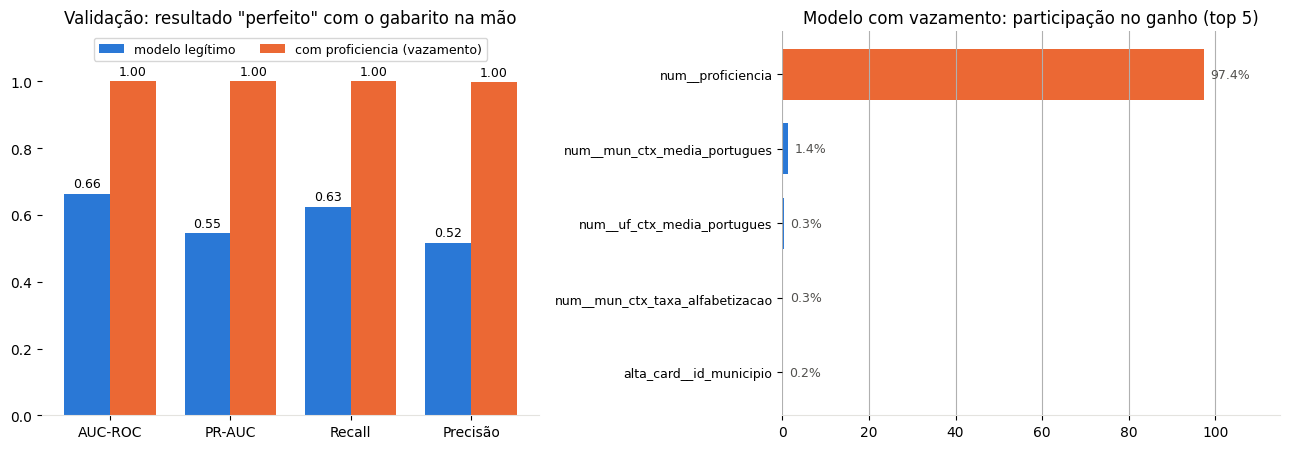

num__proficiencia                  97.37
num__mun_ctx_media_portugues        1.39
num__uf_ctx_media_portugues         0.31
num__mun_ctx_taxa_alfabetizacao     0.26
alta_card__id_municipio             0.22


In [94]:
# Visualizando a diferença e o peso de cada variável no modelo com vazamento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

# Gráfico 1: métricas lado a lado
metricas_graf = ["AUC-ROC", "PR-AUC", "Recall (Sensibilidade)", "Precisão"]
rotulos_graf = ["AUC-ROC", "PR-AUC", "Recall", "Precisão"]
x = np.arange(len(metricas_graf))
largura = 0.38
legit = [metricas_lgbm_ajustado[m] for m in metricas_graf]
vazado = [metricas_leakage[m] for m in metricas_graf]
ax1.bar(x - largura / 2, legit, largura, color=AZUL, label="modelo legítimo")
ax1.bar(x + largura / 2, vazado, largura, color=LARANJA, label="com proficiencia (vazamento)")
for i in range(len(x)):
    ax1.text(x[i] - largura / 2, legit[i] + 0.02, f"{legit[i]:.2f}", ha="center", fontsize=9)
    ax1.text(x[i] + largura / 2, vazado[i] + 0.02, f"{vazado[i]:.2f}", ha="center", fontsize=9)
ax1.set_xticks(x, rotulos_graf)
ax1.set_ylim(0, 1.15)
ax1.set_title("Validação: resultado \"perfeito\" com o gabarito na mão")
ax1.legend(loc="upper center", ncol=2, fontsize=9)
limpa_eixos(ax1)

# Gráfico 2: quanto cada variável contribui para as decisões do modelo (ganho)
ganho = pd.Series(pipe_leak.named_steps["modelo"].booster_.feature_importance(importance_type="gain"),
                  index=colunas_modelo)
participacao = (100 * ganho / ganho.sum()).sort_values(ascending=False).head(5)
barras_horizontais(ax2, participacao.index.tolist(), participacao.values.tolist(), formato="{:.1f}%",
                   destaque={"num__proficiencia": LARANJA})
ax2.set_title("Modelo com vazamento: participação no ganho (top 5)")
ax2.tick_params(axis="y", labelsize=9)

fig.tight_layout()
salva(fig, "projeto_teste_vazamento.png"); plt.show()

print(participacao.round(2).to_string())

del X_leak, y_leak, Xl_tr, Xl_val, pipe_leak
_ = gc.collect()  # libera memória sem imprimir nada

**Nota:**

**O resultado "perfeito" do modelo com vazamento** (validação, 10.034 crianças):

| Métrica | Modelo legítimo | Com `proficiencia` |
|---|---|---|
| Acurácia | 61,56% | **99,88%** |
| Precisão | 51,57% | **99,70%** |
| Recall | 62,52% | **100,00%** |
| F1-Score | 56,52% | **99,85%** |
| AUC-ROC | 0,662 | **1,000** |
| PR-AUC | 0,545 | **1,000** |
| Crianças em risco não encontradas | 1.503 | **0** |
| Alarmes falsos | 2.354 | **12** |

- Com a nota da prova, o modelo encontra **todas as 4.010 crianças em risco** e erra só **12** entre as alfabetizadas. É um
  resultado **bom demais para ser verdade**.
- **O gráfico da direita mostra por quê:** `proficiencia` responde por cerca de **97%** de tudo o que o modelo usa para decidir. As outras
  variáveis — histórico do município, estado, escola — praticamente **deixam de importar**.
- **O modelo não aprendeu nada útil**: ele só aprendeu a copiar a nota da prova e aplicar o corte de 743 pontos.

**Por que esse modelo seria inútil na prática?**

- O objetivo do projeto é identificar as crianças em risco **antes** da avaliação, para dar tempo de oferecer reforço.
- Para usar o modelo com vazamento, seria preciso **já ter a nota da prova** — e, com ela em mãos, a resposta já é conhecida.
- É como um sistema que "prevê" a chuva olhando se a rua está molhada: acerta sempre, mas chega **tarde demais** para alguém levar o guarda-chuva.

**Métrica quase perfeita é sintoma, não conquista.**

Sempre que um modelo passa de **0,99 de AUC-ROC** em dados como estes, a primeira suspeita deve ser **vazamento**: alguma coluna está
entregando a resposta. Neste caso a suspeita está **confirmada por construção** — o alvo é definido pela própria `proficiencia`.

- **O modelo legítimo (AUC 0,662)** é mais modesto, mas é **honesto**: usa apenas o que se sabe **antes da prova** e, por isso, pode ser
  usado de verdade para priorizar o reforço escolar.
- Este teste também confirma que o pré-processador estava fazendo o seu trabalho: sem declarar `proficiencia` como numérica extra, ela
  seria descartada — é essa proteção que mantém o modelo final livre de vazamento.

### 🛡️ Resumo: houve vazamento? Foi resolvido?

**Vazamento** (*data leakage*) é quando o modelo recebe, durante o treino, alguma informação que **não estaria disponível no momento real
da previsão** — em geral, algo que "entrega" a resposta. O resultado parece ótimo no notebook e falha no mundo real.

**Resposta curta: sim, havia vários riscos de vazamento — e todos foram identificados e tratados.**

| Vazamento | O que é, em palavras simples | Resolvido? | Como foi resolvido | Onde no notebook |
|---|---|---|---|---|
| **Nota da prova** (`proficiencia`) | a nota **é** a resposta: 743 pontos ou mais = alfabetizado | ✅ Sim | retirada do modelo (lista `COLUNAS_LEAKAGE` em `src/config.py`) | Limpeza · Seção 9 |
| **Resultados de 2024 do município** (taxa, média de português) | são médias da própria resposta, calculadas no mesmo ano da prova | ✅ Sim | nem entram na base: todo o contexto vem de **2023** | Entendimento do negócio · Limpeza |
| **Colunas "de 2023" que sabem de 2024** (`percentual_participacao`, `nivel_alfabetizacao`) | parecem ser do ano anterior, mas foram calculadas com dados de 2024 | ✅ Sim | vetadas após o teste de correlação 2023 × 2024 | Seção 5 · O vazamento sutil |
| **Colunas constantes** (metas de 2030) | valem 80 para todos; uma delas deriva só da taxa de 2023 | ✅ Sim | vetadas (não ensinam nada) | Limpeza · Seção 5 |
| **Preencher vazios e codificar categorias antes de separar os dados** | a mediana e o risco médio da escola seriam calculados olhando também o teste | ✅ Sim | tudo acontece dentro de um **Pipeline**, ajustado **só com o treino** | Fase 03 · Valores nulos · Transformação |
| **Cópias do balanceamento na validação cruzada** | a mesma criança copiada cairia no treino e no teste de uma dobra | ✅ Sim | a busca de hiperparâmetros usa o **treino original**, com `scale_pos_weight` | Seção 7 · Ajuste fino |
| **Código da escola "vendo" a própria resposta** (TargetEncoder) | numa escola com 2 crianças, o risco médio seria a resposta delas | ✅ Sim | validação cruzada interna do encoder e pré-processador ajustado **sem as cópias** | Seleção de Variáveis · Seção 7 |
| **Escolher o limiar olhando o teste** | seria ajustar a régua depois de ver a prova | ✅ Sim | limiar escolhido na **validação**; o teste só confere | Seção 8 |

**Como sabemos que funcionou?**

- **O teste anti-vazamento (seção 9) mostra a diferença:** com a nota da prova, o modelo chega a **AUC 1,000** — resultado "perfeito" e inútil.
  Sem ela, o modelo final tem **AUC 0,662** na validação: modesto, mas honesto.
- **O desempenho é estável em dados cada vez mais "novos":** acurácia de **61,6%** na validação, **61,5%** no teste e **63,8%** na simulação com
  1.000 crianças que o projeto nunca usou. Um modelo com vazamento costuma **despencar** quando chega a dados novos — este não despenca.

# **FASE 04: AVALIAÇÃO**

## 1 - **Avaliando a Máquina Preditiva**

Esta é a **fotografia final** do modelo que seria entregue: o **LightGBM ajustado**, treinado com treino + validação (seção 7.3), aplicado
às **10.034 crianças do teste** — que nenhum modelo viu durante o desenvolvimento — com o limiar padrão de **0,5**.

In [95]:
# Comparando gabarito e Previsoes_da_Máquina
gabarito = pd.DataFrame({"Gabarito": y_test, "Previsoes_da_Máquina": yhat})
gabarito

,Gabarito,Previsoes_da_Máquina
0,1,1
1,0,0
2,1,1
3,1,1
4,0,1
...,...,...
10029,0,0
10030,1,1
10031,0,0
10032,0,1


In [96]:
# Dicionário de métricas - LightGBM (modelo final)
acc_test = accuracy_score(y_test, yhat)
m_final = {"F1 Score": str(round(f1_score(y_test, yhat) * 100, 2)) + "%",
           "Acurácia": str(round(acc_test * 100, 2)) + "%",
           "Precisão": str(round(precision_score(y_test, yhat) * 100, 2)) + "%",
           "Recall":   str(round(recall_score(y_test, yhat) * 100, 2)) + "%"}

# Gerando o DataFrame com as métricas do modelo final
df_aux3 = pd.DataFrame({"LightGBM (modelo final)": pd.Series(m_final)})
display(df_aux3)

# Resultado em porcentagem
print("Classification metrics: \n", classification_report(y_test, yhat,
      target_names=["Alfabetizado (0)", "Não alfabetizado (1)"], digits=4))
# Matriz de confusão
print("Confusion Matrix: \n", confusion_matrix(y_test, yhat))
# Acurácia
print("\nAcurácia:", accuracy_score(y_test, yhat))

,LightGBM (modelo final)
F1 Score,56.42%
Acurácia,61.54%
Precisão,51.56%
Recall,62.29%


Classification metrics: 
                       precision    recall  f1-score   support

    Alfabetizado (0)     0.7086    0.6104    0.6558      6024
Não alfabetizado (1)     0.5156    0.6229    0.5642      4010

            accuracy                         0.6154     10034
           macro avg     0.6121    0.6167    0.6100     10034
        weighted avg     0.6315    0.6154    0.6192     10034

Confusion Matrix: 
 [[3677 2347]
 [1512 2498]]

Acurácia: 0.6154076141120192


**Nota:**

**Como ler a tabela gabarito:** cada linha é uma criança do teste. **Gabarito** é o que aconteceu (1 = não se alfabetizou) e
**Previsoes_da_Máquina** é o que o modelo disse. Nas **5 primeiras linhas** mostradas, o modelo acerta **4**; o erro (5ª linha) é um
**alarme falso** — uma criança que se alfabetizou (0), mas foi apontada como em risco (1).

**O modelo final em quatro números:**

| Métrica | Valor | Em palavras simples |
|---|---|---|
| **Acurácia** | **61,54%** | acerta a situação de cerca de **6 em cada 10** crianças |
| **Recall** | **62,29%** | encontra cerca de **6 em cada 10** crianças que não se alfabetizaram |
| **Precisão** | **51,56%** | de cada **2** crianças apontadas como em risco, **1** realmente está |
| **F1 Score** | **56,42%** | o equilíbrio entre encontrar muitas crianças em risco e errar pouco |

**Na matriz de confusão:** das **4.010** crianças que não se alfabetizaram, o modelo encontrou **2.498** e deixou **1.512** de fora; das
**6.024** que se alfabetizaram, reconheceu **3.677** e gerou **2.347** alarmes falsos.

**Leitura final:** é um modelo **modesto, mas útil** — melhor que um sorteio (seção 8.3) e **honesto**, porque usa apenas o que se sabe
**antes da prova** (seção 9). Os números são os mesmos da seção 7.3, agora organizados como o resumo que seria apresentado ao gestor.

## 2 - **Previsto x observado**

As métricas até aqui dizem se o modelo **ordena** bem o risco. Falta a outra pergunta, que é a que o gestor faz primeiro:
**o modelo acerta o tamanho do problema?**

A comparação é direta. Para cada grupo de crianças — aqui, cada **estado** — coloca-se lado a lado a taxa de não alfabetização que
**de fato aconteceu** e a taxa média que o modelo **previu**. A diferença entre as duas, em **pontos percentuais**, é o erro numa unidade
que qualquer pessoa entende.

É o equivalente, num problema de classificação, do gráfico de **valores reais contra valores previstos** que se usa em regressão.

In [97]:
# Tabela de previsões — uma linha por criança do teste, o real ao lado do previsto
df_predicoes = X_test[["sigla_uf", "regiao", "rede", "id_municipio", "id_escola"]].copy()
df_predicoes["real"] = y_test
df_predicoes["risco_previsto"] = yhat_proba.round(4)
df_predicoes["convocado"] = yhat                     # decisão do modelo final no limiar 0,5
df_predicoes["acertou"] = df_predicoes["convocado"] == df_predicoes["real"]

print(f"convocadas: {df_predicoes['convocado'].sum():,}  |  "
      f"decisões corretas: {df_predicoes['acertou'].mean():.1%}\n")
df_predicoes.head()

convocadas: 4,845  |  decisões corretas: 61.5%



,sigla_uf,regiao,rede,id_municipio,id_escola,real,risco_previsto,convocado,acertou
25831,SP,Sudeste,municipal,3513009,60028666,1,0.5208,1,True
17470,MG,Sudeste,municipal,3157708,60020013,0,0.4538,0,True
17034,AM,Norte,estadual,1304203,60000728,1,0.5386,1,True
49674,BA,Nordeste,municipal,2917706,60014948,1,0.7373,1,True
40702,MA,Nordeste,municipal,2111078,60005748,0,0.5430,1,False


**Nota:**

- **Cada linha é uma criança do teste.** `risco_previsto` é a probabilidade que o modelo atribuiu, `convocado` é a decisão tomada
  (1 = apontada para reforço, no limiar **0,5**) e `acertou` diz se a decisão bateu com o que aconteceu (`real`).
- Na 5ª linha, por exemplo, uma criança do **Maranhão** recebeu risco de **0,54**, foi convocada, mas **se alfabetizou** → `acertou = False`.
- O modelo convoca **4.845 crianças** e toma a decisão certa para **61,5%** delas — o mesmo número da acurácia.
- **Por que o limiar 0,5 e não o 0,37?** O limiar 0,5 é o do modelo final e o recomendado na seção 8.3 para um programa com **vagas
  limitadas**. O efeito do limiar 0,37 já foi mostrado na seção 8.3.

In [98]:
# Erro por UF — a taxa que aconteceu contra a taxa média que o modelo previu
desempenho_uf = df_predicoes.groupby("sigla_uf", observed=True).agg(
    criancas=("real", "size"),
    taxa_real=("real", "mean"),
    taxa_prevista=("risco_previsto", "mean"),
).reset_index()
desempenho_uf["taxa_real"] = (100 * desempenho_uf["taxa_real"]).round(1)
desempenho_uf["taxa_prevista"] = (100 * desempenho_uf["taxa_prevista"]).round(1)
desempenho_uf["erro_pp"] = (desempenho_uf["taxa_prevista"] - desempenho_uf["taxa_real"]).round(1)
desempenho_uf["erro_absoluto_pp"] = desempenho_uf["erro_pp"].abs()
desempenho_uf["erro_relativo"] = (desempenho_uf["erro_absoluto_pp"]
                                  / desempenho_uf["taxa_real"]).round(3)
desempenho_uf = desempenho_uf.sort_values("erro_absoluto_pp",
                                          ascending=False).reset_index(drop=True)

print(f"erro absoluto médio entre as {len(desempenho_uf)} UFs: "
      f"{desempenho_uf['erro_absoluto_pp'].mean():.1f} pontos percentuais")
print(f"o modelo superestima o risco em {int((desempenho_uf['erro_pp'] > 0).sum())} "
      f"das {len(desempenho_uf)} UFs — viés médio de "
      f"{desempenho_uf['erro_pp'].mean():+.1f} pp")
print(f"taxa média prevista {100 * yhat_proba.mean():.1f}% contra "
      f"{100 * y_test.mean():.1f}% observada")
print(f"correlação entre a taxa real e a taxa prevista das UFs: "
      f"{desempenho_uf['taxa_real'].corr(desempenho_uf['taxa_prevista']):.2f}")
print(f"UFs com menos de 100 crianças no teste: "
      f"{', '.join(desempenho_uf.loc[desempenho_uf['criancas'] < 100, 'sigla_uf'])}\n")
display(desempenho_uf)

erro absoluto médio entre as 26 UFs: 8.9 pontos percentuais
o modelo superestima o risco em 26 das 26 UFs — viés médio de +8.9 pp
taxa média prevista 49.0% contra 40.0% observada
correlação entre a taxa real e a taxa prevista das UFs: 0.96
UFs com menos de 100 crianças no teste: AC, SE, TO, AP



,sigla_uf,criancas,taxa_real,taxa_prevista,erro_pp,erro_absoluto_pp,erro_relativo
0,RN,120,54.2,68.8,14.6,14.6,0.269
1,AL,178,47.8,61.5,13.7,13.7,0.287
2,RO,100,29.0,42.0,13.0,13.0,0.448
3,SC,384,37.8,49.9,12.1,12.1,0.320
4,MG,1014,26.4,38.3,11.9,11.9,0.451
5,MT,247,36.8,48.4,11.6,11.6,0.315
6,PA,467,48.4,59.8,11.4,11.4,0.236
7,PR,604,26.2,37.1,10.9,10.9,0.416
8,ES,227,26.0,36.9,10.9,10.9,0.419
9,PB,174,42.5,53.3,10.8,10.8,0.254


**Nota:**

- **O erro não é aleatório: é um viés.** O modelo superestima o risco nas **26 UFs**, sem nenhuma exceção, em média **8,9 pontos
  percentuais**. Ele não erra para mais em um estado e para menos em outro — erra **sempre para o mesmo lado**.
- **A causa já é conhecida** (seção 8.4): o `scale_pos_weight = 1,5` do ajuste fino dá peso extra às crianças não alfabetizadas, e isso
  empurra todas as probabilidades para cima. Na média, o modelo prevê **49,0%** de risco, e a taxa real é **40,0%**.
- **A ordem entre os estados está correta:** a correlação entre a taxa real e a prevista é de **0,96**. O **Ceará** tem a menor taxa real
  (**16,3%**) e também a menor prevista (**17,8%**); a **Bahia** tem uma das maiores nas duas (**63,7%** real, **72,3%** prevista).
- **`erro_relativo`** é o erro dividido pela taxa real. Em **Minas Gerais**, por exemplo, o modelo erra 11,9 pontos sobre uma taxa de 26,4%
  — um erro relativo de 45%, alto porque a taxa real é baixa.
- **Cuidado com estados pequenos:** **AP (49)**, **TO (75)**, **AC (76)** e **SE (89)** têm menos de 100 crianças no teste. Com tão poucas
  crianças, a taxa real oscila por acaso, e o erro desses estados (como o do Amapá, de só 3,1 pontos) não deve ser lido como um acerto especial.
- O **Rio Grande do Norte** lidera o erro (**14,6 pontos**), mas também tem só **120** crianças no teste.

images/projeto_real_x_previsto.png


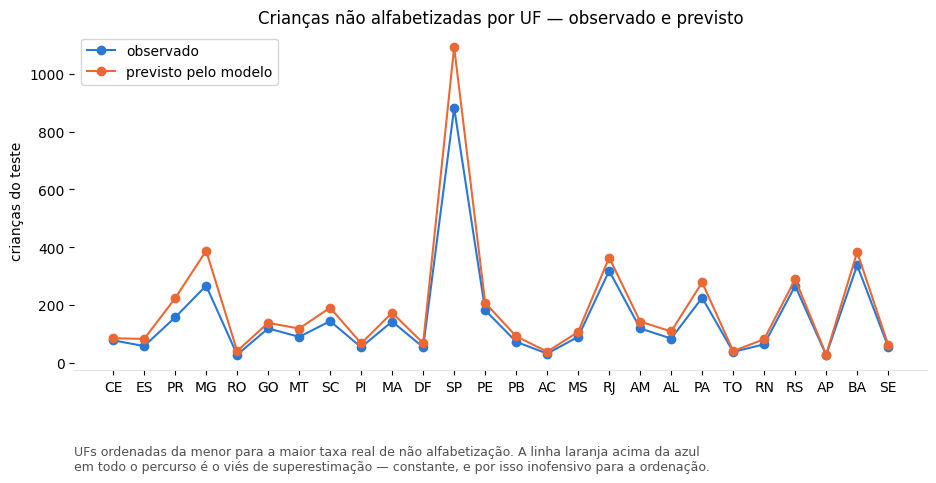


Total no teste: 4,010 crianças não alfabetizadas observadas | 4,914 previstas pelo modelo (soma das probabilidades)


In [99]:
# Crianças não alfabetizadas por UF: quantas foram e quantas o modelo previu
ordem = desempenho_uf.sort_values("taxa_real")
reais = ordem["criancas"] * ordem["taxa_real"] / 100
previstas = ordem["criancas"] * ordem["taxa_prevista"] / 100

fig, ax = plt.subplots(figsize=(11, 4.4))
ax.plot(ordem["sigla_uf"], reais, marker="o", color=AZUL, label="observado")
ax.plot(ordem["sigla_uf"], previstas, marker="o", color=LARANJA, label="previsto pelo modelo")
ax.set_title("Crianças não alfabetizadas por UF — observado e previsto")
ax.set_ylabel("crianças do teste")
ax.legend(loc="upper left")
limpa_eixos(ax)
anota(ax, "UFs ordenadas da menor para a maior taxa real de não alfabetização. A linha laranja "
          "acima da azul\nem todo o percurso é o viés de superestimação — constante, e por isso "
          "inofensivo para a ordenação.")
print(salva(fig, "projeto_real_x_previsto.png"))
plt.show()

print(f"\nTotal no teste: {int(y_test.sum()):,} crianças não alfabetizadas observadas | "
      f"{yhat_proba.sum():,.0f} previstas pelo modelo (soma das probabilidades)")

**Nota:**

- **Como ler:** cada ponto é um estado, ordenado da menor para a maior taxa real. A **linha azul** é quantas crianças de fato não se
  alfabetizaram no teste; a **laranja**, quantas o modelo esperava (somando as probabilidades). Um modelo perfeito faria as duas se sobreporem.
- **As duas linhas sobem e descem juntas**, e é isso que mais importa: o modelo acompanha a variação real entre os estados. **São Paulo**
  forma o pico do gráfico por ter **2.145 crianças** no teste, cerca de um quinto do total.
- **A distância vertical é o mesmo viés** de cerca de 9 pontos percentuais. Um modelo que errasse ao acaso cruzaria a linha azul para cima e
  para baixo — este fica **acima dela em todos os estados**.
- **No total**, o modelo "espera" **4.914** crianças não alfabetizadas, mas foram **4.010** — cerca de **900 a mais (+22%)**.

**O que isso significa para o gestor:**

- ✅ **Para priorizar** (quais estados, escolas e crianças recebem reforço primeiro), o modelo **serve bem**: a ordem está correta.
- ❌ **Para orçar** (quantas vagas de reforço reservar), **não se deve somar as probabilidades**: isso superestimaria a necessidade em cerca
  de **22%**. Para esse uso, o número precisaria ser corrigido — por exemplo, recalibrando o modelo.

## 3 - **Quais variáveis mais influenciam o modelo?**

Para saber quais informações o **modelo final** realmente usa, aplicamos a **importância por permutação**:

1. medimos o desempenho do modelo no **teste** (PR-AUC);
2. **embaralhamos** uma única coluna — por exemplo, trocamos aleatoriamente a taxa de 2023 entre as crianças — e medimos de novo;
3. **quanto mais o desempenho cai, mais importante é a coluna**. Se nada muda, o modelo não depende dela.

**Analogia:** é como tirar uma peça de um motor e ver se ele ainda funciona. Se o carro para, a peça era essencial; se continua igual, ela
não fazia diferença. O teste é repetido **5 vezes** para cada coluna, para não depender da sorte de um único embaralhamento.

calculado em 48s | PR-AUC do modelo no teste: 0.5515



,variavel,queda_pr_auc,desvio
0,mun_ctx_media_portugues,0.0186,0.0030
1,id_municipio,0.0112,0.0023
2,id_escola,0.0077,0.0016
3,mun_ctx_taxa_alfabetizacao,0.0063,0.0019
4,sigla_uf,0.0060,0.0011
5,uf_ctx_media_portugues,0.0048,0.0027
6,peso_aluno,0.0041,0.0020
7,ibge_pib_per_capita,0.0013,0.0014
8,uf_ctx_taxa_alfabetizacao,0.0004,0.0007
9,escola_n_alunos_avaliados,0.0004,0.0009


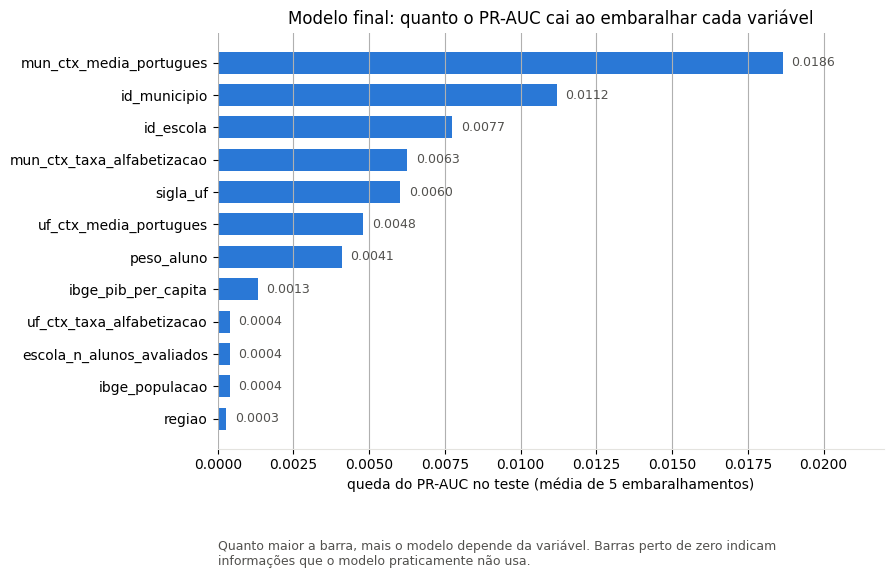

In [100]:
# Importância por permutação do modelo final, no conjunto de TESTE
t0 = time.time()
resultado_perm = permutation_importance(model, X_test, y_test, scoring="average_precision",
                                        n_repeats=5, random_state=SEED, n_jobs=-1)
print(f"calculado em {time.time() - t0:.0f}s | PR-AUC do modelo no teste: {metricas_final['PR-AUC']:.4f}\n")

importancia_final = (pd.DataFrame({"variavel": X_test.columns,
                                   "queda_pr_auc": resultado_perm.importances_mean,
                                   "desvio": resultado_perm.importances_std})
                       .sort_values("queda_pr_auc", ascending=False)
                       .reset_index(drop=True))
display(importancia_final.round(4))

# Visualizando as 12 variáveis que mais influenciam o modelo
topo_perm = importancia_final.head(12)
fig, ax = plt.subplots(figsize=(8.6, 5.4))
barras_horizontais(ax, topo_perm["variavel"].tolist(), topo_perm["queda_pr_auc"].tolist(), formato="{:.4f}")
ax.set_title("Modelo final: quanto o PR-AUC cai ao embaralhar cada variável")
ax.set_xlabel("queda do PR-AUC no teste (média de 5 embaralhamentos)")
anota(ax, "Quanto maior a barra, mais o modelo depende da variável. Barras perto de zero indicam\n"
          "informações que o modelo praticamente não usa.")
salva(fig, "projeto_importancia_modelo_final.png"); plt.show()

**Nota:**

**As variáveis que mais influenciam o modelo final:**

| Posição | Variável | Queda do PR-AUC | Em palavras simples |
|---|---|---|---|
| 1º | `mun_ctx_media_portugues` | **0,0186** | nota média de português do município em 2023 |
| 2º | `id_municipio` | **0,0112** | em qual município a criança estuda |
| 3º | `id_escola` | **0,0077** | em qual escola a criança estuda |
| 4º | `mun_ctx_taxa_alfabetizacao` | **0,0063** | taxa de alfabetização do município em 2023 |
| 5º | `sigla_uf` | **0,0060** | em qual estado a criança estuda |
| 6º | `uf_ctx_media_portugues` | **0,0048** | nota média de português do estado em 2023 |

- **O modelo se apoia em duas coisas: o histórico de 2023 e o lugar onde a criança estuda** (município, escola e estado). É exatamente o que a
  análise exploratória antecipou nas hipóteses **H1** (território) e **H2** (histórico).
- **Várias variáveis quase não influenciam:** o caderno de prova, a série, a rede, as metas, o tamanho do município e da escola ficam com
  queda **próxima de zero**. Algumas aparecem até com valor levemente negativo — isso significa apenas que embaralhá-las não piorou o modelo.
- **As quedas são pequenas em valor absoluto** (a maior é de 0,019 sobre um PR-AUC de 0,551). Isso confirma o que vimos ao longo do notebook:
  **não existe uma variável dominante** — o modelo combina muitos sinais fracos.
- **Diferença para a Seleção de Variáveis (Fase 03):** lá, o Random Forest destacou `escola_n_alunos_avaliados` e `peso_aluno`, que aqui quase
  não pesam. A importância por permutação, medida no **teste** e no **modelo final**, é a leitura mais confiável.

# **FASE 05: IMPLANTAÇÃO**

**Implantar** é tirar o modelo do notebook e deixá-lo pronto para ser **usado de verdade**: salvar o modelo em um arquivo, carregá-lo
em outro momento e aplicá-lo a **crianças novas**.

Esta fase tem duas partes:

1. **Salvar o modelo** final, junto com as informações necessárias para usá-lo corretamente.
2. **Aplicar uma simulação**: criar uma base com crianças que o modelo **nunca viu** e mostrar, passo a passo, o que ele faria com elas.

## 1 - **Salvando o modelo**

In [101]:
# Exportando o modelo final (Pipeline completo: pré-processamento + LightGBM ajustado)
caminho_modelo_final = MODELS_DIR / "modelo_final_alfabetizacao.joblib"
joblib.dump(model, caminho_modelo_final)

# Ficha do modelo: tudo o que é preciso saber para usá-lo corretamente
ficha_modelo = {
    "modelo": "LightGBM ajustado (Pipeline: pré-processamento + LGBMClassifier)",
    "arquivo": caminho_modelo_final.name,
    "data_treino": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
    "treinado_com": f"{len(X_train_val):,} crianças (treino + validação)",
    "colunas_de_entrada": FEATURES,
    "alvo": f"{ALVO} (1 = não alfabetizado)",
    "limiar_recomendado": 0.5,
    "limiar_alternativo": round(float(limiar_f1), 2),
    "metricas_no_teste": {m: round(float(metricas_final[m]), 4)
                          for m in ["Acurácia", "Precisão", "Recall (Sensibilidade)", "F1-Score", "AUC-ROC", "PR-AUC"]},
    "hiperparametros": {k.replace("modelo__", ""): (round(float(v), 4) if isinstance(v, float) else v)
                        for k, v in random_search_lgbm.best_params_.items()},
    "avisos": [
        "Use a probabilidade como ORDEM de prioridade, não como chance exata (o modelo superestima o risco em ~9 p.p.).",
        "Não use 'proficiencia' como entrada: ela é a própria resposta (vazamento).",
    ],
}
caminho_ficha = MODELS_DIR / "modelo_final_alfabetizacao.json"
with open(caminho_ficha, "w", encoding="utf-8") as arquivo:
    json.dump(ficha_modelo, arquivo, ensure_ascii=False, indent=2, default=str)

print(f"💾 Modelo salvo em: models/{caminho_modelo_final.name}")
print(f"📄 Ficha do modelo salva em: models/{caminho_ficha.name}\n")
print(json.dumps(ficha_modelo, ensure_ascii=False, indent=2, default=str))

💾 Modelo salvo em: models/modelo_final_alfabetizacao.joblib
📄 Ficha do modelo salva em: models/modelo_final_alfabetizacao.json

{
  "modelo": "LightGBM ajustado (Pipeline: pré-processamento + LGBMClassifier)",
  "arquivo": "modelo_final_alfabetizacao.joblib",
  "data_treino": "2026-09-14 22:13",
  "treinado_com": "40,135 crianças (treino + validação)",
  "colunas_de_entrada": [
    "peso_aluno",
    "mun_ctx_taxa_alfabetizacao",
    "mun_ctx_media_portugues",
    "mun_meta_2024",
    "mun_gap_projetado",
    "uf_ctx_taxa_alfabetizacao",
    "uf_ctx_media_portugues",
    "uf_ctx_ranking_nacional",
    "escola_n_alunos_avaliados",
    "mun_n_alunos_avaliados",
    "mun_n_escolas",
    "ibge_populacao",
    "ibge_pib_per_capita",
    "ibge_densidade_demografica",
    "ibge_log_populacao",
    "rede",
    "serie",
    "caderno",
    "regiao",
    "sigla_uf",
    "id_municipio",
    "id_escola"
  ],
  "alvo": "nao_alfabetizado (1 = não alfabetizado)",
  "limiar_recomendado": 0.5,
  "limiar_

**Nota:**

- **O que foi salvo:** o **Pipeline completo** — pré-processamento (mediana, one-hot, TargetEncoder) **e** o LightGBM ajustado — em um único
  arquivo `.joblib`. Assim, quem for usar o modelo **não precisa repetir** nenhuma transformação: basta entregar os dados das crianças como
  estão na base.
- **Melhoria em relação ao exemplo:** além do modelo, foi salva uma **ficha do modelo** (`.json`) com as colunas de entrada, o limiar
  recomendado, as métricas no teste, os hiperparâmetros e os **avisos de uso**. Um modelo sem essas informações é como um remédio sem bula.
- **Por que não usar `LabelEncoder`, como no exemplo?** Porque o Pipeline já faz a transformação das categorias **do mesmo jeito** que foi
  feito no treino. Transformar à mão, fora do Pipeline, é uma fonte comum de erro: um estado codificado com um número diferente mudaria a previsão.

## 2 - **Aplicando uma simulação**

**Criando uma base de teste para a simulação**

Para simular o uso real, precisamos de crianças que o modelo **nunca viu** — nem no treino, nem na validação, nem no teste. Por isso a base
de simulação é criada a partir da **base original completa** (1,85 milhão de crianças), **excluindo** todas as 50 mil crianças da amostra
usada no projeto. São sorteadas **1.000 crianças** de forma reprodutível e salvas em um CSV próprio.

In [102]:
# Criando a base de simulação a partir da base original, sem as crianças já usadas no projeto
ids_usados = pd.read_csv(CAMINHO_CSV, sep=";", usecols=["id_aluno"], dtype={"id_aluno": str}, encoding="utf-8-sig")

con = duckdb.connect()
con.register("ids_usados", ids_usados)
base_simulacao = con.sql(f"""
    SELECT b.*
    FROM read_parquet('{BASE_ALUNOS.as_posix()}') AS b
    WHERE CAST(b.id_aluno AS VARCHAR) NOT IN (SELECT id_aluno FROM ids_usados)
    ORDER BY hash(CAST(b.id_aluno AS VARCHAR) || '{SEED}')   -- sorteio reprodutível
    LIMIT 1000
""").df()
con.close()

CAMINHO_SIMULACAO = PROCESSED_DIR / "base_simulacao_1000.csv"
base_simulacao.to_csv(CAMINHO_SIMULACAO, index=False, sep=";", decimal=",", encoding="utf-8-sig")

print(f"Base de simulação: {len(base_simulacao):,} crianças salvas em data/processed/{CAMINHO_SIMULACAO.name}")
print(f"Crianças repetidas em relação à amostra do projeto: "
      f"{base_simulacao['id_aluno'].astype(str).isin(ids_usados['id_aluno']).sum()}")

Base de simulação: 1,000 crianças salvas em data/processed/base_simulacao_1000.csv
Crianças repetidas em relação à amostra do projeto: 0


In [103]:
# Lendo a base de simulação, como faria quem recebe um novo arquivo de crianças
df_simulacao = pd.read_csv(
    CAMINHO_SIMULACAO, sep=";", decimal=",", encoding="utf-8-sig",
    dtype={"id_aluno": str, "id_escola": str, "id_municipio": str, "serie": str, "caderno": str},
)
print(f"{df_simulacao.shape[0]:,} crianças x {df_simulacao.shape[1]} colunas | "
      f"{df_simulacao['sigla_uf'].nunique()} UFs\n")
print("Valores ausentes nas colunas de entrada do modelo:")
print(df_simulacao[FEATURES].isnull().sum()[lambda s: s > 0])
df_simulacao.head()

1,000 crianças x 32 colunas | 26 UFs

Valores ausentes nas colunas de entrada do modelo:
mun_ctx_taxa_alfabetizacao    13
mun_ctx_media_portugues       13
mun_meta_2024                 37
mun_gap_projetado             37
uf_ctx_taxa_alfabetizacao     13
uf_ctx_media_portugues        13
uf_ctx_ranking_nacional       13
dtype: int64


,ano,id_aluno,id_escola,id_municipio,nome_municipio,sigla_uf,regiao,rede,serie,caderno,peso_aluno,mun_ctx_taxa_alfabetizacao,mun_ctx_media_portugues,mun_ctx_nivel_alfabetizacao,mun_ctx_percentual_participacao,mun_meta_2024,mun_meta_2030,mun_gap_projetado,mun_esforco_anual_requerido,uf_ctx_taxa_alfabetizacao,uf_ctx_media_portugues,uf_ctx_ranking_nacional,uf_meta_2030,escola_n_alunos_avaliados,mun_n_alunos_avaliados,mun_n_escolas,proficiencia,nao_alfabetizado,ibge_populacao,ibge_pib_per_capita,ibge_densidade_demografica,ibge_log_populacao
0,2024,15001430,60002295,1500107,Abaetetuba,PA,Norte,municipal,2,7,1.000000,39.73,725.5913,0.0,84.665,46.03,80.0,6.30,5.753,48.38,733.29,17.0,80.0,61,1270,39,737.190000,1,170999.0,14275.48,87.61,12.0494
1,2024,29213618,60017070,2927408,Salvador,BA,Nordeste,municipal,2,9,1.000000,39.16,726.7501,0.0,85.995,45.52,80.0,6.36,5.834,36.78,724.86,23.0,80.0,87,12158,264,687.110000,1,2568928.0,29856.34,3859.35,14.7590
2,2024,21013380,60006218,2110401,São Benedito do Rio Preto,MA,Nordeste,municipal,2,6,1.300000,46.81,726.0404,0.5,81.150,52.21,80.0,5.40,4.741,56.43,749.92,10.0,80.0,41,183,7,714.280000,1,18793.0,9922.52,19.11,9.8413
3,2024,35140187,60028498,3503307,Araras,SP,Sudeste,municipal,2,2,1.368421,58.10,749.0684,2.0,92.130,61.73,80.0,3.63,3.129,51.91,740.39,15.0,80.0,45,1043,22,742.652566,1,135331.0,74061.91,184.30,11.8155
4,2024,25015177,60011167,2504603,Conde,PB,Nordeste,municipal,2,7,1.130000,62.38,752.7814,3.0,92.875,65.28,80.0,2.90,2.517,51.12,741.60,16.0,80.0,48,406,9,819.880000,0,29543.0,55793.25,123.74,10.2936


**Nota:**

- A base de simulação tem **1.000 crianças** de **26 UFs**, e **nenhuma** delas faz parte da amostra de 50 mil usada no projeto. É o mais
  próximo de "crianças novas" que conseguimos ter.
- Ela foi salva em `data/processed/base_simulacao_1000.csv` e lida de volta **como um arquivo novo**, simulando o que aconteceria quando
  uma secretaria de educação enviasse a lista de crianças.
- Há alguns **valores ausentes** nas colunas de contexto (como na base original). **Não é preciso tratá-los à mão:** o Pipeline salvo preenche
  os vazios da mesma forma que fez no treino.
- A coluna `nao_alfabetizado` existe aqui porque essas crianças **já fizeram a prova** — ela serve para **conferir** a simulação. Na vida
  real, essa coluna ainda não existiria no momento da previsão.

In [104]:
# === 1. Carregar o modelo salvo (como faria outro sistema, em outro momento) ===
modelo_load = joblib.load(caminho_modelo_final)
print(f"Modelo carregado: {type(modelo_load).__name__} com as etapas {list(modelo_load.named_steps)}")

# === 2. Função para gerar previsões ===
def gerar_previsoes(dataset, modelo, limiar=0.5):
    """Aplica o modelo a uma base de crianças e devolve uma tabela com a previsão de cada uma."""
    # Mantém a coluna original do alvo (só existe porque é uma simulação)
    y_true = dataset[ALVO].values

    # Seleciona apenas as colunas de entrada do modelo (sem proficiencia e sem colunas vetadas)
    X, _ = matriz_xy(dataset)

    # Faz previsões: probabilidade de NÃO se alfabetizar e decisão pelo limiar
    y_prob = modelo.predict_proba(X)[:, 1]
    y_pred = (y_prob >= limiar).astype(int)

    # Cria dataframe final
    df_final = pd.DataFrame({
        "id_aluno": dataset["id_aluno"].values,
        "municipio": dataset["nome_municipio"].values,
        "uf": dataset["sigla_uf"].values,
        "rede": dataset["rede"].values,
        "nao_alfabetizado_original": y_true,
        "nao_alfabetizado_previsto": y_pred,
        "probabilidade_risco_%": (100 * y_prob).round(1),
    })

    # Ordem de prioridade: 1 = criança com maior risco
    df_final["prioridade"] = df_final["probabilidade_risco_%"].rank(ascending=False, method="first").astype(int)
    return df_final

# === 3. Gerar dataset final ===
df_resultado = gerar_previsoes(df_simulacao, modelo_load)

# Visualizar
df_resultado.head()

Modelo carregado: Pipeline com as etapas ['prep', 'modelo']


,id_aluno,municipio,uf,rede,nao_alfabetizado_original,nao_alfabetizado_previsto,probabilidade_risco_%,prioridade
0,15001430,Abaetetuba,PA,municipal,1,1,66.7,123
1,29213618,Salvador,BA,municipal,1,1,73.7,52
2,21013380,São Benedito do Rio Preto,MA,municipal,1,1,74.0,45
3,35140187,Araras,SP,municipal,1,0,49.0,500
4,25015177,Conde,PB,municipal,0,0,40.6,715


In [105]:
def resumo_previsao(df_final):
    """
    Gera um resumo de acertos e erros do modelo.

    df_final → dataframe com colunas: nao_alfabetizado_original, nao_alfabetizado_previsto
    """
    # Cria coluna indicando se a previsão foi correta
    df_final["acertou"] = df_final["nao_alfabetizado_original"] == df_final["nao_alfabetizado_previsto"]

    # Contagem
    total = len(df_final)
    acertos = df_final["acertou"].sum()
    erros = total - acertos
    taxa_acerto = (acertos / total) * 100

    real = df_final["nao_alfabetizado_original"]
    prev = df_final["nao_alfabetizado_previsto"]
    em_risco = int(real.sum())
    encontradas = int(((real == 1) & (prev == 1)).sum())
    apontadas = int(prev.sum())

    # Resumo geral
    print("===== Resumo de Previsões =====")
    print(f"Total de previsões: {total}")
    print(f"Acertos: {acertos}")
    print(f"Erros: {erros}")
    print(f"Taxa de acerto: {taxa_acerto:.2f}%")

    print("\n===== Crianças em risco =====")
    print(f"Crianças que não se alfabetizaram: {em_risco}")
    print(f"Crianças apontadas como em risco: {apontadas}")
    print(f"Em risco encontradas pelo modelo: {encontradas} ({100 * encontradas / em_risco:.1f}% — recall)")
    print(f"Acerto entre as apontadas: {100 * encontradas / apontadas:.1f}% (precisão)")

    print("\n===== Detalhe por categoria =====")
    print(df_final["acertou"].value_counts().rename({True: "Acertou", False: "Errou"}))

# Exemplo de uso
resumo_previsao(df_resultado)

df_resultado.sort_values("prioridade").head(5)

===== Resumo de Previsões =====
Total de previsões: 1000
Acertos: 638
Erros: 362
Taxa de acerto: 63.80%

===== Crianças em risco =====
Crianças que não se alfabetizaram: 380
Crianças apontadas como em risco: 480
Em risco encontradas pelo modelo: 249 (65.5% — recall)
Acerto entre as apontadas: 51.9% (precisão)

===== Detalhe por categoria =====
acertou
Acertou    638
Errou      362
Name: count, dtype: int64


,id_aluno,municipio,uf,rede,nao_alfabetizado_original,nao_alfabetizado_previsto,probabilidade_risco_%,prioridade,acertou
411,29043081,Candeal,BA,municipal,1,1,78.8,1,True
887,29135729,Lapão,BA,municipal,0,1,78.8,2,False
959,24009140,Ipanguaçu,RN,municipal,0,1,78.7,3,False
484,29161035,Nova Soure,BA,municipal,0,1,78.3,4,False
371,29028923,Cachoeira,BA,municipal,1,1,78.1,5,True


**Nota:**

**Como ler a tabela de resultado:** cada linha é uma criança da simulação, com o município, a UF e a rede, o que **aconteceu**
(`nao_alfabetizado_original`), o que o modelo **previu** (`nao_alfabetizado_previsto`), a **probabilidade de risco** em % e a **prioridade**
(1 = criança com maior risco). A última tabela mostra as **5 crianças no topo da fila de prioridade**.

**O modelo em crianças que nunca viu** (limiar 0,5):

| Resultado | Simulação (1.000 crianças novas) | Teste (seção 7.3) |
|---|---|---|
| Taxa de acerto (acurácia) | **63,8%** | 61,5% |
| Recall (em risco encontradas) | **65,5%** — 249 de 380 | 62,3% |
| Precisão (acerto entre as apontadas) | **51,9%** — 249 de 480 | 51,6% |

- **O desempenho se manteve** — e até ficou um pouco melhor — em crianças totalmente novas. É mais uma confirmação de que o modelo **generaliza**
  e pode ser usado com confiança **dentro dos seus limites**.
- Das **380** crianças que não se alfabetizaram, o modelo encontrou **249**. Das **480** crianças que ele apontou, **249** estavam de fato em risco.
- Pequenas diferenças em relação ao teste são esperadas: são só 1.000 crianças, e a taxa de não alfabetizados nesta base é de **38%** (no teste, 40%).

**Simulação para o gestor: e se houver poucas vagas de reforço?**

Na prática, o programa de reforço tem um **número limitado de vagas**. A pergunta do gestor é: *"se eu tiver X vagas, quantas crianças em risco
consigo alcançar?"*. A simulação abaixo usa a **ordem de prioridade** do modelo (as crianças de maior risco primeiro) e compara com
**sortear** as vagas.

,Vagas de reforço,Em risco alcançadas (modelo),Em risco alcançadas (sorteio),Crianças a mais com o modelo,Ganho
0,100,66,38,28,1.74x
1,200,116,76,40,1.53x
2,300,162,114,48,1.42x
3,500,257,190,67,1.35x


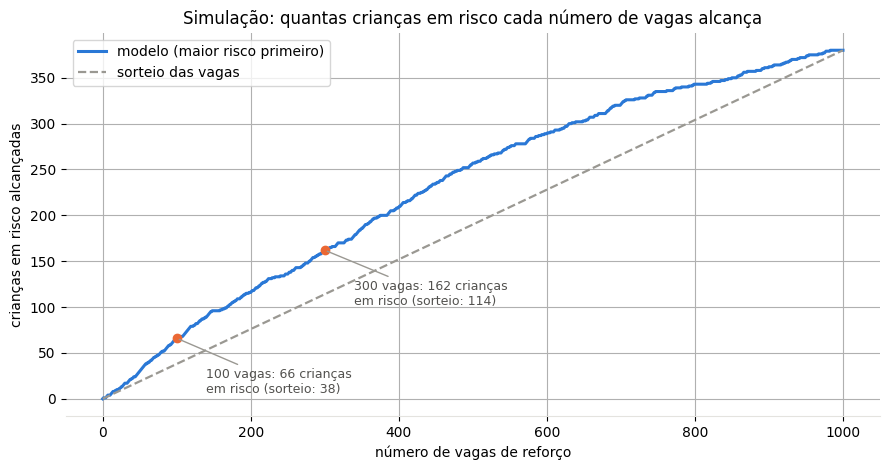

In [106]:
# Quantas crianças em risco são alcançadas com X vagas: modelo (maior risco primeiro) x sorteio
fila = df_resultado.sort_values("prioridade")
taxa_risco = df_resultado["nao_alfabetizado_original"].mean()

cenarios = []
for vagas in [100, 200, 300, 500]:
    alcancadas = int(fila["nao_alfabetizado_original"].head(vagas).sum())
    sorteio = vagas * taxa_risco
    cenarios.append({"Vagas de reforço": vagas,
                     "Em risco alcançadas (modelo)": alcancadas,
                     "Em risco alcançadas (sorteio)": round(sorteio),
                     "Crianças a mais com o modelo": round(alcancadas - sorteio),
                     "Ganho": f"{alcancadas / sorteio:.2f}x"})
display(pd.DataFrame(cenarios))

# Curva completa: de 0 a 1.000 vagas
vagas_eixo = np.arange(0, len(fila) + 1)
curva_modelo = np.concatenate([[0], fila["nao_alfabetizado_original"].cumsum().values])
curva_sorteio = vagas_eixo * taxa_risco

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(vagas_eixo, curva_modelo, color=AZUL, linewidth=2.2, label="modelo (maior risco primeiro)")
ax.plot(vagas_eixo, curva_sorteio, color=NEUTRO, linestyle="--", linewidth=1.6, label="sorteio das vagas")
for vagas in [100, 300]:
    alcancadas = curva_modelo[vagas]
    ax.scatter([vagas], [alcancadas], color=LARANJA, zorder=3)
    ax.annotate(f"{vagas} vagas: {alcancadas} crianças\nem risco (sorteio: {vagas * taxa_risco:.0f})",
                xy=(vagas, alcancadas), xytext=(vagas + 40, alcancadas - 60), fontsize=9, color=TINTA_SEC,
                arrowprops=dict(arrowstyle="-", color=NEUTRO))
ax.set_xlabel("número de vagas de reforço")
ax.set_ylabel("crianças em risco alcançadas")
ax.set_title("Simulação: quantas crianças em risco cada número de vagas alcança")
ax.legend(loc="upper left")
limpa_eixos(ax); ax.grid(True)
fig.tight_layout()
salva(fig, "projeto_simulacao_vagas.png"); plt.show()

**Nota:**

| Vagas de reforço | Modelo (maior risco primeiro) | Sorteio | Crianças em risco a mais |
|---|---|---|---|
| 100 | **66** | 38 | **+28** (1,74x) |
| 200 | **116** | 76 | **+40** (1,53x) |
| 300 | **162** | 114 | **+48** (1,42x) |
| 500 | **257** | 190 | **+67** (1,35x) |

- **Com 100 vagas**, seguir a ordem do modelo alcança **66** crianças em risco; sortear as vagas alcançaria só **38** — o modelo leva o reforço
  a **74% mais** crianças que precisam.
- **Como ler o gráfico:** a **linha azul** (modelo) fica **sempre acima** da linha tracejada (sorteio). A distância entre elas é o ganho de usar o
  modelo. Em **proporção**, o ganho é maior com **poucas vagas** (1,74x com 100 vagas, 1,35x com 500); em **número de crianças**, a distância
  cresce até a metade da curva e depois diminui, até desaparecer: com 1.000 vagas, todas as crianças são atendidas e os dois caminhos se encontram.
- **A mensagem principal para o gestor:** o modelo é **mais útil justamente quando os recursos são escassos** — é aí que priorizar bem faz
  diferença.

**Limites da implantação, ditos com clareza:**

- O modelo **erra bastante** (1 em cada 3 crianças em risco fica de fora com o limiar 0,5) e deve ser usado para **priorizar**, não para
  **rotular** crianças.
- A probabilidade deve ser lida como **ordem de risco**, não como chance exata (seção 8.4).
- O modelo precisa ser **retreinado** quando chegarem novos anos de avaliação — ele foi construído com o contexto de 2023 para prever 2024.

## **RESPOSTAS ÀS PERGUNTAS DE NEGÓCIO**

O desafio propõe cinco perguntas. Duas delas pedem uma resposta **por município** ("quais municípios têm maior risco?" e "como prever quem não
vai atingir a meta?"), enquanto o modelo deste notebook prevê o risco **de cada criança**. Por isso, esta seção usa **dois modelos do projeto**:

| Modelo | Pergunta que responde | Onde foi construído |
|---|---|---|
| **Por criança** (este notebook) | "esta criança corre risco de não se alfabetizar?" | Fases 03 a 05 deste notebook |
| **Por município** (rede municipal, estadual ou pública) | "esta rede vai deixar de atingir a meta de alfabetização?" | `src/modeling/train_municipio.py` |

O modelo municipal usa **as mesmas regras anti-vazamento** (contexto de 2023 para prever 2024) e deixou o resultado pronto em
`reports/municipios_risco.csv` (10.806 redes) e as métricas em `reports/metricas_municipio.json`.

### <font color='#F37126'> Quais municípios apresentam maior risco educacional?

In [107]:
# Ranking de risco por município (modelo municipal do projeto)
municipios_risco = pd.read_csv(REPORTS_DIR / "municipios_risco.csv", dtype={"id_municipio": str})
print(f"{len(municipios_risco):,} redes (município x rede) | {municipios_risco['sigla_uf'].nunique()} UFs\n")

# As 15 redes de maior risco entre as que o modelo NÃO viu no treino (probabilidade honesta)
holdout_mun = municipios_risco[municipios_risco["particao"] == "teste"]
top_risco = (holdout_mun.nlargest(15, "prob_nao_atingir_meta")
             [["nome_municipio", "sigla_uf", "rede", "ctx_taxa", "meta_2024", "taxa_observada",
               "nao_atingiu_meta", "prob_nao_atingir_meta"]]
             .rename(columns={"nome_municipio": "município", "sigla_uf": "UF", "ctx_taxa": "taxa 2023",
                              "meta_2024": "meta 2024", "taxa_observada": "taxa 2024",
                              "nao_atingiu_meta": "não atingiu", "prob_nao_atingir_meta": "prob. de não atingir"})
             .reset_index(drop=True))
display(top_risco)

top100 = holdout_mun.nlargest(100, "prob_nao_atingir_meta")
print(f"Entre as 100 redes de maior risco no holdout, {100 * top100['nao_atingiu_meta'].mean():.0f}% de fato não atingiram a meta "
      f"(média geral: {100 * holdout_mun['nao_atingiu_meta'].mean():.0f}%).")
print(f"UFs dessas 100 redes: {top100['sigla_uf'].value_counts().to_dict()}\n")

# Distribuição das faixas de risco por região (% das redes)
faixas_regiao = (pd.crosstab(municipios_risco["regiao"], municipios_risco["faixa_risco"], normalize="index")
                 [["baixo", "moderado", "alto", "critico"]].mul(100).round(1)
                 .sort_values("critico", ascending=False))
print("Faixa de risco por região (% das redes):")
display(faixas_regiao)

10,806 redes (município x rede) | 24 UFs



,município,UF,rede,taxa 2023,meta 2024,taxa 2024,não atingiu,prob. de não atingir
0,Caxias do Sul,RS,publica,67.47,70.89,43.6,1,0.9974
1,Tupanciretã,RS,estadual,62.08,73.19,41.2,1,0.9966
2,Sobradinho,RS,publica,79.55,80.00,63.8,1,0.9965
3,Bento Gonçalves,RS,municipal,77.38,77.77,50.8,1,0.9965
4,Osório,RS,publica,63.66,69.76,42.3,1,0.9962
5,São Sepé,RS,publica,76.88,80.00,51.9,1,0.9960
6,Ivoti,RS,municipal,77.40,77.79,56.9,1,0.9959
7,Três de Maio,RS,estadual,60.51,79.17,55.2,1,0.9956
8,Santa Maria,RS,estadual,63.90,67.72,41.4,1,0.9954
9,Feliz,RS,municipal,72.78,73.90,51.1,1,0.9954


Entre as 100 redes de maior risco no holdout, 99% de fato não atingiram a meta (média geral: 46%).
UFs dessas 100 redes: {'RS': 97, 'BA': 3}

Faixa de risco por região (% das redes):


faixa_risco,baixo,moderado,alto,critico
regiao,,,,
Sul,7.5,20.7,22.4,49.4
Norte,18.6,22.8,29.5,29.1
Nordeste,24.8,22.8,24.2,28.1
Centro-Oeste,52.9,26.3,14.6,6.3
Sudeste,51.3,23.4,20.3,5.1


**Nota:**

- **As 15 redes de maior risco são todas do Rio Grande do Sul** — Caxias do Sul, Tupanciretã, Sobradinho, Bento Gonçalves, Osório, Santa Maria,
  entre outras —, com probabilidade de não atingir a meta acima de **99%**. Entre as **100** primeiras do holdout, **99%** de fato não atingiram a
  meta (contra **46%** na média), e **97** delas são do RS.
- **Por que o RS domina?** A taxa de alfabetização do estado **caiu cerca de 20 pontos em 2024** (documentado no dicionário de dados). Redes que
  estavam bem em 2023 — Caxias do Sul tinha 67,5% — caíram para cerca de 44%. O modelo aprendeu esse efeito estadual; é um risco **real**, mas
  ligado a um ciclo atípico que precisa ser investigado.
- **Por região**, a proporção de redes em risco **crítico** é de **49,4%** no Sul, **29,1%** no Norte e **28,1%** no Nordeste, contra apenas
  **6,3%** no Centro-Oeste e **5,1%** no Sudeste.
- **Como usar:** o arquivo `reports/municipios_risco.csv` traz **todas as 10.806 redes** ordenadas por risco, com a faixa (baixo, moderado, alto,
  crítico) — pronto para a secretaria filtrar o seu estado e priorizar.

### <font color='#F37126'> Quais regiões possuem padrões semelhantes?

Em vez de comparar as 5 regiões geográficas, agrupamos os **estados pelo comportamento** — onde estavam em 2023, onde chegaram em 2024, quanto
variaram e quantas redes deixaram de atingir a meta. O algoritmo **KMeans** junta os estados mais parecidos entre si.

Silhueta por número de grupos (quanto maior, mais bem separados): {2: np.float64(0.362), 3: np.float64(0.364), 4: np.float64(0.403), 5: np.float64(0.369)}

Número de grupos escolhido: 4


,estados,taxa_2023,taxa_2024,variacao,pct_nao_atingiu,UFs,regiões
padrao,,,,,,,
Patamar alto e avançando,4,75.0,81.3,6.3,17.4,"CE, ES, GO, MG","Centro-Oeste, Nordeste, Sudeste"
Patamar intermediário,12,60.0,63.5,3.5,46.6,"AM, MA, MS, MT, PB, PE, PI, PR, RJ, RO, SC, SP","Centro-Oeste, Nordeste, Norte, Sudeste, Sul"
Retrocesso,1,73.8,54.2,-19.6,89.2,RS,Sul
Base baixa,7,39.9,44.8,4.9,56.7,"AL, AP, BA, PA, RN, SE, TO","Nordeste, Norte"


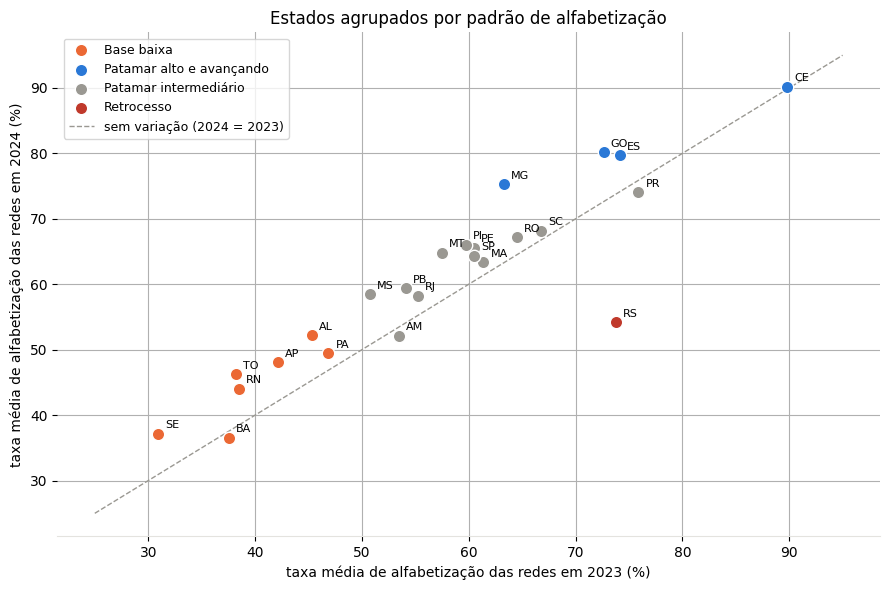

In [108]:
# Perfil de cada estado a partir das redes municipais
perfil_uf = (municipios_risco.groupby("sigla_uf")
             .agg(regiao=("regiao", "first"), redes=("id_municipio", "size"),
                  taxa_2023=("ctx_taxa", "mean"), taxa_2024=("taxa_observada", "mean"),
                  pct_nao_atingiu=("nao_atingiu_meta", "mean"))
             .dropna())
perfil_uf["variacao"] = perfil_uf["taxa_2024"] - perfil_uf["taxa_2023"]
perfil_uf["pct_nao_atingiu"] = 100 * perfil_uf["pct_nao_atingiu"]
variaveis_grupo = ["taxa_2023", "taxa_2024", "variacao", "pct_nao_atingiu"]

# Padronizar (colocar as variáveis na mesma escala) e escolher o número de grupos pela silhueta
Z = StandardScaler().fit_transform(perfil_uf[variaveis_grupo])
silhuetas = {k: silhouette_score(Z, KMeans(n_clusters=k, n_init=20, random_state=SEED).fit_predict(Z))
             for k in [2, 3, 4, 5]}
print("Silhueta por número de grupos (quanto maior, mais bem separados):",
      {k: round(v, 3) for k, v in silhuetas.items()})

k_escolhido = max(silhuetas, key=silhuetas.get)
perfil_uf["grupo"] = KMeans(n_clusters=k_escolhido, n_init=20, random_state=SEED).fit_predict(Z)

# Nome de cada grupo a partir do seu perfil médio
centros = perfil_uf.groupby("grupo")[variaveis_grupo].mean()
def nomeia(centro):
    if centro["variacao"] < -5:
        return "Retrocesso"
    if centro["taxa_2024"] >= 75:
        return "Patamar alto e avançando"
    if centro["taxa_2024"] < 50:
        return "Base baixa"
    return "Patamar intermediário"
perfil_uf["padrao"] = perfil_uf["grupo"].map({g: nomeia(c) for g, c in centros.iterrows()})

resumo_grupos = (perfil_uf.groupby("padrao")
                 .agg(estados=("redes", "size"), taxa_2023=("taxa_2023", "mean"), taxa_2024=("taxa_2024", "mean"),
                      variacao=("variacao", "mean"), pct_nao_atingiu=("pct_nao_atingiu", "mean"))
                 .sort_values("taxa_2024", ascending=False).round(1))
resumo_grupos["UFs"] = [", ".join(sorted(perfil_uf[perfil_uf["padrao"] == p].index)) for p in resumo_grupos.index]
resumo_grupos["regiões"] = [", ".join(sorted(perfil_uf[perfil_uf["padrao"] == p]["regiao"].unique()))
                            for p in resumo_grupos.index]
print(f"\nNúmero de grupos escolhido: {k_escolhido}")
display(resumo_grupos)

# Gráfico: cada ponto é um estado
cores_grupo = {"Patamar alto e avançando": AZUL, "Patamar intermediário": NEUTRO,
               "Base baixa": LARANJA, "Retrocesso": "#C0392B"}
fig, ax = plt.subplots(figsize=(9, 6))
for padrao, bloco in perfil_uf.groupby("padrao"):
    ax.scatter(bloco["taxa_2023"], bloco["taxa_2024"], s=80, color=cores_grupo.get(padrao, AZUL), label=padrao,
               edgecolors="white", zorder=3)
    for uf, linha in bloco.iterrows():
        ax.annotate(uf, (linha["taxa_2023"], linha["taxa_2024"]), textcoords="offset points", xytext=(5, 4), fontsize=8)
lim = [25, 95]
ax.plot(lim, lim, color=NEUTRO, linestyle="--", linewidth=1, label="sem variação (2024 = 2023)")
ax.set_xlabel("taxa média de alfabetização das redes em 2023 (%)")
ax.set_ylabel("taxa média de alfabetização das redes em 2024 (%)")
ax.set_title("Estados agrupados por padrão de alfabetização")
ax.legend(loc="upper left", fontsize=9)
limpa_eixos(ax); ax.grid(True)
fig.tight_layout()
salva(fig, "projeto_grupos_uf.png"); plt.show()

**Nota:**

A melhor separação foi com **4 grupos** (silhueta de **0,403**, a maior entre 2 e 5 grupos):

| Padrão | Estados | O que têm em comum |
|---|---|---|
| **Patamar alto e avançando** | CE, ES, GO, MG | taxa média de **75%** em 2023 e **81%** em 2024; só **17%** das redes não atingiram a meta |
| **Patamar intermediário** | AM, MA, MS, MT, PB, PE, PI, PR, RJ, RO, SC, SP | de **60%** para **64%**; cerca de metade das redes (**47%**) não atingiu a meta |
| **Base baixa** | AL, AP, BA, PA, RN, SE, TO | partem de **40%** e chegam a **45%**; **57%** das redes não atingiram a meta |
| **Retrocesso** | RS | caiu de **74%** para **54%** (−19,6 pontos); **89%** das redes não atingiram a meta |

- **Como ler o gráfico:** cada ponto é um estado. Quem está **acima da linha tracejada** melhorou de 2023 para 2024; quem está **abaixo** piorou.
  O **RS** aparece isolado, bem abaixo da linha.
- **Os grupos não seguem as regiões geográficas.** O grupo de patamar alto junta **Nordeste** (Ceará), **Sudeste** (MG, ES) e **Centro-Oeste**
  (Goiás); o intermediário tem estados das **cinco regiões**. Já o grupo de base baixa concentra-se no **Norte e Nordeste**.
- **Para a política pública:** estados do mesmo grupo enfrentam **desafios parecidos** e podem trocar experiências — por exemplo, o Ceará,
  referência nacional, está no mesmo grupo de MG, ES e GO, e não no dos seus vizinhos do Nordeste.
- DF e AC não aparecem porque não participaram da avaliação de 2023.

### <font color='#F37126'> Como prever municípios que podem não atingir metas futuras?

In [109]:
# Métricas e variáveis mais importantes do modelo municipal (reports/metricas_municipio.json)
with open(REPORTS_DIR / "metricas_municipio.json", encoding="utf-8") as arquivo:
    metricas_municipio = json.load(arquivo)

holdout_m = metricas_municipio["holdout"]
print(f"Modelo municipal escolhido: {metricas_municipio['modelo_escolhido']}")
print(f"Redes no teste: {holdout_m['n_teste']:,} | {100 * holdout_m['prevalencia']:.1f}% não atingiram a meta\n")
print(f"AUC-ROC ........ {holdout_m['roc_auc']:.3f}")
print(f"PR-AUC ......... {holdout_m['pr_auc']:.3f}  (sorteio = {holdout_m['prevalencia']:.3f})")
print(f"Recall ......... {holdout_m['recall_em_risco']:.3f}")
print(f"F1-Score ....... {holdout_m['f1']:.3f}\n")

importancia_municipal = pd.DataFrame(metricas_municipio["importancias"]).head(8)
importancia_municipal.columns = ["variável", "queda do PR-AUC", "desvio"]
print("Variáveis que mais influenciam o modelo municipal (importância por permutação):")
display(importancia_municipal.round(3))

Modelo municipal escolhido: hist_gradient_boosting
Redes no teste: 2,702 | 46.4% não atingiram a meta

AUC-ROC ........ 0.861
PR-AUC ......... 0.840  (sorteio = 0.464)
Recall ......... 0.758
F1-Score ....... 0.752

Variáveis que mais influenciam o modelo municipal (importância por permutação):


,variável,queda do PR-AUC,desvio
0,sigla_uf,0.290,0.008
1,meta_2024,0.139,0.006
2,ctx_media_portugues,0.056,0.004
3,ibge_populacao,0.045,0.004
4,ibge_pib_per_capita,0.031,0.002
5,ibge_densidade_demografica,0.031,0.003
6,gap_projetado,0.026,0.004
7,ctx_taxa,0.019,0.002


**Nota:**

**Sim, é possível prever — e com mais precisão do que no nível da criança.** O modelo municipal alcança **AUC-ROC de 0,861** e **PR-AUC de 0,840**
(contra 0,464 de um sorteio) nas **2.702 redes** que ele não viu no treino, e encontra **76%** das redes que de fato não atingiram a meta.

**Como ele funciona, em três passos:**

1. Para cada rede (município × rede), reúne o que já se sabe **antes** do ano avaliado: a **taxa e a nota de português de 2023**, a **meta** do INEP,
   a **distância até a meta**, o **porte** e os dados do **IBGE**.
2. O modelo calcula a **probabilidade de a rede não atingir a meta** do ano seguinte.
3. As redes são ordenadas da maior para a menor probabilidade — é o ranking de `reports/municipios_risco.csv`.

**O que mais pesa:** o **estado** (`sigla_uf`, queda de **0,290** no PR-AUC), a **meta de 2024** (**0,139**) e a **nota de português de 2023**
(**0,056**), seguidos por população e PIB. A meta pesa tanto porque **metas mais exigentes falham mais**.

**Por que o municipal acerta mais que o de crianças?** Prever se **uma rede inteira** vai atingir a meta é mais fácil do que prever o resultado
de **cada criança**: no agregado, as variações individuais se compensam.

**Limites:** com apenas dois ciclos (2023 e 2024), o modelo prevê o **próximo ciclo**, não 2030. O efeito do RS em 2024 pesa muito no aprendizado —
se a queda não se repetir, o risco do estado estará superestimado. O modelo deve ser **retreinado a cada nova avaliação**.

### <font color='#F37126'> Quadro-resumo: as cinco perguntas

| Pergunta | Resposta curta | Onde está no notebook |
|---|---|---|
| **Quais fatores mais impactam a alfabetização?** | O **lugar onde a criança estuda** (estado, município, escola) e o **histórico de 2023** do município. Região e pobreza **agravam**, mas só quando o histórico já é ruim. Rede, tamanho e riqueza, sozinhos, pesam pouco. | Hipóteses H1–H9 · Correlações · Insights 1–3 |
| **Quais municípios apresentam maior risco educacional?** | As redes do **Rio Grande do Sul** lideram (Caxias do Sul, Tupanciretã, Bento Gonçalves…), pela queda de 2024. Por região, o risco crítico é maior no **Sul (49%)**, **Norte (29%)** e **Nordeste (28%)**. | Perguntas de negócio · `reports/municipios_risco.csv` |
| **Quais regiões possuem padrões semelhantes?** | **4 grupos de estados** que não seguem a geografia: patamar alto (CE, ES, GO, MG), intermediário (12 UFs), base baixa (AL, AP, BA, PA, RN, SE, TO) e retrocesso (RS). | Perguntas de negócio · agrupamento KMeans |
| **Como prever municípios que podem não atingir metas futuras?** | Com o **modelo municipal** (AUC 0,861), que usa o contexto de 2023, a meta e o porte para ordenar as redes por risco de não atingir a meta do ano seguinte. | Perguntas de negócio · `src/modeling/train_municipio.py` |
| **Quais variáveis possuem maior influência nos modelos?** | **Modelo por criança:** nota de português do município em 2023, município, escola, taxa de 2023 e estado. **Modelo municipal:** estado, meta de 2024 e nota de português de 2023. | Fase 04 · seção 3 · Perguntas de negócio |

## **Insights consolidados**

O que o ciclo inteiro descobriu, em ordem de consequência para quem decide.

**1 — Onde a criança estuda pesa mais do que tudo o que se registra sobre ela.**
Nenhuma variável individual da criança entrou na análise, porque nenhuma existe nos microdados públicos: não há renda familiar,
frequência escolar nem escolaridade dos pais. O que explica o risco é o **território**. Entre estados, a diferença chega a
**51 pontos percentuais** — de **13,9%** de crianças não alfabetizadas no Ceará a **64,9%** na Bahia. E o **estado** diz muito mais que a
região: V de Cramér de **0,228** contra **0,070**.

**2 — O passado do município antecipa o presente, e é isso que torna a previsão possível.**
A correlação entre a taxa de 2023 e a de 2024 é de **0,72**: só o histórico explica **52%** da variação entre municípios. Nas crianças dos
municípios de pior histórico, **58,8%** não se alfabetizaram; nos de melhor histórico, **16,8%** — um risco **3,5 vezes** maior. Municípios que
estavam abaixo da meta tiveram **42,2%** de não alfabetizados, contra **25,4%** dos que já estavam na meta. Sem essa persistência não haveria o
que prever com um ano de antecedência.

**3 — Região e pobreza agravam, mas não decidem sozinhas.**
Estar no Norte/Nordeste com histórico bom **não aumenta** o risco (**32,5%**, abaixo dos **34,1%** de quem não tem nenhuma das duas condições).
Mas, somado a um histórico ruim, o risco chega a **56,8%**. O mesmo vale para a pobreza: município pobre sozinho, **31,8%**; pobre **e** com
histórico ruim, **55,2%**. **O alvo das políticas não é a região inteira, e sim os municípios de histórico fraco dentro dela.**

**4 — O modelo ordena bem e mede mal.**
Da faixa de menor para a de maior risco previsto, a taxa real sobe de **7,5%** para **66,3%** — a ordem está certa. Mas a probabilidade sai
**inflada**: o modelo prevê **49%** de risco em média, contra **40%** reais, e superestima o risco nas **26 UFs** (cerca de **9 pontos**). Somando as
probabilidades, esperaria **4.914** crianças não alfabetizadas no teste, mas foram **4.010**. **Use o modelo para escolher a fila, não para estimar o
tamanho da fila.**

**5 — A escolha do algoritmo não é o gargalo. Os dados são.**
Os quatro algoritmos terminaram perto um do outro: AUC-ROC na validação entre **0,624** (Random Forest) e **0,660** (Regressão Logística). O modelo mais
simples, a Regressão Logística, **empatou** com o LightGBM, e o ajuste fino levou o LightGBM a **0,662** (**0,667** no teste). Quando uma fórmula
simples empata com um algoritmo sofisticado, não há padrão complexo escondido — **faltam variáveis**.

**6 — O limiar é decisão de política, não detalhe técnico.**
Com o corte padrão de **0,5**, o modelo aponta **48%** das crianças e encontra **62,5%** das que estão em risco. Com o corte de F1 máximo (**0,37**),
aponta **80%** e encontra **90,1%**. Tratando deixar uma criança de fora como cinco vezes pior que um alarme falso, o corte cai para **0,29**: aponta
**92%** e encontra **97,4%**. **O corte define quantas crianças entram no programa**, e quem responde por isso é o gestor, não o algoritmo.

**7 — O ganho do modelo aparece quando o orçamento aperta.**
Na simulação com **1.000 crianças novas**, **100 vagas** de reforço distribuídas pela ordem do modelo alcançam **66** crianças em risco; sorteadas,
alcançariam **38** — **1,74 vez mais**. Com **500 vagas**, o ganho cai para **1,35 vez**. **Quanto mais escasso o recurso, mais a priorização vale.**

**8 — Resultado perfeito é sintoma de vazamento — e o modelo honesto se sustenta em crianças novas.**
Com a nota da prova (`proficiencia`) dentro, o modelo chega a **AUC de 1,000** e encontra **100%** das crianças em risco — porque já tem a resposta.
Sem ela, o desempenho é modesto, mas **estável**: acurácia de **61,6%** na validação, **61,5%** no teste e **63,8%** na simulação com crianças que o
modelo nunca viu.

### As hipóteses, revisitadas

| Hipótese | O que se afirmava | Resultado |
|---|---|---|
| **H1 — Território** | O estado e a região onde a criança estuda influenciam o risco | ✅ **CONFIRMADA** — 51 pontos de diferença entre CE e BA |
| **H2 — Persistência** | A taxa de 2023 do município antecipa o resultado de 2024 | ✅ **CONFIRMADA** — correlação de 0,72 e risco 3,5x maior no pior decil |
| **H3 — Rede de ensino** | A rede (municipal ou estadual) muda o risco | ⚠️ **CONFIRMADA, MAS FRACA** — só 1,6 ponto de diferença |
| **H4 — Riqueza** | Municípios mais ricos têm menos crianças não alfabetizadas | ❌ **REJEITADA** — o PIB, sozinho, não mostrou padrão |
| **H5 — Meta de 2024** | Municípios abaixo da meta têm mais risco | ✅ **CONFIRMADA** — 42,2% contra 25,4% (OR 2,15) |
| **H6 — Tamanho do município** | O risco aumenta com o tamanho do município | ⚡ **PARCIALMENTE CONFIRMADA** — sobe até 1 milhão de habitantes e cai nas metrópoles |
| **H7 — Escola pequena** | Escolas pequenas têm mais risco | ⚠️ **CONFIRMADA, MAS FRACA** — 42,1% contra 39,5% (OR 1,11) |
| **H8 — Histórico ruim + Norte/Nordeste** | As duas condições juntas elevam muito o risco | ✅ **CONFIRMADA** — 56,8%; a região sozinha não pesa |
| **H9 — Município pobre + histórico ruim** | As duas condições juntas elevam muito o risco | ✅ **CONFIRMADA** — 55,2%; a pobreza sozinha não pesa |

Das nove hipóteses, cinco se confirmaram com clareza, duas com efeito fraco, uma parcialmente e uma foi rejeitada. A que mais mudou o desenho do
projeto foi a **H2**: é a persistência do histórico que autoriza usar o contexto de **2023** para prever **2024** sem vazar o alvo.

### Os limites, ditos com todas as letras

**O teto é dos dados.** Os quatro algoritmos chegaram praticamente ao mesmo lugar (AUC-ROC entre 0,62 e 0,66). Nenhum ajuste de hiperparâmetro
resolve a ausência de renda familiar, frequência escolar e escolaridade dos pais nos microdados públicos.

**Esta análise usa uma amostra.** Foram **50 mil crianças** das 1,85 milhão da base completa. No treino, há cerca de **uma criança por escola**, o
que enfraquece o sinal do código da escola. Com a base completa, os números tendem a melhorar — versões anteriores do projeto, treinadas com 600 mil crianças, chegaram a AUC-ROC de 0,697.

**O modelo prevê exposição, não destino.** Ele lê contexto: município, escola, rede, histórico. Crianças da mesma escola recebem riscos parecidos,
porque o dado disponível não as distingue. Usar essa saída para **rotular uma criança** individualmente seria uma leitura errada do que ela mede.

**Ele reproduz a desigualdade que mede.** Como o território domina, o modelo naturalmente aponta mais crianças de estados como Bahia, Rio Grande do
Norte e Rio Grande do Sul. Isso é útil para **alocar recursos** e perigoso se virar justificativa para **expectativa reduzida**. A recomendação de uso é
agregada: **priorizar redes e escolas, não etiquetar crianças**.

**As probabilidades não servem para orçar.** O modelo superestima o risco em cerca de 9 pontos. Somar as probabilidades para prever quantas vagas
reservar superestimaria a necessidade em cerca de **22%**.

**Dois ciclos apenas.** 2023 e 2024. Toda extrapolação para 2030 é uma reta entre dois pontos, e o **Rio Grande do Sul de 2024** (queda de **19,6
pontos**, documentada no dicionário de dados) mostra que um único ciclo atípico move o indicador inteiro — e explica por que o estado aparece com peso
alto na fórmula da Regressão Logística.

# <font color= "red"> **PRÓXIMOS PASSOS**

O modelo está pronto para uso como ferramenta de **priorização**, mas pode ficar mais útil, mais preciso e mais seguro. Os próximos passos, em
ordem de impacto:

1. **Criar uma interface gráfica para simular a previsão.**
   Um aplicativo simples (por exemplo, com Streamlit) em que o gestor **envia a lista de crianças** (CSV) ou **escolhe um município/escola**,
   informa o **número de vagas de reforço** e recebe a **fila de prioridade**, usando o modelo salvo (`models/modelo_final_alfabetizacao.joblib`)
   e a ficha do modelo (`.json`). *Por quê:* hoje a simulação só existe dentro do notebook — quem decide não programa.

2. **Treinar com a base completa (1,85 milhão de crianças).**
   *Por quê:* com a amostra de 50 mil, há cerca de **uma criança por escola** no treino, e o código da escola quase não ajuda. Uma versão anterior do projeto, treinada com
   600 mil crianças, chegou a AUC-ROC de **0,697** (contra 0,667 aqui).

3. **Recalibrar as probabilidades.**
   *Por quê:* o modelo prevê **49%** de risco em média, contra **40%** reais. Calibrado, ele poderia ser usado também para **orçar vagas** — hoje,
   somar as probabilidades superestimaria a necessidade em cerca de **22%**.

4. **Explicar cada previsão.**
   Mostrar, para cada escola ou criança, **quais informações mais pesaram** no risco (importância das variáveis / SHAP). *Por quê:* o gestor precisa
   entender e justificar **por que** uma escola foi priorizada.

5. **Testar municípios que o modelo nunca viu.**
   Refazer a avaliação deixando **municípios inteiros** fora do treino. *Por quê:* medir quanto o modelo depende do histórico local — e saber se ele
   funciona para uma rede que acabou de entrar no programa (como DF e AC, que não participaram de 2023).

6. **Buscar novas variáveis.**
   Frequência escolar, infraestrutura da escola (Censo Escolar), nível socioeconômico da escola, formação dos professores. *Por quê:* os quatro
   algoritmos empataram — **o teto do modelo são os dados**, não o algoritmo.

7. **Avaliar a equidade.**
   Conferir se os erros do modelo são parecidos entre estados, regiões e redes. *Por quê:* como o território domina, o modelo pode **reforçar a
   desigualdade que mede**; é preciso garantir que ele sirva para distribuir recursos, e não para baixar expectativas.

8. **Retreinar a cada novo ciclo e monitorar o desempenho.**
   *Por quê:* só existem dois anos de avaliação (2023 e 2024), e o caso do **Rio Grande do Sul** mostra como um único ciclo atípico muda o indicador.
   A cada nova avaliação, o modelo deve ser retreinado e comparado com o anterior.

**Por onde começar:** os passos **1** e **2** são os de maior impacto imediato — o primeiro torna o modelo **usável** por quem decide, e o segundo o
torna **mais preciso**.

---

### Fechamento

O ciclo CRISP-DM se fechou: a pergunta de negócio virou um alvo, o alvo definiu a métrica, a exploração escolheu as variáveis e
vetou as que vazavam, quatro algoritmos competiram sob as mesmas regras, o campeão foi ajustado, avaliado em crianças que nunca viu
e salvo junto com a sua ficha — e a escolha do limiar ficou nas mãos de quem decide, como uma decisão de política, não de convenção.

O resultado honesto é um modelo que **prioriza melhor que o acaso e não substitui o diagnóstico pedagógico**: com 100 vagas de
reforço, ele alcança 66 crianças em risco onde um sorteio alcançaria 38. Para a política pública, priorizar bem já é bastante:
significa que a rede chega primeiro onde a chance de não alfabetização é maior.